<a href="https://colab.research.google.com/github/ThuliniPremasinghe/ASD2-Research/blob/main/Final_ASD_Multimodal_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal ASD Risk Screening Framework

## Final Experimental Pipeline

This notebook implements a multimodal machine-learning framework for ASD risk screening using four independent modalities:

1. Shape Drawing
   - Circle
   - Square
   - Triangle
   - Inverted Triangle

2. Colour Drawing

3. Draw-a-Man Drawing

4. Caregiver Questionnaire

Each modality is modeled independently and produces an ASD probability score.

The four branch probabilities are subsequently combined using a late-fusion Logistic Regression meta-classifier.

## Methodological safeguards

The experimental pipeline is designed to:

- keep all data from the same participant within the same fold
- prevent preprocessing leakage
- prevent train/test leakage between branch models and the fusion model
- generate out-of-fold predictions for unbiased evaluation
- use nested cross-validation for the final stacking ensemble
- select decision thresholds using training data only
- report participant-level performance

Because the current dataset is a pilot dataset, model outputs and risk categories are interpreted as research estimates rather than validated clinical diagnoses.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ============================================================
# PROJECT CONFIGURATION
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/ASD Research"

# IMPORTANT: exact Drive folder name is "Dataset"
DATASET_DIR = os.path.join(PROJECT_DIR, "Dataset")

ASD_DIR = os.path.join(DATASET_DIR, "ASD")
NON_ASD_DIR = os.path.join(DATASET_DIR, "Non ASD")

PARTICIPANTS_CSV = os.path.join(
    DATASET_DIR,
    "Participants_Info.csv"
)

QUESTIONNAIRE_CSV = os.path.join(
    DATASET_DIR,
    "Questionnaire_Responses.csv"
)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATASET_DIR:", DATASET_DIR)

print("\nPath checks:")
print("Dataset:", os.path.exists(DATASET_DIR))
print("ASD folder:", os.path.exists(ASD_DIR))
print("Non-ASD folder:", os.path.exists(NON_ASD_DIR))
print("Participants CSV:", os.path.exists(PARTICIPANTS_CSV))
print("Questionnaire CSV:", os.path.exists(QUESTIONNAIRE_CSV))

if os.path.exists(DATASET_DIR):
    print("\nDataset contents:")
    for name in sorted(os.listdir(DATASET_DIR)):
        print(" -", name)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/ASD Research
DATASET_DIR: /content/drive/MyDrive/ASD Research/Dataset

Path checks:
Dataset: True
ASD folder: True
Non-ASD folder: True
Participants CSV: True
Questionnaire CSV: True

Dataset contents:
 - ASD
 - Non ASD
 - Participants_Info.csv
 - Questionnaire_Responses.csv


## 2. Inspect Participant and Questionnaire Tables

Before constructing the master participant dataset, the two CSV files are inspected independently.

This step verifies:

- number of records
- column names
- participant-ID format
- missing values
- duplicate participant IDs
- available demographic / diagnostic fields
- questionnaire item structure

No labels are assigned and no records are merged at this stage.



In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD CSV FILES WITHOUT MODIFYING THEM
# ============================================================

participants_df_raw = pd.read_csv(PARTICIPANTS_CSV)
questionnaire_df_raw = pd.read_csv(QUESTIONNAIRE_CSV)

# ------------------------------------------------------------
# Participants table
# ------------------------------------------------------------

print("=" * 70)
print("PARTICIPANTS_INFO.CSV")
print("=" * 70)

print("Shape:", participants_df_raw.shape)

print("\nColumns:")
for i, col in enumerate(participants_df_raw.columns, start=1):
    print(f"{i:2d}. {repr(col)}")

print("\nFirst 10 rows:")
display(participants_df_raw.head(10))

print("\nMissing values by column:")
missing_participants = participants_df_raw.isna().sum()
display(
    missing_participants[
        missing_participants > 0
    ].to_frame("Missing_Count")
)

if (missing_participants > 0).sum() == 0:
    print("No missing values in Participants_Info.csv")


# ------------------------------------------------------------
# Questionnaire table
# ------------------------------------------------------------

print("\n\n" + "=" * 70)
print("QUESTIONNAIRE_RESPONSES.CSV")
print("=" * 70)

print("Shape:", questionnaire_df_raw.shape)

print("\nColumns:")
for i, col in enumerate(questionnaire_df_raw.columns, start=1):
    print(f"{i:2d}. {repr(col)}")

print("\nFirst 10 rows:")
display(questionnaire_df_raw.head(10))

print("\nMissing values by column:")
missing_questionnaire = questionnaire_df_raw.isna().sum()
display(
    missing_questionnaire[
        missing_questionnaire > 0
    ].to_frame("Missing_Count")
)

if (missing_questionnaire > 0).sum() == 0:
    print("No missing values in Questionnaire_Responses.csv")

PARTICIPANTS_INFO.CSV
Shape: (100, 4)

Columns:
 1. 'Participant_id'
 2. 'Age'
 3. 'Gender'
 4. 'Group'

First 10 rows:


,Participant_id,Age,Gender,Group
0,P001,9.0,F,TD
1,P002,9.0,M,TD
2,P003,9.0,F,TD
3,P004,8.0,M,TD
4,P005,8.0,F,TD
5,P006,7.0,M,TD
6,P007,7.0,M,TD
7,P008,7.0,F,TD
8,P009,8.0,M,TD
9,P010,7.0,F,TD



Missing values by column:


,Missing_Count
Age,61
Gender,61
Group,61




QUESTIONNAIRE_RESPONSES.CSV
Shape: (39, 27)

Columns:
 1. 'Participant_id'
 2. 'group'
 3. 'item_1'
 4. 'item_2'
 5. 'item_3'
 6. 'item_4'
 7. 'item_5'
 8. 'item_6'
 9. 'item_7'
10. 'item_8'
11. 'item_9'
12. 'item_10'
13. 'item_11'
14. 'item_12'
15. 'item_13'
16. 'item_14'
17. 'item_15'
18. 'item_16'
19. 'item_17'
20. 'item_18'
21. 'item_19'
22. 'item_20'
23. 'item_21'
24. 'item_22'
25. 'item_23'
26. 'item_24'
27. 'item_25'

First 10 rows:


,Participant_id,group,item_1,item_2,item_3,item_4,item_5,item_6,item_7,item_8,...,item_16,item_17,item_18,item_19,item_20,item_21,item_22,item_23,item_24,item_25
0,P_001,TD,1,2,3,2,4,1,1,4,...,2,1,1,4,4,3,1,4,3,4
1,P_002,TD,1,2,4,4,1,2,1,4,...,4,2,1,4,4,1,1,4,3,3
2,P_003,TD,4,3,3,4,1,1,4,4,...,1,2,2,2,3,1,4,4,1,4
3,P_004,TD,2,3,3,4,3,1,1,3,...,2,1,1,4,4,1,1,4,4,4
4,P_005,TD,1,4,4,3,3,4,1,4,...,3,3,1,3,4,1,3,4,4,4
5,P_006,TD,2,1,3,2,4,2,1,4,...,1,3,3,3,4,1,4,4,3,2
6,P_007,TD,3,3,2,4,4,2,2,3,...,1,1,1,4,4,1,1,3,4,4
7,P_008,TD,1,3,2,1,3,3,1,3,...,2,1,2,4,4,1,1,4,2,4
8,P_009,TD,1,4,2,3,4,2,2,3,...,1,1,1,3,2,3,3,4,4,3
9,P_010,TD,1,4,3,4,4,2,2,1,...,1,1,3,4,4,2,3,4,2,3



Missing values by column:


,Missing_Count


No missing values in Questionnaire_Responses.csv


## 3. Participant-ID Standardization and Data Validation

Participant identifiers are standardized across the demographic,
questionnaire, and image datasets before merging.

This step verifies:

- participant-ID consistency
- duplicate participant IDs
- agreement between demographic and questionnaire group labels
- questionnaire response range
- questionnaire missing values
- incomplete placeholder participant records

Age and gender are retained as descriptive participant information but are not
used as input features for the multimodal ASD models.

In [ ]:
import re

# ============================================================
# PARTICIPANT ID NORMALIZATION
# ============================================================

def normalize_participant_id(value):
    """
    Standardize participant IDs.

    Examples:
        P001  -> P001
        P_001 -> P001
        p001  -> P001
    """

    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper().replace("_", "")

    match = re.fullmatch(r"P?(\d+)", value)

    if match:
        number = int(match.group(1))
        return f"P{number:03d}"

    return value


# Keep raw tables unchanged
participants_df = participants_df_raw.copy()
questionnaire_df = questionnaire_df_raw.copy()


# ============================================================
# STANDARDIZE IDS
# ============================================================

participants_df["Participant_ID"] = (
    participants_df["Participant_id"]
    .apply(normalize_participant_id)
)

questionnaire_df["Participant_ID"] = (
    questionnaire_df["Participant_id"]
    .apply(normalize_participant_id)
)


# ============================================================
# REMOVE EMPTY PLACEHOLDER ROWS
# ============================================================

# A real participant record must contain a known Group
participants_complete = (
    participants_df[
        participants_df["Group"].notna()
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# BASIC VALIDATION
# ============================================================

print("=" * 70)
print("PARTICIPANT VALIDATION")
print("=" * 70)

print("Rows in Participants_Info.csv:",
      len(participants_df))

print("Completed participant records:",
      len(participants_complete))

print("Placeholder/incomplete rows:",
      len(participants_df) - len(participants_complete))


print("\nCompleted participant group counts:")
print(
    participants_complete["Group"]
    .value_counts()
)


# ============================================================
# DUPLICATE CHECK
# ============================================================

participant_duplicates = (
    participants_complete["Participant_ID"]
    .duplicated()
    .sum()
)

questionnaire_duplicates = (
    questionnaire_df["Participant_ID"]
    .duplicated()
    .sum()
)

print("\nDuplicate participant IDs:")
print("Participants table:", participant_duplicates)
print("Questionnaire table:", questionnaire_duplicates)


# ============================================================
# MATCH PARTICIPANTS AND QUESTIONNAIRE
# ============================================================

validation_merge = participants_complete[
    [
        "Participant_ID",
        "Age",
        "Gender",
        "Group"
    ]
].merge(
    questionnaire_df[
        [
            "Participant_ID",
            "group"
        ]
    ],
    on="Participant_ID",
    how="outer",
    indicator=True
)


print("\nID matching:")
print(
    validation_merge["_merge"]
    .value_counts()
)


# ============================================================
# GROUP LABEL AGREEMENT
# ============================================================

group_mismatch = validation_merge[
    validation_merge["Group"].notna()
    &
    validation_merge["group"].notna()
    &
    (
        validation_merge["Group"]
        != validation_merge["group"]
    )
]

print("\nGroup-label mismatches:",
      len(group_mismatch))

if len(group_mismatch) > 0:
    display(group_mismatch)


# ============================================================
# QUESTIONNAIRE VALIDATION
# ============================================================

ITEM_COLS = [
    col
    for col in questionnaire_df.columns
    if col.startswith("item_")
]

questionnaire_missing = (
    questionnaire_df[ITEM_COLS]
    .isna()
    .sum()
    .sum()
)

questionnaire_min = (
    questionnaire_df[ITEM_COLS]
    .min()
    .min()
)

questionnaire_max = (
    questionnaire_df[ITEM_COLS]
    .max()
    .max()
)

print("\nQuestionnaire validation:")
print("Number of questionnaire items:",
      len(ITEM_COLS))

print("Minimum response:",
      questionnaire_min)

print("Maximum response:",
      questionnaire_max)

print("Missing questionnaire responses:",
      questionnaire_missing)


# ============================================================
# DESCRIPTIVE AGE INFORMATION ONLY
# ============================================================

print("\nAge information:")
print(
    "Age range:",
    participants_complete["Age"].min(),
    "to",
    participants_complete["Age"].max()
)

print(
    "Mean age:",
    round(
        participants_complete["Age"].mean(),
        2
    )
)

PARTICIPANT VALIDATION
Rows in Participants_Info.csv: 100
Completed participant records: 39
Placeholder/incomplete rows: 61

Completed participant group counts:
Group
TD     25
ASD    14
Name: count, dtype: int64

Duplicate participant IDs:
Participants table: 0
Questionnaire table: 0

ID matching:
_merge
both          39
left_only      0
right_only     0
Name: count, dtype: int64

Group-label mismatches: 0

Questionnaire validation:
Number of questionnaire items: 25
Minimum response: 1
Maximum response: 4
Missing questionnaire responses: 0

Age information:
Age range: 4.0 to 15.0
Mean age: 7.38


## 4. Build and Validate the Image Manifest

The ASD and Non-ASD image folders are scanned at participant level.

For each participant, the pipeline searches for:

### Shape branch
- Circle
- Square
- Triangle
- Inverted Triangle

### Colour branch
- Colour Drawing

### Draw-a-Man branch
- Draw man

Filename matching is performed in a case-insensitive and space-insensitive manner.

The folder-derived group label is then compared against the verified participant table.
No participant is silently assigned a diagnosis from a missing or unmatched record.

This step also identifies:

- participants with missing images
- participants appearing in both ASD and Non-ASD folders
- image-folder participants not present in the participant table
- participant records without image folders
- disagreement between folder labels and participant-table labels

In [ ]:
import os
import pandas as pd
import numpy as np

# ============================================================
# IMAGE FILE SEARCH
# ============================================================

VALID_IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png"
)


def normalize_filename_stem(filename):
    """
    Normalize filename for robust matching.

    Examples:
        "Circle.jpg"            -> "circle"
        "Square .jpg"           -> "square"
        "Inverted Triangle.jpg" -> "invertedtriangle"
    """

    stem = os.path.splitext(
        os.path.basename(filename)
    )[0]

    return (
        stem
        .strip()
        .lower()
        .replace(" ", "")
        .replace("_", "")
        .replace("-", "")
    )


def find_image_file(participant_dir, candidate_names):
    """
    Find one image matching any candidate name.

    Search is:
    - recursive
    - case-insensitive
    - space/underscore/hyphen-insensitive
    """

    candidate_normalized = {
        normalize_filename_stem(name)
        for name in candidate_names
    }

    matches = []

    for root, _, files in os.walk(participant_dir):

        for filename in files:

            if not filename.lower().endswith(
                VALID_IMAGE_EXTENSIONS
            ):
                continue

            normalized = normalize_filename_stem(
                filename
            )

            if normalized in candidate_normalized:

                matches.append(
                    os.path.join(
                        root,
                        filename
                    )
                )

    # No matching file
    if len(matches) == 0:
        return None

    # More than one matching file is ambiguous
    if len(matches) > 1:
        raise ValueError(
            f"Multiple matching files found in "
            f"{participant_dir}: {matches}"
        )

    return matches[0]


# ============================================================
# REQUIRED IMAGE DEFINITIONS
# ============================================================

IMAGE_TYPES = {

    "circle": [
        "Circle"
    ],

    "square": [
        "Square"
    ],

    "triangle": [
        "Triangle"
    ],

    "inv_triangle": [
        "Inverted Triangle",
        "InvertedTriangle"
    ],

    "colour_drawing": [
        "Color Drawing",
        "Colour Drawing",
        "ColorDrawing",
        "ColourDrawing"
    ],

    "draw_man": [
        "Draw man",
        "Drawman",
        "Draw a man",
        "Draw-a-Man"
    ]
}


# ============================================================
# SCAN IMAGE FOLDERS
# ============================================================

image_records = []

folder_definitions = [
    (
        ASD_DIR,
        "ASD"
    ),
    (
        NON_ASD_DIR,
        "TD"
    )
]


for group_dir, folder_group in folder_definitions:

    if not os.path.isdir(group_dir):
        raise FileNotFoundError(
            f"Missing folder: {group_dir}"
        )

    participant_folders = sorted(
        [
            name
            for name in os.listdir(group_dir)
            if os.path.isdir(
                os.path.join(
                    group_dir,
                    name
                )
            )
        ]
    )

    for folder_name in participant_folders:

        participant_id = (
            normalize_participant_id(
                folder_name
            )
        )

        participant_dir = os.path.join(
            group_dir,
            folder_name
        )

        record = {
            "Participant_ID": participant_id,
            "Folder_Group": folder_group,
            "Participant_Dir": participant_dir
        }

        for image_key, candidate_names in IMAGE_TYPES.items():

            image_path = find_image_file(
                participant_dir,
                candidate_names
            )

            record[image_key] = image_path

        image_records.append(
            record
        )


image_manifest = pd.DataFrame(
    image_records
)


# ============================================================
# CHECK DUPLICATE PARTICIPANTS ACROSS IMAGE FOLDERS
# ============================================================

duplicate_image_ids = (
    image_manifest[
        image_manifest[
            "Participant_ID"
        ].duplicated(
            keep=False
        )
    ]
    .sort_values(
        "Participant_ID"
    )
)

print("=" * 70)
print("IMAGE MANIFEST VALIDATION")
print("=" * 70)

print(
    "Participants found in image folders:",
    len(image_manifest)
)

print("\nFolder group counts:")
print(
    image_manifest[
        "Folder_Group"
    ].value_counts()
)


print(
    "\nDuplicate participant IDs across image folders:",
    image_manifest[
        "Participant_ID"
    ].duplicated().sum()
)

if len(duplicate_image_ids) > 0:

    print(
        "\nDuplicated image-folder participants:"
    )

    display(
        duplicate_image_ids[
            [
                "Participant_ID",
                "Folder_Group",
                "Participant_Dir"
            ]
        ]
    )


# ============================================================
# IMAGE COMPLETENESS
# ============================================================

REQUIRED_IMAGE_COLUMNS = [
    "circle",
    "square",
    "triangle",
    "inv_triangle",
    "colour_drawing",
    "draw_man"
]

for col in REQUIRED_IMAGE_COLUMNS:

    image_manifest[
        f"has_{col}"
    ] = image_manifest[
        col
    ].notna()


image_manifest[
    "has_all_shapes"
] = (
    image_manifest[
        [
            "has_circle",
            "has_square",
            "has_triangle",
            "has_inv_triangle"
        ]
    ]
    .all(axis=1)
)


image_manifest[
    "has_all_images"
] = (
    image_manifest[
        [
            f"has_{col}"
            for col in REQUIRED_IMAGE_COLUMNS
        ]
    ]
    .all(axis=1)
)


print("\nImage availability:")

for col in REQUIRED_IMAGE_COLUMNS:

    count = (
        image_manifest[
            f"has_{col}"
        ].sum()
    )

    print(
        f"{col:18s}: "
        f"{count}/{len(image_manifest)}"
    )


print(
    "\nParticipants with all 4 shape images:",
    image_manifest[
        "has_all_shapes"
    ].sum()
)

print(
    "Participants with all required images:",
    image_manifest[
        "has_all_images"
    ].sum()
)


# ============================================================
# SHOW MISSING IMAGE RECORDS
# ============================================================

incomplete_images = image_manifest[
    ~image_manifest[
        "has_all_images"
    ]
].copy()

if len(incomplete_images) == 0:

    print(
        "\nAll image-folder participants "
        "have the complete required image set."
    )

else:

    print(
        "\nParticipants with missing images:"
    )

    display(
        incomplete_images[
            [
                "Participant_ID",
                "Folder_Group"
            ]
            +
            [
                f"has_{col}"
                for col in REQUIRED_IMAGE_COLUMNS
            ]
        ]
    )


# ============================================================
# COMPARE IMAGE FOLDERS WITH VERIFIED PARTICIPANT TABLE
# ============================================================

image_validation = image_manifest.merge(

    participants_complete[
        [
            "Participant_ID",
            "Age",
            "Gender",
            "Group"
        ]
    ],

    on="Participant_ID",

    how="outer",

    indicator=True
)


print("\nImage folders vs participant table:")

print(
    image_validation[
        "_merge"
    ].value_counts()
)


# ============================================================
# CHECK GROUP AGREEMENT
# ============================================================

image_group_mismatch = image_validation[
    image_validation[
        "Folder_Group"
    ].notna()
    &
    image_validation[
        "Group"
    ].notna()
    &
    (
        image_validation[
            "Folder_Group"
        ]
        !=
        image_validation[
            "Group"
        ]
    )
]


print(
    "\nFolder/table group-label mismatches:",
    len(image_group_mismatch)
)

if len(image_group_mismatch) > 0:

    display(
        image_group_mismatch[
            [
                "Participant_ID",
                "Folder_Group",
                "Group"
            ]
        ]
    )


# ============================================================
# SHOW PARTICIPANTS WITHOUT IMAGE FOLDERS
# ============================================================

no_image_folder = image_validation[
    image_validation[
        "_merge"
    ] == "right_only"
]

if len(no_image_folder) > 0:

    print(
        "\nParticipant records without image folders:"
    )

    display(
        no_image_folder[
            [
                "Participant_ID",
                "Age",
                "Gender",
                "Group"
            ]
        ]
    )


# ============================================================
# SHOW IMAGE FOLDERS WITHOUT PARTICIPANT RECORD
# ============================================================

unknown_image_participants = image_validation[
    image_validation[
        "_merge"
    ] == "left_only"
]

if len(unknown_image_participants) > 0:

    print(
        "\nImage-folder participants "
        "without participant-table record:"
    )

    display(
        unknown_image_participants[
            [
                "Participant_ID",
                "Folder_Group"
            ]
        ]
    )

IMAGE MANIFEST VALIDATION
Participants found in image folders: 34

Folder group counts:
Folder_Group
TD     20
ASD    14
Name: count, dtype: int64

Duplicate participant IDs across image folders: 0

Image availability:
circle            : 34/34
square            : 34/34
triangle          : 34/34
inv_triangle      : 34/34
colour_drawing    : 34/34
draw_man          : 34/34

Participants with all 4 shape images: 34
Participants with all required images: 34

All image-folder participants have the complete required image set.

Image folders vs participant table:
_merge
both          34
right_only     5
left_only      0
Name: count, dtype: int64

Folder/table group-label mismatches: 0

Participant records without image folders:


,Participant_ID,Age,Gender,Group
0,P001,9.0,F,TD
1,P002,9.0,M,TD
2,P003,9.0,F,TD
3,P004,8.0,M,TD
4,P005,8.0,F,TD


## 5. Construct the Primary Multimodal Cohort

The primary multimodal analysis uses participants for whom all required modalities
are available.

A participant is included only when the following are available:

- four shape drawings
- colour drawing
- Draw-a-Man drawing
- caregiver questionnaire
- verified participant group label

The participant information table is treated as the authoritative source of the
ASD/TD group label. Folder and questionnaire group labels are retained only for
consistency checking.

Using the same participant cohort for all four branches allows fair comparison
between individual modalities and ensures that the late-fusion model receives
one prediction from every branch for every participant.

Participants with questionnaire data but no complete image set are retained in
the source data but are not included in the primary multimodal analysis.

In [ ]:
# ============================================================
# BUILD PRIMARY MULTIMODAL MASTER DATASET
# ============================================================

# Keep only image participants with the complete image set
image_complete = (
    image_manifest[
        image_manifest["has_all_images"]
    ]
    .copy()
)


# ------------------------------------------------------------
# Prepare verified participant information
# ------------------------------------------------------------

participant_info_for_merge = (
    participants_complete[
        [
            "Participant_ID",
            "Age",
            "Gender",
            "Group"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Prepare questionnaire table
# ------------------------------------------------------------

questionnaire_for_merge = (
    questionnaire_df[
        ["Participant_ID", "group"] + ITEM_COLS
    ]
    .copy()
    .rename(
        columns={
            "group": "Questionnaire_Group"
        }
    )
)


# ------------------------------------------------------------
# Merge image manifest + participant information
# ------------------------------------------------------------

master_df = image_complete.merge(
    participant_info_for_merge,
    on="Participant_ID",
    how="inner",
    validate="one_to_one"
)


# ------------------------------------------------------------
# Merge questionnaire
# ------------------------------------------------------------

master_df = master_df.merge(
    questionnaire_for_merge,
    on="Participant_ID",
    how="inner",
    validate="one_to_one"
)


# ============================================================
# STRICT GROUP VALIDATION
# ============================================================

valid_groups = {"ASD", "TD"}

unexpected_groups = set(
    master_df["Group"].dropna().unique()
) - valid_groups

if unexpected_groups:
    raise ValueError(
        f"Unexpected participant groups found: "
        f"{unexpected_groups}"
    )


folder_mismatch = (
    master_df["Folder_Group"]
    != master_df["Group"]
)

questionnaire_mismatch = (
    master_df["Questionnaire_Group"]
    != master_df["Group"]
)

if folder_mismatch.any():
    raise ValueError(
        "Folder group labels do not match "
        "Participants_Info.csv."
    )

if questionnaire_mismatch.any():
    raise ValueError(
        "Questionnaire group labels do not match "
        "Participants_Info.csv."
    )


# ============================================================
# CREATE BINARY TARGET EXPLICITLY
# ============================================================

LABEL_MAP = {
    "TD": 0,
    "ASD": 1
}

master_df["Label"] = (
    master_df["Group"]
    .map(LABEL_MAP)
)


if master_df["Label"].isna().any():
    raise ValueError(
        "One or more participants could not "
        "be assigned a valid binary label."
    )

master_df["Label"] = (
    master_df["Label"]
    .astype(int)
)


# ============================================================
# VERIFY COMPLETE MULTIMODAL DATA
# ============================================================

required_master_columns = (
    [
        "circle",
        "square",
        "triangle",
        "inv_triangle",
        "colour_drawing",
        "draw_man"
    ]
    + ITEM_COLS
)

missing_primary_data = (
    master_df[
        required_master_columns
    ]
    .isna()
    .sum()
    .sum()
)

print("=" * 70)
print("PRIMARY MULTIMODAL COHORT")
print("=" * 70)

print(
    "Total participants:",
    len(master_df)
)

print("\nGroup counts:")
print(
    master_df["Group"]
    .value_counts()
)

print("\nBinary label counts:")
print(
    master_df["Label"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "TD (0)",
            1: "ASD (1)"
        }
    )
)

print(
    "\nMissing required multimodal values:",
    missing_primary_data
)

print(
    "Folder/table label agreement:",
    (~folder_mismatch).all()
)

print(
    "Questionnaire/table label agreement:",
    (~questionnaire_mismatch).all()
)

print(
    "Unique participant IDs:",
    master_df["Participant_ID"].nunique()
)

print(
    "Duplicate participant IDs:",
    master_df["Participant_ID"]
    .duplicated()
    .sum()
)


# ============================================================
# QUESTIONNAIRE-ONLY PARTICIPANTS NOT IN PRIMARY COHORT
# ============================================================

primary_ids = set(
    master_df["Participant_ID"]
)

questionnaire_only_ids = sorted(
    set(
        questionnaire_df["Participant_ID"]
    )
    -
    primary_ids
)

print(
    "\nQuestionnaire participants excluded "
    "from primary multimodal cohort:",
    len(questionnaire_only_ids)
)

print(
    questionnaire_only_ids
)


# ============================================================
# DISPLAY CORE MASTER TABLE
# ============================================================

print("\nPrimary cohort preview:")

display(
    master_df[
        [
            "Participant_ID",
            "Age",
            "Gender",
            "Group",
            "Label",
            "circle",
            "square",
            "triangle",
            "inv_triangle",
            "colour_drawing",
            "draw_man"
        ]
    ]
    .head(10)
)

PRIMARY MULTIMODAL COHORT
Total participants: 34

Group counts:
Group
TD     20
ASD    14
Name: count, dtype: int64

Binary label counts:
Label
TD (0)     20
ASD (1)    14
Name: count, dtype: int64

Missing required multimodal values: 0
Folder/table label agreement: True
Questionnaire/table label agreement: True
Unique participant IDs: 34
Duplicate participant IDs: 0

Questionnaire participants excluded from primary multimodal cohort: 5
['P001', 'P002', 'P003', 'P004', 'P005']

Primary cohort preview:


,Participant_ID,Age,Gender,Group,Label,circle,square,triangle,inv_triangle,colour_drawing,draw_man
0,P026,11.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
1,P027,10.0,F,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
2,P028,4.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
3,P029,7.0,F,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
4,P030,8.0,F,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
5,P031,15.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
6,P032,10.0,F,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
7,P033,11.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
8,P034,13.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...
9,P035,14.0,M,ASD,1,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...,/content/drive/MyDrive/Autism detection/Datase...


## 6. Validate All Image Files

Before image preprocessing or feature extraction, every image in the primary
multimodal cohort is validated.

The primary cohort contains six image inputs per participant:

- Circle
- Square
- Triangle
- Inverted Triangle
- Colour Drawing
- Draw-a-Man

For 34 participants, the expected total is:

**34 × 6 = 204 images**

This validation checks:

- whether every file exists
- whether every file can be opened successfully
- image format
- colour mode
- image dimensions
- aspect ratio
- file size
- corrupted or invalid images

Different image dimensions are acceptable because resizing and padding will be
performed later during model preprocessing.

In [ ]:
from PIL import Image
import os
import pandas as pd
import numpy as np

# ============================================================
# IMAGE VALIDATION
# ============================================================

IMAGE_COLUMNS = {
    "circle": "Circle",
    "square": "Square",
    "triangle": "Triangle",
    "inv_triangle": "Inverted Triangle",
    "colour_drawing": "Colour Drawing",
    "draw_man": "Draw-a-Man"
}

image_validation_records = []
image_errors = []


for _, row in master_df.iterrows():

    participant_id = row["Participant_ID"]
    group = row["Group"]
    label = row["Label"]

    for column_name, modality_name in IMAGE_COLUMNS.items():

        image_path = row[column_name]

        # ----------------------------------------------------
        # Check path exists
        # ----------------------------------------------------

        if not isinstance(image_path, str) or not os.path.isfile(image_path):

            image_errors.append({
                "Participant_ID": participant_id,
                "Group": group,
                "Modality": modality_name,
                "Path": image_path,
                "Error": "File does not exist"
            })

            continue


        try:

            # ------------------------------------------------
            # Verify image integrity
            # ------------------------------------------------

            with Image.open(image_path) as img_verify:
                img_verify.verify()


            # ------------------------------------------------
            # Re-open after verify()
            # ------------------------------------------------

            with Image.open(image_path) as img:

                width, height = img.size

                mode = img.mode
                image_format = img.format

                if width <= 0 or height <= 0:
                    raise ValueError(
                        f"Invalid image dimensions: "
                        f"{width} x {height}"
                    )

                aspect_ratio = width / height

                file_size_kb = (
                    os.path.getsize(image_path) / 1024
                )


                image_validation_records.append({
                    "Participant_ID": participant_id,
                    "Group": group,
                    "Label": label,
                    "Modality": modality_name,
                    "Width": width,
                    "Height": height,
                    "Aspect_Ratio": aspect_ratio,
                    "Mode": mode,
                    "Format": image_format,
                    "File_Size_KB": file_size_kb,
                    "Path": image_path
                })


        except Exception as e:

            image_errors.append({
                "Participant_ID": participant_id,
                "Group": group,
                "Modality": modality_name,
                "Path": image_path,
                "Error": str(e)
            })


# ============================================================
# CREATE VALIDATION TABLES
# ============================================================

image_info_df = pd.DataFrame(
    image_validation_records
)

image_error_df = pd.DataFrame(
    image_errors
)


# ============================================================
# SUMMARY
# ============================================================

EXPECTED_IMAGES = (
    len(master_df)
    *
    len(IMAGE_COLUMNS)
)

print("=" * 70)
print("IMAGE FILE VALIDATION")
print("=" * 70)

print(
    "Expected images:",
    EXPECTED_IMAGES
)

print(
    "Successfully validated:",
    len(image_info_df)
)

print(
    "Failed validation:",
    len(image_error_df)
)


# ============================================================
# COUNTS PER MODALITY
# ============================================================

print("\nValidated images by modality:")

if len(image_info_df) > 0:

    modality_counts = (
        image_info_df["Modality"]
        .value_counts()
        .reindex(
            IMAGE_COLUMNS.values()
        )
    )

    print(modality_counts)


# ============================================================
# IMAGE MODE
# ============================================================

print("\nImage modes:")

if len(image_info_df) > 0:

    print(
        image_info_df["Mode"]
        .value_counts()
    )


# ============================================================
# IMAGE FORMAT
# ============================================================

print("\nImage formats:")

if len(image_info_df) > 0:

    print(
        image_info_df["Format"]
        .value_counts()
    )


# ============================================================
# DIMENSION SUMMARY
# ============================================================

print("\nOverall image dimension summary:")

if len(image_info_df) > 0:

    display(
        image_info_df[
            [
                "Width",
                "Height",
                "Aspect_Ratio",
                "File_Size_KB"
            ]
        ]
        .describe()
        .round(3)
    )


# ============================================================
# DIMENSIONS BY MODALITY
# ============================================================

print("\nDimensions by modality:")

if len(image_info_df) > 0:

    modality_dimension_summary = (
        image_info_df
        .groupby("Modality")
        .agg(
            Count=("Participant_ID", "count"),
            Min_Width=("Width", "min"),
            Max_Width=("Width", "max"),
            Min_Height=("Height", "min"),
            Max_Height=("Height", "max"),
            Mean_Aspect_Ratio=("Aspect_Ratio", "mean")
        )
        .round(3)
    )

    display(
        modality_dimension_summary
    )


# ============================================================
# ERRORS
# ============================================================

if len(image_error_df) == 0:

    print(
        "\nAll images passed validation successfully."
    )

else:

    print(
        "\nImages that failed validation:"
    )

    display(
        image_error_df
    )

IMAGE FILE VALIDATION
Expected images: 204
Successfully validated: 204
Failed validation: 0

Validated images by modality:
Modality
Circle               34
Square               34
Triangle             34
Inverted Triangle    34
Colour Drawing       34
Draw-a-Man           34
Name: count, dtype: int64

Image modes:
Mode
RGB    204
Name: count, dtype: int64

Image formats:
Format
JPEG    204
Name: count, dtype: int64

Overall image dimension summary:


,Width,Height,Aspect_Ratio,File_Size_KB
count,204.000,204.000,204.000,204.000
mean,1255.157,1497.824,0.907,243.170
std,483.241,820.008,0.130,349.452
min,725.000,766.000,0.687,19.257
25%,892.000,908.000,0.741,40.982
50%,965.000,959.000,0.971,55.953
75%,1878.000,2612.000,1.006,292.694
max,2092.000,2881.000,1.086,1593.349



Dimensions by modality:


,Count,Min_Width,Max_Width,Min_Height,Max_Height,Mean_Aspect_Ratio
Modality,,,,,,
Circle,34,725,1016,766,975,0.995
Colour Drawing,34,1765,2092,2356,2786,0.727
Draw-a-Man,34,1795,2041,2454,2881,0.730
Inverted Triangle,34,758,1080,781,1045,0.998
Square,34,725,1026,769,1032,0.992
Triangle,34,762,1069,784,1015,0.998



All images passed validation successfully.


## 7. Spatial Image Standardization

All drawing images have different original dimensions.

Directly resizing every image to 224 × 224 would distort geometric proportions,
which is undesirable for drawing-based analysis.

Therefore, the following deterministic preprocessing is used:

1. load the manually cropped RGB image
2. preserve the original aspect ratio
3. resize the image so that its longest side becomes 224 pixels
4. center the resized image on a white 224 × 224 canvas
5. retain the full drawing area without additional content cropping

This preprocessing preserves shape proportions while providing the fixed input
size required by the pretrained image models.

No random augmentation is applied during frozen feature extraction.

SPATIAL PREPROCESSING VALIDATION
Images checked: 204
Preprocessing errors: 0
All images successfully converted to 224 × 224 RGB inputs.


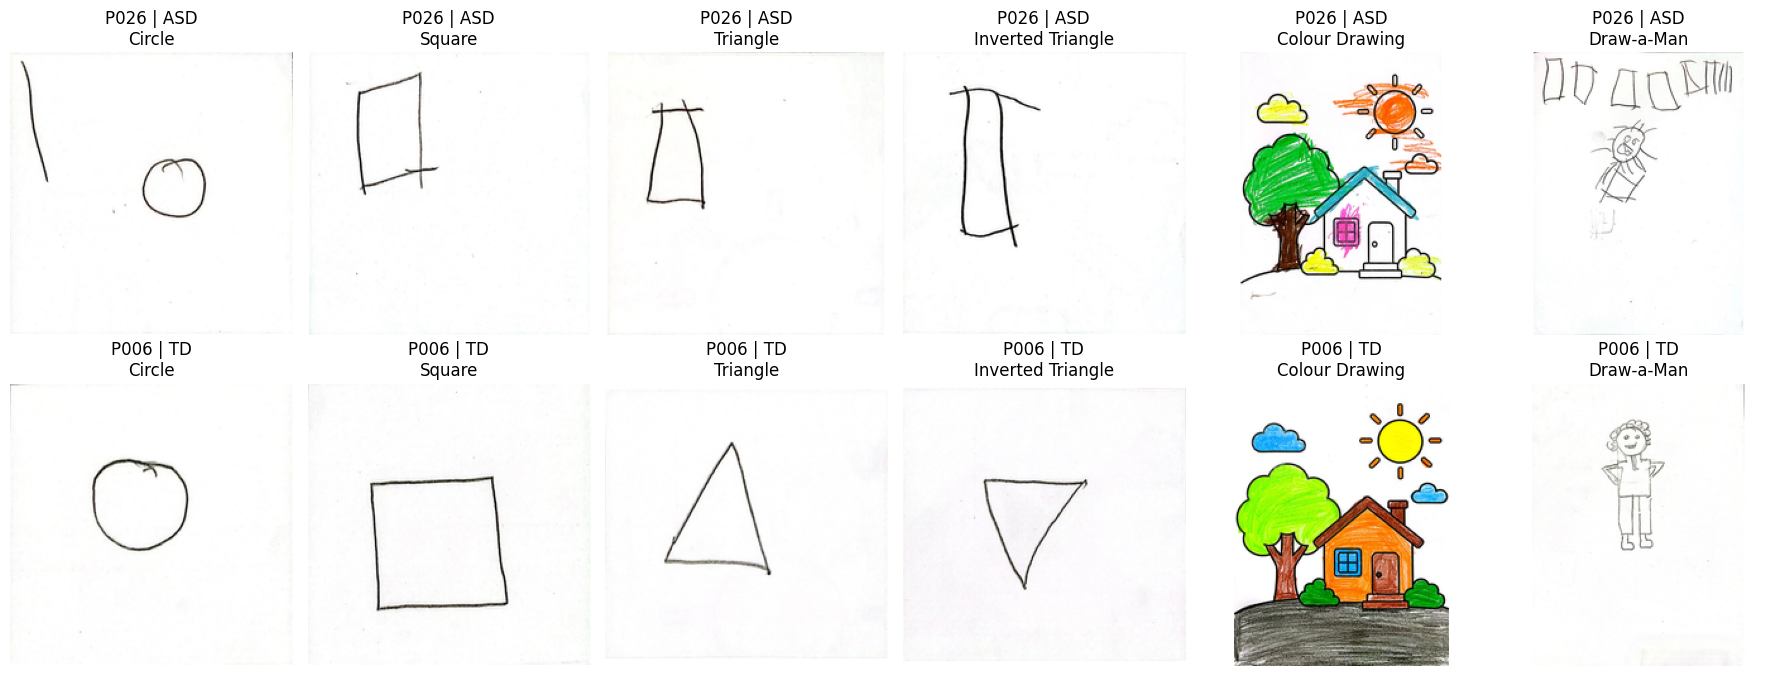

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# IMAGE SIZE
# ============================================================

IMG_SIZE = 224


# ============================================================
# LOAD IMAGE
# ============================================================

def load_rgb_image(path):
    """
    Load an image safely as RGB PIL image.
    No content-based cropping is performed here.
    """

    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"Image not found: {path}"
        )

    with Image.open(path) as img:
        return img.convert("RGB")


# ============================================================
# ASPECT-RATIO-PRESERVING RESIZE + WHITE PADDING
# ============================================================

def resize_pad_white(img, target_size=224):
    """
    Resize while preserving aspect ratio, then center on
    a white square canvas.

    Parameters
    ----------
    img : PIL.Image
        Input RGB image.

    target_size : int
        Final square size.

    Returns
    -------
    PIL.Image
        target_size × target_size RGB image.
    """

    if img.mode != "RGB":
        img = img.convert("RGB")

    original_width, original_height = img.size

    scale = target_size / max(
        original_width,
        original_height
    )

    new_width = max(
        1,
        int(round(original_width * scale))
    )

    new_height = max(
        1,
        int(round(original_height * scale))
    )

    resized = img.resize(
        (new_width, new_height),
        resample=Image.Resampling.LANCZOS
    )

    canvas = Image.new(
        "RGB",
        (target_size, target_size),
        color=(255, 255, 255)
    )

    left = (
        target_size - new_width
    ) // 2

    top = (
        target_size - new_height
    ) // 2

    canvas.paste(
        resized,
        (left, top)
    )

    return canvas


# ============================================================
# TEST OUTPUT DIMENSIONS FOR ALL 204 IMAGES
# ============================================================

preprocess_errors = []

for _, row in master_df.iterrows():

    participant_id = row["Participant_ID"]

    for column_name, modality_name in IMAGE_COLUMNS.items():

        try:

            img = load_rgb_image(
                row[column_name]
            )

            processed = resize_pad_white(
                img,
                target_size=IMG_SIZE
            )

            if processed.size != (
                IMG_SIZE,
                IMG_SIZE
            ):

                raise ValueError(
                    f"Unexpected processed size: "
                    f"{processed.size}"
                )

            if processed.mode != "RGB":

                raise ValueError(
                    f"Unexpected processed mode: "
                    f"{processed.mode}"
                )

        except Exception as e:

            preprocess_errors.append({
                "Participant_ID": participant_id,
                "Modality": modality_name,
                "Error": str(e)
            })


print("=" * 70)
print("SPATIAL PREPROCESSING VALIDATION")
print("=" * 70)

print(
    "Images checked:",
    len(master_df) * len(IMAGE_COLUMNS)
)

print(
    "Preprocessing errors:",
    len(preprocess_errors)
)

if len(preprocess_errors) == 0:
    print(
        "All images successfully converted to "
        "224 × 224 RGB inputs."
    )
else:
    display(
        pd.DataFrame(preprocess_errors)
    )


# ============================================================
# VISUAL SANITY CHECK
# One ASD and one TD participant
# ============================================================

asd_example = (
    master_df[
        master_df["Group"] == "ASD"
    ]
    .iloc[0]
)

td_example = (
    master_df[
        master_df["Group"] == "TD"
    ]
    .iloc[0]
)

example_rows = [
    asd_example,
    td_example
]

fig, axes = plt.subplots(
    2,
    6,
    figsize=(18, 7)
)

for row_idx, participant_row in enumerate(example_rows):

    for col_idx, (column_name, modality_name) in enumerate(
        IMAGE_COLUMNS.items()
    ):

        img = load_rgb_image(
            participant_row[column_name]
        )

        processed = resize_pad_white(
            img,
            target_size=IMG_SIZE
        )

        axes[row_idx, col_idx].imshow(
            processed
        )

        axes[row_idx, col_idx].axis(
            "off"
        )

        axes[row_idx, col_idx].set_title(
            f"{participant_row['Participant_ID']} | "
            f"{participant_row['Group']}\n"
            f"{modality_name}"
        )

plt.tight_layout()
plt.show()

## 8. Pretrained Visual Feature Extractors

Two pretrained visual backbones are used:

### EfficientNet-B0
Used for:
- Shape Drawing branch
- Colour Drawing branch

The ImageNet-pretrained classifier head is removed and the network is used as
a frozen feature extractor.

### DINOv2-small
Used for:
- Draw-a-Man branch

The pretrained DINOv2 transformer is also frozen and its CLS-token representation
is extracted for each Draw-a-Man image.

No participant labels are used during feature extraction.

The same deterministic 224 × 224 spatial preprocessing defined previously is
applied before model-specific normalization.

In [ ]:
# ============================================================
# INSTALL REQUIRED MODEL LIBRARIES
# ============================================================

!pip install -q timm transformers


# ============================================================
# IMPORTS
# ============================================================

import random
import numpy as np
import torch
import torchvision.transforms as T
import timm

from transformers import AutoImageProcessor, AutoModel


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Deterministic behavior where supported
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("PyTorch version:", torch.__version__)
print("timm version:", timm.__version__)


# ============================================================
# EFFICIENTNET-B0
# ============================================================

effnet_backbone = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=0
)

effnet_backbone = effnet_backbone.to(DEVICE)
effnet_backbone.eval()


# Freeze every EfficientNet parameter
for parameter in effnet_backbone.parameters():
    parameter.requires_grad = False


# Resolve normalization directly from the pretrained model
effnet_config = timm.data.resolve_model_data_config(
    effnet_backbone
)

EFFNET_MEAN = effnet_config["mean"]
EFFNET_STD = effnet_config["std"]

print("\nEfficientNet-B0:")
print("Output features:", effnet_backbone.num_features)
print("Mean:", EFFNET_MEAN)
print("Std:", EFFNET_STD)


# ============================================================
# EFFICIENTNET TENSOR TRANSFORM
# ============================================================

# Spatial resizing/padding has ALREADY been performed by
# resize_pad_white(), therefore we only convert to tensor and normalize.

effnet_tensor_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=EFFNET_MEAN,
        std=EFFNET_STD
    )
])


# ============================================================
# DINOV2-SMALL
# ============================================================

DINO_MODEL_NAME = "facebook/dinov2-small"

dino_processor = AutoImageProcessor.from_pretrained(
    DINO_MODEL_NAME
)

dino_backbone = AutoModel.from_pretrained(
    DINO_MODEL_NAME
)

dino_backbone = dino_backbone.to(DEVICE)
dino_backbone.eval()


# Freeze every DINOv2 parameter
for parameter in dino_backbone.parameters():
    parameter.requires_grad = False


print("\nDINOv2-small:")
print(
    "Hidden size:",
    dino_backbone.config.hidden_size
)

print(
    "Processor mean:",
    dino_processor.image_mean
)

print(
    "Processor std:",
    dino_processor.image_std
)


# ============================================================
# VERIFY THAT MODELS ARE FROZEN
# ============================================================

effnet_trainable = sum(
    p.numel()
    for p in effnet_backbone.parameters()
    if p.requires_grad
)

dino_trainable = sum(
    p.numel()
    for p in dino_backbone.parameters()
    if p.requires_grad
)


print("\nTrainable parameters:")
print("EfficientNet-B0:", effnet_trainable)
print("DINOv2-small:", dino_trainable)


assert effnet_trainable == 0
assert dino_trainable == 0

print("\nBoth pretrained backbones are successfully frozen.")

Device: cuda
PyTorch version: 2.11.0+cu128
timm version: 1.0.28


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            


EfficientNet-B0:
Output features: 1280
Mean: (0.485, 0.456, 0.406)
Std: (0.229, 0.224, 0.225)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]


DINOv2-small:
Hidden size: 384
Processor mean: (0.485, 0.456, 0.406)
Processor std: (0.229, 0.224, 0.225)

Trainable parameters:
EfficientNet-B0: 0
DINOv2-small: 0

Both pretrained backbones are successfully frozen.


## 9. Define and Validate Visual Embedding Extraction

The pretrained visual backbones are now used to convert each drawing into a
fixed-dimensional feature representation.

### EfficientNet-B0

Used for Shape and Colour drawings.

Each preprocessed 224 × 224 RGB image produces a:

**1280-dimensional embedding**

### DINOv2-small

Used for Draw-a-Man drawings.

The CLS token from the final transformer representation is used as the
participant image embedding:

**384-dimensional embedding**

The spatial preprocessing remains identical to the previous section.
No additional cropping, stretching, random augmentation, or label-dependent
processing is performed.

The extraction functions are first tested on a single participant and checked
for:

- expected embedding dimensions
- finite numerical values
- deterministic repeated output

In [ ]:
# ============================================================
# DINOv2 TENSOR TRANSFORM
# ============================================================

# We already converted each image to a spatially standardized
# 224 × 224 image ourselves.
#
# Therefore we DO NOT allow the Hugging Face processor to
# resize or center-crop the image again.
#
# We only perform tensor conversion + the normalization values
# specified by the pretrained DINOv2 processor.

dino_tensor_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=dino_processor.image_mean,
        std=dino_processor.image_std
    )
])


# ============================================================
# EFFICIENTNET EMBEDDING FUNCTION
# ============================================================

@torch.inference_mode()
def extract_effnet_embedding(image_path):
    """
    Extract one frozen EfficientNet-B0 embedding.

    Returns
    -------
    numpy.ndarray
        Shape: (1280,)
    """

    # Load original manually-cropped image
    img = load_rgb_image(
        image_path
    )

    # Preserve aspect ratio and white-pad to 224 × 224
    img = resize_pad_white(
        img,
        target_size=IMG_SIZE
    )

    # Convert to normalized tensor
    x = effnet_tensor_transform(
        img
    )

    x = x.unsqueeze(0).to(
        DEVICE
    )

    # Frozen backbone forward pass
    embedding = effnet_backbone(
        x
    )

    embedding = (
        embedding
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    # Safety checks
    if embedding.shape != (
        effnet_backbone.num_features,
    ):
        raise ValueError(
            f"Unexpected EfficientNet embedding shape: "
            f"{embedding.shape}"
        )

    if not np.isfinite(
        embedding
    ).all():
        raise ValueError(
            "EfficientNet embedding contains "
            "NaN or infinite values."
        )

    return embedding


# ============================================================
# DINOV2 EMBEDDING FUNCTION
# ============================================================

@torch.inference_mode()
def extract_dinov2_embedding(image_path):
    """
    Extract the CLS-token representation from frozen
    DINOv2-small.

    Returns
    -------
    numpy.ndarray
        Shape: (384,)
    """

    # Load original manually-cropped image
    img = load_rgb_image(
        image_path
    )

    # Use the SAME aspect-ratio-preserving spatial preprocessing
    img = resize_pad_white(
        img,
        target_size=IMG_SIZE
    )

    # Convert to normalized tensor
    pixel_values = dino_tensor_transform(
        img
    )

    pixel_values = (
        pixel_values
        .unsqueeze(0)
        .to(DEVICE)
    )

    # Frozen DINOv2 forward pass
    outputs = dino_backbone(
        pixel_values=pixel_values
    )

    # CLS token = first token
    embedding = (
        outputs
        .last_hidden_state[:, 0, :]
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    expected_size = (
        dino_backbone.config.hidden_size
    )

    # Safety checks
    if embedding.shape != (
        expected_size,
    ):
        raise ValueError(
            f"Unexpected DINOv2 embedding shape: "
            f"{embedding.shape}"
        )

    if not np.isfinite(
        embedding
    ).all():
        raise ValueError(
            "DINOv2 embedding contains "
            "NaN or infinite values."
        )

    return embedding


# ============================================================
# SINGLE-PARTICIPANT SANITY TEST
# ============================================================

test_row = master_df.iloc[0]

test_pid = test_row[
    "Participant_ID"
]

print("=" * 70)
print("VISUAL EMBEDDING SANITY TEST")
print("=" * 70)

print(
    "Test participant:",
    test_pid,
    "| Group:",
    test_row["Group"]
)


# ------------------------------------------------------------
# EfficientNet test — Circle
# ------------------------------------------------------------

eff_embedding_1 = (
    extract_effnet_embedding(
        test_row["circle"]
    )
)

eff_embedding_2 = (
    extract_effnet_embedding(
        test_row["circle"]
    )
)

print("\nEfficientNet-B0:")
print(
    "Embedding shape:",
    eff_embedding_1.shape
)

print(
    "Data type:",
    eff_embedding_1.dtype
)

print(
    "All finite:",
    np.isfinite(
        eff_embedding_1
    ).all()
)

print(
    "Repeated extraction identical:",
    np.allclose(
        eff_embedding_1,
        eff_embedding_2,
        rtol=1e-6,
        atol=1e-7
    )
)

print(
    "L2 norm:",
    round(
        float(
            np.linalg.norm(
                eff_embedding_1
            )
        ),
        4
    )
)


# ------------------------------------------------------------
# DINOv2 test — Draw-a-Man
# ------------------------------------------------------------

dino_embedding_1 = (
    extract_dinov2_embedding(
        test_row["draw_man"]
    )
)

dino_embedding_2 = (
    extract_dinov2_embedding(
        test_row["draw_man"]
    )
)

print("\nDINOv2-small:")
print(
    "Embedding shape:",
    dino_embedding_1.shape
)

print(
    "Data type:",
    dino_embedding_1.dtype
)

print(
    "All finite:",
    np.isfinite(
        dino_embedding_1
    ).all()
)

print(
    "Repeated extraction identical:",
    np.allclose(
        dino_embedding_1,
        dino_embedding_2,
        rtol=1e-6,
        atol=1e-7
    )
)

print(
    "L2 norm:",
    round(
        float(
            np.linalg.norm(
                dino_embedding_1
            )
        ),
        4
    )
)

VISUAL EMBEDDING SANITY TEST
Test participant: P026 | Group: ASD

EfficientNet-B0:
Embedding shape: (1280,)
Data type: float32
All finite: True
Repeated extraction identical: True
L2 norm: 13.3564

DINOv2-small:
Embedding shape: (384,)
Data type: float32
All finite: True
Repeated extraction identical: True
L2 norm: 43.3183


## 10. Extract and Cache Visual Embeddings for the Full Cohort

Frozen pretrained representations are extracted for every participant.

For each participant:

### Shape branch
Four independent EfficientNet-B0 embeddings are extracted:

- Circle: 1280 features
- Square: 1280 features
- Triangle: 1280 features
- Inverted Triangle: 1280 features

These embeddings are kept separately at this stage. They will later be combined
at participant level.

### Colour branch

- Colour Drawing: 1280 EfficientNet-B0 features

### Draw-a-Man branch

- Draw-a-Man: 384 DINOv2-small features

The extraction is deterministic and does not use participant labels.

The resulting matrices are cached to Google Drive so that later experiments can
be reproduced without repeatedly running the pretrained backbones.

In [ ]:
import os
import numpy as np
import pandas as pd

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "Final_ASD_Outputs"
)

EMBEDDING_DIR = os.path.join(
    OUTPUT_DIR,
    "embeddings"
)

os.makedirs(
    EMBEDDING_DIR,
    exist_ok=True
)


# ============================================================
# FIX PARTICIPANT ORDER FOR ALL DOWNSTREAM EXPERIMENTS
# ============================================================

primary_df = (
    master_df
    .sort_values("Participant_ID")
    .reset_index(drop=True)
    .copy()
)

participant_ids = (
    primary_df["Participant_ID"]
    .to_numpy()
)

groups = (
    primary_df["Group"]
    .to_numpy()
)

y = (
    primary_df["Label"]
    .to_numpy(dtype=np.int64)
)


print("=" * 70)
print("FULL-COHORT VISUAL EMBEDDING EXTRACTION")
print("=" * 70)

print(
    "Participants:",
    len(primary_df)
)

print(
    "TD:",
    int((y == 0).sum())
)

print(
    "ASD:",
    int((y == 1).sum())
)


# ============================================================
# STORAGE LISTS
# ============================================================

circle_embeddings = []
square_embeddings = []
triangle_embeddings = []
inv_triangle_embeddings = []

colour_embeddings = []

dam_embeddings = []


# ============================================================
# EXTRACT
# ============================================================

for idx, row in primary_df.iterrows():

    pid = row["Participant_ID"]

    print(
        f"[{idx + 1:02d}/{len(primary_df)}] "
        f"Extracting {pid} ..."
    )

    # --------------------------------------------------------
    # Shape branch — EfficientNet-B0
    # --------------------------------------------------------

    circle_embeddings.append(
        extract_effnet_embedding(
            row["circle"]
        )
    )

    square_embeddings.append(
        extract_effnet_embedding(
            row["square"]
        )
    )

    triangle_embeddings.append(
        extract_effnet_embedding(
            row["triangle"]
        )
    )

    inv_triangle_embeddings.append(
        extract_effnet_embedding(
            row["inv_triangle"]
        )
    )

    # --------------------------------------------------------
    # Colour branch — EfficientNet-B0
    # --------------------------------------------------------

    colour_embeddings.append(
        extract_effnet_embedding(
            row["colour_drawing"]
        )
    )

    # --------------------------------------------------------
    # DAM branch — DINOv2-small
    # --------------------------------------------------------

    dam_embeddings.append(
        extract_dinov2_embedding(
            row["draw_man"]
        )
    )


# ============================================================
# CONVERT TO NUMPY MATRICES
# ============================================================

X_circle = np.stack(
    circle_embeddings
).astype(np.float32)

X_square = np.stack(
    square_embeddings
).astype(np.float32)

X_triangle = np.stack(
    triangle_embeddings
).astype(np.float32)

X_inv_triangle = np.stack(
    inv_triangle_embeddings
).astype(np.float32)

X_colour_cnn = np.stack(
    colour_embeddings
).astype(np.float32)

X_dam_dino = np.stack(
    dam_embeddings
).astype(np.float32)


# ============================================================
# STRICT SHAPE CHECKS
# ============================================================

N = len(primary_df)

expected_shapes = {

    "Circle":
        (N, 1280),

    "Square":
        (N, 1280),

    "Triangle":
        (N, 1280),

    "Inverted Triangle":
        (N, 1280),

    "Colour":
        (N, 1280),

    "DAM":
        (N, 384)
}


actual_matrices = {

    "Circle":
        X_circle,

    "Square":
        X_square,

    "Triangle":
        X_triangle,

    "Inverted Triangle":
        X_inv_triangle,

    "Colour":
        X_colour_cnn,

    "DAM":
        X_dam_dino
}


print("\nEmbedding matrix validation:")

for name, matrix in actual_matrices.items():

    expected = expected_shapes[name]

    print(
        f"{name:18s} "
        f"shape={matrix.shape} | "
        f"finite={np.isfinite(matrix).all()}"
    )

    if matrix.shape != expected:

        raise ValueError(
            f"{name} matrix has unexpected shape "
            f"{matrix.shape}; expected {expected}"
        )

    if not np.isfinite(matrix).all():

        raise ValueError(
            f"{name} matrix contains "
            f"NaN or infinite values."
        )


# ============================================================
# SAVE EMBEDDINGS
# ============================================================

embedding_file = os.path.join(
    EMBEDDING_DIR,
    "visual_embeddings.npz"
)

np.savez_compressed(

    embedding_file,

    participant_ids=participant_ids,

    groups=groups,

    labels=y,

    circle=X_circle,

    square=X_square,

    triangle=X_triangle,

    inv_triangle=X_inv_triangle,

    colour_cnn=X_colour_cnn,

    dam_dino=X_dam_dino
)


# ============================================================
# SAVE PARTICIPANT ORDER / METADATA
# ============================================================

metadata_file = os.path.join(
    EMBEDDING_DIR,
    "embedding_participants.csv"
)

primary_df[
    [
        "Participant_ID",
        "Age",
        "Gender",
        "Group",
        "Label"
    ]
].to_csv(
    metadata_file,
    index=False
)


# ============================================================
# VERIFY SAVED FILE
# ============================================================

saved = np.load(
    embedding_file,
    allow_pickle=False
)

print("\nSaved-file verification:")

print(
    "Saved arrays:",
    saved.files
)

print(
    "Saved participant count:",
    len(saved["participant_ids"])
)

print(
    "Saved labels identical:",
    np.array_equal(
        saved["labels"],
        y
    )
)

print(
    "Saved Circle matrix identical:",
    np.allclose(
        saved["circle"],
        X_circle
    )
)


print("\nFiles saved:")

print(
    embedding_file
)

print(
    metadata_file
)

print(
    "\nVisual embedding extraction completed successfully."
)

FULL-COHORT VISUAL EMBEDDING EXTRACTION
Participants: 34
TD: 20
ASD: 14
[01/34] Extracting P006 ...
[02/34] Extracting P007 ...
[03/34] Extracting P008 ...
[04/34] Extracting P009 ...
[05/34] Extracting P010 ...
[06/34] Extracting P011 ...
[07/34] Extracting P012 ...
[08/34] Extracting P013 ...
[09/34] Extracting P014 ...
[10/34] Extracting P015 ...
[11/34] Extracting P016 ...
[12/34] Extracting P017 ...
[13/34] Extracting P018 ...
[14/34] Extracting P019 ...
[15/34] Extracting P020 ...
[16/34] Extracting P021 ...
[17/34] Extracting P022 ...
[18/34] Extracting P023 ...
[19/34] Extracting P024 ...
[20/34] Extracting P025 ...
[21/34] Extracting P026 ...
[22/34] Extracting P027 ...
[23/34] Extracting P028 ...
[24/34] Extracting P029 ...
[25/34] Extracting P030 ...
[26/34] Extracting P031 ...
[27/34] Extracting P032 ...
[28/34] Extracting P033 ...
[29/34] Extracting P034 ...
[30/34] Extracting P035 ...
[31/34] Extracting P036 ...
[32/34] Extracting P037 ...
[33/34] Extracting P038 ...
[34/

ValueError: Object arrays cannot be loaded when allow_pickle=False

### 10.1 Correct Safe Serialization of Embedding Metadata

The visual embeddings were extracted successfully.

Participant IDs and group names were initially stored as NumPy object arrays,
which cannot be loaded with `allow_pickle=False`.

To keep the cached embedding file portable and safely loadable without Python
pickle serialization, participant IDs and group labels are explicitly stored
as Unicode string arrays.

No visual features are re-extracted in this step.

In [ ]:
# ============================================================
# SAFE STRING REPRESENTATION
# ============================================================

participant_ids_safe = (
    primary_df["Participant_ID"]
    .astype(str)
    .to_numpy(dtype="<U16")
)

groups_safe = (
    primary_df["Group"]
    .astype(str)
    .to_numpy(dtype="<U8")
)

labels_safe = (
    primary_df["Label"]
    .to_numpy(dtype=np.int64)
)


print("Metadata dtypes:")
print("participant_ids:", participant_ids_safe.dtype)
print("groups:", groups_safe.dtype)
print("labels:", labels_safe.dtype)


# ============================================================
# OVERWRITE EMBEDDING FILE SAFELY
# ============================================================

embedding_file = os.path.join(
    EMBEDDING_DIR,
    "visual_embeddings.npz"
)

np.savez_compressed(
    embedding_file,

    participant_ids=participant_ids_safe,
    groups=groups_safe,
    labels=labels_safe,

    circle=X_circle.astype(np.float32),
    square=X_square.astype(np.float32),
    triangle=X_triangle.astype(np.float32),
    inv_triangle=X_inv_triangle.astype(np.float32),

    colour_cnn=X_colour_cnn.astype(np.float32),

    dam_dino=X_dam_dino.astype(np.float32)
)


# ============================================================
# SAFE RELOAD
# ============================================================

with np.load(
    embedding_file,
    allow_pickle=False
) as saved:

    print("\nSaved-file verification:")

    print(
        "Saved arrays:",
        saved.files
    )

    print(
        "Saved participant count:",
        len(saved["participant_ids"])
    )

    print(
        "Participant IDs identical:",
        np.array_equal(
            saved["participant_ids"],
            participant_ids_safe
        )
    )

    print(
        "Groups identical:",
        np.array_equal(
            saved["groups"],
            groups_safe
        )
    )

    print(
        "Labels identical:",
        np.array_equal(
            saved["labels"],
            labels_safe
        )
    )

    print(
        "Circle matrix identical:",
        np.allclose(
            saved["circle"],
            X_circle
        )
    )

    print(
        "Square matrix identical:",
        np.allclose(
            saved["square"],
            X_square
        )
    )

    print(
        "Triangle matrix identical:",
        np.allclose(
            saved["triangle"],
            X_triangle
        )
    )

    print(
        "Inverted Triangle matrix identical:",
        np.allclose(
            saved["inv_triangle"],
            X_inv_triangle
        )
    )

    print(
        "Colour matrix identical:",
        np.allclose(
            saved["colour_cnn"],
            X_colour_cnn
        )
    )

    print(
        "DAM matrix identical:",
        np.allclose(
            saved["dam_dino"],
            X_dam_dino
        )
    )


print("\nEmbedding cache saved safely:")
print(embedding_file)

print(
    "\nVisual embedding cache verification completed successfully."
)

Metadata dtypes:
participant_ids: <U16
groups: <U8
labels: int64

Saved-file verification:
Saved arrays: ['participant_ids', 'groups', 'labels', 'circle', 'square', 'triangle', 'inv_triangle', 'colour_cnn', 'dam_dino']
Saved participant count: 34
Participant IDs identical: True
Groups identical: True
Labels identical: True
Circle matrix identical: True
Square matrix identical: True
Triangle matrix identical: True
Inverted Triangle matrix identical: True
Colour matrix identical: True
DAM matrix identical: True

Embedding cache saved safely:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/embeddings/visual_embeddings.npz

Visual embedding cache verification completed successfully.


## 11. Construct the Participant-Level Shape Representation

The Shape branch uses four standardized drawing tasks:

- Circle
- Square
- Triangle
- Inverted Triangle

Each drawing has already been converted into a 1280-dimensional frozen
EfficientNet-B0 embedding.

For each participant, the four embeddings are averaged element-wise to obtain
one participant-level Shape representation:

**4 × 1280 embeddings → mean aggregation → 1280 Shape features**

This aggregation:

- keeps one observation per participant
- prevents individual drawings from being treated as independent children
- reduces dimensionality compared with concatenating all four embeddings
- limits overfitting risk in the current small pilot cohort

No labels are used during this aggregation step.

In [ ]:
# ============================================================
# PARTICIPANT-LEVEL SHAPE REPRESENTATION
# ============================================================

# Stack the four shape representations:
# shape = (participants, 4 drawings, 1280 features)

shape_stack = np.stack(
    [
        X_circle,
        X_square,
        X_triangle,
        X_inv_triangle
    ],
    axis=1
)

print("=" * 70)
print("SHAPE BRANCH FEATURE CONSTRUCTION")
print("=" * 70)

print(
    "Four-shape stack:",
    shape_stack.shape
)


# ============================================================
# MEAN AGGREGATION ACROSS THE FOUR DRAWINGS
# ============================================================

X_shape = (
    shape_stack
    .mean(axis=1)
    .astype(np.float32)
)

y_shape = y.copy()


# ============================================================
# STRICT VALIDATION
# ============================================================

expected_shape = (
    len(primary_df),
    1280
)

if X_shape.shape != expected_shape:
    raise ValueError(
        f"Unexpected Shape feature matrix size: "
        f"{X_shape.shape}; expected {expected_shape}"
    )

if not np.isfinite(X_shape).all():
    raise ValueError(
        "Shape feature matrix contains NaN or infinite values."
    )

if not np.array_equal(
    y_shape,
    primary_df["Label"].to_numpy(dtype=np.int64)
):
    raise ValueError(
        "Shape labels are not aligned with participant order."
    )


print(
    "Participant-level Shape matrix:",
    X_shape.shape
)

print(
    "All values finite:",
    np.isfinite(X_shape).all()
)

print(
    "Participants:",
    len(X_shape)
)

print(
    "TD:",
    int((y_shape == 0).sum())
)

print(
    "ASD:",
    int((y_shape == 1).sum())
)


# ============================================================
# CHECK THAT AGGREGATION IS CORRECT
# ============================================================

manual_first = (
    X_circle[0]
    + X_square[0]
    + X_triangle[0]
    + X_inv_triangle[0]
) / 4.0

print(
    "\nFirst participant:",
    participant_ids_safe[0]
)

print(
    "Mean aggregation verified:",
    np.allclose(
        X_shape[0],
        manual_first,
        rtol=1e-6,
        atol=1e-7
    )
)


# ============================================================
# SAVE SHAPE REPRESENTATION
# ============================================================

shape_feature_file = os.path.join(
    EMBEDDING_DIR,
    "shape_participant_features.npz"
)

np.savez_compressed(
    shape_feature_file,
    participant_ids=participant_ids_safe,
    labels=labels_safe,
    X_shape=X_shape
)


# Safe reload verification
with np.load(
    shape_feature_file,
    allow_pickle=False
) as shape_saved:

    print(
        "Saved Shape matrix identical:",
        np.allclose(
            shape_saved["X_shape"],
            X_shape
        )
    )

    print(
        "Saved labels identical:",
        np.array_equal(
            shape_saved["labels"],
            y_shape
        )
    )


print(
    "\nSaved:",
    shape_feature_file
)

print(
    "\nShape participant representation created successfully."
)

SHAPE BRANCH FEATURE CONSTRUCTION
Four-shape stack: (34, 4, 1280)
Participant-level Shape matrix: (34, 1280)
All values finite: True
Participants: 34
TD: 20
ASD: 14

First participant: P006
Mean aggregation verified: True
Saved Shape matrix identical: True
Saved labels identical: True

Saved: /content/drive/MyDrive/Autism detection/Final_ASD_Outputs/embeddings/shape_participant_features.npz

Shape participant representation created successfully.


## 12. Model 1 — Leakage-Safe Nested Cross-Validation

The participant-level Shape representation is classified using Logistic
Regression.

Because the number of participants is small relative to the number of visual
features, strong regularization is required.

A nested cross-validation procedure is used:

### Outer cross-validation

Stratified 5-fold cross-validation estimates generalization performance.

Each participant appears in the outer test set exactly once.

### Inner cross-validation

Within each outer-training fold only, Logistic Regression regularization
strength (`C`) is selected using stratified inner cross-validation.

### Leakage prevention

For every outer fold:

- the StandardScaler is fitted only on the outer-training participants
- hyperparameter selection uses only the outer-training participants
- the outer-test participants are never used for scaling or model selection
- the final probability for each participant is therefore genuinely
  out-of-fold

The Shape branch outputs:

`P_shape_ASD`

Initial classification metrics are reported using the conventional probability
threshold of 0.50. Threshold optimization is performed separately later and is
not used to inflate this branch evaluation.

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pandas as pd
import numpy as np
import os


# ============================================================
# CROSS-VALIDATION CONFIGURATION
# ============================================================

OUTER_FOLDS = 5
INNER_FOLDS = 4

# Regularization strengths to evaluate.
# Smaller C = stronger regularization.
C_GRID = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]


# ============================================================
# OUTER CV
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


# One final out-of-fold probability per participant
shape_oof_proba = np.full(
    len(y_shape),
    np.nan,
    dtype=np.float64
)

shape_oof_pred = np.full(
    len(y_shape),
    -1,
    dtype=np.int64
)

shape_outer_fold = np.full(
    len(y_shape),
    -1,
    dtype=np.int64
)

shape_fold_results = []


print("=" * 70)
print("MODEL 1 — SHAPE BRANCH NESTED CROSS-VALIDATION")
print("=" * 70)


for fold_number, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_shape,
        y_shape
    ),
    start=1
):

    X_train = X_shape[train_idx]
    X_test = X_shape[test_idx]

    y_train = y_shape[train_idx]
    y_test = y_shape[test_idx]


    # --------------------------------------------------------
    # SAFETY CHECK — NO PARTICIPANT OVERLAP
    # --------------------------------------------------------

    train_ids = set(
        participant_ids_safe[train_idx]
    )

    test_ids = set(
        participant_ids_safe[test_idx]
    )

    overlap = (
        train_ids
        &
        test_ids
    )

    if overlap:
        raise RuntimeError(
            f"Participant leakage detected "
            f"in outer fold {fold_number}: "
            f"{overlap}"
        )


    # --------------------------------------------------------
    # INNER CV
    # --------------------------------------------------------

    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=(
            SEED + fold_number
        )
    )


    # --------------------------------------------------------
    # PIPELINE
    #
    # StandardScaler is INSIDE the pipeline.
    # Therefore it is refitted correctly during every
    # inner and outer training operation.
    # --------------------------------------------------------

    shape_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    # --------------------------------------------------------
    # INNER HYPERPARAMETER SEARCH
    # --------------------------------------------------------

    param_grid = {
        "classifier__C": C_GRID
    }


    grid_search = GridSearchCV(
        estimator=shape_pipeline,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
        return_train_score=False
    )


    # IMPORTANT:
    # fit ONLY on outer-training participants
    grid_search.fit(
        X_train,
        y_train
    )


    best_model = (
        grid_search.best_estimator_
    )

    best_c = (
        grid_search.best_params_[
            "classifier__C"
        ]
    )


    # --------------------------------------------------------
    # PREDICT COMPLETELY HELD-OUT OUTER TEST PARTICIPANTS
    # --------------------------------------------------------

    test_proba = (
        best_model
        .predict_proba(X_test)[:, 1]
    )

    test_pred = (
        test_proba >= 0.50
    ).astype(np.int64)


    # Store OOF values
    shape_oof_proba[
        test_idx
    ] = test_proba

    shape_oof_pred[
        test_idx
    ] = test_pred

    shape_outer_fold[
        test_idx
    ] = fold_number


    # --------------------------------------------------------
    # FOLD METRICS
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fold_auc = roc_auc_score(
        y_test,
        test_proba
    )


    shape_fold_results.append({
        "Fold": fold_number,
        "Train_N": len(train_idx),
        "Test_N": len(test_idx),
        "Train_TD": int(
            (y_train == 0).sum()
        ),
        "Train_ASD": int(
            (y_train == 1).sum()
        ),
        "Test_TD": int(
            (y_test == 0).sum()
        ),
        "Test_ASD": int(
            (y_test == 1).sum()
        ),
        "Best_C": best_c,
        "AUC": fold_auc,
        "Recall": recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "Specificity": specificity
    })


    print(
        f"Fold {fold_number}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}, "
        f"Best C={best_c}, "
        f"AUC={fold_auc:.3f}"
    )


# ============================================================
# STRICT OOF VALIDATION
# ============================================================

if np.isnan(
    shape_oof_proba
).any():

    raise RuntimeError(
        "Some participants did not receive "
        "an out-of-fold Shape probability."
    )


if (
    shape_outer_fold < 1
).any():

    raise RuntimeError(
        "Some participants were not assigned "
        "to an outer test fold."
    )


if not np.all(
    (
        shape_oof_proba >= 0.0
    )
    &
    (
        shape_oof_proba <= 1.0
    )
):

    raise RuntimeError(
        "Invalid Shape probabilities detected."
    )


# ============================================================
# OVERALL OUT-OF-FOLD METRICS
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_shape,
    shape_oof_pred,
    labels=[0, 1]
).ravel()


shape_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)


shape_metrics = {
    "Accuracy":
        accuracy_score(
            y_shape,
            shape_oof_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_shape,
            shape_oof_pred
        ),

    "Precision":
        precision_score(
            y_shape,
            shape_oof_pred,
            zero_division=0
        ),

    "Recall_Sensitivity":
        recall_score(
            y_shape,
            shape_oof_pred,
            zero_division=0
        ),

    "Specificity":
        shape_specificity,

    "F1":
        f1_score(
            y_shape,
            shape_oof_pred,
            zero_division=0
        ),

    "AUC_ROC":
        roc_auc_score(
            y_shape,
            shape_oof_proba
        )
}


# ============================================================
# RESULTS TABLES
# ============================================================

shape_fold_results_df = pd.DataFrame(
    shape_fold_results
)

shape_predictions_df = pd.DataFrame({
    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_shape,

    "Outer_Fold":
        shape_outer_fold,

    "P_shape_ASD":
        shape_oof_proba,

    "Predicted_Label_0.5":
        shape_oof_pred
})


print("\nFold-level results:")
display(
    shape_fold_results_df
    .round(4)
)


print("\nOverall out-of-fold performance:")
for metric_name, metric_value in shape_metrics.items():

    print(
        f"{metric_name:22s}: "
        f"{metric_value:.4f}"
    )


print("\nConfusion matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print(
    "\nFormat: "
    "[[TN, FP], [FN, TP]]"
)


print("\nParticipant-level OOF predictions:")
display(
    shape_predictions_df
    .sort_values(
        "Participant_ID"
    )
    .round({
        "P_shape_ASD": 4
    })
)


# ============================================================
# SAVE RESULTS
# ============================================================

RESULTS_DIR = os.path.join(
    OUTPUT_DIR,
    "results"
)

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


shape_predictions_file = os.path.join(
    RESULTS_DIR,
    "shape_oof_predictions.csv"
)

shape_fold_file = os.path.join(
    RESULTS_DIR,
    "shape_nested_cv_folds.csv"
)

shape_metrics_file = os.path.join(
    RESULTS_DIR,
    "shape_metrics.csv"
)


shape_predictions_df.to_csv(
    shape_predictions_file,
    index=False
)

shape_fold_results_df.to_csv(
    shape_fold_file,
    index=False
)

pd.DataFrame(
    [shape_metrics]
).to_csv(
    shape_metrics_file,
    index=False
)


print("\nSaved:")
print(shape_predictions_file)
print(shape_fold_file)
print(shape_metrics_file)

print(
    "\nModel 1 nested cross-validation completed successfully."
)

MODEL 1 — SHAPE BRANCH NESTED CROSS-VALIDATION
Fold 1: train=27, test=7, Best C=0.001, AUC=0.667
Fold 2: train=27, test=7, Best C=0.001, AUC=1.000
Fold 3: train=27, test=7, Best C=0.001, AUC=1.000
Fold 4: train=27, test=7, Best C=0.1, AUC=0.667
Fold 5: train=28, test=6, Best C=0.001, AUC=1.000

Fold-level results:


,Fold,Train_N,Test_N,Train_TD,Train_ASD,Test_TD,Test_ASD,Best_C,AUC,Recall,Specificity
0,1,27,7,16,11,4,3,0.001,0.6667,0.6667,1.00
1,2,27,7,16,11,4,3,0.001,1.0000,1.0000,1.00
2,3,27,7,16,11,4,3,0.001,1.0000,1.0000,0.75
3,4,27,7,16,11,4,3,0.100,0.6667,0.6667,0.75
4,5,28,6,16,12,4,2,0.001,1.0000,1.0000,0.75



Overall out-of-fold performance:
Accuracy              : 0.8529
Balanced_Accuracy     : 0.8536
Precision             : 0.8000
Recall_Sensitivity    : 0.8571
Specificity           : 0.8500
F1                    : 0.8276
AUC_ROC               : 0.8714

Confusion matrix:
[[17  3]
 [ 2 12]]

Format: [[TN, FP], [FN, TP]]

Participant-level OOF predictions:


,Participant_ID,Group,True_Label,Outer_Fold,P_shape_ASD,Predicted_Label_0.5
0,P006,TD,0,1,0.3557,0
1,P007,TD,0,5,0.3510,0
2,P008,TD,0,4,0.1818,0
3,P009,TD,0,1,0.4148,0
4,P010,TD,0,3,0.3392,0
5,P011,TD,0,2,0.2807,0
6,P012,TD,0,3,0.3189,0
7,P013,TD,0,1,0.3128,0
8,P014,TD,0,5,0.2283,0
9,P015,TD,0,5,0.3005,0



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_oof_predictions.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_nested_cv_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_metrics.csv

Model 1 nested cross-validation completed successfully.


## 13. Model 1 — Out-of-Fold Evaluation and Visualization

Model 1 performance is evaluated exclusively from nested-cross-validation
out-of-fold predictions.

The following visualizations are generated:

- ROC curve
- confusion matrix
- participant-level ASD probability distribution

The probability threshold of 0.50 is used only as the conventional initial
binary classification threshold.

No threshold is optimized using these evaluation predictions.

Because the cohort is small, the reported results are interpreted as pilot
performance estimates rather than definitive clinical performance.

MODEL 1 — FINAL OOF SUMMARY
Accuracy:             0.8529
Balanced accuracy:    0.8536
Precision:            0.8000
Recall / Sensitivity: 0.8571
Specificity:          0.8500
F1-score:             0.8276
ROC-AUC:              0.8714
PR-AUC:               0.9186


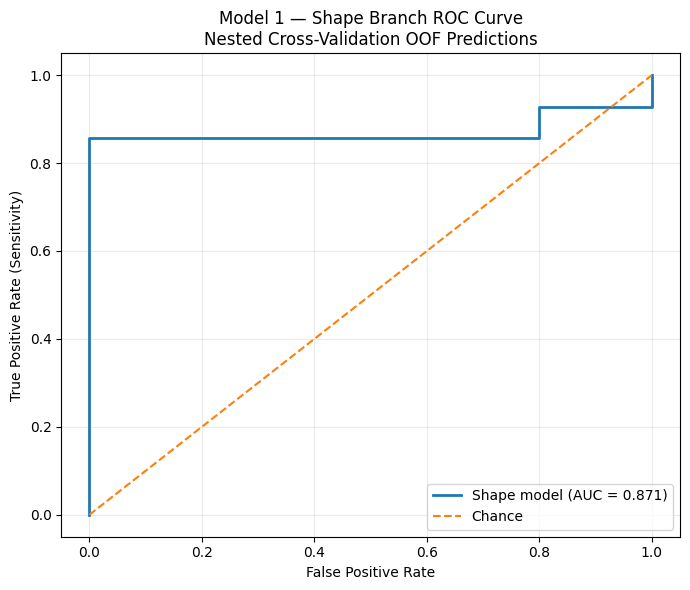

<Figure size 600x500 with 0 Axes>

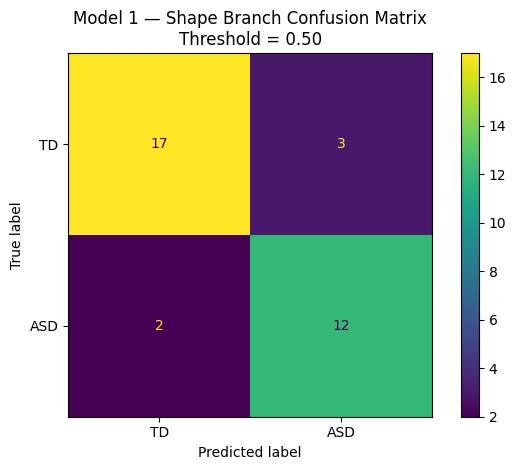

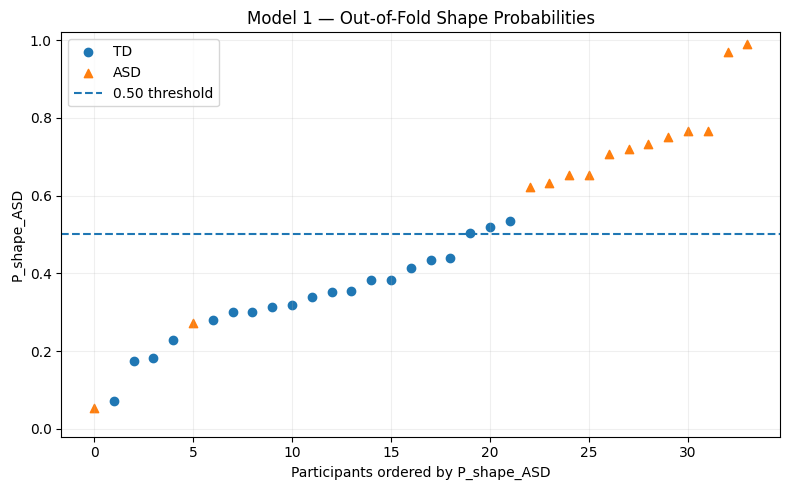


Misclassified participants at threshold 0.50:


,Participant_ID,Group,True_Label,Outer_Fold,P_shape_ASD,Predicted_Label_0.5
32,P038,ASD,1,4,0.0543,0
33,P039,ASD,1,1,0.2717,0
15,P021,TD,0,4,0.5034,1
13,P019,TD,0,5,0.5185,1
12,P018,TD,0,3,0.5342,1



Saved figures:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_roc_curve.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_confusion_matrix.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_oof_probability_distribution.png

Model 1 evaluation figures completed successfully.


In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
    average_precision_score
)

# ============================================================
# ADDITIONAL METRIC
# ============================================================

shape_pr_auc = average_precision_score(
    y_shape,
    shape_oof_proba
)

print("=" * 70)
print("MODEL 1 — FINAL OOF SUMMARY")
print("=" * 70)

print(f"Accuracy:             {shape_metrics['Accuracy']:.4f}")
print(f"Balanced accuracy:    {shape_metrics['Balanced_Accuracy']:.4f}")
print(f"Precision:            {shape_metrics['Precision']:.4f}")
print(f"Recall / Sensitivity: {shape_metrics['Recall_Sensitivity']:.4f}")
print(f"Specificity:          {shape_metrics['Specificity']:.4f}")
print(f"F1-score:             {shape_metrics['F1']:.4f}")
print(f"ROC-AUC:              {shape_metrics['AUC_ROC']:.4f}")
print(f"PR-AUC:               {shape_pr_auc:.4f}")


# ============================================================
# ROC CURVE
# ============================================================

fpr_shape, tpr_shape, roc_thresholds_shape = roc_curve(
    y_shape,
    shape_oof_proba
)

shape_auc = auc(
    fpr_shape,
    tpr_shape
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_shape,
    tpr_shape,
    linewidth=2,
    label=f"Shape model (AUC = {shape_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate (Sensitivity)"
)

plt.title(
    "Model 1 — Shape Branch ROC Curve\n"
    "Nested Cross-Validation OOF Predictions"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

shape_roc_file = os.path.join(
    RESULTS_DIR,
    "shape_roc_curve.png"
)

plt.savefig(
    shape_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_shape,
    shape_oof_pred,
    labels=[0, 1],
    display_labels=[
        "TD",
        "ASD"
    ],
    values_format="d"
)

plt.title(
    "Model 1 — Shape Branch Confusion Matrix\n"
    "Threshold = 0.50"
)

plt.tight_layout()

shape_cm_file = os.path.join(
    RESULTS_DIR,
    "shape_confusion_matrix.png"
)

plt.savefig(
    shape_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT PROBABILITY DISTRIBUTION
# ============================================================

td_probabilities = shape_oof_proba[
    y_shape == 0
]

asd_probabilities = shape_oof_proba[
    y_shape == 1
]

plt.figure(
    figsize=(8, 5)
)

positions = np.arange(
    len(y_shape)
)

sorted_idx = np.argsort(
    shape_oof_proba
)

sorted_probs = shape_oof_proba[
    sorted_idx
]

sorted_labels = y_shape[
    sorted_idx
]

# TD participants
td_mask = (
    sorted_labels == 0
)

plt.scatter(
    positions[td_mask],
    sorted_probs[td_mask],
    label="TD",
    marker="o"
)

# ASD participants
asd_mask = (
    sorted_labels == 1
)

plt.scatter(
    positions[asd_mask],
    sorted_probs[asd_mask],
    label="ASD",
    marker="^"
)

plt.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="0.50 threshold"
)

plt.ylim(
    -0.02,
    1.02
)

plt.xlabel(
    "Participants ordered by P_shape_ASD"
)

plt.ylabel(
    "P_shape_ASD"
)

plt.title(
    "Model 1 — Out-of-Fold Shape Probabilities"
)

plt.legend()

plt.grid(
    alpha=0.20
)

plt.tight_layout()

shape_probability_file = os.path.join(
    RESULTS_DIR,
    "shape_oof_probability_distribution.png"
)

plt.savefig(
    shape_probability_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# MISCLASSIFIED PARTICIPANTS
# ============================================================

misclassified_shape = (
    shape_predictions_df[
        shape_predictions_df[
            "True_Label"
        ]
        !=
        shape_predictions_df[
            "Predicted_Label_0.5"
        ]
    ]
    .copy()
)

print("\nMisclassified participants at threshold 0.50:")

display(
    misclassified_shape[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "P_shape_ASD",
            "Predicted_Label_0.5"
        ]
    ]
    .sort_values(
        "P_shape_ASD"
    )
    .round({
        "P_shape_ASD": 4
    })
)


# ============================================================
# UPDATE METRICS FILE WITH PR-AUC
# ============================================================

shape_metrics_complete = (
    shape_metrics.copy()
)

shape_metrics_complete[
    "PR_AUC"
] = shape_pr_auc

pd.DataFrame(
    [shape_metrics_complete]
).to_csv(
    shape_metrics_file,
    index=False
)


print("\nSaved figures:")
print(shape_roc_file)
print(shape_cm_file)
print(shape_probability_file)

print(
    "\nModel 1 evaluation figures completed successfully."
)

# Model 2 — Colour Drawing Branch

## 14. Extract Objective Colour Statistics

The Colour Drawing branch combines two complementary information sources:

1. a 1280-dimensional frozen EfficientNet-B0 visual embedding
2. objective colour-statistical features extracted directly from the colouring image

The handcrafted colour statistics include:

- hue entropy
- hue diversity
- mean saturation
- saturation variability
- mean brightness
- brightness variability
- proportion of visibly coloured pixels
- mean LAB chroma
- LAB chroma variability
- circular mean hue components

Hue-based statistics are calculated only from sufficiently saturated pixels,
because hue is undefined or unstable for white, grey, and near-black pixels.

No diagnosis labels are used during colour-feature extraction.

Features requiring validated semantic object masks, such as exact
object-colour matching or true colouring-boundary overflow, are not estimated
using arbitrary geometric proxies. They can be added later if validated
template-region masks are available.

In [ ]:
import cv2
import numpy as np
import pandas as pd

# ============================================================
# COLOUR FEATURE EXTRACTION
# ============================================================

def extract_colour_statistics(image_path):
    """
    Extract deterministic global colour statistics.

    The function does NOT use diagnosis labels.

    Returns
    -------
    dict
        Objective colour features.
    """

    # --------------------------------------------------------
    # Load original cropped image
    # --------------------------------------------------------

    pil_img = load_rgb_image(
        image_path
    )

    rgb = np.asarray(
        pil_img,
        dtype=np.uint8
    )

    # --------------------------------------------------------
    # Convert colour spaces
    # --------------------------------------------------------

    hsv = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2HSV
    )

    lab = cv2.cvtColor(
        rgb,
        cv2.COLOR_RGB2LAB
    )


    # OpenCV HSV:
    # H = 0..179
    # S = 0..255
    # V = 0..255

    H = hsv[:, :, 0].astype(
        np.float32
    )

    S = hsv[:, :, 1].astype(
        np.float32
    )

    V = hsv[:, :, 2].astype(
        np.float32
    )


    # ========================================================
    # DEFINE PIXEL MASKS
    # ========================================================

    # Visibly coloured pixels:
    # enough saturation to have a meaningful hue
    # and not extremely dark.

    colour_mask = (
        (S >= 30)
        &
        (V >= 30)
    )


    total_pixels = (
        H.size
    )

    colour_pixels = int(
        colour_mask.sum()
    )

    colour_coverage = (
        colour_pixels
        /
        total_pixels
    )


    # ========================================================
    # HUE FEATURES
    # ========================================================

    if colour_pixels > 0:

        hue_values = H[
            colour_mask
        ]

        saturation_values = S[
            colour_mask
        ]

        brightness_values = V[
            colour_mask
        ]


        # ----------------------------------------------------
        # Hue histogram
        # ----------------------------------------------------

        hue_counts, _ = np.histogram(
            hue_values,
            bins=36,
            range=(0, 180)
        )

        hue_probs = (
            hue_counts.astype(
                np.float64
            )
            /
            hue_counts.sum()
        )

        nonzero_probs = hue_probs[
            hue_probs > 0
        ]


        # Entropy in bits
        hue_entropy = float(
            -np.sum(
                nonzero_probs
                *
                np.log2(
                    nonzero_probs
                )
            )
        )


        # Fraction of hue bins represented
        hue_diversity = float(
            np.count_nonzero(
                hue_counts
            )
            /
            len(hue_counts)
        )


        # ----------------------------------------------------
        # Circular hue representation
        # ----------------------------------------------------

        # Convert OpenCV hue [0,180)
        # into radians [0, 2*pi)

        angles = (
            hue_values
            /
            180.0
            *
            2.0
            *
            np.pi
        )

        hue_cos_mean = float(
            np.mean(
                np.cos(
                    angles
                )
            )
        )

        hue_sin_mean = float(
            np.mean(
                np.sin(
                    angles
                )
            )
        )


        # ----------------------------------------------------
        # Saturation / brightness
        # scaled to 0..1
        # ----------------------------------------------------

        saturation_mean = float(
            np.mean(
                saturation_values
            )
            /
            255.0
        )

        saturation_std = float(
            np.std(
                saturation_values
            )
            /
            255.0
        )

        brightness_mean = float(
            np.mean(
                brightness_values
            )
            /
            255.0
        )

        brightness_std = float(
            np.std(
                brightness_values
            )
            /
            255.0
        )


    else:

        # Safe fallback for an image with no saturated colour
        hue_entropy = 0.0
        hue_diversity = 0.0

        hue_cos_mean = 0.0
        hue_sin_mean = 0.0

        saturation_mean = 0.0
        saturation_std = 0.0

        brightness_mean = 0.0
        brightness_std = 0.0


    # ========================================================
    # LAB CHROMA
    # ========================================================

    # OpenCV stores A/B centred around approximately 128.

    A = (
        lab[:, :, 1]
        .astype(np.float32)
        -
        128.0
    )

    B = (
        lab[:, :, 2]
        .astype(np.float32)
        -
        128.0
    )

    chroma = np.sqrt(
        A ** 2
        +
        B ** 2
    )


    if colour_pixels > 0:

        chroma_values = chroma[
            colour_mask
        ]

        chroma_mean = float(
            np.mean(
                chroma_values
            )
        )

        chroma_std = float(
            np.std(
                chroma_values
            )
        )

    else:

        chroma_mean = 0.0
        chroma_std = 0.0


    # ========================================================
    # RETURN FEATURES
    # ========================================================

    return {
        "hue_entropy":
            hue_entropy,

        "hue_diversity":
            hue_diversity,

        "saturation_mean":
            saturation_mean,

        "saturation_std":
            saturation_std,

        "brightness_mean":
            brightness_mean,

        "brightness_std":
            brightness_std,

        "colour_coverage":
            float(
                colour_coverage
            ),

        "lab_chroma_mean":
            chroma_mean,

        "lab_chroma_std":
            chroma_std,

        "hue_cos_mean":
            hue_cos_mean,

        "hue_sin_mean":
            hue_sin_mean
    }


# ============================================================
# EXTRACT FOR ALL PRIMARY PARTICIPANTS
# ============================================================

colour_feature_records = []

for _, row in primary_df.iterrows():

    features = extract_colour_statistics(
        row["colour_drawing"]
    )

    features[
        "Participant_ID"
    ] = row["Participant_ID"]

    colour_feature_records.append(
        features
    )


colour_stats_df = pd.DataFrame(
    colour_feature_records
)


# Put participant ID first
colour_stats_df = colour_stats_df[
    ["Participant_ID"]
    +
    [
        col
        for col in colour_stats_df.columns
        if col != "Participant_ID"
    ]
]


# ============================================================
# BUILD NUMERIC MATRIX
# ============================================================

COLOUR_STAT_COLUMNS = [
    col
    for col in colour_stats_df.columns
    if col != "Participant_ID"
]


X_colour_stats = (
    colour_stats_df[
        COLOUR_STAT_COLUMNS
    ]
    .to_numpy(
        dtype=np.float32
    )
)


# ============================================================
# VALIDATION
# ============================================================

print("=" * 70)
print("MODEL 2 — COLOUR STATISTICAL FEATURES")
print("=" * 70)

print(
    "Participants:",
    len(colour_stats_df)
)

print(
    "Number of colour statistics:",
    len(COLOUR_STAT_COLUMNS)
)

print(
    "Feature matrix shape:",
    X_colour_stats.shape
)

print(
    "All values finite:",
    np.isfinite(
        X_colour_stats
    ).all()
)


if not np.array_equal(
    colour_stats_df["Participant_ID"]
    .to_numpy(dtype="<U16"),
    participant_ids_safe
):

    raise RuntimeError(
        "Colour feature participant order "
        "does not match primary cohort."
    )


if not np.isfinite(
    X_colour_stats
).all():

    raise RuntimeError(
        "Colour statistics contain "
        "NaN or infinite values."
    )


print("\nColour feature names:")

for feature_name in COLOUR_STAT_COLUMNS:
    print(
        " -",
        feature_name
    )


print("\nFeature summary:")

display(
    colour_stats_df[
        COLOUR_STAT_COLUMNS
    ]
    .describe()
    .T
    .round(4)
)


print("\nFirst five participants:")

display(
    colour_stats_df
    .head()
    .round(4)
)


# ============================================================
# SAVE
# ============================================================

colour_stats_file = os.path.join(
    EMBEDDING_DIR,
    "colour_statistical_features.csv"
)

colour_stats_df.to_csv(
    colour_stats_file,
    index=False
)


print("\nSaved:")
print(colour_stats_file)

print(
    "\nColour statistical feature extraction completed successfully."
)

MODEL 2 — COLOUR STATISTICAL FEATURES
Participants: 34
Number of colour statistics: 11
Feature matrix shape: (34, 11)
All values finite: True

Colour feature names:
 - hue_entropy
 - hue_diversity
 - saturation_mean
 - saturation_std
 - brightness_mean
 - brightness_std
 - colour_coverage
 - lab_chroma_mean
 - lab_chroma_std
 - hue_cos_mean
 - hue_sin_mean

Feature summary:


,count,mean,std,min,25%,50%,75%,max
hue_entropy,34.0,3.4591,0.3721,2.6195,3.2974,3.4845,3.6170,4.3007
hue_diversity,34.0,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
saturation_mean,34.0,0.7088,0.1483,0.3103,0.6452,0.7377,0.7927,0.9403
saturation_std,34.0,0.2387,0.0488,0.0961,0.2209,0.2471,0.2668,0.3253
brightness_mean,34.0,0.7685,0.0614,0.6229,0.7343,0.7669,0.7897,0.9141
brightness_std,34.0,0.2078,0.0369,0.1349,0.1815,0.2066,0.2281,0.2913
colour_coverage,34.0,0.4211,0.1219,0.1538,0.3110,0.4847,0.5131,0.6657
lab_chroma_mean,34.0,58.6447,13.1261,23.9176,51.9720,59.5432,67.1054,75.9173
lab_chroma_std,34.0,23.1539,4.3131,15.1516,20.4011,21.9368,25.0033,36.4823
hue_cos_mean,34.0,0.1610,0.2277,-0.2641,0.0063,0.1293,0.3294,0.6280



First five participants:


,Participant_ID,hue_entropy,hue_diversity,saturation_mean,saturation_std,brightness_mean,brightness_std,colour_coverage,lab_chroma_mean,lab_chroma_std,hue_cos_mean,hue_sin_mean
0,P006,3.6265,1.0,0.6924,0.3253,0.7340,0.2913,0.4242,57.4312,36.4823,0.3847,0.6295
1,P007,3.5274,1.0,0.7879,0.2822,0.7670,0.2852,0.3663,65.1961,33.6077,0.3860,0.5759
2,P008,2.6195,1.0,0.7859,0.2206,0.8524,0.1812,0.5231,73.6502,24.1293,0.2507,0.7822
3,P009,3.4638,1.0,0.9045,0.1455,0.7273,0.2048,0.5240,74.6691,19.3528,-0.0200,0.7032
4,P010,3.2832,1.0,0.9403,0.0961,0.7278,0.2076,0.5256,75.7144,18.3865,0.0870,0.6947



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/embeddings/colour_statistical_features.csv

Colour statistical feature extraction completed successfully.


## 15. Construct and Evaluate the Colour Branch

The initially calculated `hue_diversity` feature had zero variance across all
participants and therefore contained no discriminative information.

It is excluded from the classifier input.

The final Colour branch representation therefore combines:

- 1280 frozen EfficientNet-B0 visual features
- 10 objective colour-statistical features

Final dimensionality:

**1280 + 10 = 1290 features per participant**

Model evaluation uses the same leakage-safe nested stratified cross-validation
procedure used for the Shape branch.

Within every outer fold:

- StandardScaler is fitted only on training participants
- Logistic Regression regularization is selected only within the training data
- the outer test participants remain completely unseen until final prediction

The branch output is:

`P_colour_ASD`

In [ ]:
# ============================================================
# REMOVE ZERO-VARIANCE COLOUR FEATURE
# ============================================================

COLOUR_MODEL_COLUMNS = [
    col
    for col in COLOUR_STAT_COLUMNS
    if col != "hue_diversity"
]

X_colour_stats_final = (
    colour_stats_df[
        COLOUR_MODEL_COLUMNS
    ]
    .to_numpy(dtype=np.float32)
)


# ============================================================
# VALIDATE COLOUR STATISTICS
# ============================================================

feature_std = (
    X_colour_stats_final
    .std(axis=0)
)

if np.any(feature_std == 0):

    zero_variance_features = [
        COLOUR_MODEL_COLUMNS[i]
        for i in np.where(
            feature_std == 0
        )[0]
    ]

    raise ValueError(
        f"Zero-variance colour features remain: "
        f"{zero_variance_features}"
    )


# ============================================================
# COMBINE CNN + COLOUR STATISTICS
# ============================================================

X_colour = np.concatenate(
    [
        X_colour_cnn,
        X_colour_stats_final
    ],
    axis=1
).astype(np.float32)

y_colour = y.copy()


print("=" * 70)
print("MODEL 2 — COLOUR BRANCH FEATURE CONSTRUCTION")
print("=" * 70)

print(
    "EfficientNet features:",
    X_colour_cnn.shape
)

print(
    "Colour statistics:",
    X_colour_stats_final.shape
)

print(
    "Combined Colour matrix:",
    X_colour.shape
)

print(
    "All values finite:",
    np.isfinite(
        X_colour
    ).all()
)

print(
    "Final colour-statistical features:"
)

for col in COLOUR_MODEL_COLUMNS:
    print(" -", col)


# Strict checks
if X_colour.shape != (
    len(primary_df),
    1290
):
    raise ValueError(
        f"Unexpected Colour matrix shape: "
        f"{X_colour.shape}"
    )

if not np.isfinite(
    X_colour
).all():
    raise ValueError(
        "Colour feature matrix contains "
        "NaN or infinite values."
    )


# ============================================================
# NESTED CROSS-VALIDATION
# ============================================================

colour_oof_proba = np.full(
    len(y_colour),
    np.nan,
    dtype=np.float64
)

colour_oof_pred = np.full(
    len(y_colour),
    -1,
    dtype=np.int64
)

colour_outer_fold = np.full(
    len(y_colour),
    -1,
    dtype=np.int64
)

colour_fold_results = []


print("\n" + "=" * 70)
print("MODEL 2 — COLOUR BRANCH NESTED CROSS-VALIDATION")
print("=" * 70)


outer_cv_colour = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


for fold_number, (train_idx, test_idx) in enumerate(
    outer_cv_colour.split(
        X_colour,
        y_colour
    ),
    start=1
):

    X_train = X_colour[
        train_idx
    ]

    X_test = X_colour[
        test_idx
    ]

    y_train = y_colour[
        train_idx
    ]

    y_test = y_colour[
        test_idx
    ]


    # --------------------------------------------------------
    # PARTICIPANT LEAKAGE CHECK
    # --------------------------------------------------------

    train_ids = set(
        participant_ids_safe[
            train_idx
        ]
    )

    test_ids = set(
        participant_ids_safe[
            test_idx
        ]
    )

    overlap = (
        train_ids
        &
        test_ids
    )

    if overlap:

        raise RuntimeError(
            f"Participant leakage detected "
            f"in Colour fold {fold_number}: "
            f"{overlap}"
        )


    # --------------------------------------------------------
    # INNER CV
    # --------------------------------------------------------

    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            100
            +
            fold_number
        )
    )


    # --------------------------------------------------------
    # PIPELINE
    # --------------------------------------------------------

    colour_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    grid_search = GridSearchCV(
        estimator=colour_pipeline,

        param_grid={
            "classifier__C":
                C_GRID
        },

        scoring="roc_auc",

        cv=inner_cv,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )


    # Fit ONLY on outer-training data
    grid_search.fit(
        X_train,
        y_train
    )


    best_model = (
        grid_search
        .best_estimator_
    )

    best_c = (
        grid_search
        .best_params_[
            "classifier__C"
        ]
    )


    # --------------------------------------------------------
    # OUTER TEST PREDICTION
    # --------------------------------------------------------

    test_proba = (
        best_model
        .predict_proba(
            X_test
        )[:, 1]
    )

    test_pred = (
        test_proba
        >=
        0.50
    ).astype(
        np.int64
    )


    colour_oof_proba[
        test_idx
    ] = test_proba

    colour_oof_pred[
        test_idx
    ] = test_pred

    colour_outer_fold[
        test_idx
    ] = fold_number


    # --------------------------------------------------------
    # FOLD METRICS
    # --------------------------------------------------------

    tn_f, fp_f, fn_f, tp_f = confusion_matrix(
        y_test,
        test_pred,
        labels=[0, 1]
    ).ravel()


    specificity_f = (
        tn_f
        /
        (
            tn_f
            +
            fp_f
        )
        if (
            tn_f
            +
            fp_f
        ) > 0
        else np.nan
    )


    fold_auc = roc_auc_score(
        y_test,
        test_proba
    )


    colour_fold_results.append({

        "Fold":
            fold_number,

        "Train_N":
            len(train_idx),

        "Test_N":
            len(test_idx),

        "Train_TD":
            int(
                (y_train == 0).sum()
            ),

        "Train_ASD":
            int(
                (y_train == 1).sum()
            ),

        "Test_TD":
            int(
                (y_test == 0).sum()
            ),

        "Test_ASD":
            int(
                (y_test == 1).sum()
            ),

        "Best_C":
            best_c,

        "AUC":
            fold_auc,

        "Recall":
            recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),

        "Specificity":
            specificity_f
    })


    print(
        f"Fold {fold_number}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}, "
        f"Best C={best_c}, "
        f"AUC={fold_auc:.3f}"
    )


# ============================================================
# STRICT OOF VALIDATION
# ============================================================

if np.isnan(
    colour_oof_proba
).any():

    raise RuntimeError(
        "Some participants did not receive "
        "an OOF Colour probability."
    )


if (
    colour_outer_fold < 1
).any():

    raise RuntimeError(
        "Some Colour participants were not "
        "assigned an outer fold."
    )


if not np.all(
    (
        colour_oof_proba >= 0
    )
    &
    (
        colour_oof_proba <= 1
    )
):

    raise RuntimeError(
        "Invalid Colour probabilities detected."
    )


# ============================================================
# OVERALL METRICS
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_colour,
    colour_oof_pred,
    labels=[0, 1]
).ravel()


colour_specificity = (
    tn / (tn + fp)
    if (
        tn + fp
    ) > 0
    else np.nan
)


colour_metrics = {

    "Accuracy":
        accuracy_score(
            y_colour,
            colour_oof_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_colour,
            colour_oof_pred
        ),

    "Precision":
        precision_score(
            y_colour,
            colour_oof_pred,
            zero_division=0
        ),

    "Recall_Sensitivity":
        recall_score(
            y_colour,
            colour_oof_pred,
            zero_division=0
        ),

    "Specificity":
        colour_specificity,

    "F1":
        f1_score(
            y_colour,
            colour_oof_pred,
            zero_division=0
        ),

    "AUC_ROC":
        roc_auc_score(
            y_colour,
            colour_oof_proba
        ),

    "PR_AUC":
        average_precision_score(
            y_colour,
            colour_oof_proba
        )
}


# ============================================================
# RESULTS DATAFRAMES
# ============================================================

colour_fold_results_df = pd.DataFrame(
    colour_fold_results
)


colour_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_colour,

    "Outer_Fold":
        colour_outer_fold,

    "P_colour_ASD":
        colour_oof_proba,

    "Predicted_Label_0.5":
        colour_oof_pred
})


print("\nFold-level results:")

display(
    colour_fold_results_df
    .round(4)
)


print("\nOverall out-of-fold performance:")

for metric_name, metric_value in colour_metrics.items():

    print(
        f"{metric_name:22s}: "
        f"{metric_value:.4f}"
    )


print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print(
    "\nFormat: "
    "[[TN, FP], [FN, TP]]"
)


# ============================================================
# SAVE MODEL 2 RESULTS
# ============================================================

colour_predictions_file = os.path.join(
    RESULTS_DIR,
    "colour_oof_predictions.csv"
)

colour_fold_file = os.path.join(
    RESULTS_DIR,
    "colour_nested_cv_folds.csv"
)

colour_metrics_file = os.path.join(
    RESULTS_DIR,
    "colour_metrics.csv"
)


colour_predictions_df.to_csv(
    colour_predictions_file,
    index=False
)

colour_fold_results_df.to_csv(
    colour_fold_file,
    index=False
)

pd.DataFrame(
    [colour_metrics]
).to_csv(
    colour_metrics_file,
    index=False
)


print("\nSaved:")
print(colour_predictions_file)
print(colour_fold_file)
print(colour_metrics_file)

print(
    "\nModel 2 nested cross-validation "
    "completed successfully."
)

MODEL 2 — COLOUR BRANCH FEATURE CONSTRUCTION
EfficientNet features: (34, 1280)
Colour statistics: (34, 10)
Combined Colour matrix: (34, 1290)
All values finite: True
Final colour-statistical features:
 - hue_entropy
 - saturation_mean
 - saturation_std
 - brightness_mean
 - brightness_std
 - colour_coverage
 - lab_chroma_mean
 - lab_chroma_std
 - hue_cos_mean
 - hue_sin_mean

MODEL 2 — COLOUR BRANCH NESTED CROSS-VALIDATION
Fold 1: train=27, test=7, Best C=0.01, AUC=0.750
Fold 2: train=27, test=7, Best C=0.001, AUC=0.750
Fold 3: train=27, test=7, Best C=0.01, AUC=0.917
Fold 4: train=27, test=7, Best C=0.001, AUC=0.750
Fold 5: train=28, test=6, Best C=0.001, AUC=1.000

Fold-level results:


,Fold,Train_N,Test_N,Train_TD,Train_ASD,Test_TD,Test_ASD,Best_C,AUC,Recall,Specificity
0,1,27,7,16,11,4,3,0.010,0.7500,0.6667,0.75
1,2,27,7,16,11,4,3,0.001,0.7500,1.0000,0.75
2,3,27,7,16,11,4,3,0.010,0.9167,0.6667,0.75
3,4,27,7,16,11,4,3,0.001,0.7500,0.6667,1.00
4,5,28,6,16,12,4,2,0.001,1.0000,1.0000,1.00



Overall out-of-fold performance:
Accuracy              : 0.8235
Balanced_Accuracy     : 0.8179
Precision             : 0.7857
Recall_Sensitivity    : 0.7857
Specificity           : 0.8500
F1                    : 0.7857
AUC_ROC               : 0.8143
PR_AUC                : 0.7261

Confusion matrix:
[[17  3]
 [ 3 11]]

Format: [[TN, FP], [FN, TP]]

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_oof_predictions.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_nested_cv_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_metrics.csv

Model 2 nested cross-validation completed successfully.


## 16. Model 2 — Out-of-Fold Evaluation and Visualization

The Colour branch is evaluated using only nested-cross-validation
out-of-fold predictions.

The following outputs are generated:

- ROC curve
- confusion matrix
- participant-level ASD probability distribution
- list of misclassified participants

The conventional threshold of 0.50 is used for the initial binary evaluation.

No threshold is optimized using these out-of-fold evaluation predictions.

MODEL 2 — FINAL OOF SUMMARY
Accuracy:             0.8235
Balanced accuracy:    0.8179
Precision:            0.7857
Recall / Sensitivity: 0.7857
Specificity:          0.8500
F1-score:             0.7857
ROC-AUC:              0.8143
PR-AUC:               0.7261


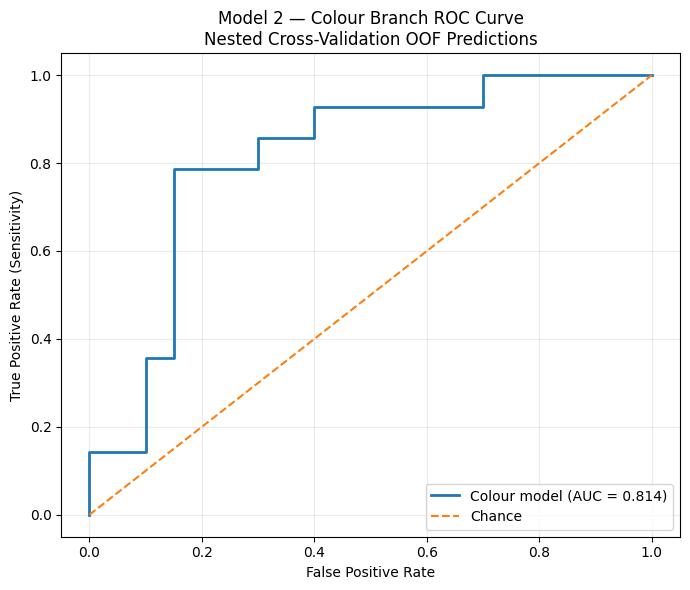

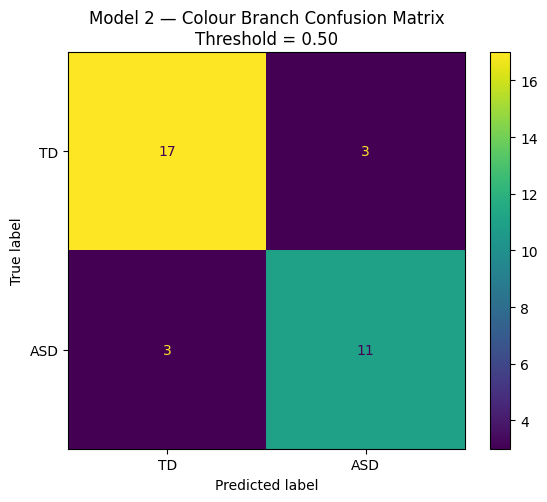

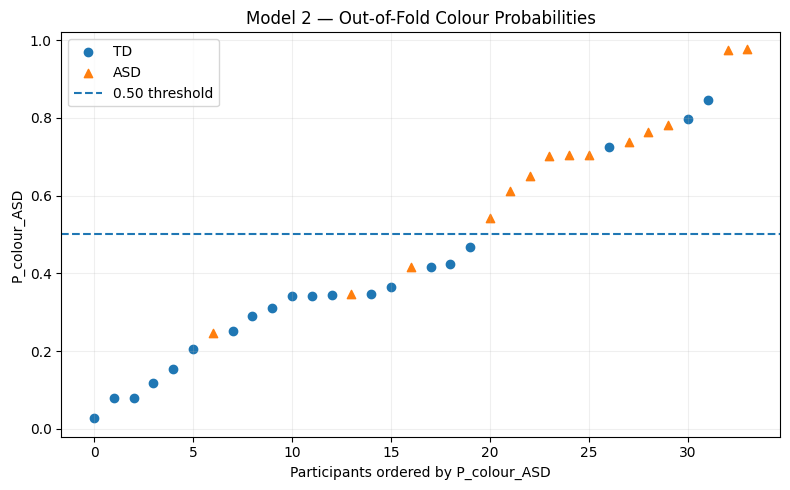


Misclassified participants at threshold 0.50:


,Participant_ID,Group,True_Label,Outer_Fold,P_colour_ASD,Predicted_Label_0.5
22,P028,ASD,1,3,0.2454,0
32,P038,ASD,1,4,0.3478,0
33,P039,ASD,1,1,0.4168,0
14,P020,TD,0,2,0.7251,1
12,P018,TD,0,3,0.7973,1
11,P017,TD,0,1,0.8452,1



Saved figures:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_roc_curve.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_confusion_matrix.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_oof_probability_distribution.png

Model 2 evaluation figures completed successfully.


In [ ]:
# ============================================================
# MODEL 2 — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("MODEL 2 — FINAL OOF SUMMARY")
print("=" * 70)

print(f"Accuracy:             {colour_metrics['Accuracy']:.4f}")
print(f"Balanced accuracy:    {colour_metrics['Balanced_Accuracy']:.4f}")
print(f"Precision:            {colour_metrics['Precision']:.4f}")
print(f"Recall / Sensitivity: {colour_metrics['Recall_Sensitivity']:.4f}")
print(f"Specificity:          {colour_metrics['Specificity']:.4f}")
print(f"F1-score:             {colour_metrics['F1']:.4f}")
print(f"ROC-AUC:              {colour_metrics['AUC_ROC']:.4f}")
print(f"PR-AUC:               {colour_metrics['PR_AUC']:.4f}")


# ============================================================
# ROC CURVE
# ============================================================

fpr_colour, tpr_colour, roc_thresholds_colour = roc_curve(
    y_colour,
    colour_oof_proba
)

colour_auc = auc(
    fpr_colour,
    tpr_colour
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr_colour,
    tpr_colour,
    linewidth=2,
    label=f"Colour model (AUC = {colour_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)"
)

ax.set_title(
    "Model 2 — Colour Branch ROC Curve\n"
    "Nested Cross-Validation OOF Predictions"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

colour_roc_file = os.path.join(
    RESULTS_DIR,
    "colour_roc_curve.png"
)

fig.savefig(
    colour_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_colour,
    colour_oof_pred,
    labels=[0, 1],
    display_labels=[
        "TD",
        "ASD"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Model 2 — Colour Branch Confusion Matrix\n"
    "Threshold = 0.50"
)

fig.tight_layout()

colour_cm_file = os.path.join(
    RESULTS_DIR,
    "colour_confusion_matrix.png"
)

fig.savefig(
    colour_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT-LEVEL OOF PROBABILITIES
# ============================================================

sorted_idx = np.argsort(
    colour_oof_proba
)

sorted_probs = colour_oof_proba[
    sorted_idx
]

sorted_labels = y_colour[
    sorted_idx
]

positions = np.arange(
    len(y_colour)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

td_mask = (
    sorted_labels == 0
)

asd_mask = (
    sorted_labels == 1
)

ax.scatter(
    positions[td_mask],
    sorted_probs[td_mask],
    label="TD",
    marker="o"
)

ax.scatter(
    positions[asd_mask],
    sorted_probs[asd_mask],
    label="ASD",
    marker="^"
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="0.50 threshold"
)

ax.set_ylim(
    -0.02,
    1.02
)

ax.set_xlabel(
    "Participants ordered by P_colour_ASD"
)

ax.set_ylabel(
    "P_colour_ASD"
)

ax.set_title(
    "Model 2 — Out-of-Fold Colour Probabilities"
)

ax.legend()

ax.grid(
    alpha=0.20
)

fig.tight_layout()

colour_probability_file = os.path.join(
    RESULTS_DIR,
    "colour_oof_probability_distribution.png"
)

fig.savefig(
    colour_probability_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# MISCLASSIFIED PARTICIPANTS
# ============================================================

misclassified_colour = (
    colour_predictions_df[
        colour_predictions_df["True_Label"]
        !=
        colour_predictions_df["Predicted_Label_0.5"]
    ]
    .copy()
)


print("\nMisclassified participants at threshold 0.50:")

display(
    misclassified_colour[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "P_colour_ASD",
            "Predicted_Label_0.5"
        ]
    ]
    .sort_values(
        "P_colour_ASD"
    )
    .round({
        "P_colour_ASD": 4
    })
)


# ============================================================
# SAVED OUTPUTS
# ============================================================

print("\nSaved figures:")
print(colour_roc_file)
print(colour_cm_file)
print(colour_probability_file)

print(
    "\nModel 2 evaluation figures completed successfully."
)

# Model 3 — Draw-a-Man Branch

## 17. Construct and Evaluate the DINOv2 Draw-a-Man Model

The Draw-a-Man branch uses the frozen DINOv2-small representation extracted
from each participant's Draw-a-Man drawing.

Each participant is represented by:

**384 DINOv2 features**

No manually defined facial, limb, or body-completeness scores are included in
the primary model because such measurements would require a validated
drawing-specific landmark or structural annotation procedure.

The DINOv2 representation is classified using Logistic Regression with
leakage-safe nested stratified cross-validation.

For every outer fold:

- StandardScaler is fitted only on outer-training participants
- Logistic Regression regularization strength is selected only from
  outer-training data using inner cross-validation
- outer-test participants remain completely unseen until prediction

The branch produces one participant-level out-of-fold probability:

`P_DAM_ASD`

A probability threshold of 0.50 is used for the initial binary evaluation.
Threshold optimization is deferred until the later multimodal analysis.

In [ ]:
# ============================================================
# MODEL 3 — DAM FEATURE MATRIX
# ============================================================

X_dam = (
    X_dam_dino
    .copy()
    .astype(np.float32)
)

y_dam = (
    y.copy()
    .astype(np.int64)
)


print("=" * 70)
print("MODEL 3 — DRAW-A-MAN FEATURE CONSTRUCTION")
print("=" * 70)

print(
    "DINOv2 feature matrix:",
    X_dam.shape
)

print(
    "All values finite:",
    np.isfinite(X_dam).all()
)

print(
    "Participants:",
    len(X_dam)
)

print(
    "TD:",
    int((y_dam == 0).sum())
)

print(
    "ASD:",
    int((y_dam == 1).sum())
)


# ============================================================
# STRICT VALIDATION
# ============================================================

expected_dam_shape = (
    len(primary_df),
    384
)

if X_dam.shape != expected_dam_shape:

    raise ValueError(
        f"Unexpected DAM feature matrix shape: "
        f"{X_dam.shape}; "
        f"expected {expected_dam_shape}"
    )


if not np.isfinite(
    X_dam
).all():

    raise ValueError(
        "DAM feature matrix contains "
        "NaN or infinite values."
    )


if not np.array_equal(
    y_dam,
    labels_safe
):

    raise RuntimeError(
        "DAM labels are not aligned "
        "with participant order."
    )


# ============================================================
# STORAGE FOR OUT-OF-FOLD RESULTS
# ============================================================

dam_oof_proba = np.full(
    len(y_dam),
    np.nan,
    dtype=np.float64
)

dam_oof_pred = np.full(
    len(y_dam),
    -1,
    dtype=np.int64
)

dam_outer_fold = np.full(
    len(y_dam),
    -1,
    dtype=np.int64
)

dam_fold_results = []


# ============================================================
# OUTER CROSS-VALIDATION
# ============================================================

outer_cv_dam = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


print("\n" + "=" * 70)
print("MODEL 3 — DAM BRANCH NESTED CROSS-VALIDATION")
print("=" * 70)


for fold_number, (train_idx, test_idx) in enumerate(

    outer_cv_dam.split(
        X_dam,
        y_dam
    ),

    start=1
):

    X_train = X_dam[
        train_idx
    ]

    X_test = X_dam[
        test_idx
    ]

    y_train = y_dam[
        train_idx
    ]

    y_test = y_dam[
        test_idx
    ]


    # ========================================================
    # PARTICIPANT LEAKAGE CHECK
    # ========================================================

    train_ids = set(
        participant_ids_safe[
            train_idx
        ]
    )

    test_ids = set(
        participant_ids_safe[
            test_idx
        ]
    )

    overlap = (
        train_ids
        &
        test_ids
    )


    if overlap:

        raise RuntimeError(
            f"Participant leakage detected "
            f"in DAM fold {fold_number}: "
            f"{overlap}"
        )


    # ========================================================
    # INNER CROSS-VALIDATION
    # ========================================================

    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            200
            +
            fold_number
        )
    )


    # ========================================================
    # PIPELINE
    # ========================================================

    dam_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    # ========================================================
    # INNER HYPERPARAMETER SEARCH
    # ========================================================

    grid_search = GridSearchCV(

        estimator=dam_pipeline,

        param_grid={
            "classifier__C":
                C_GRID
        },

        scoring="roc_auc",

        cv=inner_cv,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )


    # IMPORTANT:
    # only outer-training participants are used here

    grid_search.fit(
        X_train,
        y_train
    )


    best_model = (
        grid_search
        .best_estimator_
    )

    best_c = (
        grid_search
        .best_params_[
            "classifier__C"
        ]
    )


    # ========================================================
    # HELD-OUT OUTER TEST PREDICTION
    # ========================================================

    test_proba = (
        best_model
        .predict_proba(
            X_test
        )[:, 1]
    )


    test_pred = (
        test_proba
        >=
        0.50
    ).astype(
        np.int64
    )


    # Store OOF predictions

    dam_oof_proba[
        test_idx
    ] = test_proba

    dam_oof_pred[
        test_idx
    ] = test_pred

    dam_outer_fold[
        test_idx
    ] = fold_number


    # ========================================================
    # FOLD METRICS
    # ========================================================

    tn_f, fp_f, fn_f, tp_f = confusion_matrix(
        y_test,
        test_pred,
        labels=[0, 1]
    ).ravel()


    specificity_f = (
        tn_f
        /
        (
            tn_f
            +
            fp_f
        )

        if (
            tn_f
            +
            fp_f
        ) > 0

        else np.nan
    )


    fold_auc = roc_auc_score(
        y_test,
        test_proba
    )


    dam_fold_results.append({

        "Fold":
            fold_number,

        "Train_N":
            len(train_idx),

        "Test_N":
            len(test_idx),

        "Train_TD":
            int(
                (y_train == 0).sum()
            ),

        "Train_ASD":
            int(
                (y_train == 1).sum()
            ),

        "Test_TD":
            int(
                (y_test == 0).sum()
            ),

        "Test_ASD":
            int(
                (y_test == 1).sum()
            ),

        "Best_C":
            best_c,

        "AUC":
            fold_auc,

        "Recall":
            recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),

        "Specificity":
            specificity_f
    })


    print(
        f"Fold {fold_number}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}, "
        f"Best C={best_c}, "
        f"AUC={fold_auc:.3f}"
    )


# ============================================================
# STRICT OOF VALIDATION
# ============================================================

if np.isnan(
    dam_oof_proba
).any():

    raise RuntimeError(
        "Some participants did not receive "
        "an OOF DAM probability."
    )


if (
    dam_outer_fold < 1
).any():

    raise RuntimeError(
        "Some DAM participants were not "
        "assigned an outer test fold."
    )


if not np.all(
    (
        dam_oof_proba >= 0
    )
    &
    (
        dam_oof_proba <= 1
    )
):

    raise RuntimeError(
        "Invalid DAM probabilities detected."
    )


# ============================================================
# OVERALL OOF METRICS
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y_dam,
    dam_oof_pred,
    labels=[0, 1]
).ravel()


dam_specificity = (
    tn
    /
    (
        tn
        +
        fp
    )

    if (
        tn
        +
        fp
    ) > 0

    else np.nan
)


dam_metrics = {

    "Accuracy":
        accuracy_score(
            y_dam,
            dam_oof_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_dam,
            dam_oof_pred
        ),

    "Precision":
        precision_score(
            y_dam,
            dam_oof_pred,
            zero_division=0
        ),

    "Recall_Sensitivity":
        recall_score(
            y_dam,
            dam_oof_pred,
            zero_division=0
        ),

    "Specificity":
        dam_specificity,

    "F1":
        f1_score(
            y_dam,
            dam_oof_pred,
            zero_division=0
        ),

    "AUC_ROC":
        roc_auc_score(
            y_dam,
            dam_oof_proba
        ),

    "PR_AUC":
        average_precision_score(
            y_dam,
            dam_oof_proba
        )
}


# ============================================================
# RESULTS TABLES
# ============================================================

dam_fold_results_df = pd.DataFrame(
    dam_fold_results
)


dam_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_dam,

    "Outer_Fold":
        dam_outer_fold,

    "P_DAM_ASD":
        dam_oof_proba,

    "Predicted_Label_0.5":
        dam_oof_pred
})


print("\nFold-level results:")

display(
    dam_fold_results_df
    .round(4)
)


print("\nOverall out-of-fold performance:")

for metric_name, metric_value in dam_metrics.items():

    print(
        f"{metric_name:22s}: "
        f"{metric_value:.4f}"
    )


print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print(
    "\nFormat: "
    "[[TN, FP], [FN, TP]]"
)


# ============================================================
# SAVE MODEL 3 RESULTS
# ============================================================

dam_predictions_file = os.path.join(
    RESULTS_DIR,
    "dam_oof_predictions.csv"
)

dam_fold_file = os.path.join(
    RESULTS_DIR,
    "dam_nested_cv_folds.csv"
)

dam_metrics_file = os.path.join(
    RESULTS_DIR,
    "dam_metrics.csv"
)


dam_predictions_df.to_csv(
    dam_predictions_file,
    index=False
)

dam_fold_results_df.to_csv(
    dam_fold_file,
    index=False
)

pd.DataFrame(
    [dam_metrics]
).to_csv(
    dam_metrics_file,
    index=False
)


print("\nSaved:")
print(dam_predictions_file)
print(dam_fold_file)
print(dam_metrics_file)

print(
    "\nModel 3 nested cross-validation "
    "completed successfully."
)

MODEL 3 — DRAW-A-MAN FEATURE CONSTRUCTION
DINOv2 feature matrix: (34, 384)
All values finite: True
Participants: 34
TD: 20
ASD: 14

MODEL 3 — DAM BRANCH NESTED CROSS-VALIDATION
Fold 1: train=27, test=7, Best C=0.001, AUC=0.667
Fold 2: train=27, test=7, Best C=10.0, AUC=0.833
Fold 3: train=27, test=7, Best C=0.001, AUC=0.750
Fold 4: train=27, test=7, Best C=0.001, AUC=0.333
Fold 5: train=28, test=6, Best C=1.0, AUC=0.750

Fold-level results:


,Fold,Train_N,Test_N,Train_TD,Train_ASD,Test_TD,Test_ASD,Best_C,AUC,Recall,Specificity
0,1,27,7,16,11,4,3,0.001,0.6667,0.6667,1.00
1,2,27,7,16,11,4,3,10.000,0.8333,0.6667,0.75
2,3,27,7,16,11,4,3,0.001,0.7500,1.0000,0.50
3,4,27,7,16,11,4,3,0.001,0.3333,0.6667,0.00
4,5,28,6,16,12,4,2,1.000,0.7500,0.5000,0.75



Overall out-of-fold performance:
Accuracy              : 0.6471
Balanced_Accuracy     : 0.6571
Precision             : 0.5556
Recall_Sensitivity    : 0.7143
Specificity           : 0.6000
F1                    : 0.6250
AUC_ROC               : 0.7143
PR_AUC                : 0.6823

Confusion matrix:
[[12  8]
 [ 4 10]]

Format: [[TN, FP], [FN, TP]]

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_oof_predictions.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_nested_cv_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_metrics.csv

Model 3 nested cross-validation completed successfully.


## 18. Model 3 — Out-of-Fold Evaluation and Visualization

The Draw-a-Man branch is evaluated exclusively using probabilities generated
for participants held out during nested cross-validation.

The following are reported:

- ROC curve
- confusion matrix
- participant-level out-of-fold probability distribution
- misclassified participants

A threshold of 0.50 is used for the initial binary evaluation.

No decision threshold is optimized using these out-of-fold evaluation
predictions.

Performance of this modality is interpreted independently before multimodal
fusion so that its incremental contribution can later be assessed through
ablation analysis.

MODEL 3 — FINAL OOF SUMMARY
Accuracy:             0.6471
Balanced accuracy:    0.6571
Precision:            0.5556
Recall / Sensitivity: 0.7143
Specificity:          0.6000
F1-score:             0.6250
ROC-AUC:              0.7143
PR-AUC:               0.6823


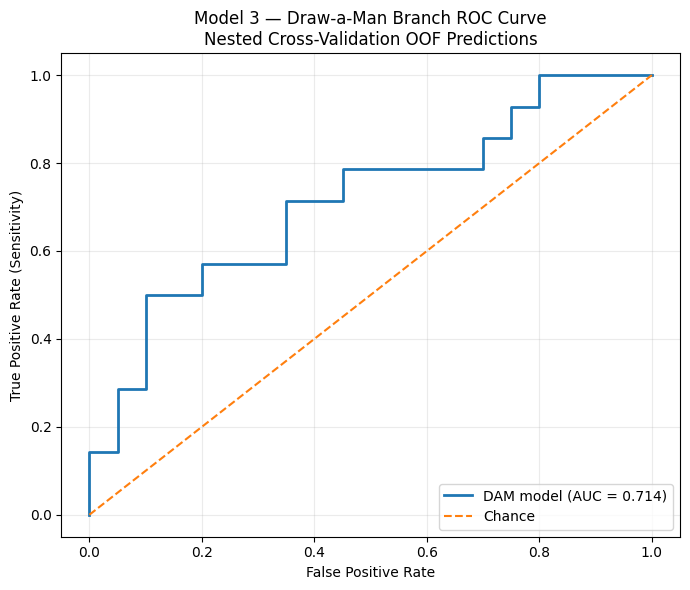

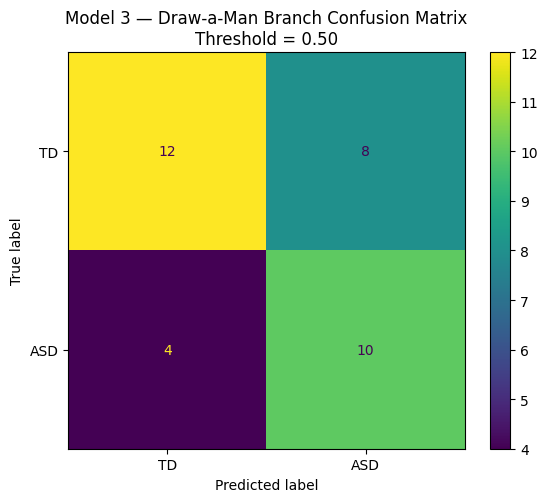

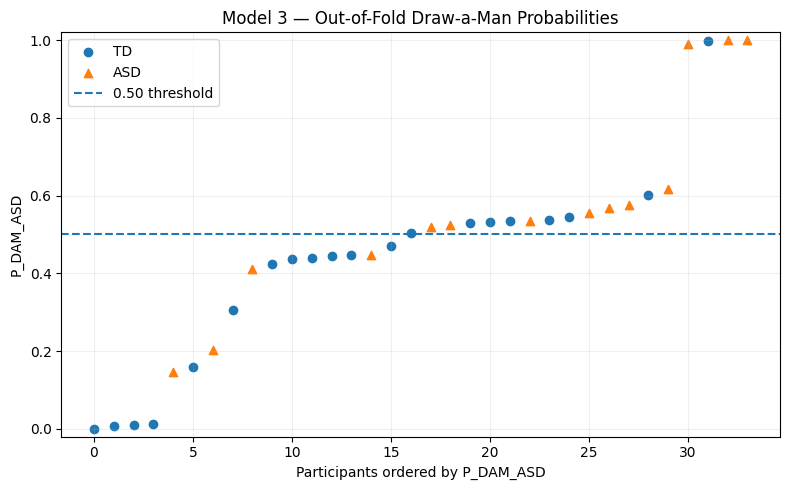


Misclassified participants at threshold 0.50:


,Participant_ID,Group,True_Label,Outer_Fold,P_DAM_ASD,Predicted_Label_0.5
26,P032,ASD,1,2,0.1457,0
27,P033,ASD,1,5,0.2035,0
33,P039,ASD,1,1,0.4110,0
32,P038,ASD,1,4,0.4476,0
13,P019,TD,0,5,0.5026,1
15,P021,TD,0,4,0.5295,1
10,P016,TD,0,4,0.5318,1
17,P023,TD,0,3,0.5334,1
12,P018,TD,0,3,0.5364,1
18,P024,TD,0,4,0.5458,1



Saved figures:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_roc_curve.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_confusion_matrix.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_oof_probability_distribution.png

Model 3 evaluation figures completed successfully.


In [ ]:
# ============================================================
# MODEL 3 — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("MODEL 3 — FINAL OOF SUMMARY")
print("=" * 70)

print(f"Accuracy:             {dam_metrics['Accuracy']:.4f}")
print(f"Balanced accuracy:    {dam_metrics['Balanced_Accuracy']:.4f}")
print(f"Precision:            {dam_metrics['Precision']:.4f}")
print(f"Recall / Sensitivity: {dam_metrics['Recall_Sensitivity']:.4f}")
print(f"Specificity:          {dam_metrics['Specificity']:.4f}")
print(f"F1-score:             {dam_metrics['F1']:.4f}")
print(f"ROC-AUC:              {dam_metrics['AUC_ROC']:.4f}")
print(f"PR-AUC:               {dam_metrics['PR_AUC']:.4f}")


# ============================================================
# ROC CURVE
# ============================================================

fpr_dam, tpr_dam, roc_thresholds_dam = roc_curve(
    y_dam,
    dam_oof_proba
)

dam_auc = auc(
    fpr_dam,
    tpr_dam
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr_dam,
    tpr_dam,
    linewidth=2,
    label=f"DAM model (AUC = {dam_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)"
)

ax.set_title(
    "Model 3 — Draw-a-Man Branch ROC Curve\n"
    "Nested Cross-Validation OOF Predictions"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

dam_roc_file = os.path.join(
    RESULTS_DIR,
    "dam_roc_curve.png"
)

fig.savefig(
    dam_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_dam,
    dam_oof_pred,
    labels=[0, 1],
    display_labels=[
        "TD",
        "ASD"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Model 3 — Draw-a-Man Branch Confusion Matrix\n"
    "Threshold = 0.50"
)

fig.tight_layout()

dam_cm_file = os.path.join(
    RESULTS_DIR,
    "dam_confusion_matrix.png"
)

fig.savefig(
    dam_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT-LEVEL OOF PROBABILITIES
# ============================================================

sorted_idx = np.argsort(
    dam_oof_proba
)

sorted_probs = dam_oof_proba[
    sorted_idx
]

sorted_labels = y_dam[
    sorted_idx
]

positions = np.arange(
    len(y_dam)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

td_mask = (
    sorted_labels == 0
)

asd_mask = (
    sorted_labels == 1
)

ax.scatter(
    positions[td_mask],
    sorted_probs[td_mask],
    label="TD",
    marker="o"
)

ax.scatter(
    positions[asd_mask],
    sorted_probs[asd_mask],
    label="ASD",
    marker="^"
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="0.50 threshold"
)

ax.set_ylim(
    -0.02,
    1.02
)

ax.set_xlabel(
    "Participants ordered by P_DAM_ASD"
)

ax.set_ylabel(
    "P_DAM_ASD"
)

ax.set_title(
    "Model 3 — Out-of-Fold Draw-a-Man Probabilities"
)

ax.legend()

ax.grid(
    alpha=0.20
)

fig.tight_layout()

dam_probability_file = os.path.join(
    RESULTS_DIR,
    "dam_oof_probability_distribution.png"
)

fig.savefig(
    dam_probability_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# MISCLASSIFIED PARTICIPANTS
# ============================================================

misclassified_dam = (
    dam_predictions_df[
        dam_predictions_df["True_Label"]
        !=
        dam_predictions_df["Predicted_Label_0.5"]
    ]
    .copy()
)

print(
    "\nMisclassified participants at threshold 0.50:"
)

display(
    misclassified_dam[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "P_DAM_ASD",
            "Predicted_Label_0.5"
        ]
    ]
    .sort_values(
        "P_DAM_ASD"
    )
    .round({
        "P_DAM_ASD": 4
    })
)


# ============================================================
# SAVE FIGURE PATHS
# ============================================================

print("\nSaved figures:")
print(dam_roc_file)
print(dam_cm_file)
print(dam_probability_file)

print(
    "\nModel 3 evaluation figures completed successfully."
)

# Model 4 — Caregiver Questionnaire Branch

## 19. Questionnaire Feature Construction and Validation

The caregiver questionnaire contains 25 Likert-scale items scored from 1 to 4.

For the primary multimodal cohort:

- all 34 participants have complete questionnaire responses
- no questionnaire values are missing
- therefore no imputation is required
- age and gender are not used as questionnaire model inputs

The questionnaire branch uses the 25 item responses directly as model features.

Two classifiers are evaluated:

1. **XGBoost** — primary questionnaire classifier
2. **Logistic Regression** — interpretable baseline

Hyperparameter selection is performed only within the training portion of each
outer cross-validation fold.

The primary questionnaire output used later for multimodal fusion is:

`P_questionnaire_ASD`

In [ ]:
# ============================================================
# MODEL 4 — QUESTIONNAIRE FEATURE MATRIX
# ============================================================

# Extract the 25 questionnaire items from the SAME
# 34-participant primary multimodal cohort.

X_questionnaire = (
    primary_df[
        ITEM_COLS
    ]
    .to_numpy(
        dtype=np.float32
    )
)

y_questionnaire = (
    y.copy()
    .astype(np.int64)
)


print("=" * 70)
print("MODEL 4 — QUESTIONNAIRE FEATURE CONSTRUCTION")
print("=" * 70)

print(
    "Questionnaire matrix:",
    X_questionnaire.shape
)

print(
    "Participants:",
    len(X_questionnaire)
)

print(
    "Questionnaire items:",
    X_questionnaire.shape[1]
)

print(
    "TD:",
    int(
        (y_questionnaire == 0).sum()
    )
)

print(
    "ASD:",
    int(
        (y_questionnaire == 1).sum()
    )
)

print(
    "Missing values:",
    int(
        np.isnan(
            X_questionnaire
        ).sum()
    )
)

print(
    "All values finite:",
    np.isfinite(
        X_questionnaire
    ).all()
)

print(
    "Minimum response:",
    float(
        X_questionnaire.min()
    )
)

print(
    "Maximum response:",
    float(
        X_questionnaire.max()
    )
)


# ============================================================
# STRICT VALIDATION
# ============================================================

expected_questionnaire_shape = (
    len(primary_df),
    25
)

if X_questionnaire.shape != expected_questionnaire_shape:

    raise ValueError(
        f"Unexpected questionnaire matrix shape: "
        f"{X_questionnaire.shape}; "
        f"expected {expected_questionnaire_shape}"
    )


if np.isnan(
    X_questionnaire
).any():

    raise ValueError(
        "Questionnaire contains missing values. "
        "This dataset was expected to be complete."
    )


if not np.isfinite(
    X_questionnaire
).all():

    raise ValueError(
        "Questionnaire contains NaN or infinite values."
    )


if (
    X_questionnaire.min() < 1
    or
    X_questionnaire.max() > 4
):

    raise ValueError(
        "Questionnaire responses outside "
        "the expected 1–4 Likert range."
    )


if not np.array_equal(
    y_questionnaire,
    labels_safe
):

    raise RuntimeError(
        "Questionnaire labels are not aligned "
        "with participant order."
    )


# ============================================================
# CHECK ITEM VARIANCE
# ============================================================

questionnaire_item_std = (
    X_questionnaire
    .std(axis=0)
)

zero_variance_item_indices = np.where(
    questionnaire_item_std == 0
)[0]


if len(
    zero_variance_item_indices
) > 0:

    zero_variance_items = [
        ITEM_COLS[i]
        for i in zero_variance_item_indices
    ]

    print(
        "\nWARNING — zero-variance questionnaire items:"
    )

    print(
        zero_variance_items
    )

else:

    print(
        "\nZero-variance questionnaire items: None"
    )


# ============================================================
# ITEM-LEVEL DESCRIPTIVE SUMMARY
# ============================================================

questionnaire_summary_df = pd.DataFrame({

    "Item":
        ITEM_COLS,

    "Mean":
        X_questionnaire.mean(
            axis=0
        ),

    "Std":
        X_questionnaire.std(
            axis=0
        ),

    "Min":
        X_questionnaire.min(
            axis=0
        ),

    "Max":
        X_questionnaire.max(
            axis=0
        )
})


print(
    "\nQuestionnaire item summary:"
)

display(
    questionnaire_summary_df
    .round(3)
)


# ============================================================
# SAVE PRIMARY QUESTIONNAIRE MATRIX
# ============================================================

questionnaire_feature_file = os.path.join(
    EMBEDDING_DIR,
    "questionnaire_primary_features.npz"
)

np.savez_compressed(

    questionnaire_feature_file,

    participant_ids=
        participant_ids_safe,

    labels=
        labels_safe,

    X_questionnaire=
        X_questionnaire
)


with np.load(
    questionnaire_feature_file,
    allow_pickle=False
) as saved_questionnaire:

    print(
        "\nSaved questionnaire matrix identical:",
        np.array_equal(
            saved_questionnaire[
                "X_questionnaire"
            ],
            X_questionnaire
        )
    )

    print(
        "Saved labels identical:",
        np.array_equal(
            saved_questionnaire[
                "labels"
            ],
            y_questionnaire
        )
    )


print(
    "\nSaved:",
    questionnaire_feature_file
)

print(
    "\nQuestionnaire feature construction "
    "completed successfully."
)

MODEL 4 — QUESTIONNAIRE FEATURE CONSTRUCTION
Questionnaire matrix: (34, 25)
Participants: 34
Questionnaire items: 25
TD: 20
ASD: 14
Missing values: 0
All values finite: True
Minimum response: 1.0
Maximum response: 4.0

Zero-variance questionnaire items: None

Questionnaire item summary:


,Item,Mean,Std,Min,Max
0,item_1,2.206,1.106,1.0,4.0
1,item_2,2.412,1.088,1.0,4.0
2,item_3,2.324,0.992,1.0,4.0
3,item_4,2.706,1.201,1.0,4.0
4,item_5,2.471,1.194,1.0,4.0
5,item_6,2.382,1.112,1.0,4.0
6,item_7,2.235,1.086,1.0,4.0
7,item_8,2.441,0.976,1.0,4.0
8,item_9,2.471,1.144,1.0,4.0
9,item_10,2.500,0.916,1.0,4.0



Saved questionnaire matrix identical: True
Saved labels identical: True

Saved: /content/drive/MyDrive/Autism detection/Final_ASD_Outputs/embeddings/questionnaire_primary_features.npz

Questionnaire feature construction completed successfully.


## 20. Model 4 — Nested Cross-Validation

The caregiver questionnaire is evaluated using two classifiers:

### Primary model — XGBoost

XGBoost is used as the primary nonlinear questionnaire classifier.

A small hyperparameter grid is searched within the training data only to limit
overfitting in the current pilot cohort.

### Baseline — Logistic Regression

Logistic Regression is evaluated using the same outer cross-validation folds
as an interpretable linear baseline.

For both models:

- participants are split using stratified outer 5-fold cross-validation
- hyperparameter selection occurs only within each outer-training fold
- outer-test participants remain completely unseen during model selection
- one out-of-fold ASD probability is produced for every participant

The primary questionnaire probability used later in multimodal fusion is:

`P_questionnaire_ASD`

No missing-value imputation is performed because the questionnaire dataset is
complete.

In [ ]:
# ============================================================
# INSTALL / IMPORT XGBOOST
# ============================================================

!pip install -q xgboost

from xgboost import XGBClassifier

print("XGBoost imported successfully.")


# ============================================================
# STORAGE
# ============================================================

N = len(y_questionnaire)

questionnaire_xgb_oof_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

questionnaire_xgb_oof_pred = np.full(
    N,
    -1,
    dtype=np.int64
)

questionnaire_lr_oof_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

questionnaire_lr_oof_pred = np.full(
    N,
    -1,
    dtype=np.int64
)

questionnaire_outer_fold = np.full(
    N,
    -1,
    dtype=np.int64
)

questionnaire_xgb_fold_results = []
questionnaire_lr_fold_results = []


# ============================================================
# OUTER CV
#
# Same split definition used for the image branches.
# ============================================================

outer_cv_questionnaire = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


print("=" * 70)
print("MODEL 4 — QUESTIONNAIRE NESTED CROSS-VALIDATION")
print("=" * 70)


# ============================================================
# OUTER LOOP
# ============================================================

for fold_number, (train_idx, test_idx) in enumerate(

    outer_cv_questionnaire.split(
        X_questionnaire,
        y_questionnaire
    ),

    start=1
):

    X_train = X_questionnaire[
        train_idx
    ]

    X_test = X_questionnaire[
        test_idx
    ]

    y_train = y_questionnaire[
        train_idx
    ]

    y_test = y_questionnaire[
        test_idx
    ]


    # --------------------------------------------------------
    # PARTICIPANT LEAKAGE CHECK
    # --------------------------------------------------------

    train_ids = set(
        participant_ids_safe[
            train_idx
        ]
    )

    test_ids = set(
        participant_ids_safe[
            test_idx
        ]
    )

    overlap = (
        train_ids
        &
        test_ids
    )

    if overlap:

        raise RuntimeError(
            f"Participant leakage detected "
            f"in Questionnaire fold {fold_number}: "
            f"{overlap}"
        )


    # --------------------------------------------------------
    # INNER CV
    # --------------------------------------------------------

    inner_cv_xgb = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            300
            +
            fold_number
        )
    )

    inner_cv_lr = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            400
            +
            fold_number
        )
    )


    # ========================================================
    # PRIMARY MODEL — XGBOOST
    # ========================================================

    xgb_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        random_state=SEED,

        n_jobs=1,

        tree_method="hist"
    )


    # Small grid because the pilot sample is only 34 children.
    xgb_param_grid = {

        "n_estimators": [
            50,
            100
        ],

        "max_depth": [
            1,
            2
        ],

        "learning_rate": [
            0.03,
            0.10
        ],

        "min_child_weight": [
            1,
            3
        ]
    }


    xgb_search = GridSearchCV(

        estimator=xgb_model,

        param_grid=xgb_param_grid,

        scoring="roc_auc",

        cv=inner_cv_xgb,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )


    # IMPORTANT:
    # only outer-training participants are used
    xgb_search.fit(
        X_train,
        y_train
    )


    best_xgb = (
        xgb_search
        .best_estimator_
    )


    xgb_test_proba = (
        best_xgb
        .predict_proba(
            X_test
        )[:, 1]
    )


    xgb_test_pred = (
        xgb_test_proba
        >=
        0.50
    ).astype(
        np.int64
    )


    questionnaire_xgb_oof_proba[
        test_idx
    ] = xgb_test_proba

    questionnaire_xgb_oof_pred[
        test_idx
    ] = xgb_test_pred


    # ========================================================
    # BASELINE — LOGISTIC REGRESSION
    # ========================================================

    lr_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    lr_search = GridSearchCV(

        estimator=lr_pipeline,

        param_grid={
            "classifier__C":
                C_GRID
        },

        scoring="roc_auc",

        cv=inner_cv_lr,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )


    lr_search.fit(
        X_train,
        y_train
    )


    best_lr = (
        lr_search
        .best_estimator_
    )


    lr_test_proba = (
        best_lr
        .predict_proba(
            X_test
        )[:, 1]
    )


    lr_test_pred = (
        lr_test_proba
        >=
        0.50
    ).astype(
        np.int64
    )


    questionnaire_lr_oof_proba[
        test_idx
    ] = lr_test_proba

    questionnaire_lr_oof_pred[
        test_idx
    ] = lr_test_pred


    # --------------------------------------------------------
    # STORE OUTER FOLD
    # --------------------------------------------------------

    questionnaire_outer_fold[
        test_idx
    ] = fold_number


    # ========================================================
    # FOLD METRICS — XGBOOST
    # ========================================================

    tn_x, fp_x, fn_x, tp_x = confusion_matrix(
        y_test,
        xgb_test_pred,
        labels=[0, 1]
    ).ravel()


    xgb_specificity = (
        tn_x / (tn_x + fp_x)
        if (tn_x + fp_x) > 0
        else np.nan
    )


    questionnaire_xgb_fold_results.append({

        "Fold":
            fold_number,

        "Train_N":
            len(train_idx),

        "Test_N":
            len(test_idx),

        "Test_TD":
            int(
                (y_test == 0).sum()
            ),

        "Test_ASD":
            int(
                (y_test == 1).sum()
            ),

        "Best_n_estimators":
            xgb_search.best_params_[
                "n_estimators"
            ],

        "Best_max_depth":
            xgb_search.best_params_[
                "max_depth"
            ],

        "Best_learning_rate":
            xgb_search.best_params_[
                "learning_rate"
            ],

        "Best_min_child_weight":
            xgb_search.best_params_[
                "min_child_weight"
            ],

        "AUC":
            roc_auc_score(
                y_test,
                xgb_test_proba
            ),

        "Recall":
            recall_score(
                y_test,
                xgb_test_pred,
                zero_division=0
            ),

        "Specificity":
            xgb_specificity
    })


    # ========================================================
    # FOLD METRICS — LOGISTIC REGRESSION
    # ========================================================

    tn_l, fp_l, fn_l, tp_l = confusion_matrix(
        y_test,
        lr_test_pred,
        labels=[0, 1]
    ).ravel()


    lr_specificity = (
        tn_l / (tn_l + fp_l)
        if (tn_l + fp_l) > 0
        else np.nan
    )


    questionnaire_lr_fold_results.append({

        "Fold":
            fold_number,

        "Best_C":
            lr_search.best_params_[
                "classifier__C"
            ],

        "AUC":
            roc_auc_score(
                y_test,
                lr_test_proba
            ),

        "Recall":
            recall_score(
                y_test,
                lr_test_pred,
                zero_division=0
            ),

        "Specificity":
            lr_specificity
    })


    print(
        f"Fold {fold_number}: "
        f"XGB AUC="
        f"{roc_auc_score(y_test, xgb_test_proba):.3f} | "
        f"LR AUC="
        f"{roc_auc_score(y_test, lr_test_proba):.3f}"
    )


# ============================================================
# STRICT OOF VALIDATION
# ============================================================

for name, probabilities in {

    "XGBoost":
        questionnaire_xgb_oof_proba,

    "Logistic Regression":
        questionnaire_lr_oof_proba

}.items():

    if np.isnan(
        probabilities
    ).any():

        raise RuntimeError(
            f"{name}: some participants did not "
            f"receive an OOF probability."
        )


    if not np.all(
        (
            probabilities >= 0
        )
        &
        (
            probabilities <= 1
        )
    ):

        raise RuntimeError(
            f"{name}: invalid probabilities detected."
        )


if (
    questionnaire_outer_fold < 1
).any():

    raise RuntimeError(
        "Some questionnaire participants were "
        "not assigned an outer test fold."
    )


# ============================================================
# HELPER — CALCULATE OVERALL METRICS
# ============================================================

def calculate_binary_metrics(
    y_true,
    probabilities,
    predictions
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    return {

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall_Sensitivity":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "AUC_ROC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    }


# ============================================================
# OVERALL METRICS
# ============================================================

questionnaire_xgb_metrics = calculate_binary_metrics(

    y_questionnaire,

    questionnaire_xgb_oof_proba,

    questionnaire_xgb_oof_pred
)


questionnaire_lr_metrics = calculate_binary_metrics(

    y_questionnaire,

    questionnaire_lr_oof_proba,

    questionnaire_lr_oof_pred
)


# ============================================================
# RESULTS TABLES
# ============================================================

questionnaire_xgb_folds_df = pd.DataFrame(
    questionnaire_xgb_fold_results
)

questionnaire_lr_folds_df = pd.DataFrame(
    questionnaire_lr_fold_results
)


questionnaire_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_questionnaire,

    "Outer_Fold":
        questionnaire_outer_fold,

    "P_questionnaire_ASD":
        questionnaire_xgb_oof_proba,

    "Predicted_XGB_0.5":
        questionnaire_xgb_oof_pred,

    "P_questionnaire_LR_ASD":
        questionnaire_lr_oof_proba,

    "Predicted_LR_0.5":
        questionnaire_lr_oof_pred
})


# ============================================================
# PRINT RESULTS
# ============================================================

print("\nXGBoost fold-level results:")

display(
    questionnaire_xgb_folds_df
    .round(4)
)


print("\nLogistic Regression fold-level results:")

display(
    questionnaire_lr_folds_df
    .round(4)
)


print("\nPrimary XGBoost overall OOF performance:")

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]:

    print(
        f"{metric_name:22s}: "
        f"{questionnaire_xgb_metrics[metric_name]:.4f}"
    )


print("\nXGBoost confusion matrix:")

print(
    np.array([
        [
            questionnaire_xgb_metrics["TN"],
            questionnaire_xgb_metrics["FP"]
        ],
        [
            questionnaire_xgb_metrics["FN"],
            questionnaire_xgb_metrics["TP"]
        ]
    ])
)


print("\nLogistic Regression baseline overall OOF performance:")

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]:

    print(
        f"{metric_name:22s}: "
        f"{questionnaire_lr_metrics[metric_name]:.4f}"
    )


print("\nLogistic Regression confusion matrix:")

print(
    np.array([
        [
            questionnaire_lr_metrics["TN"],
            questionnaire_lr_metrics["FP"]
        ],
        [
            questionnaire_lr_metrics["FN"],
            questionnaire_lr_metrics["TP"]
        ]
    ])
)


# ============================================================
# SAVE RESULTS
# ============================================================

questionnaire_predictions_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_oof_predictions.csv"
)

questionnaire_xgb_folds_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_xgb_nested_cv_folds.csv"
)

questionnaire_lr_folds_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_lr_nested_cv_folds.csv"
)

questionnaire_xgb_metrics_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_xgb_metrics.csv"
)

questionnaire_lr_metrics_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_lr_metrics.csv"
)


questionnaire_predictions_df.to_csv(
    questionnaire_predictions_file,
    index=False
)

questionnaire_xgb_folds_df.to_csv(
    questionnaire_xgb_folds_file,
    index=False
)

questionnaire_lr_folds_df.to_csv(
    questionnaire_lr_folds_file,
    index=False
)

pd.DataFrame(
    [questionnaire_xgb_metrics]
).to_csv(
    questionnaire_xgb_metrics_file,
    index=False
)

pd.DataFrame(
    [questionnaire_lr_metrics]
).to_csv(
    questionnaire_lr_metrics_file,
    index=False
)


print("\nSaved:")
print(questionnaire_predictions_file)
print(questionnaire_xgb_folds_file)
print(questionnaire_lr_folds_file)
print(questionnaire_xgb_metrics_file)
print(questionnaire_lr_metrics_file)

print(
    "\nModel 4 nested cross-validation completed successfully."
)

XGBoost imported successfully.
MODEL 4 — QUESTIONNAIRE NESTED CROSS-VALIDATION
Fold 1: XGB AUC=0.875 | LR AUC=1.000
Fold 2: XGB AUC=1.000 | LR AUC=1.000
Fold 3: XGB AUC=1.000 | LR AUC=1.000
Fold 4: XGB AUC=0.833 | LR AUC=1.000
Fold 5: XGB AUC=0.375 | LR AUC=1.000

XGBoost fold-level results:


,Fold,Train_N,Test_N,Test_TD,Test_ASD,Best_n_estimators,Best_max_depth,Best_learning_rate,Best_min_child_weight,AUC,Recall,Specificity
0,1,27,7,4,3,50,1,0.03,1,0.8750,0.6667,1.00
1,2,27,7,4,3,50,1,0.10,1,1.0000,1.0000,1.00
2,3,27,7,4,3,100,1,0.03,1,1.0000,1.0000,1.00
3,4,27,7,4,3,50,1,0.03,1,0.8333,0.6667,1.00
4,5,28,6,4,2,50,1,0.03,1,0.3750,0.0000,0.75



Logistic Regression fold-level results:


,Fold,Best_C,AUC,Recall,Specificity
0,1,0.001,1.0,1.0,1.0
1,2,0.001,1.0,1.0,1.0
2,3,0.001,1.0,1.0,1.0
3,4,0.001,1.0,1.0,1.0
4,5,0.001,1.0,1.0,1.0



Primary XGBoost overall OOF performance:
Accuracy              : 0.8529
Balanced_Accuracy     : 0.8321
Precision             : 0.9091
Recall_Sensitivity    : 0.7143
Specificity           : 0.9500
F1                    : 0.8000
AUC_ROC               : 0.8554
PR_AUC                : 0.8453

XGBoost confusion matrix:
[[19  1]
 [ 4 10]]

Logistic Regression baseline overall OOF performance:
Accuracy              : 1.0000
Balanced_Accuracy     : 1.0000
Precision             : 1.0000
Recall_Sensitivity    : 1.0000
Specificity           : 1.0000
F1                    : 1.0000
AUC_ROC               : 1.0000
PR_AUC                : 1.0000

Logistic Regression confusion matrix:
[[20  0]
 [ 0 14]]

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_oof_predictions.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_xgb_nested_cv_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_lr_nested_c

## 21. Questionnaire Separation and Leakage Sanity Audit

The Logistic Regression questionnaire baseline achieved perfect nested
cross-validation performance.

Perfect performance is possible, but with a small pilot cohort it requires
additional inspection before interpretation.

This audit checks whether:

- any single questionnaire item perfectly separates ASD and TD
- class-specific item ranges overlap
- the overall questionnaire response level strongly separates groups
- duplicate questionnaire response patterns exist
- any questionnaire feature is identical or nearly identical to the diagnosis
- participant identifiers or group columns were accidentally included as model
  features

This step does not modify the model or choose features based on performance.
It is a diagnostic quality-control analysis.

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

print("=" * 70)
print("QUESTIONNAIRE SANITY AUDIT")
print("=" * 70)


# ============================================================
# 1. CONFIRM EXACT MODEL INPUT COLUMNS
# ============================================================

print("Number of model input columns:", len(ITEM_COLS))
print("Model input columns:")
print(ITEM_COLS)

non_item_columns_used = [
    col for col in ITEM_COLS
    if not col.startswith("item_")
]

print(
    "\nNon-item columns accidentally included:",
    non_item_columns_used
)

assert len(ITEM_COLS) == 25
assert len(non_item_columns_used) == 0


# ============================================================
# 2. EXACT DUPLICATE RESPONSE PATTERNS
# ============================================================

questionnaire_pattern_df = pd.DataFrame(
    X_questionnaire,
    columns=ITEM_COLS
)

questionnaire_pattern_df["Label"] = y_questionnaire
questionnaire_pattern_df["Participant_ID"] = participant_ids_safe

duplicate_pattern_mask = questionnaire_pattern_df[
    ITEM_COLS
].duplicated(
    keep=False
)

duplicate_patterns = questionnaire_pattern_df[
    duplicate_pattern_mask
].copy()

print(
    "\nParticipants involved in duplicated 25-item response patterns:",
    len(duplicate_patterns)
)

if len(duplicate_patterns) > 0:
    display(
        duplicate_patterns.sort_values(
            ITEM_COLS
        )
    )


# ============================================================
# 3. CLASS-SPECIFIC ITEM DISTRIBUTIONS
# ============================================================

audit_records = []

for item_index, item_name in enumerate(ITEM_COLS):

    values = X_questionnaire[:, item_index]

    td_values = values[
        y_questionnaire == 0
    ]

    asd_values = values[
        y_questionnaire == 1
    ]

    # Raw AUC
    raw_auc = roc_auc_score(
        y_questionnaire,
        values
    )

    # Direction-independent discrimination:
    # 0.5 = no discrimination
    # 1.0 = perfect discrimination
    directional_auc = max(
        raw_auc,
        1.0 - raw_auc
    )

    td_min = float(td_values.min())
    td_max = float(td_values.max())

    asd_min = float(asd_values.min())
    asd_max = float(asd_values.max())

    # Do the observed class ranges overlap?
    ranges_overlap = not (
        td_max < asd_min
        or
        asd_max < td_min
    )

    audit_records.append({
        "Item": item_name,

        "TD_Mean":
            float(td_values.mean()),

        "ASD_Mean":
            float(asd_values.mean()),

        "TD_Min":
            td_min,

        "TD_Max":
            td_max,

        "ASD_Min":
            asd_min,

        "ASD_Max":
            asd_max,

        "Ranges_Overlap":
            ranges_overlap,

        "Univariate_AUC":
            raw_auc,

        "Direction_Independent_AUC":
            directional_auc
    })


questionnaire_item_audit_df = pd.DataFrame(
    audit_records
)


print("\nItem-level group comparison:")

display(
    questionnaire_item_audit_df
    .sort_values(
        "Direction_Independent_AUC",
        ascending=False
    )
    .round(4)
)


# ============================================================
# 4. CHECK FOR SINGLE-ITEM PERFECT SEPARATION
# ============================================================

perfect_single_items = questionnaire_item_audit_df[
    questionnaire_item_audit_df[
        "Direction_Independent_AUC"
    ] >= 0.999999
]

print(
    "\nSingle questionnaire items with perfect ranking separation:",
    len(perfect_single_items)
)

if len(perfect_single_items) > 0:

    display(
        perfect_single_items
    )


nonoverlapping_items = questionnaire_item_audit_df[
    questionnaire_item_audit_df[
        "Ranges_Overlap"
    ] == False
]

print(
    "Items with completely non-overlapping observed class ranges:",
    len(nonoverlapping_items)
)

if len(nonoverlapping_items) > 0:

    display(
        nonoverlapping_items
    )


# ============================================================
# 5. SIMPLE TOTAL / MEAN RESPONSE CHECK
#
# This is descriptive only.
# It is NOT used as the trained classifier.
# ============================================================

questionnaire_sum = (
    X_questionnaire.sum(axis=1)
)

questionnaire_mean = (
    X_questionnaire.mean(axis=1)
)


simple_score_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "Label":
        y_questionnaire,

    "Item_Sum":
        questionnaire_sum,

    "Item_Mean":
        questionnaire_mean
})


print("\nSimple raw-response summaries by group:")

display(
    simple_score_df
    .groupby("Group")[
        [
            "Item_Sum",
            "Item_Mean"
        ]
    ]
    .agg([
        "mean",
        "std",
        "min",
        "max"
    ])
    .round(4)
)


sum_auc_raw = roc_auc_score(
    y_questionnaire,
    questionnaire_sum
)

sum_auc_direction_independent = max(
    sum_auc_raw,
    1.0 - sum_auc_raw
)

print(
    "\nDirection-independent AUC of simple item sum:",
    round(
        sum_auc_direction_independent,
        4
    )
)


# ============================================================
# 6. CHECK EXACT LABEL CORRELATIONS
# ============================================================

feature_label_correlations = []

for i, item_name in enumerate(ITEM_COLS):

    correlation = np.corrcoef(
        X_questionnaire[:, i],
        y_questionnaire
    )[0, 1]

    feature_label_correlations.append({
        "Item": item_name,
        "Correlation_with_Label":
            float(correlation)
    })


correlation_df = pd.DataFrame(
    feature_label_correlations
)


print("\nStrongest absolute item-label correlations:")

display(
    correlation_df.assign(
        Absolute_Correlation=
            correlation_df[
                "Correlation_with_Label"
            ].abs()
    )
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .head(10)
    .round(4)
)


# ============================================================
# 7. SAVE AUDIT
# ============================================================

questionnaire_audit_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_item_separation_audit.csv"
)

questionnaire_item_audit_df.to_csv(
    questionnaire_audit_file,
    index=False
)

print("\nSaved:")
print(questionnaire_audit_file)

print(
    "\nQuestionnaire sanity audit completed successfully."
)

QUESTIONNAIRE SANITY AUDIT
Number of model input columns: 25
Model input columns:
['item_1', 'item_2', 'item_3', 'item_4', 'item_5', 'item_6', 'item_7', 'item_8', 'item_9', 'item_10', 'item_11', 'item_12', 'item_13', 'item_14', 'item_15', 'item_16', 'item_17', 'item_18', 'item_19', 'item_20', 'item_21', 'item_22', 'item_23', 'item_24', 'item_25']

Non-item columns accidentally included: []

Participants involved in duplicated 25-item response patterns: 0

Item-level group comparison:


,Item,TD_Mean,ASD_Mean,TD_Min,TD_Max,ASD_Min,ASD_Max,Ranges_Overlap,Univariate_AUC,Direction_Independent_AUC
22,item_23,3.55,1.7143,2.0,4.0,1.0,3.0,True,0.0304,0.9696
24,item_25,3.35,1.6429,1.0,4.0,1.0,3.0,True,0.0696,0.9304
16,item_17,1.50,3.2143,1.0,3.0,2.0,4.0,True,0.9268,0.9268
0,item_1,1.50,3.2143,1.0,3.0,1.0,4.0,True,0.9196,0.9196
6,item_7,1.55,3.2143,1.0,3.0,2.0,4.0,True,0.9161,0.9161
18,item_19,3.40,1.6429,1.0,4.0,1.0,3.0,True,0.0839,0.9161
11,item_12,1.70,3.4286,1.0,3.0,1.0,4.0,True,0.9036,0.9036
17,item_18,1.65,3.2143,1.0,3.0,2.0,4.0,True,0.8964,0.8964
13,item_14,1.70,3.3571,1.0,4.0,2.0,4.0,True,0.8946,0.8946
1,item_2,3.00,1.5714,1.0,4.0,1.0,2.0,True,0.1357,0.8643



Single questionnaire items with perfect ranking separation: 0
Items with completely non-overlapping observed class ranges: 0

Simple raw-response summaries by group:


Item_Sum                     Item_Mean                   
            mean     std   min   max      mean     std  min   max
Group                                                            
ASD    59.785702  4.4407  55.0  71.0    2.3914  0.1776  2.2  2.84
TD     61.900002  5.9018  45.0  69.0    2.4760  0.2361  1.8  2.76


Direction-independent AUC of simple item sum: 0.6679

Strongest absolute item-label correlations:


,Item,Correlation_with_Label,Absolute_Correlation
22,item_23,-0.8376,0.8376
0,item_1,0.7631,0.7631
16,item_17,0.7631,0.7631
24,item_25,-0.7581,0.7581
6,item_7,0.7540,0.7540
18,item_19,-0.7480,0.7480
11,item_12,0.7295,0.7295
17,item_18,0.7183,0.7183
13,item_14,0.7009,0.7009
1,item_2,-0.6463,0.6463



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_item_separation_audit.csv

Questionnaire sanity audit completed successfully.


## 22. Model 4 — Out-of-Fold Evaluation and Visualization

The questionnaire branch is evaluated using nested-cross-validation
out-of-fold predictions.

XGBoost remains the pre-specified primary questionnaire classifier.

Logistic Regression is retained as a baseline model and is not substituted
for XGBoost merely because it achieved higher performance on the current
pilot cohort.

The following are visualized:

- ROC curves for XGBoost and Logistic Regression
- XGBoost confusion matrix
- participant-level XGBoost ASD probabilities
- XGBoost misclassified participants

A threshold of 0.50 is used for the initial binary evaluation.

The perfect Logistic Regression result is interpreted cautiously because of
the small sample size and will be reported as a baseline pilot result.

MODEL 4 — QUESTIONNAIRE FINAL OOF SUMMARY

PRIMARY MODEL — XGBoost
Accuracy              : 0.8529
Balanced_Accuracy     : 0.8321
Precision             : 0.9091
Recall_Sensitivity    : 0.7143
Specificity           : 0.9500
F1                    : 0.8000
AUC_ROC               : 0.8554
PR_AUC                : 0.8453

BASELINE — Logistic Regression
Accuracy              : 1.0000
Balanced_Accuracy     : 1.0000
Precision             : 1.0000
Recall_Sensitivity    : 1.0000
Specificity           : 1.0000
F1                    : 1.0000
AUC_ROC               : 1.0000
PR_AUC                : 1.0000


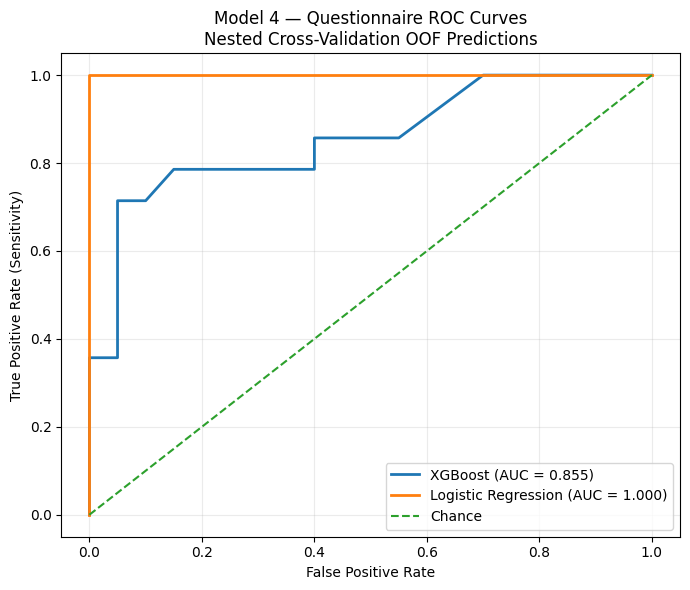

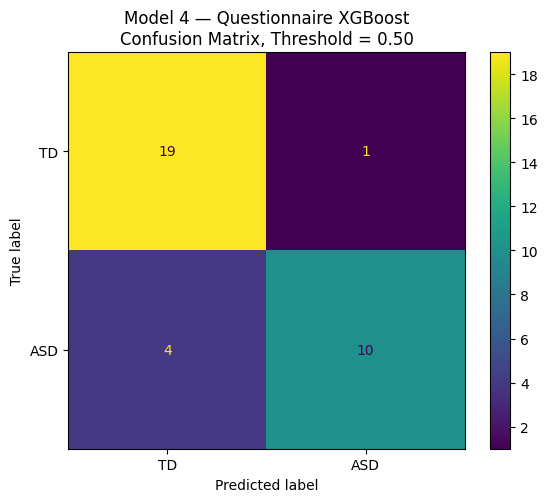

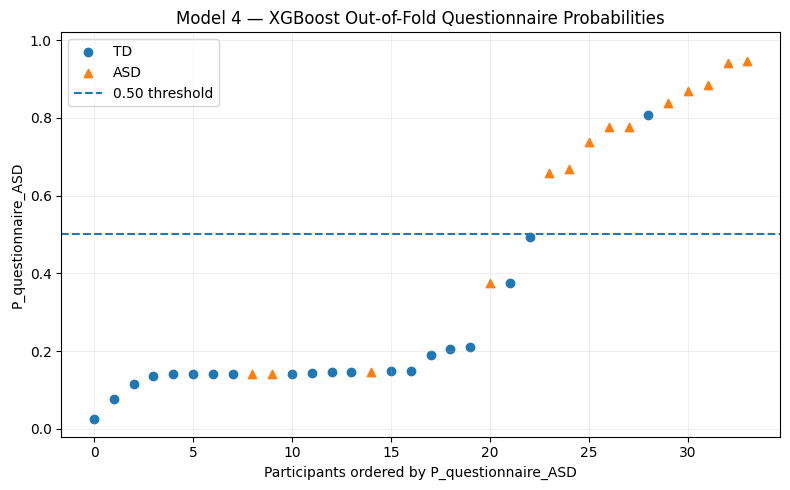


XGBoost misclassified participants at threshold 0.50:


,Participant_ID,Group,True_Label,Outer_Fold,P_questionnaire_ASD,Predicted_XGB_0.5
20,P026,ASD,1,5,0.1405,0
27,P033,ASD,1,5,0.1405,0
32,P038,ASD,1,4,0.1456,0
23,P029,ASD,1,1,0.3763,0
1,P007,TD,0,5,0.8066,1



Number of Logistic Regression misclassifications: 0

Questionnaire model comparison:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall_Sensitivity,Specificity,F1,AUC_ROC,PR_AUC
0,XGBoost,0.8529,0.8321,0.9091,0.7143,0.95,0.8,0.8554,0.8453
1,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.00,1.0,1.0000,1.0000



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_roc_comparison.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_xgb_confusion_matrix.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_xgb_oof_probability_distribution.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_model_comparison.csv

Model 4 evaluation figures completed successfully.


In [ ]:
# ============================================================
# MODEL 4 — FINAL SUMMARY
# ============================================================

print("=" * 70)
print("MODEL 4 — QUESTIONNAIRE FINAL OOF SUMMARY")
print("=" * 70)

print("\nPRIMARY MODEL — XGBoost")

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]:

    print(
        f"{metric_name:22s}: "
        f"{questionnaire_xgb_metrics[metric_name]:.4f}"
    )


print("\nBASELINE — Logistic Regression")

for metric_name in [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]:

    print(
        f"{metric_name:22s}: "
        f"{questionnaire_lr_metrics[metric_name]:.4f}"
    )


# ============================================================
# ROC CURVES — PRIMARY + BASELINE
# ============================================================

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_questionnaire,
    questionnaire_xgb_oof_proba
)

fpr_lr, tpr_lr, _ = roc_curve(
    y_questionnaire,
    questionnaire_lr_oof_proba
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=(
        "XGBoost "
        f"(AUC = {questionnaire_xgb_metrics['AUC_ROC']:.3f})"
    )
)

ax.plot(
    fpr_lr,
    tpr_lr,
    linewidth=2,
    label=(
        "Logistic Regression "
        f"(AUC = {questionnaire_lr_metrics['AUC_ROC']:.3f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)"
)

ax.set_title(
    "Model 4 — Questionnaire ROC Curves\n"
    "Nested Cross-Validation OOF Predictions"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


questionnaire_roc_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_roc_comparison.png"
)

fig.savefig(
    questionnaire_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PRIMARY XGBOOST CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_questionnaire,
    questionnaire_xgb_oof_pred,
    labels=[0, 1],
    display_labels=[
        "TD",
        "ASD"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Model 4 — Questionnaire XGBoost\n"
    "Confusion Matrix, Threshold = 0.50"
)

fig.tight_layout()


questionnaire_cm_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_xgb_confusion_matrix.png"
)

fig.savefig(
    questionnaire_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT-LEVEL XGBOOST OOF PROBABILITIES
# ============================================================

sorted_idx = np.argsort(
    questionnaire_xgb_oof_proba
)

sorted_probs = questionnaire_xgb_oof_proba[
    sorted_idx
]

sorted_labels = y_questionnaire[
    sorted_idx
]

positions = np.arange(
    len(y_questionnaire)
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

td_mask = (
    sorted_labels == 0
)

asd_mask = (
    sorted_labels == 1
)


ax.scatter(
    positions[td_mask],
    sorted_probs[td_mask],
    label="TD",
    marker="o"
)

ax.scatter(
    positions[asd_mask],
    sorted_probs[asd_mask],
    label="ASD",
    marker="^"
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="0.50 threshold"
)

ax.set_ylim(
    -0.02,
    1.02
)

ax.set_xlabel(
    "Participants ordered by P_questionnaire_ASD"
)

ax.set_ylabel(
    "P_questionnaire_ASD"
)

ax.set_title(
    "Model 4 — XGBoost Out-of-Fold Questionnaire Probabilities"
)

ax.legend()

ax.grid(
    alpha=0.20
)

fig.tight_layout()


questionnaire_probability_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_xgb_oof_probability_distribution.png"
)

fig.savefig(
    questionnaire_probability_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# XGBOOST MISCLASSIFICATIONS
# ============================================================

misclassified_questionnaire_xgb = (
    questionnaire_predictions_df[
        questionnaire_predictions_df["True_Label"]
        !=
        questionnaire_predictions_df["Predicted_XGB_0.5"]
    ]
    .copy()
)


print(
    "\nXGBoost misclassified participants "
    "at threshold 0.50:"
)

display(
    misclassified_questionnaire_xgb[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "P_questionnaire_ASD",
            "Predicted_XGB_0.5"
        ]
    ]
    .sort_values(
        "P_questionnaire_ASD"
    )
    .round({
        "P_questionnaire_ASD": 4
    })
)


# ============================================================
# LOGISTIC REGRESSION ERROR CHECK
# ============================================================

misclassified_questionnaire_lr = (
    questionnaire_predictions_df[
        questionnaire_predictions_df["True_Label"]
        !=
        questionnaire_predictions_df["Predicted_LR_0.5"]
    ]
    .copy()
)

print(
    "\nNumber of Logistic Regression "
    "misclassifications:",
    len(
        misclassified_questionnaire_lr
    )
)


# ============================================================
# SAVE SUMMARY COMPARISON
# ============================================================

questionnaire_model_comparison_df = pd.DataFrame([
    {
        "Model":
            "XGBoost",

        **{
            key: questionnaire_xgb_metrics[key]
            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Precision",
                "Recall_Sensitivity",
                "Specificity",
                "F1",
                "AUC_ROC",
                "PR_AUC"
            ]
        }
    },

    {
        "Model":
            "Logistic Regression",

        **{
            key: questionnaire_lr_metrics[key]
            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Precision",
                "Recall_Sensitivity",
                "Specificity",
                "F1",
                "AUC_ROC",
                "PR_AUC"
            ]
        }
    }
])


questionnaire_comparison_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_model_comparison.csv"
)

questionnaire_model_comparison_df.to_csv(
    questionnaire_comparison_file,
    index=False
)


print("\nQuestionnaire model comparison:")

display(
    questionnaire_model_comparison_df
    .round(4)
)


print("\nSaved:")
print(questionnaire_roc_file)
print(questionnaire_cm_file)
print(questionnaire_probability_file)
print(questionnaire_comparison_file)

print(
    "\nModel 4 evaluation figures completed successfully."
)

# Model 5 — Fully Nested Multimodal Late Fusion

## 23. Leakage-Safe Stacked Generalization

The final multimodal framework combines four participant-level ASD
probabilities:

- `P_shape_ASD`
- `P_colour_ASD`
- `P_DAM_ASD`
- `P_questionnaire_ASD`

The questionnaire probability is generated by the pre-specified primary
XGBoost questionnaire model.

A Logistic Regression meta-classifier performs late fusion.

A fully nested stacking procedure is used to prevent information leakage.

For each outer cross-validation fold:

1. the outer-test participants are completely held out;
2. only the outer-training participants are used to construct the fusion
   training set;
3. within the outer-training set, additional cross-validation generates
   out-of-fold predictions from each base branch;
4. hyperparameters for each base model are selected only from the
   corresponding training partition;
5. the four cross-fitted probabilities form the training features for the
   meta-classifier;
6. each base model is then fitted using only the complete outer-training set
   and predicts the untouched outer-test participants;
7. the trained meta-classifier combines those four probabilities to produce
   the final outer-test ASD probability.

Therefore, no outer-test participant contributes to:

- base-model training,
- base-model hyperparameter selection,
- meta-model training, or
- meta-model hyperparameter selection.

The initial binary evaluation uses a threshold of 0.50.

Risk-category threshold analysis is performed separately later.

In [ ]:
# ============================================================
# MODEL 5 — FULLY NESTED MULTIMODAL STACKING
# ============================================================

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import os


# ============================================================
# CONFIGURATION
# ============================================================

FUSION_OUTER_FOLDS = 5

# Used to generate cross-fitted base predictions
# inside each outer-training set.
STACKING_FOLDS = 4

# Used to tune a base model inside each stacking-training split.
BASE_TUNING_FOLDS = 3

# Meta-classifier tuning
META_TUNING_FOLDS = 4


# ============================================================
# VALIDATE ALL FOUR MODALITIES
# ============================================================

assert X_shape.shape == (34, 1280)
assert X_colour.shape == (34, 1290)
assert X_dam.shape == (34, 384)
assert X_questionnaire.shape == (34, 25)

assert np.array_equal(y_shape, y)
assert np.array_equal(y_colour, y)
assert np.array_equal(y_dam, y)
assert np.array_equal(y_questionnaire, y)

for name, matrix in {
    "Shape": X_shape,
    "Colour": X_colour,
    "DAM": X_dam,
    "Questionnaire": X_questionnaire
}.items():

    if not np.isfinite(matrix).all():

        raise RuntimeError(
            f"{name} contains NaN or infinite values."
        )


print("=" * 70)
print("MODEL 5 — FULLY NESTED MULTIMODAL LATE FUSION")
print("=" * 70)

print("Participants:", len(y))
print("TD:", int((y == 0).sum()))
print("ASD:", int((y == 1).sum()))

print("\nBase feature dimensions:")
print(" Shape        :", X_shape.shape)
print(" Colour       :", X_colour.shape)
print(" Draw-a-Man   :", X_dam.shape)
print(" Questionnaire:", X_questionnaire.shape)


# ============================================================
# HELPER — TUNED LOGISTIC REGRESSION BASE MODEL
# ============================================================

def fit_tuned_lr_base(
    X_train,
    y_train,
    random_state,
    tuning_folds=3
):

    tuning_cv = StratifiedKFold(
        n_splits=tuning_folds,
        shuffle=True,
        random_state=random_state
    )

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])

    search = GridSearchCV(
        estimator=pipeline,

        param_grid={
            "classifier__C":
                C_GRID
        },

        scoring="roc_auc",

        cv=tuning_cv,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )

    search.fit(
        X_train,
        y_train
    )

    return (
        search.best_estimator_,
        search.best_params_[
            "classifier__C"
        ]
    )


# ============================================================
# HELPER — TUNED QUESTIONNAIRE XGBOOST
# ============================================================

FUSION_XGB_GRID = {

    "n_estimators": [
        50,
        100
    ],

    "max_depth": [
        1,
        2
    ],

    "learning_rate": [
        0.03,
        0.10
    ],

    "min_child_weight": [
        1,
        3
    ]
}


def fit_tuned_xgb_base(
    X_train,
    y_train,
    random_state,
    tuning_folds=3
):

    tuning_cv = StratifiedKFold(
        n_splits=tuning_folds,
        shuffle=True,
        random_state=random_state
    )

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=1,
        tree_method="hist"
    )

    search = GridSearchCV(
        estimator=model,

        param_grid=FUSION_XGB_GRID,

        scoring="roc_auc",

        cv=tuning_cv,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )

    search.fit(
        X_train,
        y_train
    )

    return (
        search.best_estimator_,
        search.best_params_.copy()
    )


# ============================================================
# STORAGE FOR FINAL OUTER-TEST PREDICTIONS
# ============================================================

N = len(y)

fusion_oof_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

fusion_oof_pred = np.full(
    N,
    -1,
    dtype=np.int64
)

fusion_outer_fold = np.full(
    N,
    -1,
    dtype=np.int64
)


# Store base probabilities produced specifically
# inside the fully nested fusion evaluation.

fusion_base_shape_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

fusion_base_colour_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

fusion_base_dam_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)

fusion_base_questionnaire_proba = np.full(
    N,
    np.nan,
    dtype=np.float64
)


fusion_fold_records = []


# ============================================================
# OUTER CV — FINAL UNBIASED EVALUATION
# ============================================================

fusion_outer_cv = StratifiedKFold(
    n_splits=FUSION_OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


for outer_fold, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    fusion_outer_cv.split(
        X_shape,
        y
    ),

    start=1
):

    print(
        "\n" +
        "-" * 70
    )

    print(
        f"OUTER FOLD {outer_fold}"
    )

    print(
        "-" * 70
    )


    y_outer_train = y[
        outer_train_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    # ========================================================
    # LEAKAGE CHECK
    # ========================================================

    outer_train_ids = set(
        participant_ids_safe[
            outer_train_idx
        ]
    )

    outer_test_ids = set(
        participant_ids_safe[
            outer_test_idx
        ]
    )

    overlap = (
        outer_train_ids
        &
        outer_test_ids
    )

    if overlap:

        raise RuntimeError(
            f"Outer participant leakage "
            f"in fold {outer_fold}: {overlap}"
        )


    # ========================================================
    # LEVEL-1 TRAINING MATRIX
    #
    # Each outer-training participant must receive predictions
    # from base models that were NOT trained on that participant.
    # ========================================================

    n_outer_train = len(
        outer_train_idx
    )

    meta_train_X = np.full(
        (
            n_outer_train,
            4
        ),
        np.nan,
        dtype=np.float64
    )


    stacking_cv = StratifiedKFold(
        n_splits=STACKING_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            1000
            +
            outer_fold
        )
    )


    # ========================================================
    # GENERATE CROSS-FITTED BASE PREDICTIONS
    # ========================================================

    for stack_fold, (
        stack_train_rel,
        stack_valid_rel
    ) in enumerate(

        stacking_cv.split(
            np.zeros(
                n_outer_train
            ),
            y_outer_train
        ),

        start=1
    ):

        # Relative -> absolute indices
        stack_train_abs = outer_train_idx[
            stack_train_rel
        ]

        stack_valid_abs = outer_train_idx[
            stack_valid_rel
        ]


        y_stack_train = y[
            stack_train_abs
        ]


        # ----------------------------------------------------
        # SHAPE BASE MODEL
        # ----------------------------------------------------

        shape_model, _ = fit_tuned_lr_base(

            X_shape[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                2000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            0
        ] = shape_model.predict_proba(

            X_shape[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # COLOUR BASE MODEL
        # ----------------------------------------------------

        colour_model, _ = fit_tuned_lr_base(

            X_colour[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                3000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            1
        ] = colour_model.predict_proba(

            X_colour[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # DRAW-A-MAN BASE MODEL
        # ----------------------------------------------------

        dam_model, _ = fit_tuned_lr_base(

            X_dam[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                4000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            2
        ] = dam_model.predict_proba(

            X_dam[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # QUESTIONNAIRE XGBOOST BASE MODEL
        # ----------------------------------------------------

        questionnaire_model, _ = fit_tuned_xgb_base(

            X_questionnaire[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                5000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            3
        ] = questionnaire_model.predict_proba(

            X_questionnaire[
                stack_valid_abs
            ]

        )[:, 1]


    # ========================================================
    # VERIFY CROSS-FITTED META TRAINING DATA
    # ========================================================

    if np.isnan(
        meta_train_X
    ).any():

        raise RuntimeError(
            f"Missing level-1 training predictions "
            f"in outer fold {outer_fold}."
        )


    if not np.all(
        (
            meta_train_X >= 0
        )
        &
        (
            meta_train_X <= 1
        )
    ):

        raise RuntimeError(
            f"Invalid level-1 probabilities "
            f"in outer fold {outer_fold}."
        )


    # ========================================================
    # FIT FINAL BASE MODELS ON COMPLETE OUTER TRAINING SET
    #
    # Hyperparameter selection still uses only outer-training
    # participants.
    # ========================================================

    # --------------------------------------------------------
    # Shape
    # --------------------------------------------------------

    final_shape_model, final_shape_c = fit_tuned_lr_base(

        X_shape[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            6000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    shape_test_proba = final_shape_model.predict_proba(

        X_shape[
            outer_test_idx
        ]

    )[:, 1]


    # --------------------------------------------------------
    # Colour
    # --------------------------------------------------------

    final_colour_model, final_colour_c = fit_tuned_lr_base(

        X_colour[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            7000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    colour_test_proba = final_colour_model.predict_proba(

        X_colour[
            outer_test_idx
        ]

    )[:, 1]


    # --------------------------------------------------------
    # DAM
    # --------------------------------------------------------

    final_dam_model, final_dam_c = fit_tuned_lr_base(

        X_dam[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            8000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    dam_test_proba = final_dam_model.predict_proba(

        X_dam[
            outer_test_idx
        ]

    )[:, 1]


    # --------------------------------------------------------
    # Questionnaire
    # --------------------------------------------------------

    (
        final_questionnaire_model,
        final_questionnaire_params
    ) = fit_tuned_xgb_base(

        X_questionnaire[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            9000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    questionnaire_test_proba = (
        final_questionnaire_model
        .predict_proba(

            X_questionnaire[
                outer_test_idx
            ]

        )[:, 1]
    )


    # ========================================================
    # CREATE OUTER-TEST META FEATURES
    # ========================================================

    meta_test_X = np.column_stack([
        shape_test_proba,
        colour_test_proba,
        dam_test_proba,
        questionnaire_test_proba
    ])


    # ========================================================
    # META-CLASSIFIER
    # ========================================================

    meta_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    meta_cv = StratifiedKFold(
        n_splits=META_TUNING_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            10000
            +
            outer_fold
        )
    )


    meta_search = GridSearchCV(

        estimator=meta_pipeline,

        param_grid={
            "classifier__C":
                C_GRID
        },

        scoring="roc_auc",

        cv=meta_cv,

        refit=True,

        n_jobs=-1,

        return_train_score=False
    )


    # IMPORTANT:
    # meta model sees ONLY cross-fitted probabilities
    # from outer-training participants.

    meta_search.fit(
        meta_train_X,
        y_outer_train
    )


    best_meta_model = (
        meta_search
        .best_estimator_
    )

    best_meta_c = (
        meta_search
        .best_params_[
            "classifier__C"
        ]
    )


    # ========================================================
    # FINAL OUTER-TEST PREDICTION
    # ========================================================

    outer_test_fusion_proba = (
        best_meta_model
        .predict_proba(
            meta_test_X
        )[:, 1]
    )


    outer_test_fusion_pred = (
        outer_test_fusion_proba
        >=
        0.50
    ).astype(
        np.int64
    )


    # ========================================================
    # STORE FINAL OOF VALUES
    # ========================================================

    fusion_oof_proba[
        outer_test_idx
    ] = outer_test_fusion_proba

    fusion_oof_pred[
        outer_test_idx
    ] = outer_test_fusion_pred

    fusion_outer_fold[
        outer_test_idx
    ] = outer_fold


    fusion_base_shape_proba[
        outer_test_idx
    ] = shape_test_proba

    fusion_base_colour_proba[
        outer_test_idx
    ] = colour_test_proba

    fusion_base_dam_proba[
        outer_test_idx
    ] = dam_test_proba

    fusion_base_questionnaire_proba[
        outer_test_idx
    ] = questionnaire_test_proba


    # ========================================================
    # OUTER-FOLD PERFORMANCE
    # ========================================================

    tn_f, fp_f, fn_f, tp_f = confusion_matrix(
        y_outer_test,
        outer_test_fusion_pred,
        labels=[0, 1]
    ).ravel()


    fold_specificity = (
        tn_f / (tn_f + fp_f)
        if (tn_f + fp_f) > 0
        else np.nan
    )


    fold_auc = roc_auc_score(
        y_outer_test,
        outer_test_fusion_proba
    )


    fusion_fold_records.append({

        "Fold":
            outer_fold,

        "Train_N":
            len(outer_train_idx),

        "Test_N":
            len(outer_test_idx),

        "Train_TD":
            int(
                (y_outer_train == 0).sum()
            ),

        "Train_ASD":
            int(
                (y_outer_train == 1).sum()
            ),

        "Test_TD":
            int(
                (y_outer_test == 0).sum()
            ),

        "Test_ASD":
            int(
                (y_outer_test == 1).sum()
            ),

        "Shape_C":
            final_shape_c,

        "Colour_C":
            final_colour_c,

        "DAM_C":
            final_dam_c,

        "Questionnaire_n_estimators":
            final_questionnaire_params[
                "n_estimators"
            ],

        "Questionnaire_max_depth":
            final_questionnaire_params[
                "max_depth"
            ],

        "Questionnaire_learning_rate":
            final_questionnaire_params[
                "learning_rate"
            ],

        "Questionnaire_min_child_weight":
            final_questionnaire_params[
                "min_child_weight"
            ],

        "Meta_C":
            best_meta_c,

        "AUC":
            fold_auc,

        "Recall":
            recall_score(
                y_outer_test,
                outer_test_fusion_pred,
                zero_division=0
            ),

        "Specificity":
            fold_specificity
    })


    print(
        f"Fold {outer_fold}: "
        f"train={len(outer_train_idx)}, "
        f"test={len(outer_test_idx)}, "
        f"Meta C={best_meta_c}, "
        f"AUC={fold_auc:.3f}"
    )


# ============================================================
# FINAL STRICT VALIDATION
# ============================================================

all_probability_arrays = {

    "Fusion":
        fusion_oof_proba,

    "Shape base":
        fusion_base_shape_proba,

    "Colour base":
        fusion_base_colour_proba,

    "DAM base":
        fusion_base_dam_proba,

    "Questionnaire base":
        fusion_base_questionnaire_proba
}


for name, probabilities in all_probability_arrays.items():

    if np.isnan(
        probabilities
    ).any():

        raise RuntimeError(
            f"{name}: missing OOF probabilities."
        )


    if not np.all(
        (
            probabilities >= 0
        )
        &
        (
            probabilities <= 1
        )
    ):

        raise RuntimeError(
            f"{name}: invalid probability values."
        )


if (
    fusion_outer_fold < 1
).any():

    raise RuntimeError(
        "Some participants were not assigned "
        "a fusion outer fold."
    )


# ============================================================
# FINAL FUSION METRICS
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y,
    fusion_oof_pred,
    labels=[0, 1]
).ravel()


fusion_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)


fusion_metrics = {

    "Accuracy":
        accuracy_score(
            y,
            fusion_oof_pred
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y,
            fusion_oof_pred
        ),

    "Precision":
        precision_score(
            y,
            fusion_oof_pred,
            zero_division=0
        ),

    "Recall_Sensitivity":
        recall_score(
            y,
            fusion_oof_pred,
            zero_division=0
        ),

    "Specificity":
        fusion_specificity,

    "F1":
        f1_score(
            y,
            fusion_oof_pred,
            zero_division=0
        ),

    "AUC_ROC":
        roc_auc_score(
            y,
            fusion_oof_proba
        ),

    "PR_AUC":
        average_precision_score(
            y,
            fusion_oof_proba
        )
}


# ============================================================
# OUTPUT TABLES
# ============================================================

fusion_fold_results_df = pd.DataFrame(
    fusion_fold_records
)


fusion_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y,

    "Outer_Fold":
        fusion_outer_fold,

    "P_shape_ASD_nested":
        fusion_base_shape_proba,

    "P_colour_ASD_nested":
        fusion_base_colour_proba,

    "P_DAM_ASD_nested":
        fusion_base_dam_proba,

    "P_questionnaire_ASD_nested":
        fusion_base_questionnaire_proba,

    "Final_ASD_Risk_Probability":
        fusion_oof_proba,

    "Predicted_Label_0.5":
        fusion_oof_pred
})


print(
    "\n" +
    "=" * 70
)

print(
    "FULLY NESTED FUSION — FOLD RESULTS"
)

print(
    "=" * 70
)

display(
    fusion_fold_results_df
    .round(4)
)


print(
    "\nOverall fully nested fusion performance:"
)

for metric_name, metric_value in fusion_metrics.items():

    print(
        f"{metric_name:22s}: "
        f"{metric_value:.4f}"
    )


print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print(
    "\nFormat: [[TN, FP], [FN, TP]]"
)


# ============================================================
# SAVE RESULTS
# ============================================================

fusion_predictions_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_oof_predictions.csv"
)

fusion_folds_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_folds.csv"
)

fusion_metrics_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_metrics.csv"
)


fusion_predictions_df.to_csv(
    fusion_predictions_file,
    index=False
)

fusion_fold_results_df.to_csv(
    fusion_folds_file,
    index=False
)

pd.DataFrame(
    [fusion_metrics]
).to_csv(
    fusion_metrics_file,
    index=False
)


print("\nSaved:")
print(fusion_predictions_file)
print(fusion_folds_file)
print(fusion_metrics_file)

print(
    "\nFully nested multimodal fusion "
    "completed successfully."
)

MODEL 5 — FULLY NESTED MULTIMODAL LATE FUSION
Participants: 34
TD: 20
ASD: 14

Base feature dimensions:
 Shape        : (34, 1280)
 Colour       : (34, 1290)
 Draw-a-Man   : (34, 384)
 Questionnaire: (34, 25)

----------------------------------------------------------------------
OUTER FOLD 1
----------------------------------------------------------------------
Fold 1: train=27, test=7, Meta C=0.001, AUC=0.917

----------------------------------------------------------------------
OUTER FOLD 2
----------------------------------------------------------------------
Fold 2: train=27, test=7, Meta C=0.001, AUC=1.000

----------------------------------------------------------------------
OUTER FOLD 3
----------------------------------------------------------------------
Fold 3: train=27, test=7, Meta C=0.001, AUC=1.000

----------------------------------------------------------------------
OUTER FOLD 4
----------------------------------------------------------------------
Fold 4: train=27,

,Fold,Train_N,Test_N,Train_TD,Train_ASD,Test_TD,Test_ASD,Shape_C,Colour_C,DAM_C,Questionnaire_n_estimators,Questionnaire_max_depth,Questionnaire_learning_rate,Questionnaire_min_child_weight,Meta_C,AUC,Recall,Specificity
0,1,27,7,16,11,4,3,0.001,0.100,1.000,50,1,0.03,1,0.001,0.9167,0.6667,1.00
1,2,27,7,16,11,4,3,0.100,0.001,0.001,100,1,0.03,1,0.001,1.0000,1.0000,0.75
2,3,27,7,16,11,4,3,0.001,0.010,0.001,50,1,0.10,1,0.001,1.0000,1.0000,0.75
3,4,27,7,16,11,4,3,0.100,0.010,0.010,50,1,0.03,1,0.100,0.6667,0.6667,1.00
4,5,28,6,16,12,4,2,0.001,0.001,0.010,50,1,0.03,1,0.100,0.7500,0.0000,0.75



Overall fully nested fusion performance:
Accuracy              : 0.7941
Balanced_Accuracy     : 0.7821
Precision             : 0.7692
Recall_Sensitivity    : 0.7143
Specificity           : 0.8500
F1                    : 0.7407
AUC_ROC               : 0.7643
PR_AUC                : 0.7638

Confusion matrix:
[[17  3]
 [ 4 10]]

Format: [[TN, FP], [FN, TP]]

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_oof_predictions.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_metrics.csv

Fully nested multimodal fusion completed successfully.


## 24. Fully Nested Fusion Evaluation and Primary Model Comparison

The fully nested late-fusion model is evaluated using only predictions obtained
for completely held-out outer-test participants.

Its performance is compared with the independently evaluated primary branch
models:

- Shape
- Colour Drawing
- Draw-a-Man
- Questionnaire XGBoost
- Fully Nested Multimodal Fusion

The comparison is descriptive because the pilot cohort is small.

Importantly, multimodal fusion is not assumed to outperform every individual
branch. A reduction in performance may occur when weak or unstable modalities
introduce additional noise into the stacked representation.

No model is removed or selected solely on the basis of these observed test
results.

MODEL 5 — FULLY NESTED FUSION FINAL SUMMARY
Accuracy              : 0.7941
Balanced_Accuracy     : 0.7821
Precision             : 0.7692
Recall_Sensitivity    : 0.7143
Specificity           : 0.8500
F1                    : 0.7407
AUC_ROC               : 0.7643
PR_AUC                : 0.7638


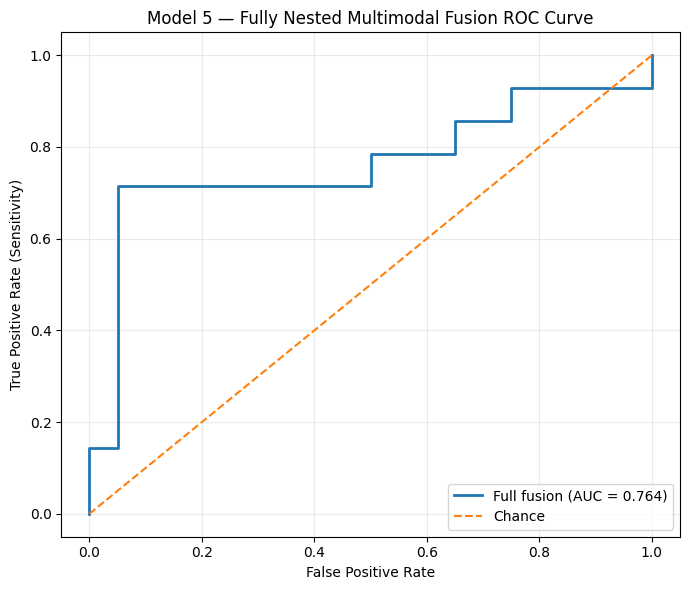

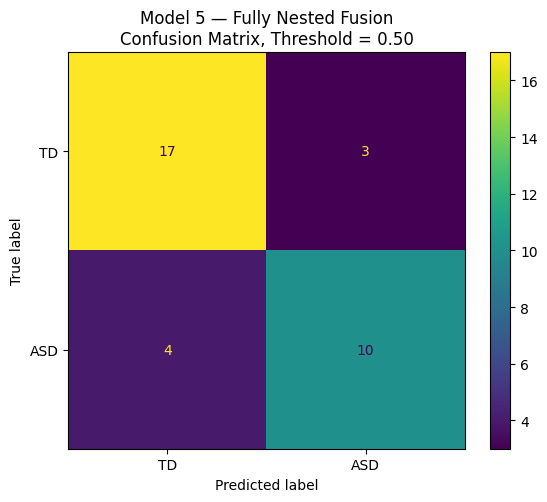

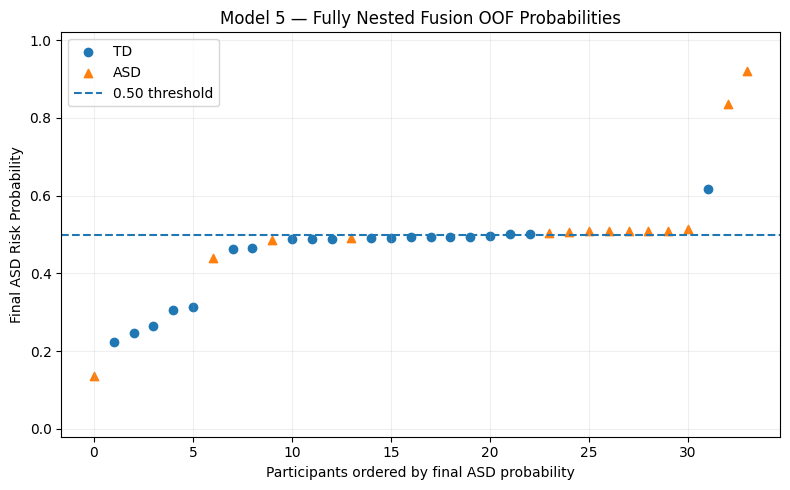


Fusion misclassified participants at threshold 0.50:


,Participant_ID,Group,True_Label,Outer_Fold,P_shape_ASD_nested,P_colour_ASD_nested,P_DAM_ASD_nested,P_questionnaire_ASD_nested,Final_ASD_Risk_Probability,Predicted_Label_0.5
32,P038,ASD,1,4,0.0543,0.1723,0.2798,0.1456,0.1369,0
27,P033,ASD,1,5,0.7659,0.7372,0.3657,0.1405,0.4394,0
20,P026,ASD,1,5,0.7317,0.7052,0.8916,0.1405,0.4848,0
33,P039,ASD,1,1,0.2717,0.1412,0.0112,0.7755,0.4910,0
12,P018,TD,0,3,0.5342,0.7973,0.5364,0.0903,0.5004,1
14,P020,TD,0,2,0.5882,0.7251,0.5301,0.0619,0.5004,1
1,P007,TD,0,5,0.3510,0.2902,0.3309,0.8066,0.6172,1



Primary model comparison:


,Model,Accuracy,Balanced_Accuracy,Precision,Recall_Sensitivity,Specificity,F1,AUC_ROC,PR_AUC
0,Shape,0.8529,0.8536,0.8000,0.8571,0.85,0.8276,0.8714,0.9186
1,Colour,0.8235,0.8179,0.7857,0.7857,0.85,0.7857,0.8143,0.7261
2,Draw-a-Man,0.6471,0.6571,0.5556,0.7143,0.60,0.6250,0.7143,0.6823
3,Questionnaire (XGBoost),0.8529,0.8321,0.9091,0.7143,0.95,0.8000,0.8554,0.8453
4,Fully Nested Fusion,0.7941,0.7821,0.7692,0.7143,0.85,0.7407,0.7643,0.7638


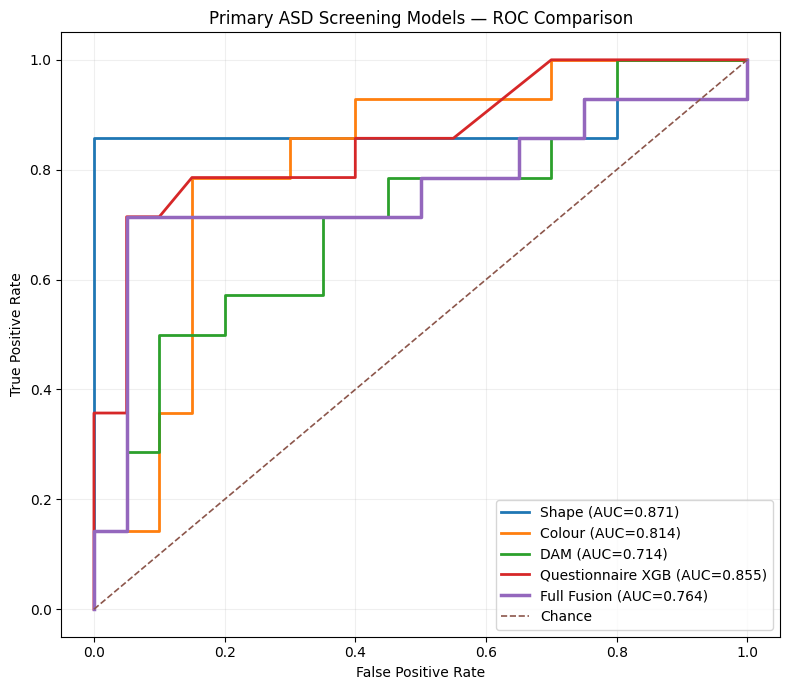


Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_roc_curve.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_confusion_matrix.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_fusion_probability_distribution.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/primary_models_roc_comparison.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/primary_model_comparison.csv

Model 5 evaluation and primary model comparison completed successfully.


In [ ]:
# ============================================================
# MODEL 5 — FINAL FUSION SUMMARY
# ============================================================

print("=" * 70)
print("MODEL 5 — FULLY NESTED FUSION FINAL SUMMARY")
print("=" * 70)

for metric_name, metric_value in fusion_metrics.items():

    print(
        f"{metric_name:22s}: "
        f"{metric_value:.4f}"
    )


# ============================================================
# FUSION ROC CURVE
# ============================================================

fpr_fusion, tpr_fusion, _ = roc_curve(
    y,
    fusion_oof_proba
)

fusion_auc = auc(
    fpr_fusion,
    tpr_fusion
)


fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.plot(
    fpr_fusion,
    tpr_fusion,
    linewidth=2,
    label=f"Full fusion (AUC = {fusion_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate (Sensitivity)"
)

ax.set_title(
    "Model 5 — Fully Nested Multimodal Fusion ROC Curve"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()


fusion_roc_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_roc_curve.png"
)

fig.savefig(
    fusion_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FUSION CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y,
    fusion_oof_pred,
    labels=[0, 1],
    display_labels=[
        "TD",
        "ASD"
    ],
    values_format="d",
    ax=ax
)

ax.set_title(
    "Model 5 — Fully Nested Fusion\n"
    "Confusion Matrix, Threshold = 0.50"
)

fig.tight_layout()


fusion_cm_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_confusion_matrix.png"
)

fig.savefig(
    fusion_cm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT-LEVEL FUSION PROBABILITIES
# ============================================================

sorted_idx = np.argsort(
    fusion_oof_proba
)

sorted_probs = fusion_oof_proba[
    sorted_idx
]

sorted_labels = y[
    sorted_idx
]

positions = np.arange(
    len(y)
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

td_mask = (
    sorted_labels == 0
)

asd_mask = (
    sorted_labels == 1
)


ax.scatter(
    positions[td_mask],
    sorted_probs[td_mask],
    label="TD",
    marker="o"
)

ax.scatter(
    positions[asd_mask],
    sorted_probs[asd_mask],
    label="ASD",
    marker="^"
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="0.50 threshold"
)

ax.set_ylim(
    -0.02,
    1.02
)

ax.set_xlabel(
    "Participants ordered by final ASD probability"
)

ax.set_ylabel(
    "Final ASD Risk Probability"
)

ax.set_title(
    "Model 5 — Fully Nested Fusion OOF Probabilities"
)

ax.legend()

ax.grid(
    alpha=0.20
)

fig.tight_layout()


fusion_probability_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_fusion_probability_distribution.png"
)

fig.savefig(
    fusion_probability_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FUSION MISCLASSIFICATIONS
# ============================================================

misclassified_fusion = (
    fusion_predictions_df[
        fusion_predictions_df["True_Label"]
        !=
        fusion_predictions_df["Predicted_Label_0.5"]
    ]
    .copy()
)


print(
    "\nFusion misclassified participants "
    "at threshold 0.50:"
)

display(
    misclassified_fusion[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "P_shape_ASD_nested",
            "P_colour_ASD_nested",
            "P_DAM_ASD_nested",
            "P_questionnaire_ASD_nested",
            "Final_ASD_Risk_Probability",
            "Predicted_Label_0.5"
        ]
    ]
    .sort_values(
        "Final_ASD_Risk_Probability"
    )
    .round(4)
)


# ============================================================
# PRIMARY MODEL COMPARISON TABLE
# ============================================================

primary_model_comparison_df = pd.DataFrame([

    {
        "Model":
            "Shape",

        **shape_metrics_complete
    },

    {
        "Model":
            "Colour",

        **colour_metrics
    },

    {
        "Model":
            "Draw-a-Man",

        **dam_metrics
    },

    {
        "Model":
            "Questionnaire (XGBoost)",

        **{
            key:
                questionnaire_xgb_metrics[key]

            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Precision",
                "Recall_Sensitivity",
                "Specificity",
                "F1",
                "AUC_ROC",
                "PR_AUC"
            ]
        }
    },

    {
        "Model":
            "Fully Nested Fusion",

        **fusion_metrics
    }

])


# Keep columns in a clean order

comparison_columns = [

    "Model",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]


primary_model_comparison_df = (
    primary_model_comparison_df[
        comparison_columns
    ]
)


print(
    "\nPrimary model comparison:"
)

display(
    primary_model_comparison_df
    .round(4)
)


# ============================================================
# COMBINED ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)


# Shape
fpr, tpr, _ = roc_curve(
    y,
    shape_oof_proba
)

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"Shape "
        f"(AUC={shape_metrics_complete['AUC_ROC']:.3f})"
    )
)


# Colour
fpr, tpr, _ = roc_curve(
    y,
    colour_oof_proba
)

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"Colour "
        f"(AUC={colour_metrics['AUC_ROC']:.3f})"
    )
)


# DAM
fpr, tpr, _ = roc_curve(
    y,
    dam_oof_proba
)

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"DAM "
        f"(AUC={dam_metrics['AUC_ROC']:.3f})"
    )
)


# Questionnaire XGBoost
fpr, tpr, _ = roc_curve(
    y,
    questionnaire_xgb_oof_proba
)

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        "Questionnaire XGB "
        f"(AUC={questionnaire_xgb_metrics['AUC_ROC']:.3f})"
    )
)


# Fusion
fpr, tpr, _ = roc_curve(
    y,
    fusion_oof_proba
)

ax.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=(
        f"Full Fusion "
        f"(AUC={fusion_metrics['AUC_ROC']:.3f})"
    )
)


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2,
    label="Chance"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "Primary ASD Screening Models — ROC Comparison"
)

ax.legend(
    loc="lower right"
)

ax.grid(
    alpha=0.20
)

fig.tight_layout()


combined_roc_file = os.path.join(
    RESULTS_DIR,
    "primary_models_roc_comparison.png"
)

fig.savefig(
    combined_roc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE COMPARISON
# ============================================================

primary_comparison_file = os.path.join(
    RESULTS_DIR,
    "primary_model_comparison.csv"
)

primary_model_comparison_df.to_csv(
    primary_comparison_file,
    index=False
)


print("\nSaved:")
print(fusion_roc_file)
print(fusion_cm_file)
print(fusion_probability_file)
print(combined_roc_file)
print(primary_comparison_file)

print(
    "\nModel 5 evaluation and "
    "primary model comparison completed successfully."
)

# Model 6 — Fully Nested Ablation Analysis

## 25. Modality Contribution Analysis

An exploratory ablation analysis is performed to investigate how individual
modalities contribute to multimodal screening performance.

The following configurations are evaluated:

1. Full fusion — Shape + Colour + Draw-a-Man + Questionnaire
2. Without Shape
3. Without Colour
4. Without Draw-a-Man
5. Without Questionnaire — drawing-only fusion
6. Shape + Colour only

Every ablation uses the same fully nested stacking procedure as the primary
fusion model.

Within each outer fold:

- outer-test participants remain completely untouched;
- cross-fitted predictions for all base models are generated only from
  outer-training participants;
- each ablation meta-classifier is trained only from the appropriate subset
  of those cross-fitted probabilities;
- hyperparameter selection occurs only within the outer-training data;
- the final ablation model predicts the untouched outer-test participants.

Therefore, differences between ablation configurations are not produced by
training a secondary model directly on previously evaluated test predictions.

These analyses are treated as exploratory because their purpose is to
understand modality contribution after evaluation of the pre-specified full
fusion model.

In [ ]:
# ============================================================
# MODEL 6 — FULLY NESTED ABLATION ANALYSIS
# ============================================================

print("=" * 70)
print("MODEL 6 — FULLY NESTED ABLATION ANALYSIS")
print("=" * 70)


# ============================================================
# ABLATION DEFINITIONS
#
# Column order:
# 0 = Shape
# 1 = Colour
# 2 = DAM
# 3 = Questionnaire
# ============================================================

ABLATION_CONFIGS = {

    "Full":
        [0, 1, 2, 3],

    "No Shape":
        [1, 2, 3],

    "No Colour":
        [0, 2, 3],

    "No DAM":
        [0, 1, 3],

    "No Questionnaire (Drawing-only)":
        [0, 1, 2],

    "Shape + Colour":
        [0, 1]
}


# ============================================================
# STORAGE
# ============================================================

ablation_oof_proba = {

    name:
        np.full(
            len(y),
            np.nan,
            dtype=np.float64
        )

    for name in ABLATION_CONFIGS
}


ablation_oof_pred = {

    name:
        np.full(
            len(y),
            -1,
            dtype=np.int64
        )

    for name in ABLATION_CONFIGS
}


ablation_fold_records = []


# ============================================================
# SAME OUTER CV AS PRIMARY FUSION
# ============================================================

ablation_outer_cv = StratifiedKFold(
    n_splits=FUSION_OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# OUTER LOOP
# ============================================================

for outer_fold, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    ablation_outer_cv.split(
        X_shape,
        y
    ),

    start=1
):

    print(
        "\n" +
        "-" * 70
    )

    print(
        f"ABLATION OUTER FOLD {outer_fold}"
    )

    print(
        "-" * 70
    )


    y_outer_train = y[
        outer_train_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    # ========================================================
    # PARTICIPANT LEAKAGE CHECK
    # ========================================================

    train_ids = set(
        participant_ids_safe[
            outer_train_idx
        ]
    )

    test_ids = set(
        participant_ids_safe[
            outer_test_idx
        ]
    )

    overlap = (
        train_ids
        &
        test_ids
    )

    if overlap:

        raise RuntimeError(
            f"Participant leakage detected "
            f"in ablation fold {outer_fold}: "
            f"{overlap}"
        )


    n_outer_train = len(
        outer_train_idx
    )


    # ========================================================
    # CROSS-FITTED LEVEL-1 FEATURES
    #
    # Generate ALL four base probabilities once.
    # Each ablation later selects only required columns.
    # ========================================================

    meta_train_all = np.full(
        (
            n_outer_train,
            4
        ),
        np.nan,
        dtype=np.float64
    )


    stacking_cv = StratifiedKFold(
        n_splits=STACKING_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            1000
            +
            outer_fold
        )
    )


    # ========================================================
    # STACKING CROSS-FIT
    # ========================================================

    for stack_fold, (
        stack_train_rel,
        stack_valid_rel
    ) in enumerate(

        stacking_cv.split(
            np.zeros(
                n_outer_train
            ),
            y_outer_train
        ),

        start=1
    ):

        stack_train_abs = (
            outer_train_idx[
                stack_train_rel
            ]
        )

        stack_valid_abs = (
            outer_train_idx[
                stack_valid_rel
            ]
        )

        y_stack_train = y[
            stack_train_abs
        ]


        # ----------------------------------------------------
        # SHAPE
        # ----------------------------------------------------

        shape_model, _ = fit_tuned_lr_base(

            X_shape[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                2000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_all[
            stack_valid_rel,
            0
        ] = shape_model.predict_proba(

            X_shape[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # COLOUR
        # ----------------------------------------------------

        colour_model, _ = fit_tuned_lr_base(

            X_colour[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                3000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_all[
            stack_valid_rel,
            1
        ] = colour_model.predict_proba(

            X_colour[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # DRAW-A-MAN
        # ----------------------------------------------------

        dam_model, _ = fit_tuned_lr_base(

            X_dam[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                4000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_all[
            stack_valid_rel,
            2
        ] = dam_model.predict_proba(

            X_dam[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # QUESTIONNAIRE — PRIMARY XGBOOST
        # ----------------------------------------------------

        questionnaire_model, _ = fit_tuned_xgb_base(

            X_questionnaire[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                5000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_all[
            stack_valid_rel,
            3
        ] = questionnaire_model.predict_proba(

            X_questionnaire[
                stack_valid_abs
            ]

        )[:, 1]


    # ========================================================
    # VALIDATE LEVEL-1 TRAINING MATRIX
    # ========================================================

    if np.isnan(
        meta_train_all
    ).any():

        raise RuntimeError(
            f"Missing cross-fitted predictions "
            f"in outer fold {outer_fold}."
        )


    if not np.all(
        (
            meta_train_all >= 0
        )
        &
        (
            meta_train_all <= 1
        )
    ):

        raise RuntimeError(
            f"Invalid cross-fitted probabilities "
            f"in outer fold {outer_fold}."
        )


    # ========================================================
    # TRAIN FINAL BASE MODELS USING COMPLETE OUTER TRAINING SET
    # ========================================================

    final_shape_model, _ = fit_tuned_lr_base(

        X_shape[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            6000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    final_colour_model, _ = fit_tuned_lr_base(

        X_colour[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            7000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    final_dam_model, _ = fit_tuned_lr_base(

        X_dam[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            8000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    final_questionnaire_model, _ = fit_tuned_xgb_base(

        X_questionnaire[
            outer_train_idx
        ],

        y_outer_train,

        random_state=(
            SEED
            +
            9000
            +
            outer_fold
        ),

        tuning_folds=
            INNER_FOLDS
    )


    # ========================================================
    # OUTER-TEST BASE PROBABILITIES
    # ========================================================

    outer_test_all = np.column_stack([

        final_shape_model.predict_proba(
            X_shape[
                outer_test_idx
            ]
        )[:, 1],

        final_colour_model.predict_proba(
            X_colour[
                outer_test_idx
            ]
        )[:, 1],

        final_dam_model.predict_proba(
            X_dam[
                outer_test_idx
            ]
        )[:, 1],

        final_questionnaire_model.predict_proba(
            X_questionnaire[
                outer_test_idx
            ]
        )[:, 1]
    ])


    # ========================================================
    # FIT EACH ABLATION META-CLASSIFIER
    # ========================================================

    for config_number, (
        config_name,
        selected_columns
    ) in enumerate(
        ABLATION_CONFIGS.items(),
        start=1
    ):

        meta_train_subset = (
            meta_train_all[
                :,
                selected_columns
            ]
        )

        meta_test_subset = (
            outer_test_all[
                :,
                selected_columns
            ]
        )


        # ----------------------------------------------------
        # META MODEL
        # ----------------------------------------------------

        meta_pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=SEED
                )
            )
        ])


        meta_cv = StratifiedKFold(
            n_splits=META_TUNING_FOLDS,
            shuffle=True,

            # Keep each configuration deterministic,
            # while preserving the primary Full configuration
            # seed from Model 5.
            random_state=(
                SEED
                +
                10000
                +
                outer_fold
                +
                (
                    0
                    if config_name == "Full"
                    else config_number * 100
                )
            )
        )


        meta_search = GridSearchCV(

            estimator=meta_pipeline,

            param_grid={
                "classifier__C":
                    C_GRID
            },

            scoring="roc_auc",

            cv=meta_cv,

            refit=True,

            n_jobs=-1,

            return_train_score=False
        )


        meta_search.fit(
            meta_train_subset,
            y_outer_train
        )


        best_meta_model = (
            meta_search
            .best_estimator_
        )


        best_meta_c = (
            meta_search
            .best_params_[
                "classifier__C"
            ]
        )


        # ----------------------------------------------------
        # HELD-OUT PREDICTION
        # ----------------------------------------------------

        test_proba = (
            best_meta_model
            .predict_proba(
                meta_test_subset
            )[:, 1]
        )


        test_pred = (
            test_proba
            >=
            0.50
        ).astype(
            np.int64
        )


        ablation_oof_proba[
            config_name
        ][
            outer_test_idx
        ] = test_proba


        ablation_oof_pred[
            config_name
        ][
            outer_test_idx
        ] = test_pred


        # ----------------------------------------------------
        # FOLD METRICS
        # ----------------------------------------------------

        tn_f, fp_f, fn_f, tp_f = confusion_matrix(
            y_outer_test,
            test_pred,
            labels=[0, 1]
        ).ravel()


        specificity_f = (
            tn_f / (tn_f + fp_f)
            if (tn_f + fp_f) > 0
            else np.nan
        )


        ablation_fold_records.append({

            "Fold":
                outer_fold,

            "Configuration":
                config_name,

            "Modalities":
                len(
                    selected_columns
                ),

            "Meta_C":
                best_meta_c,

            "AUC":
                roc_auc_score(
                    y_outer_test,
                    test_proba
                ),

            "Recall":
                recall_score(
                    y_outer_test,
                    test_pred,
                    zero_division=0
                ),

            "Specificity":
                specificity_f
        })


    print(
        f"Outer fold {outer_fold} completed "
        f"for all {len(ABLATION_CONFIGS)} configurations."
    )


# ============================================================
# STRICT VALIDATION
# ============================================================

for config_name in ABLATION_CONFIGS:

    probabilities = (
        ablation_oof_proba[
            config_name
        ]
    )

    predictions = (
        ablation_oof_pred[
            config_name
        ]
    )


    if np.isnan(
        probabilities
    ).any():

        raise RuntimeError(
            f"{config_name}: "
            f"missing OOF probabilities."
        )


    if not np.all(
        (
            probabilities >= 0
        )
        &
        (
            probabilities <= 1
        )
    ):

        raise RuntimeError(
            f"{config_name}: "
            f"invalid probabilities."
        )


    if (
        predictions < 0
    ).any():

        raise RuntimeError(
            f"{config_name}: "
            f"missing predictions."
        )


# ============================================================
# CHECK REPRODUCTION OF PRIMARY FULL FUSION
# ============================================================

full_probability_difference = np.max(
    np.abs(
        ablation_oof_proba["Full"]
        -
        fusion_oof_proba
    )
)

print(
    "\nMaximum absolute difference between "
    "re-run Full fusion and Model 5:",
    f"{full_probability_difference:.10f}"
)

if full_probability_difference <= 1e-6:

    print(
        "Full fusion reproduction check: PASS"
    )

else:

    print(
        "Full fusion reproduction check: "
        "small computational difference detected."
    )


# ============================================================
# OVERALL ABLATION METRICS
# ============================================================

ablation_summary_records = []


for config_name in ABLATION_CONFIGS:

    probabilities = (
        ablation_oof_proba[
            config_name
        ]
    )

    predictions = (
        ablation_oof_pred[
            config_name
        ]
    )


    tn, fp, fn, tp = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    ).ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    ablation_summary_records.append({

        "Configuration":
            config_name,

        "Accuracy":
            accuracy_score(
                y,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y,
                predictions
            ),

        "Precision":
            precision_score(
                y,
                predictions,
                zero_division=0
            ),

        "Recall_Sensitivity":
            recall_score(
                y,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y,
                predictions,
                zero_division=0
            ),

        "AUC_ROC":
            roc_auc_score(
                y,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y,
                probabilities
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp)
    })


ablation_summary_df = pd.DataFrame(
    ablation_summary_records
)


ablation_fold_results_df = pd.DataFrame(
    ablation_fold_records
)


# ============================================================
# PRINT RESULTS
# ============================================================

print(
    "\n" +
    "=" * 70
)

print(
    "FULLY NESTED ABLATION SUMMARY"
)

print(
    "=" * 70
)


display(
    ablation_summary_df[
        [
            "Configuration",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall_Sensitivity",
            "Specificity",
            "F1",
            "AUC_ROC",
            "PR_AUC",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ]
    .sort_values(
        "AUC_ROC",
        ascending=False
    )
    .round(4)
)


print(
    "\nFold-level ablation results:"
)

display(
    ablation_fold_results_df
    .round(4)
)


# ============================================================
# SAVE PARTICIPANT-LEVEL ABLATION PREDICTIONS
# ============================================================

ablation_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y
})


for config_name in ABLATION_CONFIGS:

    safe_name = (
        config_name
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
    )

    ablation_predictions_df[
        f"P_{safe_name}"
    ] = ablation_oof_proba[
        config_name
    ]

    ablation_predictions_df[
        f"Pred_{safe_name}_0.5"
    ] = ablation_oof_pred[
        config_name
    ]


# ============================================================
# SAVE
# ============================================================

ablation_summary_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_ablation_summary.csv"
)

ablation_folds_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_ablation_folds.csv"
)

ablation_predictions_file = os.path.join(
    RESULTS_DIR,
    "fully_nested_ablation_predictions.csv"
)


ablation_summary_df.to_csv(
    ablation_summary_file,
    index=False
)

ablation_fold_results_df.to_csv(
    ablation_folds_file,
    index=False
)

ablation_predictions_df.to_csv(
    ablation_predictions_file,
    index=False
)


print("\nSaved:")
print(ablation_summary_file)
print(ablation_folds_file)
print(ablation_predictions_file)

print(
    "\nFully nested ablation analysis "
    "completed successfully."
)

MODEL 6 — FULLY NESTED ABLATION ANALYSIS

----------------------------------------------------------------------
ABLATION OUTER FOLD 1
----------------------------------------------------------------------
Outer fold 1 completed for all 6 configurations.

----------------------------------------------------------------------
ABLATION OUTER FOLD 2
----------------------------------------------------------------------
Outer fold 2 completed for all 6 configurations.

----------------------------------------------------------------------
ABLATION OUTER FOLD 3
----------------------------------------------------------------------
Outer fold 3 completed for all 6 configurations.

----------------------------------------------------------------------
ABLATION OUTER FOLD 4
----------------------------------------------------------------------
Outer fold 4 completed for all 6 configurations.

----------------------------------------------------------------------
ABLATION OUTER FOLD 5
---------

,Configuration,Accuracy,Balanced_Accuracy,Precision,Recall_Sensitivity,Specificity,F1,AUC_ROC,PR_AUC,TN,FP,FN,TP
1,No Shape,0.8529,0.8429,0.8462,0.7857,0.90,0.8148,0.9107,0.9108,18,2,3,11
2,No Colour,0.8529,0.8429,0.8462,0.7857,0.90,0.8148,0.8929,0.9101,18,2,3,11
5,Shape + Colour,0.8529,0.8429,0.8462,0.7857,0.90,0.8148,0.8429,0.8787,18,2,3,11
4,No Questionnaire (Drawing-only),0.8235,0.8179,0.7857,0.7857,0.85,0.7857,0.8250,0.8085,17,3,3,11
3,No DAM,0.8235,0.8071,0.8333,0.7143,0.90,0.7692,0.7964,0.7243,18,2,4,10
0,Full,0.7941,0.7821,0.7692,0.7143,0.85,0.7407,0.7643,0.7638,17,3,4,10



Fold-level ablation results:


,Fold,Configuration,Modalities,Meta_C,AUC,Recall,Specificity
0,1,Full,4,0.001,0.9167,0.6667,1.00
1,1,No Shape,3,0.001,0.9167,0.6667,1.00
2,1,No Colour,3,0.001,1.0000,0.6667,1.00
3,1,No DAM,3,0.001,0.9167,0.6667,1.00
4,1,No Questionnaire (Drawing-only),3,0.001,0.7500,0.6667,1.00
5,1,Shape + Colour,2,100.000,0.7500,0.6667,1.00
6,2,Full,4,0.001,1.0000,1.0000,0.75
7,2,No Shape,3,100.000,1.0000,1.0000,1.00
8,2,No Colour,3,0.001,1.0000,1.0000,1.00
9,2,No DAM,3,0.001,1.0000,1.0000,0.75



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_ablation_summary.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_ablation_folds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fully_nested_ablation_predictions.csv

Fully nested ablation analysis completed successfully.


## 26. Ablation Analysis Visualization

The fully nested ablation experiments are compared using ROC-AUC,
sensitivity, specificity, and balanced accuracy.

The full four-modality fusion remains the pre-specified primary multimodal
model.

Ablation configurations are interpreted as exploratory analyses of modality
interaction. Higher performance of an ablated model does not constitute
independent evidence that the removed modality should be excluded from a
future model, because the ablations were examined after observing the primary
fusion result.

In the current pilot cohort, multimodal performance appears sensitive to the
combination of modalities, consistent with model instability expected from a
small sample.

MODEL 6 — ABLATION VISUALIZATION


,Configuration,Accuracy,Balanced_Accuracy,Recall_Sensitivity,Specificity,F1,AUC_ROC,PR_AUC
0,No Shape,0.8529,0.8429,0.7857,0.90,0.8148,0.9107,0.9108
1,No Colour,0.8529,0.8429,0.7857,0.90,0.8148,0.8929,0.9101
2,Shape + Colour,0.8529,0.8429,0.7857,0.90,0.8148,0.8429,0.8787
3,No Questionnaire (Drawing-only),0.8235,0.8179,0.7857,0.85,0.7857,0.8250,0.8085
4,No DAM,0.8235,0.8071,0.7143,0.90,0.7692,0.7964,0.7243
5,Full,0.7941,0.7821,0.7143,0.85,0.7407,0.7643,0.7638


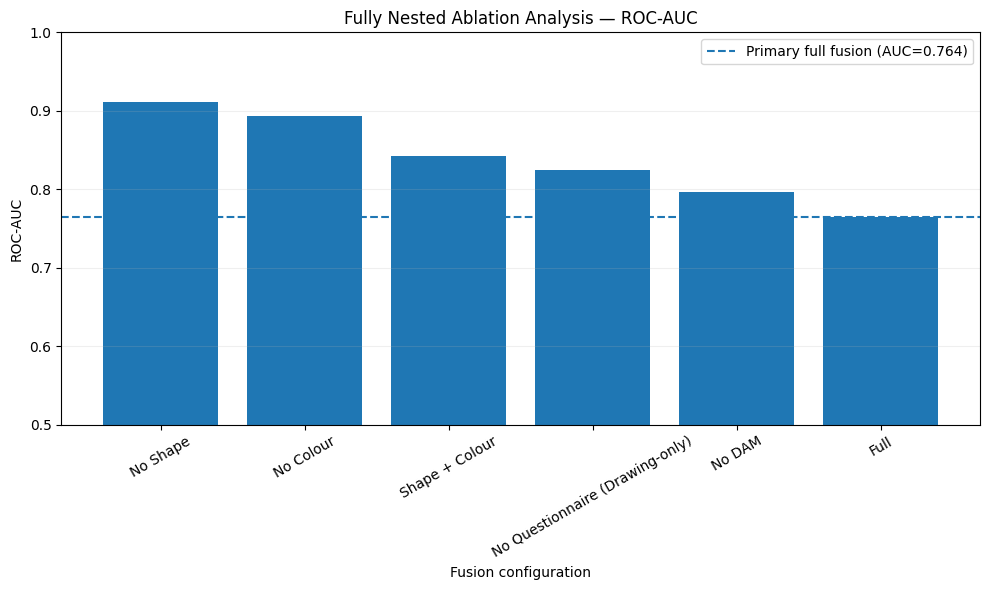


ROC-AUC change relative to the pre-specified Full fusion:


,Configuration,AUC_ROC,Delta_AUC_vs_Full
0,No Shape,0.9107,0.1464
1,No Colour,0.8929,0.1286
2,Shape + Colour,0.8429,0.0786
3,No Questionnaire (Drawing-only),0.8250,0.0607
4,No DAM,0.7964,0.0321
5,Full,0.7643,0.0000


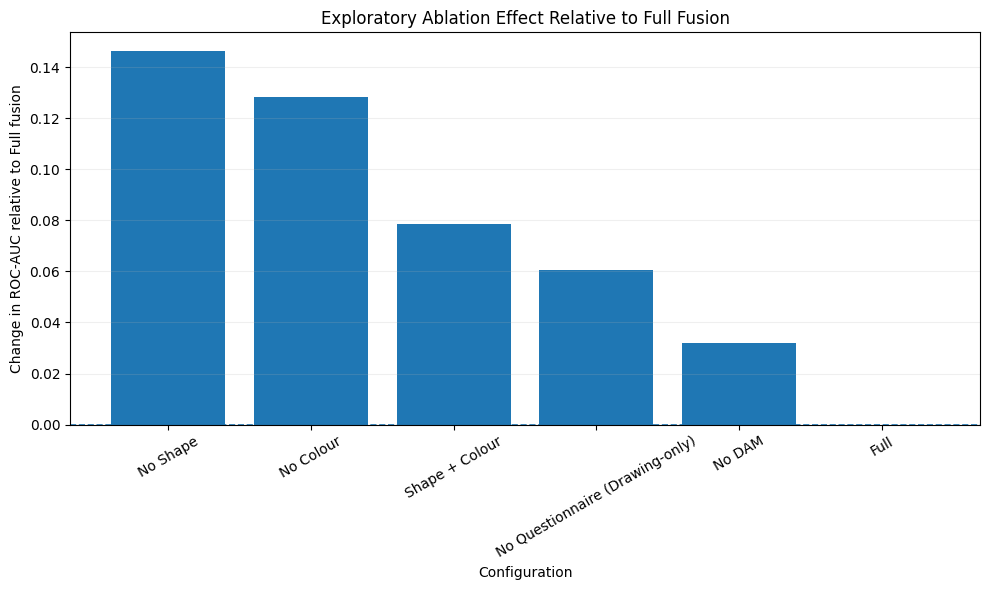

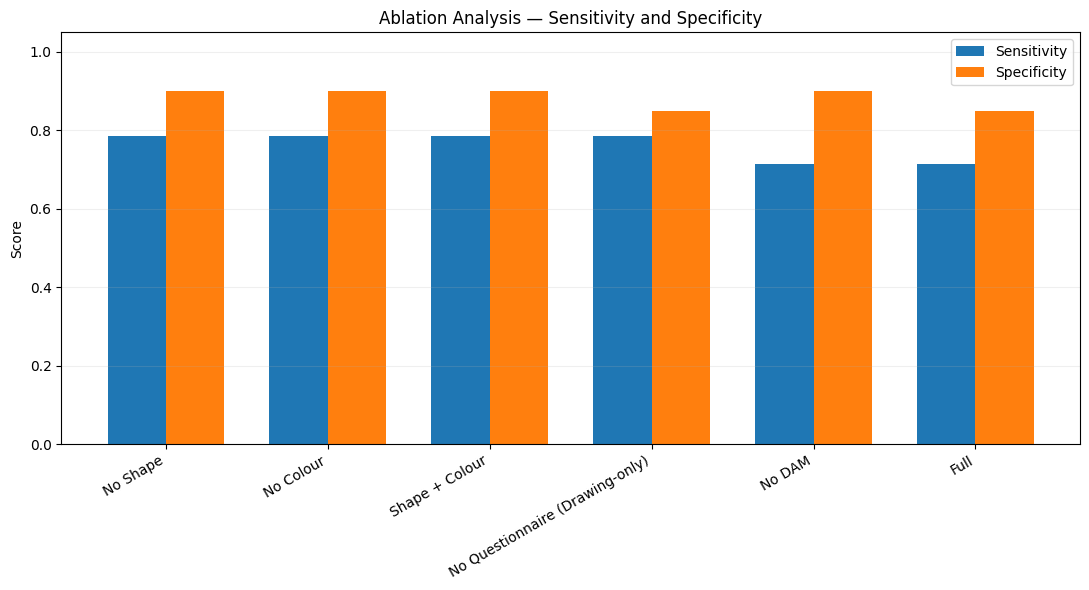

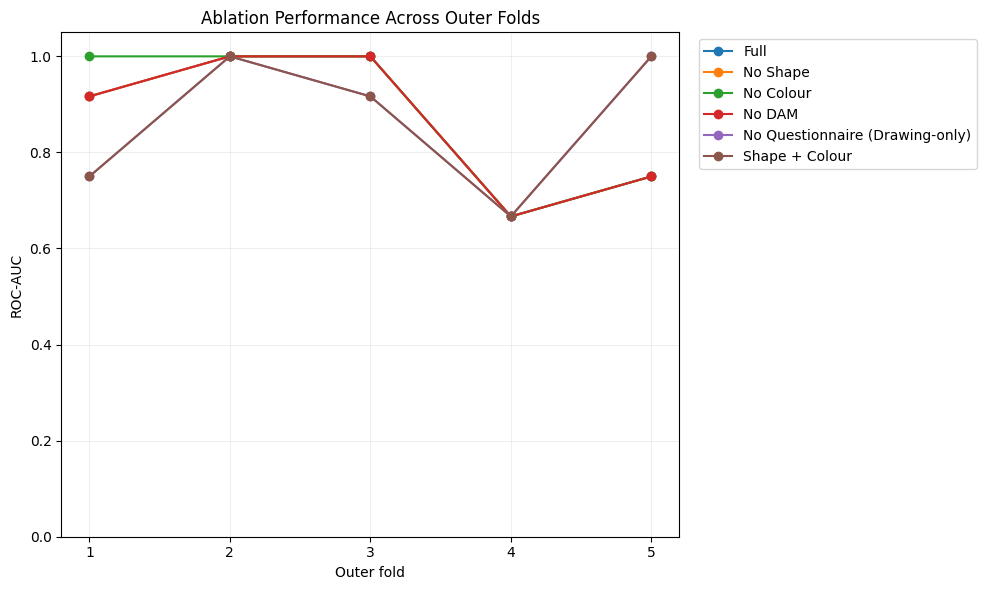


Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/ablation_auc_comparison.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/ablation_auc_delta_vs_full.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/ablation_sensitivity_specificity.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/ablation_fold_auc_variability.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/ablation_auc_delta_vs_full.csv

Ablation visualization completed successfully.


In [ ]:
# ============================================================
# MODEL 6 — ABLATION VISUALIZATION
# ============================================================

print("=" * 70)
print("MODEL 6 — ABLATION VISUALIZATION")
print("=" * 70)


# ============================================================
# ORDER CONFIGURATIONS BY ROC-AUC
# ============================================================

ablation_plot_df = (
    ablation_summary_df
    .sort_values(
        "AUC_ROC",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    ablation_plot_df[
        [
            "Configuration",
            "Accuracy",
            "Balanced_Accuracy",
            "Recall_Sensitivity",
            "Specificity",
            "F1",
            "AUC_ROC",
            "PR_AUC"
        ]
    ]
    .round(4)
)


# ============================================================
# 1. ROC-AUC BY ABLATION CONFIGURATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    ablation_plot_df["Configuration"],
    ablation_plot_df["AUC_ROC"]
)

ax.axhline(
    fusion_metrics["AUC_ROC"],
    linestyle="--",
    linewidth=1.5,
    label=(
        "Primary full fusion "
        f"(AUC={fusion_metrics['AUC_ROC']:.3f})"
    )
)

ax.set_ylim(
    0.50,
    1.00
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_xlabel(
    "Fusion configuration"
)

ax.set_title(
    "Fully Nested Ablation Analysis — ROC-AUC"
)

ax.tick_params(
    axis="x",
    rotation=30
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20
)

fig.tight_layout()


ablation_auc_file = os.path.join(
    RESULTS_DIR,
    "ablation_auc_comparison.png"
)

fig.savefig(
    ablation_auc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. DIFFERENCE FROM FULL FUSION
# ============================================================

full_auc = float(
    ablation_summary_df.loc[
        ablation_summary_df[
            "Configuration"
        ] == "Full",
        "AUC_ROC"
    ].iloc[0]
)


ablation_delta_df = (
    ablation_summary_df[
        [
            "Configuration",
            "AUC_ROC"
        ]
    ]
    .copy()
)

ablation_delta_df[
    "Delta_AUC_vs_Full"
] = (
    ablation_delta_df[
        "AUC_ROC"
    ]
    -
    full_auc
)


ablation_delta_df = (
    ablation_delta_df
    .sort_values(
        "Delta_AUC_vs_Full",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nROC-AUC change relative to "
    "the pre-specified Full fusion:"
)

display(
    ablation_delta_df
    .round(4)
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    ablation_delta_df[
        "Configuration"
    ],
    ablation_delta_df[
        "Delta_AUC_vs_Full"
    ]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_ylabel(
    "Change in ROC-AUC relative to Full fusion"
)

ax.set_xlabel(
    "Configuration"
)

ax.set_title(
    "Exploratory Ablation Effect Relative to Full Fusion"
)

ax.tick_params(
    axis="x",
    rotation=30
)

ax.grid(
    axis="y",
    alpha=0.20
)

fig.tight_layout()


ablation_delta_file = os.path.join(
    RESULTS_DIR,
    "ablation_auc_delta_vs_full.png"
)

fig.savefig(
    ablation_delta_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. SENSITIVITY AND SPECIFICITY
# ============================================================

metric_plot_df = (
    ablation_plot_df[
        [
            "Configuration",
            "Recall_Sensitivity",
            "Specificity"
        ]
    ]
    .copy()
)


x = np.arange(
    len(metric_plot_df)
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.bar(
    x - width / 2,
    metric_plot_df[
        "Recall_Sensitivity"
    ],
    width,
    label="Sensitivity"
)

ax.bar(
    x + width / 2,
    metric_plot_df[
        "Specificity"
    ],
    width,
    label="Specificity"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metric_plot_df[
        "Configuration"
    ],
    rotation=30,
    ha="right"
)

ax.set_ylim(
    0,
    1.05
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Ablation Analysis — Sensitivity and Specificity"
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20
)

fig.tight_layout()


ablation_sens_spec_file = os.path.join(
    RESULTS_DIR,
    "ablation_sensitivity_specificity.png"
)

fig.savefig(
    ablation_sens_spec_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. OUTER-FOLD ROC-AUC VARIABILITY
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)


for config_name in ABLATION_CONFIGS:

    config_fold_df = (
        ablation_fold_results_df[
            ablation_fold_results_df[
                "Configuration"
            ] == config_name
        ]
        .sort_values(
            "Fold"
        )
    )

    ax.plot(
        config_fold_df[
            "Fold"
        ],
        config_fold_df[
            "AUC"
        ],
        marker="o",
        linewidth=1.5,
        label=config_name
    )


ax.set_xticks(
    range(
        1,
        FUSION_OUTER_FOLDS + 1
    )
)

ax.set_ylim(
    0,
    1.05
)

ax.set_xlabel(
    "Outer fold"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_title(
    "Ablation Performance Across Outer Folds"
)

ax.legend(
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)

ax.grid(
    alpha=0.20
)

fig.tight_layout()


ablation_fold_auc_file = os.path.join(
    RESULTS_DIR,
    "ablation_fold_auc_variability.png"
)

fig.savefig(
    ablation_fold_auc_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE DELTA TABLE
# ============================================================

ablation_delta_table_file = os.path.join(
    RESULTS_DIR,
    "ablation_auc_delta_vs_full.csv"
)

ablation_delta_df.to_csv(
    ablation_delta_table_file,
    index=False
)


print("\nSaved:")
print(ablation_auc_file)
print(ablation_delta_file)
print(ablation_sens_spec_file)
print(ablation_fold_auc_file)
print(ablation_delta_table_file)

print(
    "\nAblation visualization completed successfully."
)

# Model 7 — Uncertainty Estimation

## 27. Stratified Bootstrap Confidence Intervals

Because the primary multimodal cohort contains only 34 participants,
performance estimates are accompanied by uncertainty intervals.

A stratified participant-level bootstrap is applied to the out-of-fold
predictions of the five primary models:

- Shape
- Colour Drawing
- Draw-a-Man
- Questionnaire XGBoost
- Fully Nested Fusion

For each bootstrap replicate, TD and ASD participants are sampled separately
with replacement while preserving the original class counts.

The following metrics are recalculated:

- accuracy
- balanced accuracy
- sensitivity
- specificity
- F1-score
- ROC-AUC
- PR-AUC

The 2.5th and 97.5th percentiles of 5,000 bootstrap replicates are reported as
95% bootstrap intervals.

These intervals describe uncertainty in the observed out-of-fold
participant-level performance. They should not be interpreted as a complete
estimate of uncertainty from all possible model-training and cross-validation
splits.

In [ ]:
# ============================================================
# MODEL 7 — STRATIFIED BOOTSTRAP UNCERTAINTY INTERVALS
# ============================================================

import numpy as np
import pandas as pd
import os

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


print("=" * 70)
print("MODEL 7 — STRATIFIED BOOTSTRAP UNCERTAINTY")
print("=" * 70)


# ============================================================
# CONFIGURATION
# ============================================================

BOOTSTRAP_REPS = 5000

BOOTSTRAP_SEED = (
    SEED + 20000
)

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


# ============================================================
# PRIMARY MODEL OOF PREDICTIONS
# ============================================================

bootstrap_models = {

    "Shape": {
        "proba":
            np.asarray(
                shape_oof_proba,
                dtype=np.float64
            ),

        "pred":
            np.asarray(
                shape_oof_pred,
                dtype=np.int64
            )
    },

    "Colour": {
        "proba":
            np.asarray(
                colour_oof_proba,
                dtype=np.float64
            ),

        "pred":
            np.asarray(
                colour_oof_pred,
                dtype=np.int64
            )
    },

    "Draw-a-Man": {
        "proba":
            np.asarray(
                dam_oof_proba,
                dtype=np.float64
            ),

        "pred":
            np.asarray(
                dam_oof_pred,
                dtype=np.int64
            )
    },

    "Questionnaire (XGBoost)": {
        "proba":
            np.asarray(
                questionnaire_xgb_oof_proba,
                dtype=np.float64
            ),

        "pred":
            np.asarray(
                questionnaire_xgb_oof_pred,
                dtype=np.int64
            )
    },

    "Fully Nested Fusion": {
        "proba":
            np.asarray(
                fusion_oof_proba,
                dtype=np.float64
            ),

        "pred":
            np.asarray(
                fusion_oof_pred,
                dtype=np.int64
            )
    }
}


# ============================================================
# STRICT VALIDATION
# ============================================================

y_bootstrap = np.asarray(
    y,
    dtype=np.int64
)

td_indices = np.where(
    y_bootstrap == 0
)[0]

asd_indices = np.where(
    y_bootstrap == 1
)[0]


print(
    "Participants:",
    len(y_bootstrap)
)

print(
    "TD:",
    len(td_indices)
)

print(
    "ASD:",
    len(asd_indices)
)

print(
    "Bootstrap replicates:",
    BOOTSTRAP_REPS
)


for model_name, model_values in bootstrap_models.items():

    if len(
        model_values["proba"]
    ) != len(
        y_bootstrap
    ):

        raise RuntimeError(
            f"{model_name}: probability length mismatch."
        )

    if len(
        model_values["pred"]
    ) != len(
        y_bootstrap
    ):

        raise RuntimeError(
            f"{model_name}: prediction length mismatch."
        )

    if not np.isfinite(
        model_values["proba"]
    ).all():

        raise RuntimeError(
            f"{model_name}: invalid probabilities."
        )


# ============================================================
# HELPER — METRICS
# ============================================================

def bootstrap_metric_values(
    y_true,
    probabilities,
    predictions
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )


    return {

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "Recall_Sensitivity":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "AUC_ROC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            )
    }


METRIC_NAMES = [
    "Accuracy",
    "Balanced_Accuracy",
    "Recall_Sensitivity",
    "Specificity",
    "F1",
    "AUC_ROC",
    "PR_AUC"
]


# ============================================================
# GENERATE STRATIFIED BOOTSTRAP INDEX SETS
#
# Generate once and use exactly the same resamples for every
# model. This makes comparisons between models paired.
# ============================================================

bootstrap_indices = []


for _ in range(
    BOOTSTRAP_REPS
):

    sampled_td = rng.choice(
        td_indices,
        size=len(td_indices),
        replace=True
    )

    sampled_asd = rng.choice(
        asd_indices,
        size=len(asd_indices),
        replace=True
    )

    sampled_indices = np.concatenate([
        sampled_td,
        sampled_asd
    ])

    # Randomize order only; class counts remain fixed.
    rng.shuffle(
        sampled_indices
    )

    bootstrap_indices.append(
        sampled_indices
    )


print(
    "\nBootstrap index sets generated successfully."
)


# ============================================================
# BOOTSTRAP ALL PRIMARY MODELS
# ============================================================

bootstrap_raw_records = []

bootstrap_summary_records = []


for model_name, model_values in bootstrap_models.items():

    print(
        f"\nBootstrapping: {model_name}"
    )

    probabilities = (
        model_values["proba"]
    )

    predictions = (
        model_values["pred"]
    )


    # --------------------------------------------------------
    # Original point estimate
    # --------------------------------------------------------

    point_metrics = bootstrap_metric_values(

        y_bootstrap,
        probabilities,
        predictions
    )


    model_bootstrap_values = {

        metric_name: []

        for metric_name in METRIC_NAMES
    }


    # --------------------------------------------------------
    # Bootstrap replicates
    # --------------------------------------------------------

    for bootstrap_number, sampled_indices in enumerate(
        bootstrap_indices,
        start=1
    ):

        y_sample = y_bootstrap[
            sampled_indices
        ]

        probability_sample = probabilities[
            sampled_indices
        ]

        prediction_sample = predictions[
            sampled_indices
        ]


        replicate_metrics = bootstrap_metric_values(

            y_sample,
            probability_sample,
            prediction_sample
        )


        for metric_name in METRIC_NAMES:

            metric_value = (
                replicate_metrics[
                    metric_name
                ]
            )

            model_bootstrap_values[
                metric_name
            ].append(
                metric_value
            )


            bootstrap_raw_records.append({

                "Model":
                    model_name,

                "Bootstrap":
                    bootstrap_number,

                "Metric":
                    metric_name,

                "Value":
                    metric_value
            })


    # --------------------------------------------------------
    # 95% percentile intervals
    # --------------------------------------------------------

    for metric_name in METRIC_NAMES:

        values = np.asarray(

            model_bootstrap_values[
                metric_name
            ],

            dtype=np.float64
        )


        ci_lower = np.percentile(
            values,
            2.5
        )

        ci_upper = np.percentile(
            values,
            97.5
        )


        bootstrap_summary_records.append({

            "Model":
                model_name,

            "Metric":
                metric_name,

            "Point_Estimate":
                point_metrics[
                    metric_name
                ],

            "CI_2.5":
                ci_lower,

            "CI_97.5":
                ci_upper,

            "Bootstrap_Mean":
                np.mean(
                    values
                ),

            "Bootstrap_SD":
                np.std(
                    values,
                    ddof=1
                )
        })


# ============================================================
# CREATE TABLES
# ============================================================

bootstrap_summary_df = pd.DataFrame(
    bootstrap_summary_records
)

bootstrap_raw_df = pd.DataFrame(
    bootstrap_raw_records
)


# ============================================================
# MAIN THESIS TABLE — SELECTED METRICS
# ============================================================

main_ci_metrics = [
    "Accuracy",
    "Recall_Sensitivity",
    "Specificity",
    "AUC_ROC",
    "PR_AUC"
]


bootstrap_main_ci_df = (
    bootstrap_summary_df[
        bootstrap_summary_df[
            "Metric"
        ].isin(
            main_ci_metrics
        )
    ]
    .copy()
)


bootstrap_main_ci_df[
    "Estimate_95CI"
] = (

    bootstrap_main_ci_df[
        "Point_Estimate"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    " ["

    +

    bootstrap_main_ci_df[
        "CI_2.5"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    ", "

    +

    bootstrap_main_ci_df[
        "CI_97.5"
    ].map(
        lambda x:
            f"{x:.3f}"
    )

    +

    "]"
)


# ============================================================
# PRINT AUC INTERVALS
# ============================================================

print(
    "\n" +
    "=" * 70
)

print(
    "ROC-AUC WITH 95% STRATIFIED BOOTSTRAP INTERVALS"
)

print(
    "=" * 70
)


auc_ci_df = (
    bootstrap_summary_df[
        bootstrap_summary_df[
            "Metric"
        ] == "AUC_ROC"
    ]
    [
        [
            "Model",
            "Point_Estimate",
            "CI_2.5",
            "CI_97.5",
            "Bootstrap_SD"
        ]
    ]
    .sort_values(
        "Point_Estimate",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    auc_ci_df
    .round(4)
)


# ============================================================
# PRINT SENSITIVITY / SPECIFICITY / ACCURACY
# ============================================================

print(
    "\nMain performance estimates with 95% intervals:"
)


main_ci_pivot = (
    bootstrap_main_ci_df
    .pivot(
        index="Model",
        columns="Metric",
        values="Estimate_95CI"
    )
    .reset_index()
)


desired_order = [
    "Shape",
    "Colour",
    "Draw-a-Man",
    "Questionnaire (XGBoost)",
    "Fully Nested Fusion"
]


main_ci_pivot[
    "Model"
] = pd.Categorical(
    main_ci_pivot[
        "Model"
    ],
    categories=desired_order,
    ordered=True
)


main_ci_pivot = (
    main_ci_pivot
    .sort_values(
        "Model"
    )
    .reset_index(drop=True)
)


display(
    main_ci_pivot
)


# ============================================================
# SAVE RESULTS
# ============================================================

bootstrap_summary_file = os.path.join(
    RESULTS_DIR,
    "primary_models_bootstrap_95ci.csv"
)

bootstrap_main_table_file = os.path.join(
    RESULTS_DIR,
    "primary_models_bootstrap_main_table.csv"
)

bootstrap_raw_file = os.path.join(
    RESULTS_DIR,
    "primary_models_bootstrap_replicates.csv.gz"
)


bootstrap_summary_df.to_csv(
    bootstrap_summary_file,
    index=False
)

main_ci_pivot.to_csv(
    bootstrap_main_table_file,
    index=False
)

bootstrap_raw_df.to_csv(
    bootstrap_raw_file,
    index=False,
    compression="gzip"
)


print("\nSaved:")
print(bootstrap_summary_file)
print(bootstrap_main_table_file)
print(bootstrap_raw_file)

print(
    "\nBootstrap uncertainty analysis completed successfully."
)

MODEL 7 — STRATIFIED BOOTSTRAP UNCERTAINTY
Participants: 34
TD: 20
ASD: 14
Bootstrap replicates: 5000

Bootstrap index sets generated successfully.

Bootstrapping: Shape

Bootstrapping: Colour

Bootstrapping: Draw-a-Man

Bootstrapping: Questionnaire (XGBoost)

Bootstrapping: Fully Nested Fusion

ROC-AUC WITH 95% STRATIFIED BOOTSTRAP INTERVALS


,Model,Point_Estimate,CI_2.5,CI_97.5,Bootstrap_SD
0,Shape,0.8714,0.6857,1.0000,0.0840
1,Questionnaire (XGBoost),0.8554,0.7036,0.9696,0.0688
2,Colour,0.8143,0.6535,0.9464,0.0766
3,Fully Nested Fusion,0.7643,0.5679,0.9286,0.0939
4,Draw-a-Man,0.7143,0.5214,0.8857,0.0924



Main performance estimates with 95% intervals:


Metric,Model,AUC_ROC,Accuracy,PR_AUC,Recall_Sensitivity,Specificity
0,Shape,"0.871 [0.686, 1.000]","0.853 [0.735, 0.971]","0.919 [0.794, 1.000]","0.857 [0.643, 1.000]","0.850 [0.650, 1.000]"
1,Colour,"0.814 [0.653, 0.946]","0.824 [0.676, 0.941]","0.726 [0.550, 0.933]","0.786 [0.571, 1.000]","0.850 [0.700, 1.000]"
2,Draw-a-Man,"0.714 [0.521, 0.886]","0.647 [0.471, 0.794]","0.682 [0.511, 0.877]","0.714 [0.500, 0.929]","0.600 [0.400, 0.800]"
3,Questionnaire (XGBoost),"0.855 [0.704, 0.970]","0.853 [0.735, 0.971]","0.845 [0.700, 0.967]","0.714 [0.500, 0.929]","0.950 [0.850, 1.000]"
4,Fully Nested Fusion,"0.764 [0.568, 0.929]","0.794 [0.647, 0.912]","0.764 [0.579, 0.938]","0.714 [0.429, 0.929]","0.850 [0.700, 1.000]"



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/primary_models_bootstrap_95ci.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/primary_models_bootstrap_main_table.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/primary_models_bootstrap_replicates.csv.gz

Bootstrap uncertainty analysis completed successfully.


# Model 8 — Paired Model Comparison

## 28. Paired Bootstrap Differences in ROC-AUC

The primary models are evaluated on the same participants, so their performance
estimates are statistically paired.

To assess whether observed differences in ROC-AUC are stable, the same
stratified bootstrap samples generated for uncertainty estimation are used to
calculate paired differences between models.

The principal comparisons are:

- Shape versus Fully Nested Fusion
- Questionnaire XGBoost versus Fully Nested Fusion
- Colour versus Fully Nested Fusion
- Draw-a-Man versus Fully Nested Fusion
- Shape versus Questionnaire XGBoost

For each comparison, the following are reported:

- observed difference in ROC-AUC
- bootstrap mean difference
- 95% percentile interval for the difference
- proportion of bootstrap replicates in which Model A has a higher AUC than
  Model B

If a 95% difference interval contains zero, the current pilot data do not
provide stable evidence of a performance difference between those models.

These paired bootstrap comparisons are exploratory and should not be treated
as definitive hypothesis tests because the cohort is small and the predictions
originate from cross-validation.

MODEL 8 — PAIRED BOOTSTRAP ROC-AUC COMPARISON

Paired ROC-AUC comparisons:


,Model_A,Model_B,AUC_A,AUC_B,Observed_Delta_AUC,CI_2.5,CI_97.5,P_AUC_A_gt_B,95CI_Excludes_Zero
0,Shape,Fully Nested Fusion,0.8714,0.7643,0.1071,-0.0286,0.2786,0.9222,False
1,Questionnaire (XGBoost),Fully Nested Fusion,0.8554,0.7643,0.0911,-0.0107,0.2232,0.9524,False
2,Colour,Fully Nested Fusion,0.8143,0.7643,0.0500,-0.1714,0.2643,0.6790,False
3,Draw-a-Man,Fully Nested Fusion,0.7143,0.7643,-0.0500,-0.2714,0.1714,0.3286,False
4,Shape,Questionnaire (XGBoost),0.8714,0.8554,0.0161,-0.1857,0.2179,0.5618,False



Interpretation:
Shape vs Fully Nested Fusion: ΔAUC=+0.1071, 95% bootstrap interval [-0.0286, +0.2786], P(AUC_A > AUC_B)=0.922; 95% interval includes zero.
Questionnaire (XGBoost) vs Fully Nested Fusion: ΔAUC=+0.0911, 95% bootstrap interval [-0.0107, +0.2232], P(AUC_A > AUC_B)=0.952; 95% interval includes zero.
Colour vs Fully Nested Fusion: ΔAUC=+0.0500, 95% bootstrap interval [-0.1714, +0.2643], P(AUC_A > AUC_B)=0.679; 95% interval includes zero.
Draw-a-Man vs Fully Nested Fusion: ΔAUC=-0.0500, 95% bootstrap interval [-0.2714, +0.1714], P(AUC_A > AUC_B)=0.329; 95% interval includes zero.
Shape vs Questionnaire (XGBoost): ΔAUC=+0.0161, 95% bootstrap interval [-0.1857, +0.2179], P(AUC_A > AUC_B)=0.562; 95% interval includes zero.


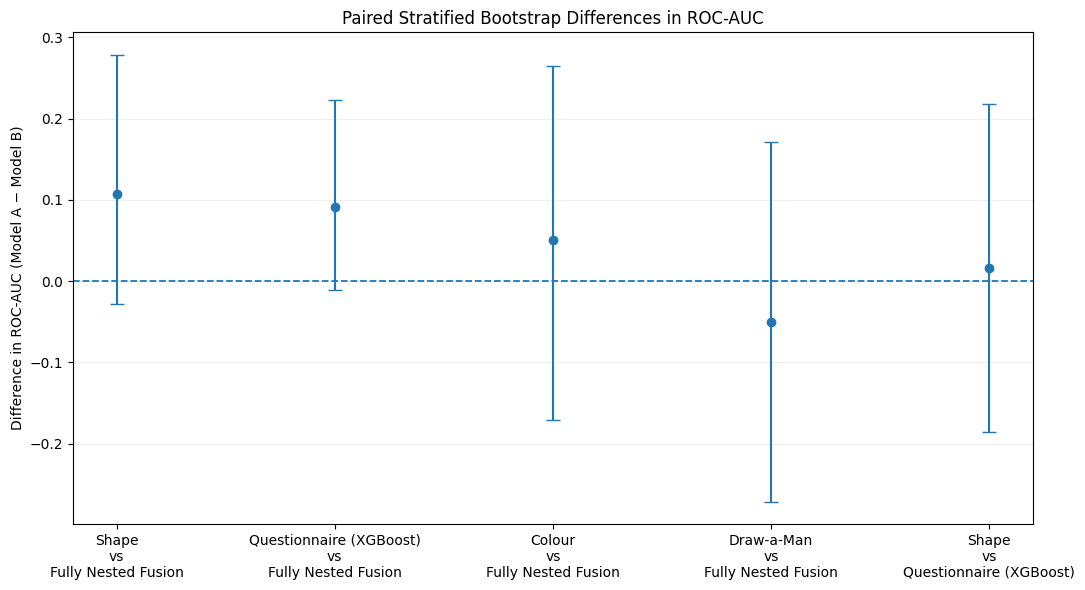


Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/paired_bootstrap_auc_comparisons.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/paired_bootstrap_auc_difference_replicates.csv.gz
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/paired_bootstrap_auc_differences.png

Paired model comparison completed successfully.


In [ ]:
# ============================================================
# MODEL 8 — PAIRED BOOTSTRAP MODEL COMPARISON
# ============================================================

print("=" * 70)
print("MODEL 8 — PAIRED BOOTSTRAP ROC-AUC COMPARISON")
print("=" * 70)


# ============================================================
# MODEL PROBABILITY ARRAYS
# ============================================================

comparison_probabilities = {

    "Shape":
        np.asarray(
            shape_oof_proba,
            dtype=np.float64
        ),

    "Colour":
        np.asarray(
            colour_oof_proba,
            dtype=np.float64
        ),

    "Draw-a-Man":
        np.asarray(
            dam_oof_proba,
            dtype=np.float64
        ),

    "Questionnaire (XGBoost)":
        np.asarray(
            questionnaire_xgb_oof_proba,
            dtype=np.float64
        ),

    "Fully Nested Fusion":
        np.asarray(
            fusion_oof_proba,
            dtype=np.float64
        )
}


# ============================================================
# COMPARISONS OF INTEREST
# ============================================================

MODEL_COMPARISONS = [

    (
        "Shape",
        "Fully Nested Fusion"
    ),

    (
        "Questionnaire (XGBoost)",
        "Fully Nested Fusion"
    ),

    (
        "Colour",
        "Fully Nested Fusion"
    ),

    (
        "Draw-a-Man",
        "Fully Nested Fusion"
    ),

    (
        "Shape",
        "Questionnaire (XGBoost)"
    )
]


# ============================================================
# PAIRED BOOTSTRAP COMPARISON
# ============================================================

paired_auc_records = []

paired_auc_raw_records = []


for model_a, model_b in MODEL_COMPARISONS:

    probabilities_a = (
        comparison_probabilities[
            model_a
        ]
    )

    probabilities_b = (
        comparison_probabilities[
            model_b
        ]
    )


    # --------------------------------------------------------
    # Point estimates using complete OOF cohort
    # --------------------------------------------------------

    auc_a = roc_auc_score(
        y,
        probabilities_a
    )

    auc_b = roc_auc_score(
        y,
        probabilities_b
    )

    observed_difference = (
        auc_a
        -
        auc_b
    )


    # --------------------------------------------------------
    # Bootstrap paired differences
    # --------------------------------------------------------

    bootstrap_differences = []


    for bootstrap_number, sampled_indices in enumerate(
        bootstrap_indices,
        start=1
    ):

        y_sample = y[
            sampled_indices
        ]

        proba_a_sample = probabilities_a[
            sampled_indices
        ]

        proba_b_sample = probabilities_b[
            sampled_indices
        ]


        sample_auc_a = roc_auc_score(
            y_sample,
            proba_a_sample
        )

        sample_auc_b = roc_auc_score(
            y_sample,
            proba_b_sample
        )


        difference = (
            sample_auc_a
            -
            sample_auc_b
        )


        bootstrap_differences.append(
            difference
        )


        paired_auc_raw_records.append({

            "Bootstrap":
                bootstrap_number,

            "Model_A":
                model_a,

            "Model_B":
                model_b,

            "AUC_A":
                sample_auc_a,

            "AUC_B":
                sample_auc_b,

            "Delta_AUC_A_minus_B":
                difference
        })


    bootstrap_differences = np.asarray(
        bootstrap_differences,
        dtype=np.float64
    )


    # --------------------------------------------------------
    # Difference interval
    # --------------------------------------------------------

    ci_lower = np.percentile(
        bootstrap_differences,
        2.5
    )

    ci_upper = np.percentile(
        bootstrap_differences,
        97.5
    )


    probability_a_greater = np.mean(
        bootstrap_differences > 0
    )

    probability_b_greater = np.mean(
        bootstrap_differences < 0
    )

    probability_equal = np.mean(
        bootstrap_differences == 0
    )


    # Does the percentile interval exclude zero?
    interval_excludes_zero = (
        ci_lower > 0
        or
        ci_upper < 0
    )


    paired_auc_records.append({

        "Model_A":
            model_a,

        "Model_B":
            model_b,

        "AUC_A":
            auc_a,

        "AUC_B":
            auc_b,

        "Observed_Delta_AUC":
            observed_difference,

        "Bootstrap_Mean_Delta":
            np.mean(
                bootstrap_differences
            ),

        "CI_2.5":
            ci_lower,

        "CI_97.5":
            ci_upper,

        "P_AUC_A_gt_B":
            probability_a_greater,

        "P_AUC_B_gt_A":
            probability_b_greater,

        "P_Equal":
            probability_equal,

        "95CI_Excludes_Zero":
            interval_excludes_zero
    })


# ============================================================
# RESULTS TABLE
# ============================================================

paired_auc_comparison_df = pd.DataFrame(
    paired_auc_records
)

paired_auc_raw_df = pd.DataFrame(
    paired_auc_raw_records
)


print(
    "\nPaired ROC-AUC comparisons:"
)

display(
    paired_auc_comparison_df[
        [
            "Model_A",
            "Model_B",
            "AUC_A",
            "AUC_B",
            "Observed_Delta_AUC",
            "CI_2.5",
            "CI_97.5",
            "P_AUC_A_gt_B",
            "95CI_Excludes_Zero"
        ]
    ]
    .round(4)
)


# ============================================================
# HUMAN-READABLE INTERPRETATION
# ============================================================

print(
    "\nInterpretation:"
)

for _, row in paired_auc_comparison_df.iterrows():

    model_a = row[
        "Model_A"
    ]

    model_b = row[
        "Model_B"
    ]

    delta = row[
        "Observed_Delta_AUC"
    ]

    lower = row[
        "CI_2.5"
    ]

    upper = row[
        "CI_97.5"
    ]

    p_greater = row[
        "P_AUC_A_gt_B"
    ]


    if (
        lower > 0
        or
        upper < 0
    ):

        interval_text = (
            "95% interval excludes zero"
        )

    else:

        interval_text = (
            "95% interval includes zero"
        )


    print(
        f"{model_a} vs {model_b}: "
        f"ΔAUC={delta:+.4f}, "
        f"95% bootstrap interval "
        f"[{lower:+.4f}, {upper:+.4f}], "
        f"P(AUC_A > AUC_B)="
        f"{p_greater:.3f}; "
        f"{interval_text}."
    )


# ============================================================
# VISUALIZE DIFFERENCE INTERVALS
# ============================================================

plot_df = (
    paired_auc_comparison_df
    .copy()
)


plot_df[
    "Comparison"
] = (

    plot_df[
        "Model_A"
    ]

    +

    "\nvs\n"

    +

    plot_df[
        "Model_B"
    ]
)


x = np.arange(
    len(plot_df)
)


point_values = (
    plot_df[
        "Observed_Delta_AUC"
    ]
    .to_numpy()
)


lower_errors = (
    point_values
    -
    plot_df[
        "CI_2.5"
    ].to_numpy()
)


upper_errors = (
    plot_df[
        "CI_97.5"
    ].to_numpy()
    -
    point_values
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


ax.errorbar(
    x,
    point_values,
    yerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=5
)


ax.axhline(
    0,
    linestyle="--",
    linewidth=1.3
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_df[
        "Comparison"
    ]
)


ax.set_ylabel(
    "Difference in ROC-AUC (Model A − Model B)"
)


ax.set_title(
    "Paired Stratified Bootstrap Differences in ROC-AUC"
)


ax.grid(
    axis="y",
    alpha=0.20
)


fig.tight_layout()


paired_auc_figure_file = os.path.join(
    RESULTS_DIR,
    "paired_bootstrap_auc_differences.png"
)


fig.savefig(
    paired_auc_figure_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# SAVE
# ============================================================

paired_auc_summary_file = os.path.join(
    RESULTS_DIR,
    "paired_bootstrap_auc_comparisons.csv"
)

paired_auc_raw_file = os.path.join(
    RESULTS_DIR,
    "paired_bootstrap_auc_difference_replicates.csv.gz"
)


paired_auc_comparison_df.to_csv(
    paired_auc_summary_file,
    index=False
)

paired_auc_raw_df.to_csv(
    paired_auc_raw_file,
    index=False,
    compression="gzip"
)


print("\nSaved:")
print(paired_auc_summary_file)
print(paired_auc_raw_file)
print(paired_auc_figure_file)

print(
    "\nPaired model comparison completed successfully."
)

# Model 9 — Training-Only Decision Threshold Optimization

## 29. Nested ROC-Based Threshold Selection

The primary analyses used a conventional probability threshold of 0.50.

As a secondary screening operating-point analysis, a decision threshold is
selected independently within each outer-training fold.

Threshold selection follows these rules:

1. outer-test participants remain completely untouched;
2. fully cross-fitted multimodal probabilities are reconstructed for the
   outer-training participants;
3. the Logistic Regression fusion model generates cross-validated
   probabilities within the outer-training set;
4. the ROC Youden J statistic is calculated using only these training
   probabilities;
5. the threshold maximizing Youden J is selected;
6. that threshold is applied once to the corresponding untouched outer-test
   participants.

Therefore, no final evaluation participant is used to select their own
classification threshold.

Threshold-independent metrics such as ROC-AUC and PR-AUC remain unchanged.
Only threshold-dependent metrics such as sensitivity, specificity, accuracy,
precision, and F1-score may change.

This analysis is secondary and exploratory because threshold estimates may be
unstable in a small pilot cohort.

In [ ]:
# ============================================================
# MODEL 9 — TRAINING-ONLY ROC THRESHOLD SELECTION
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

print("=" * 70)
print("MODEL 9 — TRAINING-ONLY ROC THRESHOLD OPTIMIZATION")
print("=" * 70)


# ============================================================
# HELPER — SELECT YOUDEN J THRESHOLD
# ============================================================

def select_youden_threshold(
    y_true,
    probabilities
):

    fpr, tpr, thresholds = roc_curve(
        y_true,
        probabilities
    )

    valid_mask = np.isfinite(
        thresholds
    )

    threshold_df = pd.DataFrame({

        "Threshold":
            thresholds[
                valid_mask
            ],

        "FPR":
            fpr[
                valid_mask
            ],

        "TPR":
            tpr[
                valid_mask
            ]
    })

    threshold_df[
        "Specificity"
    ] = (
        1.0
        -
        threshold_df["FPR"]
    )

    threshold_df[
        "Youden_J"
    ] = (
        threshold_df["TPR"]
        -
        threshold_df["FPR"]
    )


    max_j = threshold_df[
        "Youden_J"
    ].max()


    candidates = threshold_df[
        np.isclose(
            threshold_df[
                "Youden_J"
            ],
            max_j
        )
    ].copy()


    # Tie handling:
    # 1. prefer greater sensitivity
    # 2. then prefer the lower threshold
    #    (screening-oriented tie resolution)

    selected = (
        candidates
        .sort_values(
            [
                "TPR",
                "Threshold"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]
    )


    return (
        float(
            selected[
                "Threshold"
            ]
        ),
        selected
    )


# ============================================================
# STORAGE
# ============================================================

fusion_youden_oof_pred = np.full(
    len(y),
    -1,
    dtype=np.int64
)

fusion_selected_threshold = np.full(
    len(y),
    np.nan,
    dtype=np.float64
)

threshold_fold_records = []


# ============================================================
# SAME OUTER SPLITS AS MODEL 5
# ============================================================

threshold_outer_cv = StratifiedKFold(
    n_splits=FUSION_OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


for outer_fold, (
    outer_train_idx,
    outer_test_idx
) in enumerate(

    threshold_outer_cv.split(
        X_shape,
        y
    ),

    start=1
):

    print(
        "\n" +
        "-" * 70
    )

    print(
        f"THRESHOLD OUTER FOLD {outer_fold}"
    )

    print(
        "-" * 70
    )


    y_outer_train = y[
        outer_train_idx
    ]

    y_outer_test = y[
        outer_test_idx
    ]


    # ========================================================
    # RECONSTRUCT CROSS-FITTED BASE PROBABILITIES
    # FOR OUTER-TRAINING PARTICIPANTS ONLY
    # ========================================================

    n_outer_train = len(
        outer_train_idx
    )


    meta_train_X = np.full(
        (
            n_outer_train,
            4
        ),
        np.nan,
        dtype=np.float64
    )


    stacking_cv = StratifiedKFold(
        n_splits=STACKING_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            1000
            +
            outer_fold
        )
    )


    for stack_fold, (
        stack_train_rel,
        stack_valid_rel
    ) in enumerate(

        stacking_cv.split(
            np.zeros(
                n_outer_train
            ),
            y_outer_train
        ),

        start=1
    ):

        stack_train_abs = (
            outer_train_idx[
                stack_train_rel
            ]
        )

        stack_valid_abs = (
            outer_train_idx[
                stack_valid_rel
            ]
        )

        y_stack_train = y[
            stack_train_abs
        ]


        # ----------------------------------------------------
        # SHAPE
        # ----------------------------------------------------

        shape_model, _ = fit_tuned_lr_base(

            X_shape[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                2000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            0
        ] = shape_model.predict_proba(

            X_shape[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # COLOUR
        # ----------------------------------------------------

        colour_model, _ = fit_tuned_lr_base(

            X_colour[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                3000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            1
        ] = colour_model.predict_proba(

            X_colour[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # DRAW-A-MAN
        # ----------------------------------------------------

        dam_model, _ = fit_tuned_lr_base(

            X_dam[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                4000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            2
        ] = dam_model.predict_proba(

            X_dam[
                stack_valid_abs
            ]

        )[:, 1]


        # ----------------------------------------------------
        # QUESTIONNAIRE — XGBOOST
        # ----------------------------------------------------

        questionnaire_model, _ = fit_tuned_xgb_base(

            X_questionnaire[
                stack_train_abs
            ],

            y_stack_train,

            random_state=(
                SEED
                +
                5000
                +
                outer_fold * 100
                +
                stack_fold
            ),

            tuning_folds=
                BASE_TUNING_FOLDS
        )


        meta_train_X[
            stack_valid_rel,
            3
        ] = questionnaire_model.predict_proba(

            X_questionnaire[
                stack_valid_abs
            ]

        )[:, 1]


    # ========================================================
    # VALIDATE LEVEL-1 TRAINING MATRIX
    # ========================================================

    if np.isnan(
        meta_train_X
    ).any():

        raise RuntimeError(
            f"Missing fusion training probabilities "
            f"in outer fold {outer_fold}."
        )


    # ========================================================
    # RETRIEVE THE META C SELECTED IN MODEL 5
    #
    # It was selected entirely from this outer-training fold.
    # ========================================================

    best_meta_c = float(

        fusion_fold_results_df.loc[
            fusion_fold_results_df[
                "Fold"
            ] == outer_fold,
            "Meta_C"
        ].iloc[0]
    )


    # ========================================================
    # FIXED META MODEL
    # ========================================================

    threshold_meta_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                C=best_meta_c,
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    # Same meta-level CV structure as Model 5
    threshold_meta_cv = StratifiedKFold(
        n_splits=META_TUNING_FOLDS,
        shuffle=True,
        random_state=(
            SEED
            +
            10000
            +
            outer_fold
        )
    )


    # ========================================================
    # META-LEVEL CROSS-VALIDATED TRAINING PROBABILITIES
    #
    # Every outer-training participant is predicted by a
    # meta-model that did not train on that participant.
    # ========================================================

    meta_train_oof_proba = (
        cross_val_predict(

            threshold_meta_model,

            meta_train_X,

            y_outer_train,

            cv=threshold_meta_cv,

            method="predict_proba",

            n_jobs=-1

        )[:, 1]
    )


    if not np.isfinite(
        meta_train_oof_proba
    ).all():

        raise RuntimeError(
            f"Invalid meta training probabilities "
            f"in fold {outer_fold}."
        )


    # ========================================================
    # SELECT THRESHOLD USING TRAINING DATA ONLY
    # ========================================================

    selected_threshold, threshold_info = (
        select_youden_threshold(

            y_outer_train,

            meta_train_oof_proba
        )
    )


    # ========================================================
    # APPLY TO EXISTING UNTOUCHED OUTER-TEST PROBABILITIES
    #
    # These probabilities were created by Model 5 using the
    # same outer fold and no test-participant leakage.
    # ========================================================

    outer_test_proba = (
        fusion_oof_proba[
            outer_test_idx
        ]
    )


    outer_test_pred = (
        outer_test_proba
        >=
        selected_threshold
    ).astype(
        np.int64
    )


    fusion_youden_oof_pred[
        outer_test_idx
    ] = outer_test_pred


    fusion_selected_threshold[
        outer_test_idx
    ] = selected_threshold


    # ========================================================
    # TEST-FOLD METRICS
    # ========================================================

    tn_f, fp_f, fn_f, tp_f = confusion_matrix(
        y_outer_test,
        outer_test_pred,
        labels=[0, 1]
    ).ravel()


    test_specificity = (
        tn_f / (tn_f + fp_f)
        if (tn_f + fp_f) > 0
        else np.nan
    )


    test_sensitivity = recall_score(
        y_outer_test,
        outer_test_pred,
        zero_division=0
    )


    threshold_fold_records.append({

        "Fold":
            outer_fold,

        "Train_N":
            len(
                outer_train_idx
            ),

        "Test_N":
            len(
                outer_test_idx
            ),

        "Meta_C":
            best_meta_c,

        "Selected_Threshold":
            selected_threshold,

        "Training_Youden_J":
            float(
                threshold_info[
                    "Youden_J"
                ]
            ),

        "Training_Sensitivity":
            float(
                threshold_info[
                    "TPR"
                ]
            ),

        "Training_Specificity":
            float(
                threshold_info[
                    "Specificity"
                ]
            ),

        "Test_Sensitivity":
            test_sensitivity,

        "Test_Specificity":
            test_specificity,

        "Test_TN":
            int(tn_f),

        "Test_FP":
            int(fp_f),

        "Test_FN":
            int(fn_f),

        "Test_TP":
            int(tp_f)
    })


    print(
        f"Fold {outer_fold}: "
        f"threshold={selected_threshold:.4f}, "
        f"train J="
        f"{threshold_info['Youden_J']:.3f}, "
        f"test sensitivity="
        f"{test_sensitivity:.3f}, "
        f"test specificity="
        f"{test_specificity:.3f}"
    )


# ============================================================
# STRICT VALIDATION
# ============================================================

if (
    fusion_youden_oof_pred < 0
).any():

    raise RuntimeError(
        "Some participants are missing "
        "threshold-optimized predictions."
    )


if np.isnan(
    fusion_selected_threshold
).any():

    raise RuntimeError(
        "Some participants are missing "
        "fold-specific thresholds."
    )


# ============================================================
# OVERALL THRESHOLD-OPTIMIZED METRICS
# ============================================================

fusion_youden_metrics = calculate_binary_metrics(

    y,

    fusion_oof_proba,

    fusion_youden_oof_pred
)


print(
    "\n" +
    "=" * 70
)

print(
    "FOLD-SPECIFIC TRAINING-ONLY THRESHOLDS"
)

print(
    "=" * 70
)


threshold_fold_df = pd.DataFrame(
    threshold_fold_records
)


display(
    threshold_fold_df
    .round(4)
)


print(
    "\nThreshold summary:"
)

print(
    "Mean threshold  :",
    f"{threshold_fold_df['Selected_Threshold'].mean():.4f}"
)

print(
    "Median threshold:",
    f"{threshold_fold_df['Selected_Threshold'].median():.4f}"
)

print(
    "Minimum         :",
    f"{threshold_fold_df['Selected_Threshold'].min():.4f}"
)

print(
    "Maximum         :",
    f"{threshold_fold_df['Selected_Threshold'].max():.4f}"
)


# ============================================================
# COMPARE 0.50 VS TRAINING-ONLY YOUDEN
# ============================================================

threshold_comparison_df = pd.DataFrame([

    {
        "Threshold_Method":
            "Fixed 0.50",

        **{
            key:
                fusion_metrics[key]

            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Precision",
                "Recall_Sensitivity",
                "Specificity",
                "F1",
                "AUC_ROC",
                "PR_AUC"
            ]
        }
    },

    {
        "Threshold_Method":
            "Fold-specific training-only Youden J",

        **{
            key:
                fusion_youden_metrics[key]

            for key in [
                "Accuracy",
                "Balanced_Accuracy",
                "Precision",
                "Recall_Sensitivity",
                "Specificity",
                "F1",
                "AUC_ROC",
                "PR_AUC"
            ]
        }
    }
])


print(
    "\nFixed 0.50 versus training-only threshold selection:"
)

display(
    threshold_comparison_df
    .round(4)
)


print(
    "\nTraining-only threshold confusion matrix:"
)

print(
    np.array([
        [
            fusion_youden_metrics["TN"],
            fusion_youden_metrics["FP"]
        ],
        [
            fusion_youden_metrics["FN"],
            fusion_youden_metrics["TP"]
        ]
    ])
)


# ============================================================
# PARTICIPANT-LEVEL OUTPUT
# ============================================================

fusion_youden_predictions_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y,

    "Outer_Fold":
        fusion_outer_fold,

    "Final_ASD_Risk_Probability":
        fusion_oof_proba,

    "Fold_Selected_Threshold":
        fusion_selected_threshold,

    "Prediction_Fixed_0.5":
        fusion_oof_pred,

    "Prediction_Training_Youden":
        fusion_youden_oof_pred
})


# ============================================================
# SAVE
# ============================================================

threshold_folds_file = os.path.join(
    RESULTS_DIR,
    "fusion_training_only_youden_thresholds.csv"
)

threshold_metrics_file = os.path.join(
    RESULTS_DIR,
    "fusion_threshold_method_comparison.csv"
)

threshold_predictions_file = os.path.join(
    RESULTS_DIR,
    "fusion_training_only_youden_predictions.csv"
)


threshold_fold_df.to_csv(
    threshold_folds_file,
    index=False
)

threshold_comparison_df.to_csv(
    threshold_metrics_file,
    index=False
)

fusion_youden_predictions_df.to_csv(
    threshold_predictions_file,
    index=False
)


print("\nSaved:")
print(threshold_folds_file)
print(threshold_metrics_file)
print(threshold_predictions_file)

print(
    "\nTraining-only threshold analysis completed successfully."
)

MODEL 9 — TRAINING-ONLY ROC THRESHOLD OPTIMIZATION

----------------------------------------------------------------------
THRESHOLD OUTER FOLD 1
----------------------------------------------------------------------
Fold 1: threshold=0.5041, train J=0.909, test sensitivity=0.667, test specificity=1.000

----------------------------------------------------------------------
THRESHOLD OUTER FOLD 2
----------------------------------------------------------------------
Fold 2: threshold=0.5028, train J=0.909, test sensitivity=1.000, test specificity=1.000

----------------------------------------------------------------------
THRESHOLD OUTER FOLD 3
----------------------------------------------------------------------
Fold 3: threshold=0.5007, train J=0.847, test sensitivity=1.000, test specificity=1.000

----------------------------------------------------------------------
THRESHOLD OUTER FOLD 4
----------------------------------------------------------------------
Fold 4: threshold=0.5

,Fold,Train_N,Test_N,Meta_C,Selected_Threshold,Training_Youden_J,Training_Sensitivity,Training_Specificity,Test_Sensitivity,Test_Specificity,Test_TN,Test_FP,Test_FN,Test_TP
0,1,27,7,0.001,0.5041,0.9091,0.9091,1.0000,0.6667,1.00,4,0,1,2
1,2,27,7,0.001,0.5028,0.9091,0.9091,1.0000,1.0000,1.00,4,0,0,3
2,3,27,7,0.001,0.5007,0.8466,0.9091,0.9375,1.0000,1.00,4,0,0,3
3,4,27,7,0.100,0.5644,0.9091,0.9091,1.0000,0.6667,1.00,4,0,1,2
4,5,28,6,0.100,0.3619,0.8750,1.0000,0.8750,1.0000,0.75,3,1,0,2



Threshold summary:
Mean threshold  : 0.4868
Median threshold: 0.5028
Minimum         : 0.3619
Maximum         : 0.5644

Fixed 0.50 versus training-only threshold selection:


,Threshold_Method,Accuracy,Balanced_Accuracy,Precision,Recall_Sensitivity,Specificity,F1,AUC_ROC,PR_AUC
0,Fixed 0.50,0.7941,0.7821,0.7692,0.7143,0.85,0.7407,0.7643,0.7638
1,Fold-specific training-only Youden J,0.9118,0.9036,0.9231,0.8571,0.95,0.8889,0.7643,0.7638



Training-only threshold confusion matrix:
[[19  1]
 [ 2 12]]

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_training_only_youden_thresholds.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_threshold_method_comparison.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_training_only_youden_predictions.csv

Training-only threshold analysis completed successfully.


# Model 10 — Provisional ASD Risk-Score Categories

## 30. Low, Moderate, and High Model-Score Bands

For presentation of the continuous multimodal ASD screening score, three
provisional score bands are defined:

- **Low:** score < 0.40
- **Moderate:** 0.40 ≤ score < 0.70
- **High:** score ≥ 0.70

These categories are applied to the fully nested out-of-fold fusion scores.

The bands are intended only as an interpretable pilot presentation of the
continuous screening-model output.

They are **not clinically validated ASD diagnostic thresholds**, and a
participant's category should not be interpreted as a diagnosis or as a
validated estimate of absolute ASD probability.

The separately evaluated training-only Youden threshold is retained as the
secondary binary decision-threshold analysis and is not used to redefine the
three provisional score bands.

MODEL 10 — PROVISIONAL ASD SCORE CATEGORIES

Overall provisional score-band counts:


,Participants
Provisional_Risk_Band,
Low,6
Moderate,26
High,2



Provisional score bands by true participant group:


Provisional_Risk_Band,Low,Moderate,High
Group,,,
ASD,1,11,2
TD,5,15,0



Within-group percentages (%):


Provisional_Risk_Band,Low,Moderate,High
Group,,,
ASD,7.1,78.6,14.3
TD,25.0,75.0,0.0



Final fusion model-score summary by group:


,count,mean,std,min,median,max
Group,,,,,,
ASD,14,0.5272,0.1788,0.1369,0.5089,0.9202
TD,20,0.4410,0.1067,0.2233,0.4906,0.6172



Participants in the provisional Moderate band:


,Participant_ID,Group,True_Label,Outer_Fold,Final_ASD_Model_Score,Fold_Selected_Threshold,Training_Only_Youden_Prediction
27,P033,ASD,1,5,0.4394,0.3619,1
15,P021,TD,0,4,0.4616,0.5644,0
2,P008,TD,0,4,0.4657,0.5644,0
20,P026,ASD,1,5,0.4848,0.3619,1
7,P013,TD,0,1,0.4877,0.5041,0
3,P009,TD,0,1,0.4887,0.5041,0
0,P006,TD,0,1,0.4891,0.5041,0
33,P039,ASD,1,1,0.4910,0.5041,0
6,P012,TD,0,3,0.4921,0.5007,0
4,P010,TD,0,3,0.4922,0.5007,0


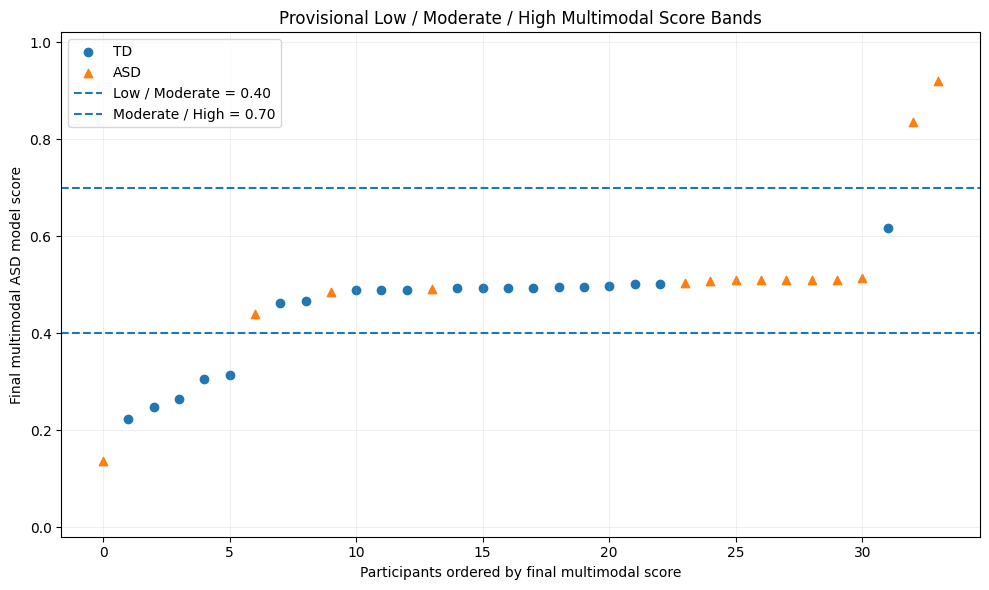

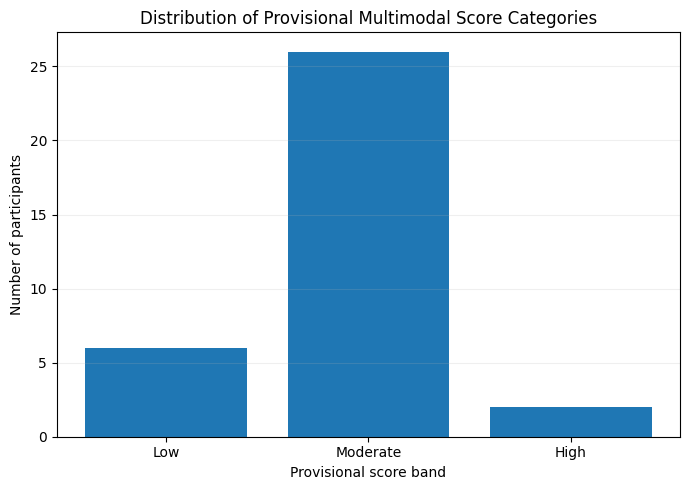


Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_provisional_risk_categories.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_risk_category_by_group.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_provisional_risk_bands.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/fusion_provisional_risk_band_counts.png

Provisional risk-score category analysis completed successfully.


In [ ]:
# ============================================================
# MODEL 10 — PROVISIONAL LOW / MODERATE / HIGH SCORE BANDS
# ============================================================

print("=" * 70)
print("MODEL 10 — PROVISIONAL ASD SCORE CATEGORIES")
print("=" * 70)


# ============================================================
# PROVISIONAL BAND DEFINITIONS
# ============================================================

LOW_MODERATE_CUTOFF = 0.40
MODERATE_HIGH_CUTOFF = 0.70


def assign_risk_band(score):

    if score < LOW_MODERATE_CUTOFF:
        return "Low"

    elif score < MODERATE_HIGH_CUTOFF:
        return "Moderate"

    else:
        return "High"


# ============================================================
# PARTICIPANT-LEVEL SCORE TABLE
# ============================================================

risk_band_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y,

    "Outer_Fold":
        fusion_outer_fold,

    "P_shape_ASD":
        fusion_base_shape_proba,

    "P_colour_ASD":
        fusion_base_colour_proba,

    "P_DAM_ASD":
        fusion_base_dam_proba,

    "P_questionnaire_ASD":
        fusion_base_questionnaire_proba,

    "Final_ASD_Model_Score":
        fusion_oof_proba,

    "Fixed_0.5_Prediction":
        fusion_oof_pred,

    "Training_Only_Youden_Prediction":
        fusion_youden_oof_pred,

    "Fold_Selected_Threshold":
        fusion_selected_threshold
})


risk_band_df[
    "Provisional_Risk_Band"
] = risk_band_df[
    "Final_ASD_Model_Score"
].apply(
    assign_risk_band
)


# ============================================================
# STRICT VALIDATION
# ============================================================

expected_categories = {
    "Low",
    "Moderate",
    "High"
}

observed_categories = set(
    risk_band_df[
        "Provisional_Risk_Band"
    ].unique()
)


if not observed_categories.issubset(
    expected_categories
):

    raise RuntimeError(
        "Unexpected provisional risk category detected."
    )


if not np.all(
    (
        risk_band_df[
            "Final_ASD_Model_Score"
        ] >= 0
    )
    &
    (
        risk_band_df[
            "Final_ASD_Model_Score"
        ] <= 1
    )
):

    raise RuntimeError(
        "Fusion model scores outside [0, 1]."
    )


# ============================================================
# CATEGORY COUNTS
# ============================================================

risk_category_order = [
    "Low",
    "Moderate",
    "High"
]


overall_band_counts = (
    risk_band_df[
        "Provisional_Risk_Band"
    ]
    .value_counts()
    .reindex(
        risk_category_order,
        fill_value=0
    )
)


print("\nOverall provisional score-band counts:")

display(
    overall_band_counts
    .rename("Participants")
    .to_frame()
)


# ============================================================
# CATEGORY BY TRUE GROUP
# ============================================================

band_group_table = pd.crosstab(

    risk_band_df[
        "Group"
    ],

    risk_band_df[
        "Provisional_Risk_Band"
    ]

).reindex(
    columns=risk_category_order,
    fill_value=0
)


print(
    "\nProvisional score bands by true participant group:"
)

display(
    band_group_table
)


# ============================================================
# ROW PERCENTAGES
# ============================================================

band_group_percent = (
    band_group_table
    .div(
        band_group_table.sum(
            axis=1
        ),
        axis=0
    )
    *
    100
)


print(
    "\nWithin-group percentages (%):"
)

display(
    band_group_percent
    .round(1)
)


# ============================================================
# SCORE SUMMARY BY TRUE GROUP
# ============================================================

score_summary_by_group = (
    risk_band_df
    .groupby(
        "Group"
    )[
        "Final_ASD_Model_Score"
    ]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)


print(
    "\nFinal fusion model-score summary by group:"
)

display(
    score_summary_by_group
    .round(4)
)


# ============================================================
# PARTICIPANTS IN MODERATE BAND
# ============================================================

moderate_participants_df = (
    risk_band_df[
        risk_band_df[
            "Provisional_Risk_Band"
        ] == "Moderate"
    ]
    [
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "Outer_Fold",
            "Final_ASD_Model_Score",
            "Fold_Selected_Threshold",
            "Training_Only_Youden_Prediction"
        ]
    ]
    .sort_values(
        "Final_ASD_Model_Score"
    )
)


print(
    "\nParticipants in the provisional Moderate band:"
)

display(
    moderate_participants_df
    .round(4)
)


# ============================================================
# PARTICIPANT SCORE VISUALIZATION
# ============================================================

sorted_risk_df = (
    risk_band_df
    .sort_values(
        "Final_ASD_Model_Score"
    )
    .reset_index(drop=True)
)


positions = np.arange(
    len(sorted_risk_df)
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


td_mask = (
    sorted_risk_df[
        "True_Label"
    ].to_numpy()
    ==
    0
)

asd_mask = (
    sorted_risk_df[
        "True_Label"
    ].to_numpy()
    ==
    1
)


ax.scatter(
    positions[td_mask],
    sorted_risk_df.loc[
        td_mask,
        "Final_ASD_Model_Score"
    ],
    marker="o",
    label="TD"
)


ax.scatter(
    positions[asd_mask],
    sorted_risk_df.loc[
        asd_mask,
        "Final_ASD_Model_Score"
    ],
    marker="^",
    label="ASD"
)


ax.axhline(
    LOW_MODERATE_CUTOFF,
    linestyle="--",
    linewidth=1.5,
    label="Low / Moderate = 0.40"
)


ax.axhline(
    MODERATE_HIGH_CUTOFF,
    linestyle="--",
    linewidth=1.5,
    label="Moderate / High = 0.70"
)


ax.set_ylim(
    -0.02,
    1.02
)


ax.set_xlabel(
    "Participants ordered by final multimodal score"
)


ax.set_ylabel(
    "Final multimodal ASD model score"
)


ax.set_title(
    "Provisional Low / Moderate / High "
    "Multimodal Score Bands"
)


ax.legend(
    loc="best"
)


ax.grid(
    alpha=0.20
)


fig.tight_layout()


risk_band_figure_file = os.path.join(
    RESULTS_DIR,
    "fusion_provisional_risk_bands.png"
)


fig.savefig(
    risk_band_figure_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# CATEGORY COUNT BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(
    overall_band_counts.index,
    overall_band_counts.values
)


ax.set_xlabel(
    "Provisional score band"
)


ax.set_ylabel(
    "Number of participants"
)


ax.set_title(
    "Distribution of Provisional Multimodal Score Categories"
)


ax.grid(
    axis="y",
    alpha=0.20
)


fig.tight_layout()


risk_band_count_figure_file = os.path.join(
    RESULTS_DIR,
    "fusion_provisional_risk_band_counts.png"
)


fig.savefig(
    risk_band_count_figure_file,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# SAVE TABLES
# ============================================================

risk_band_file = os.path.join(
    RESULTS_DIR,
    "fusion_provisional_risk_categories.csv"
)

risk_band_group_file = os.path.join(
    RESULTS_DIR,
    "fusion_risk_category_by_group.csv"
)


risk_band_df.to_csv(
    risk_band_file,
    index=False
)

band_group_table.to_csv(
    risk_band_group_file
)


print("\nSaved:")
print(risk_band_file)
print(risk_band_group_file)
print(risk_band_figure_file)
print(risk_band_count_figure_file)

print(
    "\nProvisional risk-score category analysis "
    "completed successfully."
)

# Model 11 — Questionnaire Explainability

## 31. Out-of-Fold SHAP Analysis for Questionnaire XGBoost

SHAP is used to explain the primary questionnaire XGBoost classifier.

To reduce optimistic explanation bias, SHAP values are generated using the
same outer cross-validation structure as the questionnaire evaluation.

For each outer fold:

1. the XGBoost model is reconstructed using the hyperparameters selected
   from the corresponding training fold;
2. the model is fitted only on the outer-training participants;
3. SHAP values are calculated only for the held-out outer-test participants;
4. the held-out SHAP values are stored in their original participant order.

Therefore, every participant-level SHAP explanation is produced by a model
that was not trained on that participant.

Global importance is summarized using mean absolute SHAP magnitude.

Until the questionnaire scoring key and reverse-scored items are confirmed,
SHAP direction is interpreted only as contribution toward the model's ASD or
TD prediction rather than as a clinical interpretation of questionnaire-item
direction.

MODEL 11 — QUESTIONNAIRE OUT-OF-FOLD SHAP
Fold 1: max probability difference = 0.0000000000
Fold 2: max probability difference = 0.0000000000
Fold 3: max probability difference = 0.0000000000
Fold 4: max probability difference = 0.0000000000
Fold 5: max probability difference = 0.0000000000

Maximum probability difference across all participants: 0.0000000000
Questionnaire model reconstruction: PASS

Global questionnaire SHAP importance:


,Item,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,item_23,0.65150,-0.04901
1,item_1,0.43677,-0.16344
2,item_25,0.27571,-0.03354
3,item_21,0.15297,-0.00087
4,item_11,0.10582,-0.00726
5,item_2,0.09098,0.02117
6,item_16,0.08442,-0.01521
7,item_12,0.06801,0.03429
8,item_6,0.04636,-0.00376
9,item_19,0.04471,-0.03050



Top 10 questionnaire items by mean absolute SHAP:


,Item,Mean_Absolute_SHAP,Mean_Signed_SHAP
0,item_23,0.65150,-0.04901
1,item_1,0.43677,-0.16344
2,item_25,0.27571,-0.03354
3,item_21,0.15297,-0.00087
4,item_11,0.10582,-0.00726
5,item_2,0.09098,0.02117
6,item_16,0.08442,-0.01521
7,item_12,0.06801,0.03429
8,item_6,0.04636,-0.00376
9,item_19,0.04471,-0.03050


/tmp/ipykernel_2235/260051407.py:427: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


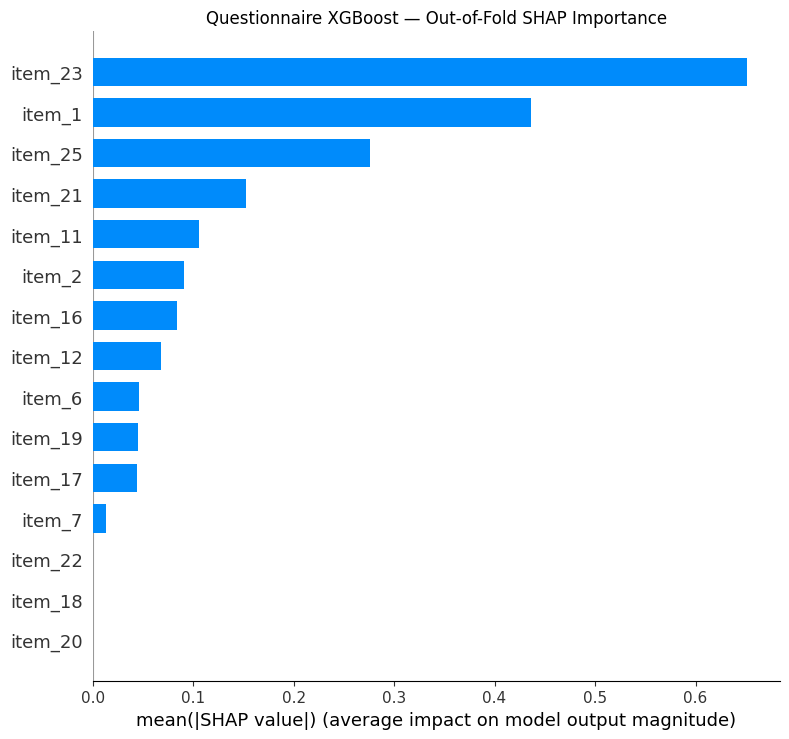

/tmp/ipykernel_2235/260051407.py:467: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


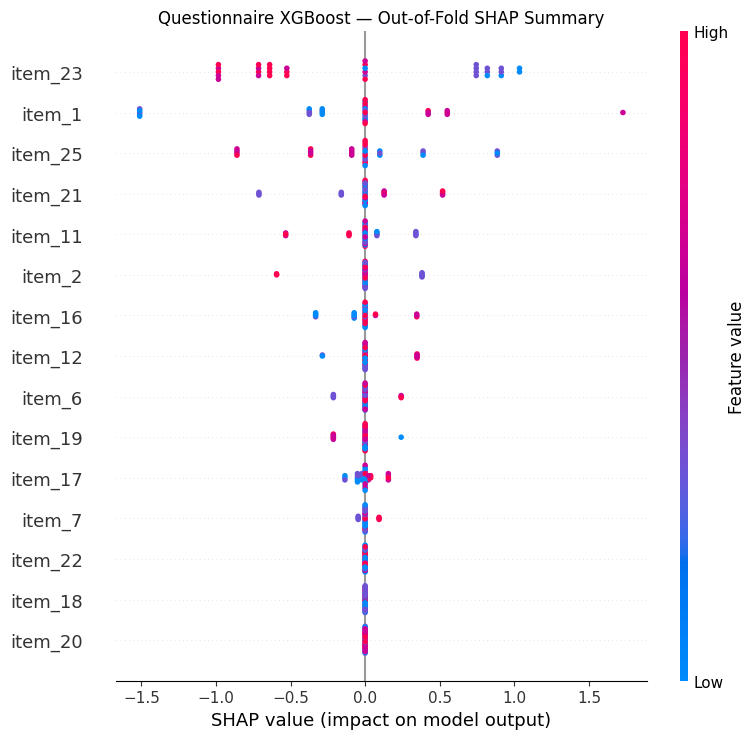


Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_oof_shap_global_importance.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_oof_shap_values.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_oof_shap_bar.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_oof_shap_beeswarm.png

Questionnaire out-of-fold SHAP analysis completed successfully.


In [ ]:
# ============================================================
# MODEL 11 — OUT-OF-FOLD QUESTIONNAIRE SHAP
# ============================================================

!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


print("=" * 70)
print("MODEL 11 — QUESTIONNAIRE OUT-OF-FOLD SHAP")
print("=" * 70)


# ============================================================
# STORAGE
# ============================================================

questionnaire_oof_shap = np.full(
    (
        len(y_questionnaire),
        len(ITEM_COLS)
    ),
    np.nan,
    dtype=np.float64
)

questionnaire_oof_shap_fold = np.full(
    len(y_questionnaire),
    -1,
    dtype=np.int64
)


# Used only to verify that reconstructed models reproduce
# the questionnaire OOF probabilities from Model 4.
reconstructed_questionnaire_proba = np.full(
    len(y_questionnaire),
    np.nan,
    dtype=np.float64
)


# ============================================================
# SAME OUTER SPLITS AS MODEL 4
# ============================================================

shap_outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


for fold_number, (
    train_idx,
    test_idx
) in enumerate(

    shap_outer_cv.split(
        X_questionnaire,
        y_questionnaire
    ),

    start=1
):

    # --------------------------------------------------------
    # Retrieve hyperparameters selected previously in Model 4
    # --------------------------------------------------------

    fold_row = (
        questionnaire_xgb_folds_df[
            questionnaire_xgb_folds_df[
                "Fold"
            ] == fold_number
        ]
        .iloc[0]
    )


    best_n_estimators = int(
        fold_row[
            "Best_n_estimators"
        ]
    )

    best_max_depth = int(
        fold_row[
            "Best_max_depth"
        ]
    )

    best_learning_rate = float(
        fold_row[
            "Best_learning_rate"
        ]
    )

    best_min_child_weight = int(
        fold_row[
            "Best_min_child_weight"
        ]
    )


    # ========================================================
    # RECONSTRUCT THE EXACT OUTER-FOLD XGBOOST MODEL
    # ========================================================

    fold_model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        random_state=SEED,

        n_jobs=1,

        tree_method="hist",

        n_estimators=
            best_n_estimators,

        max_depth=
            best_max_depth,

        learning_rate=
            best_learning_rate,

        min_child_weight=
            best_min_child_weight
    )


    fold_model.fit(
        X_questionnaire[
            train_idx
        ],
        y_questionnaire[
            train_idx
        ]
    )


    # ========================================================
    # VERIFY RECONSTRUCTED PROBABILITIES
    # ========================================================

    fold_proba = (
        fold_model
        .predict_proba(
            X_questionnaire[
                test_idx
            ]
        )[:, 1]
    )


    reconstructed_questionnaire_proba[
        test_idx
    ] = fold_proba


    original_fold_proba = (
        questionnaire_xgb_oof_proba[
            test_idx
        ]
    )


    fold_probability_difference = float(
        np.max(
            np.abs(
                fold_proba
                -
                original_fold_proba
            )
        )
    )


    print(
        f"Fold {fold_number}: "
        f"max probability difference = "
        f"{fold_probability_difference:.10f}"
    )


    # ========================================================
    # SHAP EXPLANATION — HELD-OUT PARTICIPANTS ONLY
    # ========================================================

    explainer = shap.TreeExplainer(
        fold_model
    )


    fold_shap_values = (
        explainer.shap_values(
            X_questionnaire[
                test_idx
            ]
        )
    )


    # --------------------------------------------------------
    # Handle SHAP version differences
    # --------------------------------------------------------

    if isinstance(
        fold_shap_values,
        list
    ):

        # Binary classifier:
        # use positive / ASD class explanation
        fold_shap_values = (
            fold_shap_values[-1]
        )


    fold_shap_values = np.asarray(
        fold_shap_values,
        dtype=np.float64
    )


    # Some SHAP versions can return:
    # (samples, features, classes)

    if fold_shap_values.ndim == 3:

        if fold_shap_values.shape[-1] == 2:

            fold_shap_values = (
                fold_shap_values[
                    :,
                    :,
                    1
                ]
            )

        else:

            raise RuntimeError(
                "Unexpected 3D SHAP output shape: "
                f"{fold_shap_values.shape}"
            )


    expected_fold_shape = (
        len(test_idx),
        len(ITEM_COLS)
    )


    if fold_shap_values.shape != expected_fold_shape:

        raise RuntimeError(
            f"Unexpected SHAP shape in fold "
            f"{fold_number}: "
            f"{fold_shap_values.shape}; "
            f"expected {expected_fold_shape}"
        )


    questionnaire_oof_shap[
        test_idx,
        :
    ] = fold_shap_values


    questionnaire_oof_shap_fold[
        test_idx
    ] = fold_number


# ============================================================
# STRICT VALIDATION
# ============================================================

if np.isnan(
    questionnaire_oof_shap
).any():

    raise RuntimeError(
        "Some questionnaire participants "
        "are missing OOF SHAP values."
    )


if not np.isfinite(
    questionnaire_oof_shap
).all():

    raise RuntimeError(
        "Questionnaire SHAP matrix contains "
        "invalid values."
    )


if (
    questionnaire_oof_shap_fold < 1
).any():

    raise RuntimeError(
        "Some participants are missing "
        "their SHAP outer-fold assignment."
    )


# ============================================================
# VERIFY MODEL RECONSTRUCTION
# ============================================================

maximum_probability_difference = float(

    np.max(
        np.abs(
            reconstructed_questionnaire_proba
            -
            questionnaire_xgb_oof_proba
        )
    )
)


print(
    "\nMaximum probability difference "
    "across all participants:",
    f"{maximum_probability_difference:.10f}"
)


if maximum_probability_difference <= 1e-7:

    print(
        "Questionnaire model reconstruction: PASS"
    )

else:

    print(
        "Questionnaire model reconstruction: "
        "CHECK REQUIRED"
    )


# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

mean_abs_shap = np.mean(
    np.abs(
        questionnaire_oof_shap
    ),
    axis=0
)


mean_signed_shap = np.mean(
    questionnaire_oof_shap,
    axis=0
)


questionnaire_shap_importance_df = pd.DataFrame({

    "Item":
        ITEM_COLS,

    "Mean_Absolute_SHAP":
        mean_abs_shap,

    "Mean_Signed_SHAP":
        mean_signed_shap
})


questionnaire_shap_importance_df = (
    questionnaire_shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nGlobal questionnaire SHAP importance:"
)

display(
    questionnaire_shap_importance_df
    .round(5)
)


print(
    "\nTop 10 questionnaire items "
    "by mean absolute SHAP:"
)

display(
    questionnaire_shap_importance_df
    .head(10)
    .round(5)
)


# ============================================================
# SHAP BAR PLOT
# ============================================================

plt.figure(
    figsize=(9, 7)
)

shap.summary_plot(
    questionnaire_oof_shap,
    X_questionnaire,
    feature_names=ITEM_COLS,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    "Questionnaire XGBoost — "
    "Out-of-Fold SHAP Importance"
)

plt.tight_layout()


questionnaire_shap_bar_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_oof_shap_bar.png"
)


plt.savefig(
    questionnaire_shap_bar_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SHAP BEESWARM PLOT
# ============================================================

plt.figure(
    figsize=(10, 8)
)

shap.summary_plot(
    questionnaire_oof_shap,
    X_questionnaire,
    feature_names=ITEM_COLS,
    max_display=15,
    show=False
)

plt.title(
    "Questionnaire XGBoost — "
    "Out-of-Fold SHAP Summary"
)

plt.tight_layout()


questionnaire_shap_beeswarm_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_oof_shap_beeswarm.png"
)


plt.savefig(
    questionnaire_shap_beeswarm_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PARTICIPANT-LEVEL SHAP TABLE
# ============================================================

questionnaire_shap_wide_df = pd.DataFrame(
    questionnaire_oof_shap,
    columns=[
        f"SHAP_{item}"
        for item in ITEM_COLS
    ]
)


questionnaire_shap_wide_df.insert(
    0,
    "Participant_ID",
    participant_ids_safe
)

questionnaire_shap_wide_df.insert(
    1,
    "Group",
    groups_safe
)

questionnaire_shap_wide_df.insert(
    2,
    "True_Label",
    y_questionnaire
)

questionnaire_shap_wide_df.insert(
    3,
    "Outer_Fold",
    questionnaire_oof_shap_fold
)

questionnaire_shap_wide_df.insert(
    4,
    "P_questionnaire_ASD",
    questionnaire_xgb_oof_proba
)


# ============================================================
# SAVE
# ============================================================

questionnaire_shap_importance_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_oof_shap_global_importance.csv"
)

questionnaire_shap_values_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_oof_shap_values.csv"
)


questionnaire_shap_importance_df.to_csv(
    questionnaire_shap_importance_file,
    index=False
)

questionnaire_shap_wide_df.to_csv(
    questionnaire_shap_values_file,
    index=False
)


print("\nSaved:")
print(questionnaire_shap_importance_file)
print(questionnaire_shap_values_file)
print(questionnaire_shap_bar_file)
print(questionnaire_shap_beeswarm_file)

print(
    "\nQuestionnaire out-of-fold SHAP "
    "analysis completed successfully."
)

## 32. Participant-Level Questionnaire Explanations

Participant-level explanations are derived from the out-of-fold SHAP values
generated in the previous analysis.

For each participant:

- positive SHAP values indicate questionnaire items that push the XGBoost
  prediction toward ASD;
- negative SHAP values indicate questionnaire items that push the prediction
  toward TD;
- absolute SHAP magnitude indicates the strength of the contribution.

The five strongest questionnaire-item contributions are stored for every
participant.

Representative explanations are visualized for:

1. a correctly classified ASD participant with a high predicted ASD score;
2. a correctly classified TD participant with a low predicted ASD score;
3. an XGBoost false-negative participant;
4. the XGBoost false-positive participant, if present.

Because the questionnaire scoring direction has not yet been clinically
interpreted item-by-item, these plots explain model behaviour rather than
clinical meaning.

MODEL 11B — PARTICIPANT-LEVEL QUESTIONNAIRE EXPLANATIONS

Top 5 questionnaire contributions for each participant:


,Participant_ID,Group,True_Label,P_questionnaire_ASD,Predicted_Label_0.5,Item,Response,SHAP_Value,Absolute_SHAP,Direction
0,P006,TD,0,0.4925,0,item_25,2.0,0.8857,0.8857,Toward ASD
1,P006,TD,0,0.4925,0,item_23,4.0,-0.5249,0.5249,Toward TD
2,P006,TD,0,0.4925,0,item_1,2.0,0.0000,0.0000,No contribution
3,P006,TD,0,0.4925,0,item_2,1.0,0.0000,0.0000,No contribution
4,P006,TD,0,0.4925,0,item_3,3.0,0.0000,0.0000,No contribution
5,P007,TD,0,0.8066,1,item_1,3.0,1.7279,1.7279,Toward ASD
6,P007,TD,0,0.8066,1,item_2,3.0,0.0000,0.0000,No contribution
7,P007,TD,0,0.8066,1,item_3,2.0,0.0000,0.0000,No contribution
8,P007,TD,0,0.8066,1,item_4,4.0,0.0000,0.0000,No contribution
9,P007,TD,0,0.8066,1,item_5,4.0,0.0000,0.0000,No contribution



Representative participants:
High-confidence correct ASD : P037 | true=1 | pred=1 | P_ASD=0.9468
High-confidence correct TD  : P020 | true=0 | pred=0 | P_ASD=0.0252
False negative              : P026 | true=1 | pred=0 | P_ASD=0.1405
False positive              : P007 | true=0 | pred=1 | P_ASD=0.8066


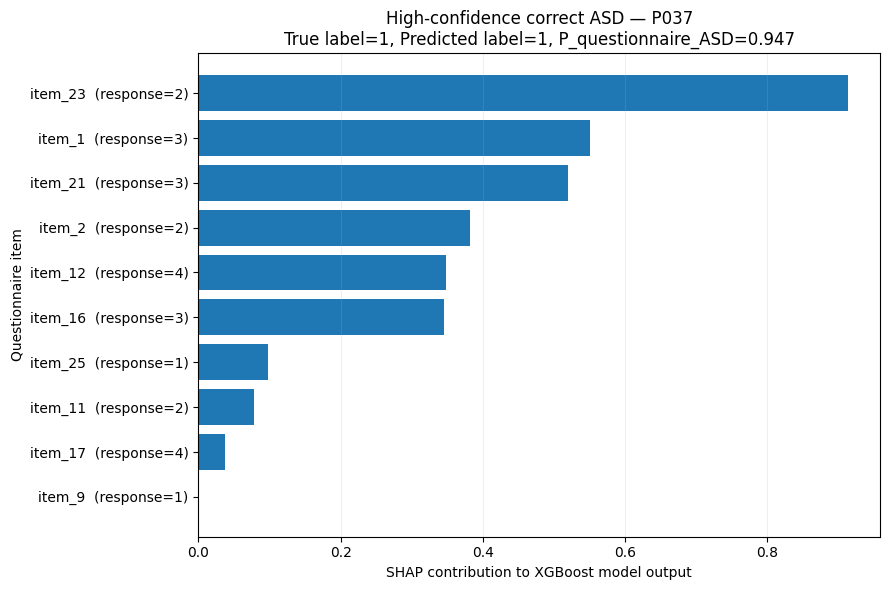

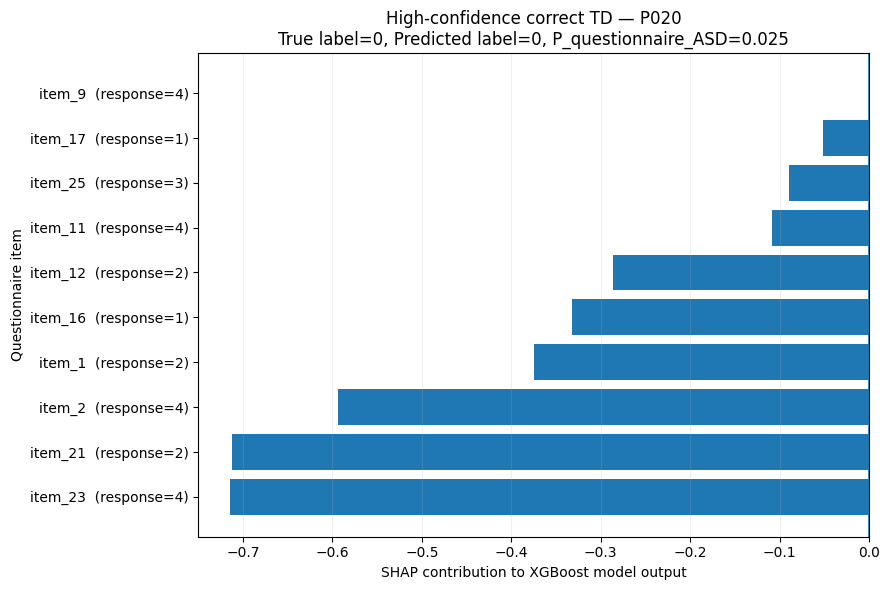

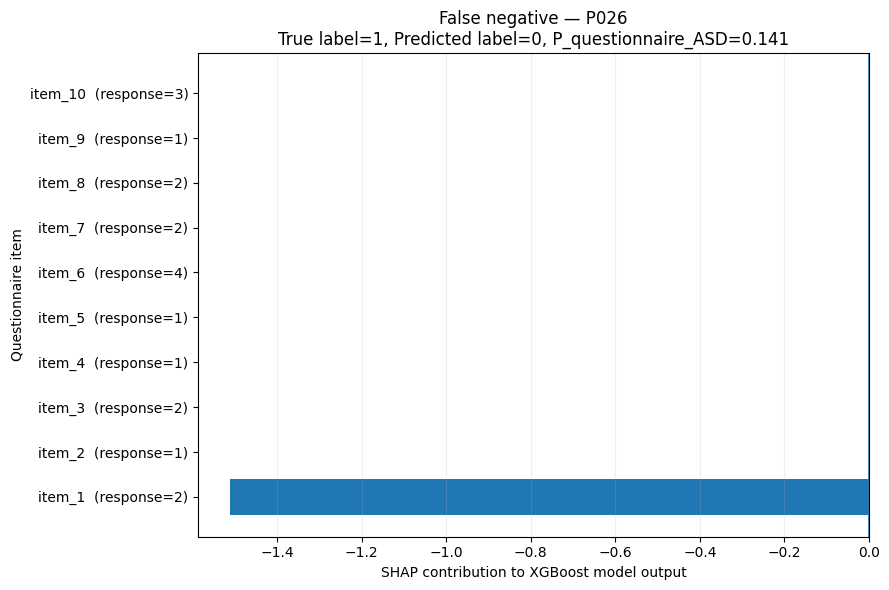

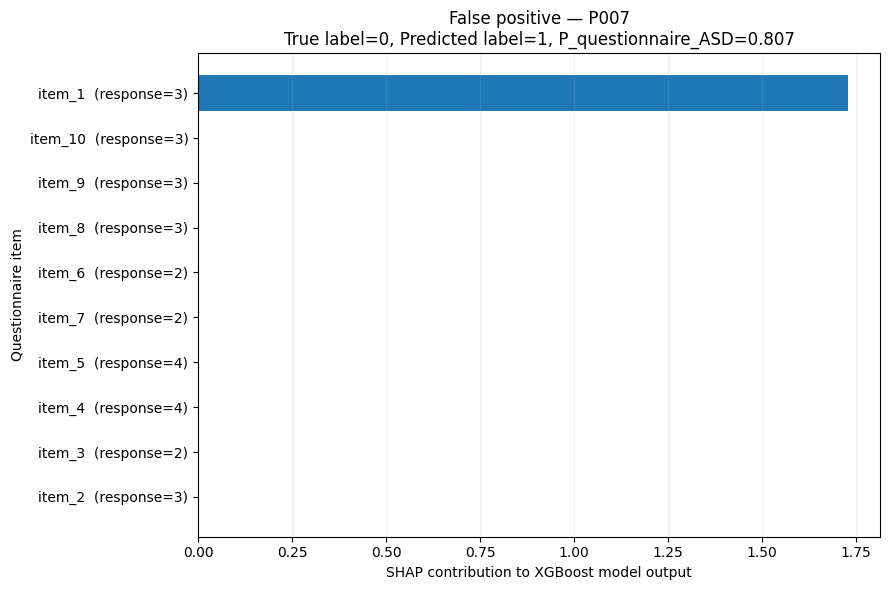


Top SHAP contributions for representative participants:


,Participant_ID,Group,True_Label,P_questionnaire_ASD,Item,Response,SHAP_Value,Direction
5,P007,TD,0,0.8066,item_1,3.0,1.7279,Toward ASD
6,P007,TD,0,0.8066,item_2,3.0,0.0000,No contribution
7,P007,TD,0,0.8066,item_3,2.0,0.0000,No contribution
8,P007,TD,0,0.8066,item_4,4.0,0.0000,No contribution
9,P007,TD,0,0.8066,item_5,4.0,0.0000,No contribution
70,P020,TD,0,0.0252,item_23,4.0,-0.7142,Toward TD
71,P020,TD,0,0.0252,item_21,2.0,-0.7120,Toward TD
72,P020,TD,0,0.0252,item_2,4.0,-0.5934,Toward TD
73,P020,TD,0,0.0252,item_1,2.0,-0.3744,Toward TD
74,P020,TD,0,0.0252,item_16,1.0,-0.3318,Toward TD



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_participant_shap_long.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_participant_top5_shap.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_representative_shap_cases.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_shap_high_confidence_correct_asd_P037.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_shap_high_confidence_correct_td_P020.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_shap_false_negative_P026.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/questionnaire_shap_false_positive_P007.png

Participant-level questionnaire explainability completed successfully.


In [ ]:
# ============================================================
# MODEL 11B — PARTICIPANT-LEVEL QUESTIONNAIRE SHAP
# ============================================================

print("=" * 70)
print("MODEL 11B — PARTICIPANT-LEVEL QUESTIONNAIRE EXPLANATIONS")
print("=" * 70)


# ============================================================
# LONG-FORM SHAP TABLE
# ============================================================

participant_shap_records = []


for participant_index in range(
    len(y_questionnaire)
):

    participant_id = participant_ids_safe[
        participant_index
    ]

    group = groups_safe[
        participant_index
    ]

    true_label = int(
        y_questionnaire[
            participant_index
        ]
    )

    probability = float(
        questionnaire_xgb_oof_proba[
            participant_index
        ]
    )

    prediction = int(
        questionnaire_xgb_oof_pred[
            participant_index
        ]
    )


    for item_index, item_name in enumerate(
        ITEM_COLS
    ):

        shap_value = float(
            questionnaire_oof_shap[
                participant_index,
                item_index
            ]
        )

        response_value = float(
            X_questionnaire[
                participant_index,
                item_index
            ]
        )


        if shap_value > 0:

            direction = "Toward ASD"

        elif shap_value < 0:

            direction = "Toward TD"

        else:

            direction = "No contribution"


        participant_shap_records.append({

            "Participant_ID":
                participant_id,

            "Group":
                group,

            "True_Label":
                true_label,

            "P_questionnaire_ASD":
                probability,

            "Predicted_Label_0.5":
                prediction,

            "Item":
                item_name,

            "Response":
                response_value,

            "SHAP_Value":
                shap_value,

            "Absolute_SHAP":
                abs(
                    shap_value
                ),

            "Direction":
                direction
        })


participant_shap_long_df = pd.DataFrame(
    participant_shap_records
)


# ============================================================
# TOP 5 CONTRIBUTIONS PER PARTICIPANT
# ============================================================

participant_top5_shap_df = (

    participant_shap_long_df

    .sort_values(
        [
            "Participant_ID",
            "Absolute_SHAP"
        ],
        ascending=[
            True,
            False
        ]
    )

    .groupby(
        "Participant_ID",
        as_index=False
    )

    .head(5)

    .reset_index(drop=True)
)


print(
    "\nTop 5 questionnaire contributions "
    "for each participant:"
)

display(
    participant_top5_shap_df
    .head(20)
    .round({
        "P_questionnaire_ASD": 4,
        "Response": 2,
        "SHAP_Value": 4,
        "Absolute_SHAP": 4
    })
)


# ============================================================
# SELECT REPRESENTATIVE PARTICIPANTS OBJECTIVELY
# ============================================================

questionnaire_case_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_questionnaire,

    "Probability":
        questionnaire_xgb_oof_proba,

    "Prediction":
        questionnaire_xgb_oof_pred
})


# ------------------------------------------------------------
# 1. Correctly classified ASD with highest probability
# ------------------------------------------------------------

correct_asd_df = questionnaire_case_df[
    (
        questionnaire_case_df[
            "True_Label"
        ] == 1
    )
    &
    (
        questionnaire_case_df[
            "Prediction"
        ] == 1
    )
]


representative_cases = []


if len(correct_asd_df) > 0:

    row = correct_asd_df.loc[
        correct_asd_df[
            "Probability"
        ].idxmax()
    ]

    representative_cases.append(
        (
            "High-confidence correct ASD",
            row[
                "Participant_ID"
            ]
        )
    )


# ------------------------------------------------------------
# 2. Correctly classified TD with lowest probability
# ------------------------------------------------------------

correct_td_df = questionnaire_case_df[
    (
        questionnaire_case_df[
            "True_Label"
        ] == 0
    )
    &
    (
        questionnaire_case_df[
            "Prediction"
        ] == 0
    )
]


if len(correct_td_df) > 0:

    row = correct_td_df.loc[
        correct_td_df[
            "Probability"
        ].idxmin()
    ]

    representative_cases.append(
        (
            "High-confidence correct TD",
            row[
                "Participant_ID"
            ]
        )
    )


# ------------------------------------------------------------
# 3. False negative
#
# Select the false negative with the LOWEST ASD probability,
# representing the strongest false-negative error.
# ------------------------------------------------------------

false_negative_df = questionnaire_case_df[
    (
        questionnaire_case_df[
            "True_Label"
        ] == 1
    )
    &
    (
        questionnaire_case_df[
            "Prediction"
        ] == 0
    )
]


if len(false_negative_df) > 0:

    row = false_negative_df.loc[
        false_negative_df[
            "Probability"
        ].idxmin()
    ]

    representative_cases.append(
        (
            "False negative",
            row[
                "Participant_ID"
            ]
        )
    )


# ------------------------------------------------------------
# 4. False positive
#
# Select the false positive with highest ASD probability.
# ------------------------------------------------------------

false_positive_df = questionnaire_case_df[
    (
        questionnaire_case_df[
            "True_Label"
        ] == 0
    )
    &
    (
        questionnaire_case_df[
            "Prediction"
        ] == 1
    )
]


if len(false_positive_df) > 0:

    row = false_positive_df.loc[
        false_positive_df[
            "Probability"
        ].idxmax()
    ]

    representative_cases.append(
        (
            "False positive",
            row[
                "Participant_ID"
            ]
        )
    )


print(
    "\nRepresentative participants:"
)

for case_name, participant_id in representative_cases:

    participant_row = questionnaire_case_df[
        questionnaire_case_df[
            "Participant_ID"
        ] == participant_id
    ].iloc[0]

    print(
        f"{case_name:28s}: "
        f"{participant_id} | "
        f"true={participant_row['True_Label']} | "
        f"pred={participant_row['Prediction']} | "
        f"P_ASD={participant_row['Probability']:.4f}"
    )


# ============================================================
# HELPER — PARTICIPANT SHAP PLOT
# ============================================================

def plot_participant_questionnaire_shap(
    participant_id,
    case_name,
    top_n=10
):

    participant_mask = (
        participant_ids_safe
        ==
        participant_id
    )

    participant_indices = np.where(
        participant_mask
    )[0]


    if len(participant_indices) != 1:

        raise RuntimeError(
            f"Could not uniquely locate "
            f"participant {participant_id}."
        )


    participant_index = int(
        participant_indices[0]
    )


    shap_values = questionnaire_oof_shap[
        participant_index
    ]

    response_values = X_questionnaire[
        participant_index
    ]


    plot_df = pd.DataFrame({

        "Item":
            ITEM_COLS,

        "Response":
            response_values,

        "SHAP_Value":
            shap_values,

        "Absolute_SHAP":
            np.abs(
                shap_values
            )
    })


    plot_df = (
        plot_df
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .head(top_n)
        .sort_values(
            "SHAP_Value"
        )
    )


    participant_probability = float(
        questionnaire_xgb_oof_proba[
            participant_index
        ]
    )

    participant_true = int(
        y_questionnaire[
            participant_index
        ]
    )

    participant_pred = int(
        questionnaire_xgb_oof_pred[
            participant_index
        ]
    )


    # Add response values directly into labels
    plot_labels = [

        f"{item}  (response={response:g})"

        for item, response in zip(
            plot_df[
                "Item"
            ],
            plot_df[
                "Response"
            ]
        )
    ]


    fig, ax = plt.subplots(
        figsize=(9, 6)
    )


    ax.barh(
        plot_labels,
        plot_df[
            "SHAP_Value"
        ]
    )


    ax.axvline(
        0,
        linewidth=1.2
    )


    ax.set_xlabel(
        "SHAP contribution to XGBoost model output"
    )


    ax.set_ylabel(
        "Questionnaire item"
    )


    ax.set_title(
        f"{case_name} — {participant_id}\n"
        f"True label={participant_true}, "
        f"Predicted label={participant_pred}, "
        f"P_questionnaire_ASD="
        f"{participant_probability:.3f}"
    )


    ax.grid(
        axis="x",
        alpha=0.20
    )


    fig.tight_layout()


    safe_case_name = (
        case_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    output_file = os.path.join(
        RESULTS_DIR,
        (
            f"questionnaire_shap_"
            f"{safe_case_name}_"
            f"{participant_id}.png"
        )
    )


    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    return output_file


# ============================================================
# GENERATE REPRESENTATIVE EXPLANATION PLOTS
# ============================================================

participant_shap_plot_files = []


for case_name, participant_id in representative_cases:

    plot_file = plot_participant_questionnaire_shap(

        participant_id=
            participant_id,

        case_name=
            case_name,

        top_n=10
    )


    participant_shap_plot_files.append(
        plot_file
    )


# ============================================================
# PRINT TOP FEATURES FOR REPRESENTATIVE CASES
# ============================================================

print(
    "\nTop SHAP contributions "
    "for representative participants:"
)


representative_ids = [
    participant_id
    for _, participant_id
    in representative_cases
]


representative_top_shap_df = (

    participant_top5_shap_df[
        participant_top5_shap_df[
            "Participant_ID"
        ].isin(
            representative_ids
        )
    ]

    .copy()
)


display(
    representative_top_shap_df[
        [
            "Participant_ID",
            "Group",
            "True_Label",
            "P_questionnaire_ASD",
            "Item",
            "Response",
            "SHAP_Value",
            "Direction"
        ]
    ]
    .round({
        "P_questionnaire_ASD": 4,
        "Response": 2,
        "SHAP_Value": 4
    })
)


# ============================================================
# SAVE
# ============================================================

participant_shap_long_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_participant_shap_long.csv"
)

participant_top5_shap_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_participant_top5_shap.csv"
)

representative_shap_file = os.path.join(
    RESULTS_DIR,
    "questionnaire_representative_shap_cases.csv"
)


participant_shap_long_df.to_csv(
    participant_shap_long_file,
    index=False
)

participant_top5_shap_df.to_csv(
    participant_top5_shap_file,
    index=False
)

representative_top_shap_df.to_csv(
    representative_shap_file,
    index=False
)


print("\nSaved:")
print(participant_shap_long_file)
print(participant_top5_shap_file)
print(representative_shap_file)

for file_path in participant_shap_plot_files:
    print(file_path)


print(
    "\nParticipant-level questionnaire "
    "explainability completed successfully."
)

# Model 12 — Draw-a-Man Visual Attention

## 33. DINOv2 Attention Rollout

DINOv2 attention rollout is used to visualize image regions emphasized by the
frozen Draw-a-Man feature extractor.

Representative participants are selected objectively from the Draw-a-Man
out-of-fold predictions:

- highest-confidence correctly classified ASD participant;
- highest-confidence correctly classified TD participant;
- strongest false-negative case;
- strongest false-positive case.

Attention is propagated through the transformer layers using residual-adjusted
attention rollout.

The resulting heatmaps describe spatial attention of the frozen DINOv2
representation.

They are **not interpreted as causal explanations of the final ASD
classification**, because the participant-level ASD score is generated by a
separate Logistic Regression classifier operating on the DINOv2 embedding.

In [ ]:
# ============================================================
# CELL 33A — RESTORE DINOv2 MODEL FOR ATTENTION VISUALIZATION
# ============================================================

from transformers import AutoModel
import torch

print("=" * 70)
print("RESTORING DINOv2 MODEL FOR ATTENTION ROLLOUT")
print("=" * 70)


# Use the same pretrained backbone used for DAM embeddings.
# Eager attention is requested so attention matrices are available.

dino_model = AutoModel.from_pretrained(
    "facebook/dinov2-small",
    attn_implementation="eager"
).to(
    DEVICE
)


# Freeze model
dino_model.eval()

for parameter in dino_model.parameters():
    parameter.requires_grad = False


# ============================================================
# VALIDATION
# ============================================================

print(
    "Model:",
    dino_model.config._name_or_path
)

print(
    "Hidden size:",
    dino_model.config.hidden_size
)

print(
    "Device:",
    next(
        dino_model.parameters()
    ).device
)

print(
    "Training mode:",
    dino_model.training
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in dino_model.parameters()
        if p.requires_grad
    )
)


if dino_model.config.hidden_size != 384:

    raise RuntimeError(
        "Unexpected DINOv2 hidden size."
    )


if dino_model.training:

    raise RuntimeError(
        "DINOv2 should be in evaluation mode."
    )


print(
    "\nDINOv2 attention model restored successfully."
)

RESTORING DINOv2 MODEL FOR ATTENTION ROLLOUT


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Model: facebook/dinov2-small
Hidden size: 384
Device: cuda:0
Training mode: False
Trainable parameters: 0

DINOv2 attention model restored successfully.


In [ ]:
# ============================================================
# MODEL 12 — DINOv2 ATTENTION ROLLOUT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import os


print("=" * 70)
print("MODEL 12 — DRAW-A-MAN DINOv2 ATTENTION ROLLOUT")
print("=" * 70)


# ============================================================
# IDENTIFY DRAW-A-MAN PATH COLUMN ROBUSTLY
# ============================================================

dam_candidate_columns = [
    "draw_a_man",
    "draw_man",
    "dam",
    "DAM",
    "Draw_a_Man",
    "Draw-a-Man"
]

DAM_PATH_COLUMN = None


for candidate in dam_candidate_columns:

    if candidate in primary_df.columns:

        DAM_PATH_COLUMN = candidate
        break


# Fallback: search column names
if DAM_PATH_COLUMN is None:

    for col in primary_df.columns:

        normalized = (
            col.lower()
            .replace("-", "_")
            .replace(" ", "_")
        )

        if (
            ("draw" in normalized and "man" in normalized)
            or normalized == "dam"
        ):

            DAM_PATH_COLUMN = col
            break


if DAM_PATH_COLUMN is None:

    raise RuntimeError(
        "Could not identify Draw-a-Man image-path column."
    )


print(
    "Draw-a-Man image column:",
    DAM_PATH_COLUMN
)


# ============================================================
# REPRESENTATIVE DAM CASES
# ============================================================

dam_case_df = pd.DataFrame({

    "Participant_ID":
        participant_ids_safe,

    "Group":
        groups_safe,

    "True_Label":
        y_dam,

    "Probability":
        dam_oof_proba,

    "Prediction":
        dam_oof_pred
})


representative_dam_cases = []


# ------------------------------------------------------------
# Correct ASD — highest ASD probability
# ------------------------------------------------------------

correct_asd = dam_case_df[
    (
        dam_case_df["True_Label"] == 1
    )
    &
    (
        dam_case_df["Prediction"] == 1
    )
]

if len(correct_asd) > 0:

    row = correct_asd.loc[
        correct_asd["Probability"].idxmax()
    ]

    representative_dam_cases.append(
        (
            "High-confidence correct ASD",
            row["Participant_ID"]
        )
    )


# ------------------------------------------------------------
# Correct TD — lowest ASD probability
# ------------------------------------------------------------

correct_td = dam_case_df[
    (
        dam_case_df["True_Label"] == 0
    )
    &
    (
        dam_case_df["Prediction"] == 0
    )
]

if len(correct_td) > 0:

    row = correct_td.loc[
        correct_td["Probability"].idxmin()
    ]

    representative_dam_cases.append(
        (
            "High-confidence correct TD",
            row["Participant_ID"]
        )
    )


# ------------------------------------------------------------
# False negative — lowest ASD probability
# ------------------------------------------------------------

false_negative = dam_case_df[
    (
        dam_case_df["True_Label"] == 1
    )
    &
    (
        dam_case_df["Prediction"] == 0
    )
]

if len(false_negative) > 0:

    row = false_negative.loc[
        false_negative["Probability"].idxmin()
    ]

    representative_dam_cases.append(
        (
            "False negative",
            row["Participant_ID"]
        )
    )


# ------------------------------------------------------------
# False positive — highest ASD probability
# ------------------------------------------------------------

false_positive = dam_case_df[
    (
        dam_case_df["True_Label"] == 0
    )
    &
    (
        dam_case_df["Prediction"] == 1
    )
]

if len(false_positive) > 0:

    row = false_positive.loc[
        false_positive["Probability"].idxmax()
    ]

    representative_dam_cases.append(
        (
            "False positive",
            row["Participant_ID"]
        )
    )


print("\nRepresentative DAM participants:")

for case_name, participant_id in representative_dam_cases:

    row = dam_case_df[
        dam_case_df["Participant_ID"]
        ==
        participant_id
    ].iloc[0]

    print(
        f"{case_name:28s}: "
        f"{participant_id} | "
        f"true={row['True_Label']} | "
        f"pred={row['Prediction']} | "
        f"P_ASD={row['Probability']:.4f}"
    )


# ============================================================
# GET ATTENTION OUTPUTS
# ============================================================

def get_dino_attentions(pixel_values):

    global dino_model

    with torch.no_grad():

        outputs = dino_model(
            pixel_values=pixel_values,
            output_attentions=True,
            return_dict=True
        )


    attentions = outputs.attentions


    # Some transformer attention implementations may not
    # return attentions. If that occurs, reload using eager
    # attention from the already cached pretrained model.

    if attentions is None:

        print(
            "Attention tensors unavailable from current model; "
            "reloading DINOv2 with eager attention."
        )

        from transformers import AutoModel

        dino_model = AutoModel.from_pretrained(
            "facebook/dinov2-small",
            attn_implementation="eager"
        ).to(
            DEVICE
        )

        dino_model.eval()

        for param in dino_model.parameters():
            param.requires_grad = False


        with torch.no_grad():

            outputs = dino_model(
                pixel_values=pixel_values,
                output_attentions=True,
                return_dict=True
            )


        attentions = outputs.attentions


    if attentions is None:

        raise RuntimeError(
            "DINOv2 attentions could not be obtained."
        )


    return attentions


# ============================================================
# ATTENTION ROLLOUT FUNCTION
# ============================================================

def compute_dino_attention_rollout(
    image_path
):

    # --------------------------------------------------------
    # Same locked spatial preprocessing used earlier
    # --------------------------------------------------------

    image = load_rgb_image(
        image_path
    )

    processed_image = resize_pad_white(
        image,
        target_size=224
    )


    # Tensor normalization already defined earlier
    tensor = dino_tensor_transform(
        processed_image
    ).unsqueeze(0).to(
        DEVICE
    )


    # --------------------------------------------------------
    # Transformer attentions
    # --------------------------------------------------------

    attentions = get_dino_attentions(
        tensor
    )


    rollout = None


    for layer_attention in attentions:

        # Shape:
        # [batch, heads, tokens, tokens]

        attention = (
            layer_attention[
                0
            ]
            .mean(
                dim=0
            )
        )


        num_tokens = (
            attention.shape[
                -1
            ]
        )


        # Residual connection
        identity = torch.eye(
            num_tokens,
            device=attention.device
        )


        attention = (
            attention
            +
            identity
        )


        # Row normalization
        attention = (
            attention
            /
            attention.sum(
                dim=-1,
                keepdim=True
            )
        )


        if rollout is None:

            rollout = attention

        else:

            rollout = (
                attention
                @
                rollout
            )


    # ========================================================
    # CLS TOKEN ATTENTION TO PATCH TOKENS
    # ========================================================

    cls_attention = rollout[
        0,
        1:
    ]


    number_of_patches = (
        cls_attention.numel()
    )


    grid_size = int(
        np.sqrt(
            number_of_patches
        )
    )


    if (
        grid_size
        *
        grid_size
        !=
        number_of_patches
    ):

        raise RuntimeError(
            "Unexpected DINOv2 patch-token count: "
            f"{number_of_patches}"
        )


    attention_map = (
        cls_attention
        .reshape(
            1,
            1,
            grid_size,
            grid_size
        )
    )


    # Upsample to image resolution
    attention_map = F.interpolate(
        attention_map,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )


    attention_map = (
        attention_map[
            0,
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )


    # Normalize to 0..1
    attention_map = (
        attention_map
        -
        attention_map.min()
    )


    maximum = attention_map.max()


    if maximum > 0:

        attention_map = (
            attention_map
            /
            maximum
        )


    processed_array = np.asarray(
        processed_image
    )


    return (
        processed_array,
        attention_map
    )


# ============================================================
# GENERATE REPRESENTATIVE ATTENTION MAPS
# ============================================================

dam_attention_files = []

dam_attention_records = []


for case_name, participant_id in representative_dam_cases:

    participant_row = primary_df[
        primary_df[
            "Participant_ID"
        ]
        ==
        participant_id
    ].iloc[0]


    image_path = participant_row[
        DAM_PATH_COLUMN
    ]


    processed_image, attention_map = (
        compute_dino_attention_rollout(
            image_path
        )
    )


    dam_row = dam_case_df[
        dam_case_df[
            "Participant_ID"
        ]
        ==
        participant_id
    ].iloc[0]


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    ax.imshow(
        processed_image
    )


    ax.imshow(
        attention_map,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )


    ax.axis(
        "off"
    )


    ax.set_title(
        f"{case_name} — {participant_id}\n"
        f"True={int(dam_row['True_Label'])}, "
        f"Pred={int(dam_row['Prediction'])}, "
        f"P_DAM_ASD={dam_row['Probability']:.3f}\n"
        f"DINOv2 attention rollout "
        f"(feature-attention visualization)"
    )


    fig.tight_layout()


    safe_case_name = (
        case_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    output_file = os.path.join(
        RESULTS_DIR,
        (
            f"dam_dinov2_attention_"
            f"{safe_case_name}_"
            f"{participant_id}.png"
        )
    )


    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    dam_attention_files.append(
        output_file
    )


    dam_attention_records.append({

        "Case":
            case_name,

        "Participant_ID":
            participant_id,

        "True_Label":
            int(
                dam_row[
                    "True_Label"
                ]
            ),

        "Predicted_Label":
            int(
                dam_row[
                    "Prediction"
                ]
            ),

        "P_DAM_ASD":
            float(
                dam_row[
                    "Probability"
                ]
            ),

        "Image_Path":
            image_path,

        "Attention_File":
            output_file
    })


# ============================================================
# SUMMARY TABLE
# ============================================================

dam_attention_summary_df = pd.DataFrame(
    dam_attention_records
)


print(
    "\nRepresentative DAM attention cases:"
)

display(
    dam_attention_summary_df[
        [
            "Case",
            "Participant_ID",
            "True_Label",
            "Predicted_Label",
            "P_DAM_ASD"
        ]
    ]
    .round({
        "P_DAM_ASD": 4
    })
)


# ============================================================
# SAVE
# ============================================================

dam_attention_summary_file = os.path.join(
    RESULTS_DIR,
    "dam_dinov2_attention_cases.csv"
)


dam_attention_summary_df.to_csv(
    dam_attention_summary_file,
    index=False
)


print("\nSaved:")
print(dam_attention_summary_file)

for file_path in dam_attention_files:
    print(file_path)


print(
    "\nDraw-a-Man attention rollout "
    "completed successfully."
)

MODEL 12 — DRAW-A-MAN DINOv2 ATTENTION ROLLOUT
Draw-a-Man image column: draw_man

Representative DAM participants:
High-confidence correct ASD : P034 | true=1 | pred=1 | P_ASD=1.0000
High-confidence correct TD  : P022 | true=0 | pred=0 | P_ASD=0.0001
False negative              : P032 | true=1 | pred=0 | P_ASD=0.1457
False positive              : P020 | true=0 | pred=1 | P_ASD=0.9979


NameError: name 'dino_model' is not defined

MODEL 12 — GENERATING DAM ATTENTION MAPS


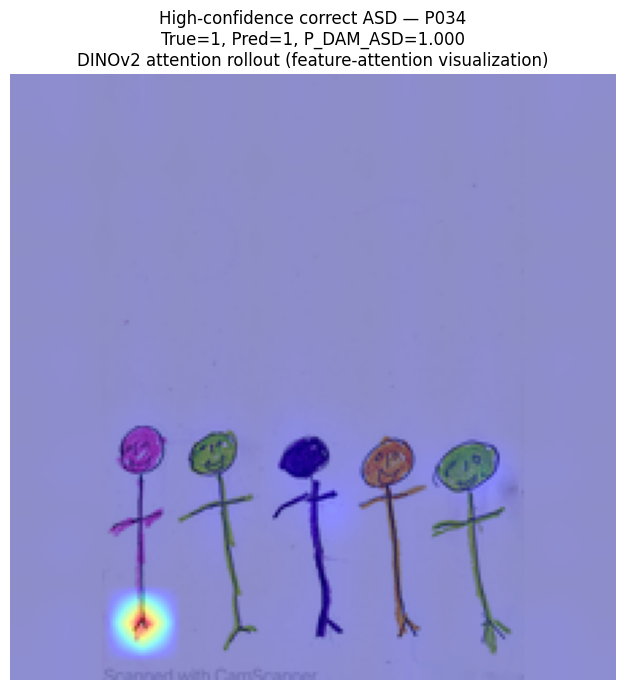

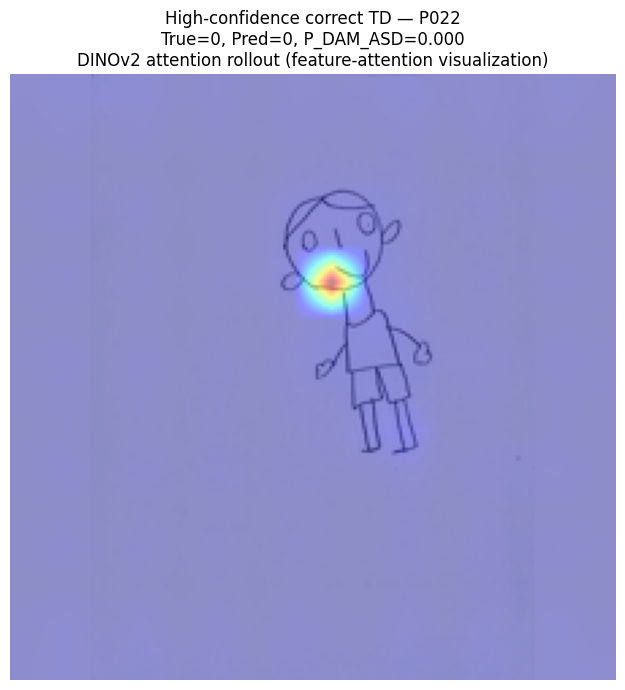

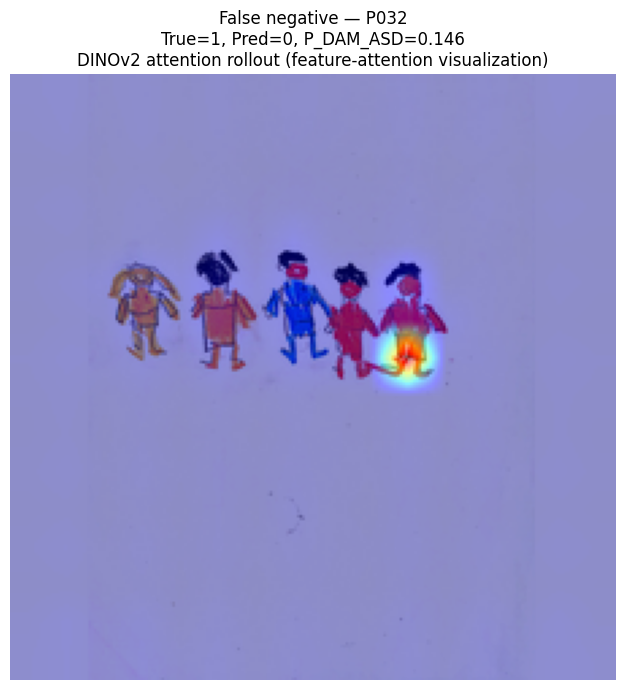

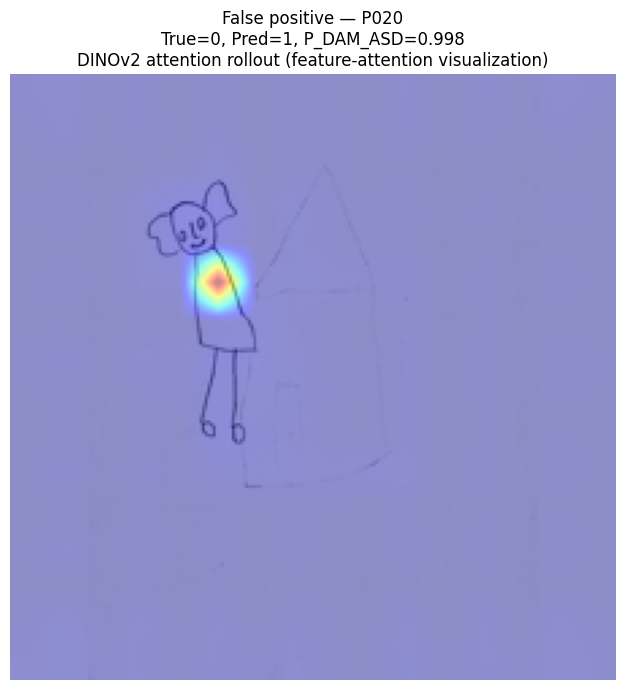


Representative DAM attention cases:


,Case,Participant_ID,True_Label,Predicted_Label,P_DAM_ASD
0,High-confidence correct ASD,P034,1,1,1.0000
1,High-confidence correct TD,P022,0,0,0.0001
2,False negative,P032,1,0,0.1457
3,False positive,P020,0,1,0.9979



Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_dinov2_attention_cases.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_dinov2_attention_high_confidence_correct_asd_P034.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_dinov2_attention_high_confidence_correct_td_P022.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_dinov2_attention_false_negative_P032.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/dam_dinov2_attention_false_positive_P020.png

Draw-a-Man attention rollout completed successfully.


In [ ]:
# ============================================================
# CELL 33B — CONTINUE DINOv2 ATTENTION ROLLOUT
# ============================================================

print("=" * 70)
print("MODEL 12 — GENERATING DAM ATTENTION MAPS")
print("=" * 70)


# ============================================================
# CHECK REQUIRED OBJECTS FROM CELL 33
# ============================================================

required_objects = [
    "representative_dam_cases",
    "dam_case_df",
    "DAM_PATH_COLUMN",
    "compute_dino_attention_rollout"
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing objects from Cell 33: "
        f"{missing_objects}. "
        "If this occurs, rerun Cell 33 from the beginning."
    )


# ============================================================
# GENERATE ATTENTION MAPS
# ============================================================

dam_attention_files = []
dam_attention_records = []


for case_name, participant_id in representative_dam_cases:

    participant_row = primary_df[
        primary_df["Participant_ID"]
        ==
        participant_id
    ].iloc[0]


    image_path = participant_row[
        DAM_PATH_COLUMN
    ]


    processed_image, attention_map = (
        compute_dino_attention_rollout(
            image_path
        )
    )


    dam_row = dam_case_df[
        dam_case_df["Participant_ID"]
        ==
        participant_id
    ].iloc[0]


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    ax.imshow(
        processed_image
    )

    ax.imshow(
        attention_map,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )


    ax.axis(
        "off"
    )


    ax.set_title(
        f"{case_name} — {participant_id}\n"
        f"True={int(dam_row['True_Label'])}, "
        f"Pred={int(dam_row['Prediction'])}, "
        f"P_DAM_ASD={dam_row['Probability']:.3f}\n"
        "DINOv2 attention rollout "
        "(feature-attention visualization)"
    )


    fig.tight_layout()


    safe_case_name = (
        case_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


    output_file = os.path.join(
        RESULTS_DIR,
        (
            f"dam_dinov2_attention_"
            f"{safe_case_name}_"
            f"{participant_id}.png"
        )
    )


    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    dam_attention_files.append(
        output_file
    )


    dam_attention_records.append({

        "Case":
            case_name,

        "Participant_ID":
            participant_id,

        "True_Label":
            int(
                dam_row[
                    "True_Label"
                ]
            ),

        "Predicted_Label":
            int(
                dam_row[
                    "Prediction"
                ]
            ),

        "P_DAM_ASD":
            float(
                dam_row[
                    "Probability"
                ]
            ),

        "Image_Path":
            image_path,

        "Attention_File":
            output_file
    })


# ============================================================
# SUMMARY TABLE
# ============================================================

dam_attention_summary_df = pd.DataFrame(
    dam_attention_records
)


print(
    "\nRepresentative DAM attention cases:"
)

display(
    dam_attention_summary_df[
        [
            "Case",
            "Participant_ID",
            "True_Label",
            "Predicted_Label",
            "P_DAM_ASD"
        ]
    ]
    .round({
        "P_DAM_ASD": 4
    })
)


# ============================================================
# SAVE SUMMARY
# ============================================================

dam_attention_summary_file = os.path.join(
    RESULTS_DIR,
    "dam_dinov2_attention_cases.csv"
)


dam_attention_summary_df.to_csv(
    dam_attention_summary_file,
    index=False
)


print("\nSaved:")
print(dam_attention_summary_file)

for file_path in dam_attention_files:
    print(file_path)


print(
    "\nDraw-a-Man attention rollout "
    "completed successfully."
)

# Model 13 — Shape and Colour Visual Explainability

## 34. Classifier-Aware EfficientNet Activation Maps

The Shape and Colour branches use frozen EfficientNet-B0 embeddings followed
by Logistic Regression.

For visual explanation, the Logistic Regression model corresponding to each
participant's outer cross-validation fold is reconstructed using only the
outer-training participants.

The fitted StandardScaler and Logistic Regression coefficients are converted
into weights on the original EfficientNet embedding dimensions. These weights
are then projected onto the final convolutional feature maps.

For the Shape branch, the participant representation is the mean of the four
shape embeddings, so each shape image contributes one quarter of the CNN
component of the participant-level linear score.

For the Colour branch, the visualization represents only the EfficientNet
component of the classifier. The additional handcrafted colour-statistical
features are not spatial and therefore cannot be represented in the heatmap.

The maps are signed:

- warm regions support the model's predicted class;
- cool regions oppose the model's predicted class.

These are classifier-aware CAM-style explanations of the frozen CNN component.
They should not be interpreted as anatomical, diagnostic, or causal evidence.

MODEL 13 — SHAPE + COLOUR VISUAL EXPLAINABILITY
EfficientNet model not present in namespace; restoring pretrained EfficientNet-B0.
EfficientNet device: cuda:0
Training mode: False
Trainable parameters: 0

Detected image columns:
Circle              : circle
Square              : square
Triangle            : triangle
Inverted Triangle   : inv_triangle
Colour              : colour_drawing

Shape representative cases:
High-confidence correct ASD : P031 | true=1 | pred=1 | P_ASD=0.9905
High-confidence correct TD  : P016 | true=0 | pred=0 | P_ASD=0.0703
False negative              : P038 | true=1 | pred=0 | P_ASD=0.0543
False positive              : P018 | true=0 | pred=1 | P_ASD=0.5342

Colour representative cases:
High-confidence correct ASD : P027 | true=1 | pred=1 | P_ASD=0.9772
High-confidence correct TD  : P010 | true=0 | pred=0 | P_ASD=0.0288
False negative              : P028 | true=1 | pred=0 | P_ASD=0.2454
False positive              : P017 | true=0 | pred=1 | P_ASD=0.8452


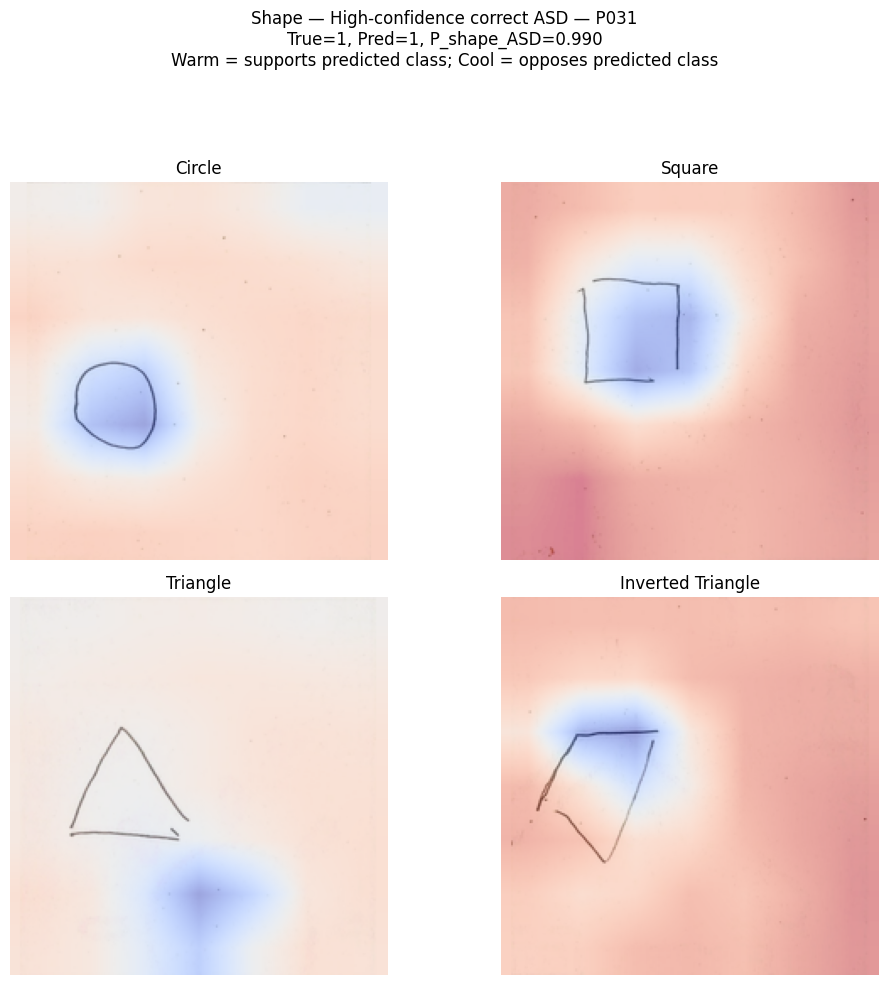

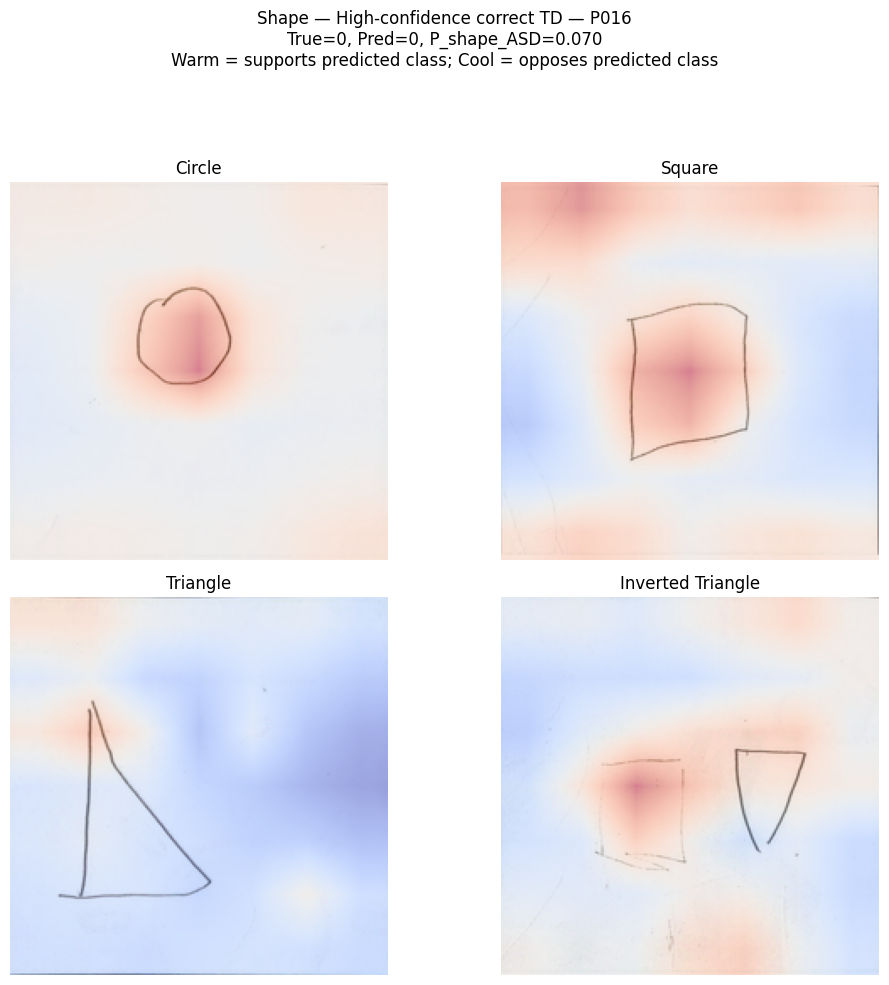

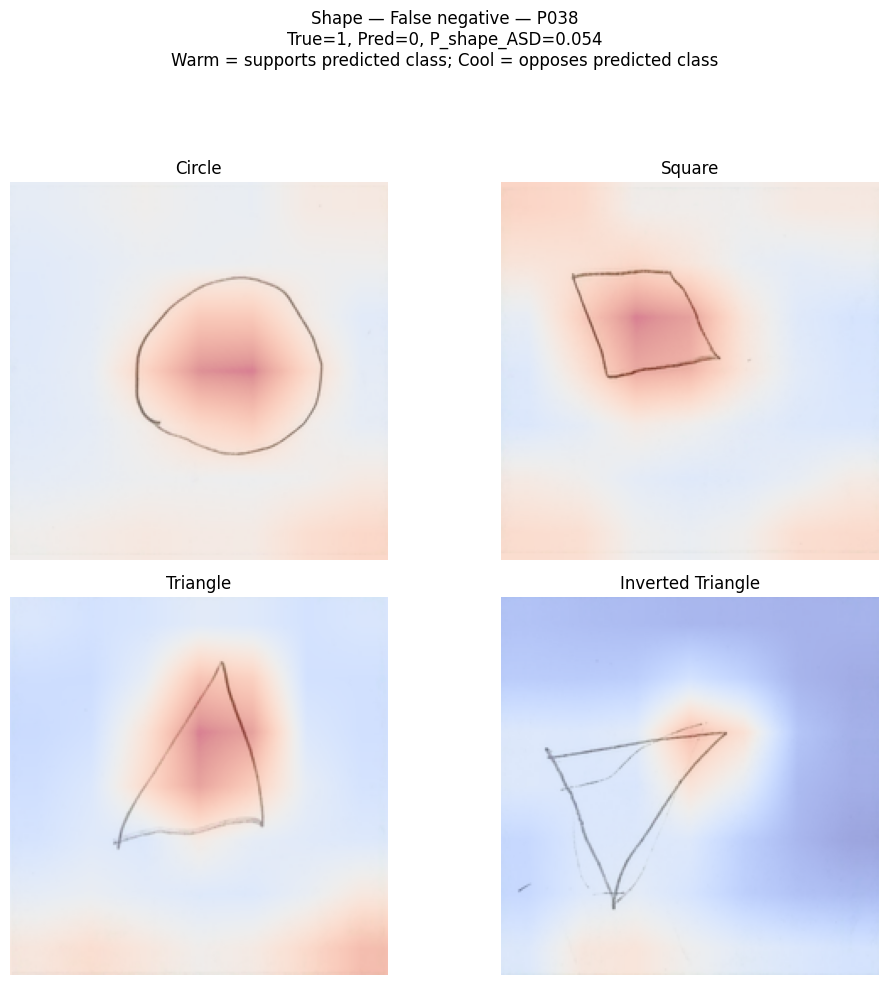

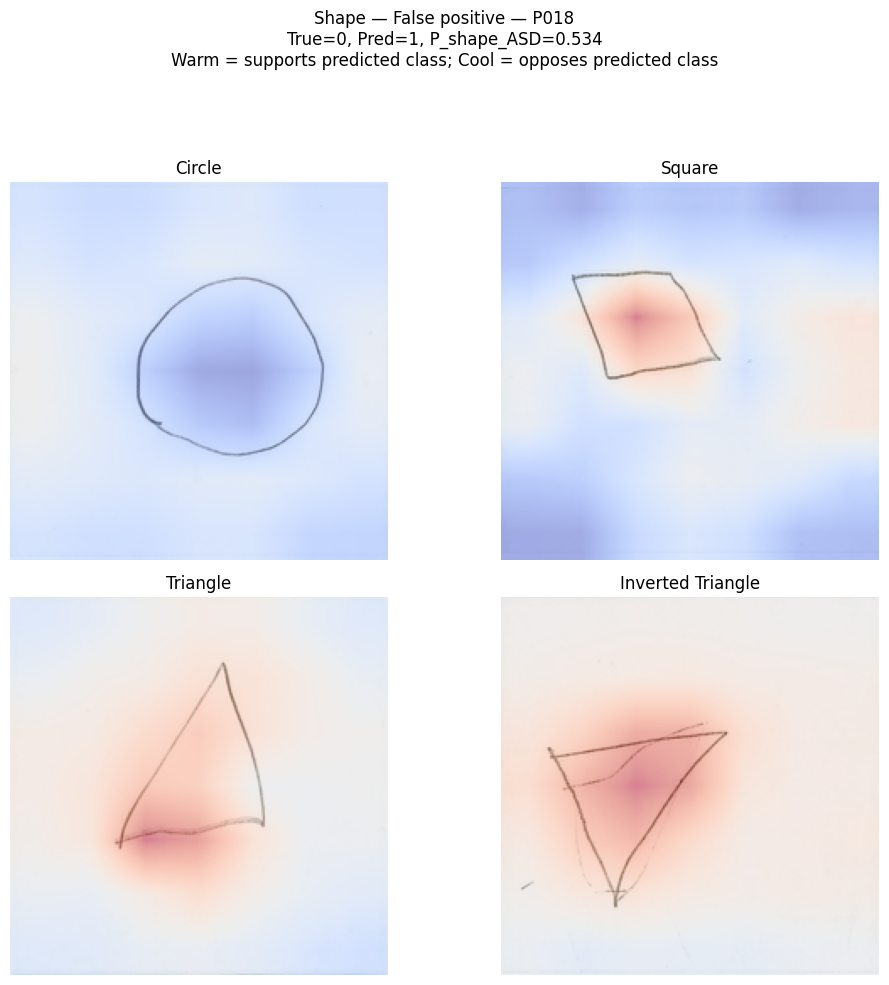

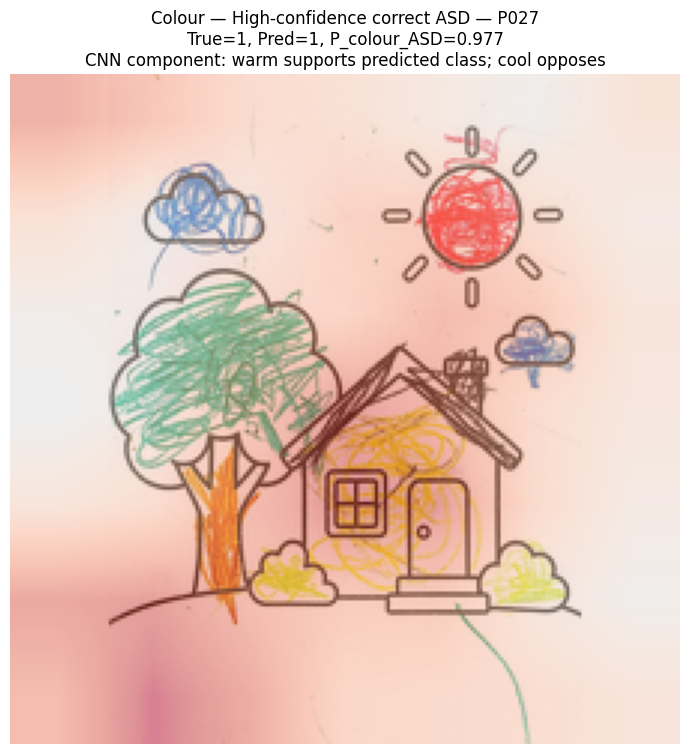

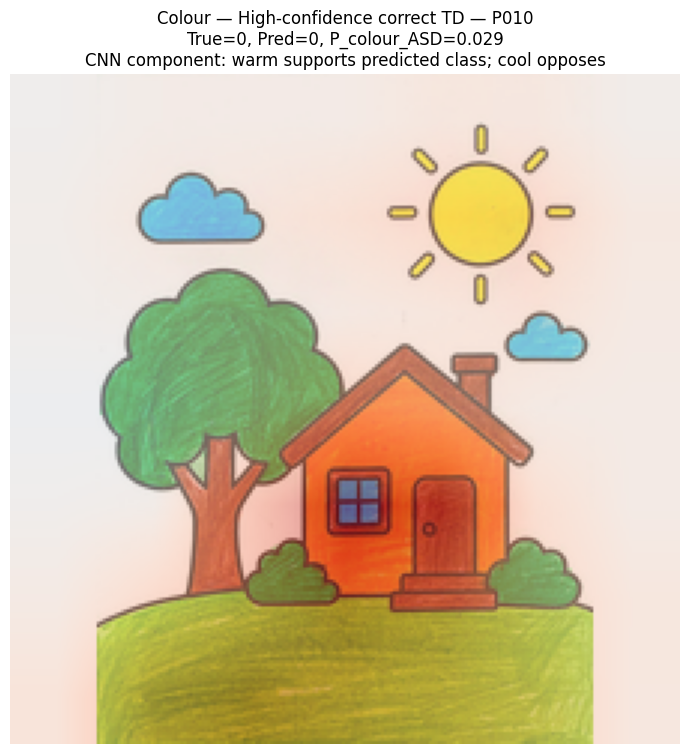

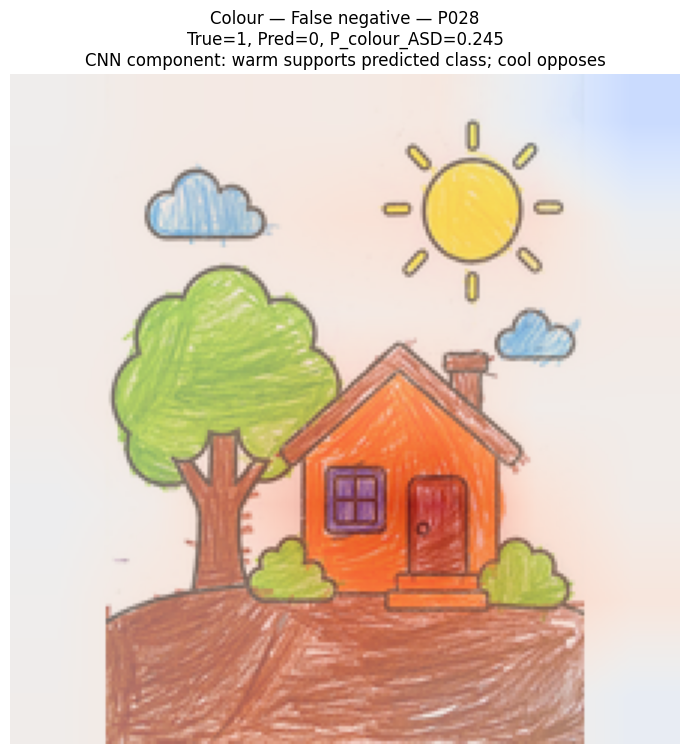

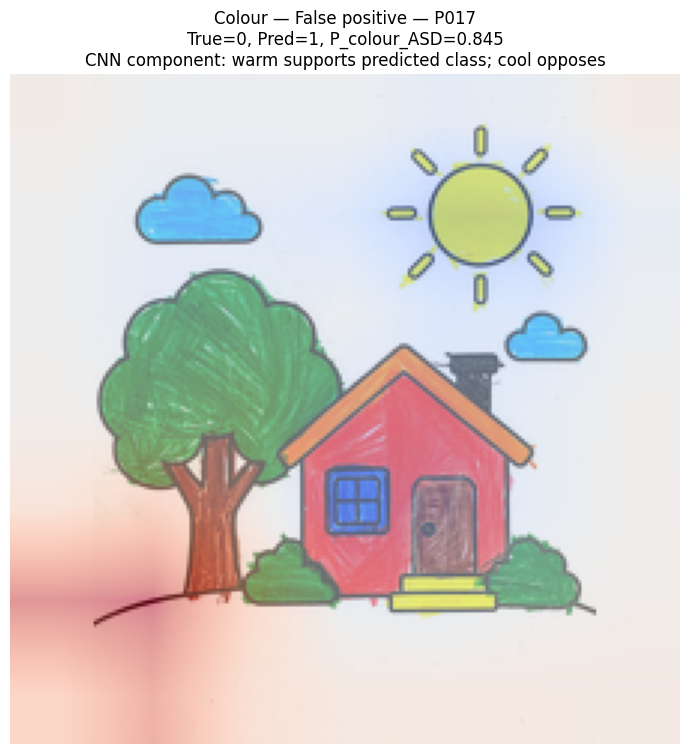


Shape visual-explanation cases:


,Case,Participant_ID,Outer_Fold,True_Label,Predicted_Label,P_shape_ASD,Reconstruction_Difference
0,High-confidence correct ASD,P031,4,1,1,0.990476,0.0
1,High-confidence correct TD,P016,4,0,0,0.070298,0.0
2,False negative,P038,4,1,0,0.054266,0.0
3,False positive,P018,3,0,1,0.534177,0.0



Colour visual-explanation cases:


,Case,Participant_ID,Outer_Fold,True_Label,Predicted_Label,P_colour_ASD,Reconstruction_Difference
0,High-confidence correct ASD,P027,3,1,1,0.977174,0.0
1,High-confidence correct TD,P010,3,0,0,0.028788,0.0
2,False negative,P028,3,1,0,0.245379,0.0
3,False positive,P017,1,0,1,0.845220,0.0



Maximum Shape reconstruction difference: 0.0000000000
Maximum Colour reconstruction difference: 0.0000000000
Classifier reconstruction check: PASS

Saved:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_classifier_cam_cases.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_classifier_cam_cases.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_classifier_cam_high_confidence_correct_asd_P031.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_classifier_cam_high_confidence_correct_td_P016.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_classifier_cam_false_negative_P038.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/shape_classifier_cam_false_positive_P018.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/colour_classifier_cam_high_confidence_correct_asd_P027.png
/content/drive/MyDrive/Autism detection/Final_ASD_Outpu

In [ ]:
# ============================================================
# MODEL 13 — CLASSIFIER-AWARE EFFICIENTNET CAM
# SHAPE + COLOUR
# ============================================================

import timm
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("=" * 70)
print("MODEL 13 — SHAPE + COLOUR VISUAL EXPLAINABILITY")
print("=" * 70)


# ============================================================
# 1. RESTORE / VERIFY EFFICIENTNET
# ============================================================

if "effnet_model" not in globals():

    print(
        "EfficientNet model not present in namespace; "
        "restoring pretrained EfficientNet-B0."
    )

    effnet_model = timm.create_model(
        "efficientnet_b0",
        pretrained=True,
        num_classes=0
    ).to(
        DEVICE
    )


effnet_model.eval()

for parameter in effnet_model.parameters():
    parameter.requires_grad = False


print(
    "EfficientNet device:",
    next(
        effnet_model.parameters()
    ).device
)

print(
    "Training mode:",
    effnet_model.training
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in effnet_model.parameters()
        if p.requires_grad
    )
)


# ============================================================
# 2. LOAD FOLD TABLES IF NECESSARY
# ============================================================

if "shape_fold_results_df" not in globals():

    shape_fold_results_df = pd.read_csv(
        os.path.join(
            RESULTS_DIR,
            "shape_nested_cv_folds.csv"
        )
    )


if "colour_fold_results_df" not in globals():

    colour_fold_results_df = pd.read_csv(
        os.path.join(
            RESULTS_DIR,
            "colour_nested_cv_folds.csv"
        )
    )


# ============================================================
# 3. IDENTIFY IMAGE-PATH COLUMNS
# ============================================================

def find_existing_column(candidates):

    for candidate in candidates:

        if candidate in primary_df.columns:
            return candidate

    return None


CIRCLE_COL = find_existing_column([
    "circle",
    "Circle",
    "circle_path",
    "Circle_path"
])

SQUARE_COL = find_existing_column([
    "square",
    "Square",
    "square_path",
    "Square_path"
])

TRIANGLE_COL = find_existing_column([
    "triangle",
    "Triangle",
    "triangle_path",
    "Triangle_path"
])

INVERTED_TRIANGLE_COL = find_existing_column([
    "inverted_triangle",
    "Inverted_Triangle",
    "inverted triangle",
    "Inverted Triangle",
    "inv_triangle",
    "inverted_triangle_path"
])

COLOUR_COL = find_existing_column([
    "colour_drawing",
    "color_drawing",
    "Colour_Drawing",
    "Color_Drawing",
    "colour",
    "color"
])


required_path_columns = {
    "Circle":
        CIRCLE_COL,

    "Square":
        SQUARE_COL,

    "Triangle":
        TRIANGLE_COL,

    "Inverted Triangle":
        INVERTED_TRIANGLE_COL,

    "Colour":
        COLOUR_COL
}


missing_path_types = [
    name
    for name, column
    in required_path_columns.items()
    if column is None
]


if missing_path_types:

    print(
        "\nAvailable primary_df columns:"
    )

    print(
        primary_df.columns.tolist()
    )

    raise RuntimeError(
        "Could not identify image columns for: "
        f"{missing_path_types}"
    )


print("\nDetected image columns:")

for name, column in required_path_columns.items():
    print(
        f"{name:20s}: {column}"
    )


# ============================================================
# 4. SAME OUTER SPLITS USED IN BRANCH EVALUATION
# ============================================================

branch_outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=SEED
)


branch_splits = list(
    branch_outer_cv.split(
        X_shape,
        y
    )
)


# ============================================================
# 5. RECONSTRUCT FOLD-SPECIFIC LR MODEL
# ============================================================

def reconstruct_lr_model(
    X,
    y_values,
    fold_number,
    best_c
):

    train_idx, test_idx = (
        branch_splits[
            fold_number - 1
        ]
    )


    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                class_weight="balanced",
                C=float(best_c),
                max_iter=5000,
                random_state=SEED
            )
        )
    ])


    pipeline.fit(
        X[
            train_idx
        ],
        y_values[
            train_idx
        ]
    )


    return (
        pipeline,
        train_idx,
        test_idx
    )


# ============================================================
# 6. CNN FEATURE MAP
# ============================================================

def get_effnet_feature_map(
    image_path
):

    image = load_rgb_image(
        image_path
    )


    processed_image = resize_pad_white(
        image,
        target_size=224
    )


    tensor = effnet_tensor_transform(
        processed_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    with torch.no_grad():

        feature_map = effnet_model.forward_features(
            tensor
        )


        embedding = effnet_model.forward_head(
            feature_map,
            pre_logits=True
        )


    feature_map = (
        feature_map[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )


    embedding = (
        embedding[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )


    if feature_map.shape[0] != 1280:

        raise RuntimeError(
            "Unexpected EfficientNet feature-map channels: "
            f"{feature_map.shape}"
        )


    if embedding.shape != (1280,):

        raise RuntimeError(
            "Unexpected EfficientNet embedding shape: "
            f"{embedding.shape}"
        )


    return (
        np.asarray(
            processed_image
        ),
        feature_map,
        embedding
    )


# ============================================================
# 7. SIGNED CLASSIFIER-AWARE CAM
# ============================================================

def compute_signed_lr_cam(
    image_path,
    fitted_pipeline,
    cnn_feature_count=1280,
    target_prediction=1,
    aggregation_factor=1.0
):

    (
        processed_image,
        feature_map,
        embedding
    ) = get_effnet_feature_map(
        image_path
    )


    scaler = fitted_pipeline.named_steps[
        "scaler"
    ]

    classifier = fitted_pipeline.named_steps[
        "classifier"
    ]


    # LR operates on:
    # z = (x - mean) / scale
    #
    # therefore raw feature coefficient is:
    # beta_raw = beta_scaled / scale

    raw_weights = (
        classifier.coef_[
            0,
            :cnn_feature_count
        ]
        /
        scaler.scale_[
            :cnn_feature_count
        ]
    )


    # Shape uses mean of four embeddings.
    raw_weights = (
        raw_weights
        *
        aggregation_factor
    )


    # Explain whichever class the model predicted.
    # Logistic score > 0 supports ASD.
    # Negative score supports TD.

    class_sign = (
        1.0
        if int(target_prediction) == 1
        else -1.0
    )


    class_weights = (
        raw_weights
        *
        class_sign
    )


    signed_cam = np.tensordot(
        class_weights,
        feature_map,
        axes=(
            0,
            0
        )
    )


    signed_cam_tensor = torch.tensor(
        signed_cam,
        dtype=torch.float32
    ).unsqueeze(
        0
    ).unsqueeze(
        0
    )


    signed_cam_tensor = F.interpolate(
        signed_cam_tensor,
        size=(
            224,
            224
        ),
        mode="bilinear",
        align_corners=False
    )


    signed_cam = (
        signed_cam_tensor[
            0,
            0
        ]
        .numpy()
    )


    maximum_absolute_value = np.max(
        np.abs(
            signed_cam
        )
    )


    if maximum_absolute_value > 0:

        signed_cam = (
            signed_cam
            /
            maximum_absolute_value
        )


    return (
        processed_image,
        signed_cam,
        embedding
    )


# ============================================================
# 8. OBJECTIVE CASE SELECTION
# ============================================================

def select_representative_cases(
    probabilities,
    predictions,
    labels
):

    case_df = pd.DataFrame({

        "Participant_ID":
            participant_ids_safe,

        "True_Label":
            labels,

        "Probability":
            probabilities,

        "Prediction":
            predictions
    })


    cases = []


    correct_asd = case_df[
        (
            case_df[
                "True_Label"
            ] == 1
        )
        &
        (
            case_df[
                "Prediction"
            ] == 1
        )
    ]


    if len(correct_asd) > 0:

        row = correct_asd.loc[
            correct_asd[
                "Probability"
            ].idxmax()
        ]

        cases.append(
            (
                "High-confidence correct ASD",
                row[
                    "Participant_ID"
                ]
            )
        )


    correct_td = case_df[
        (
            case_df[
                "True_Label"
            ] == 0
        )
        &
        (
            case_df[
                "Prediction"
            ] == 0
        )
    ]


    if len(correct_td) > 0:

        row = correct_td.loc[
            correct_td[
                "Probability"
            ].idxmin()
        ]

        cases.append(
            (
                "High-confidence correct TD",
                row[
                    "Participant_ID"
                ]
            )
        )


    false_negative = case_df[
        (
            case_df[
                "True_Label"
            ] == 1
        )
        &
        (
            case_df[
                "Prediction"
            ] == 0
        )
    ]


    if len(false_negative) > 0:

        row = false_negative.loc[
            false_negative[
                "Probability"
            ].idxmin()
        ]

        cases.append(
            (
                "False negative",
                row[
                    "Participant_ID"
                ]
            )
        )


    false_positive = case_df[
        (
            case_df[
                "True_Label"
            ] == 0
        )
        &
        (
            case_df[
                "Prediction"
            ] == 1
        )
    ]


    if len(false_positive) > 0:

        row = false_positive.loc[
            false_positive[
                "Probability"
            ].idxmax()
        ]

        cases.append(
            (
                "False positive",
                row[
                    "Participant_ID"
                ]
            )
        )


    return cases


shape_cam_cases = select_representative_cases(
    shape_oof_proba,
    shape_oof_pred,
    y_shape
)


colour_cam_cases = select_representative_cases(
    colour_oof_proba,
    colour_oof_pred,
    y_colour
)


print(
    "\nShape representative cases:"
)

for case_name, participant_id in shape_cam_cases:

    index = np.where(
        participant_ids_safe
        ==
        participant_id
    )[0][0]

    print(
        f"{case_name:28s}: "
        f"{participant_id} | "
        f"true={y_shape[index]} | "
        f"pred={shape_oof_pred[index]} | "
        f"P_ASD={shape_oof_proba[index]:.4f}"
    )


print(
    "\nColour representative cases:"
)

for case_name, participant_id in colour_cam_cases:

    index = np.where(
        participant_ids_safe
        ==
        participant_id
    )[0][0]

    print(
        f"{case_name:28s}: "
        f"{participant_id} | "
        f"true={y_colour[index]} | "
        f"pred={colour_oof_pred[index]} | "
        f"P_ASD={colour_oof_proba[index]:.4f}"
    )


# ============================================================
# 9. SHAPE CAM FIGURES
# ============================================================

shape_cam_records = []
shape_cam_files = []


shape_image_columns = [
    (
        "Circle",
        CIRCLE_COL
    ),
    (
        "Square",
        SQUARE_COL
    ),
    (
        "Triangle",
        TRIANGLE_COL
    ),
    (
        "Inverted Triangle",
        INVERTED_TRIANGLE_COL
    )
]


for case_name, participant_id in shape_cam_cases:

    participant_index = int(
        np.where(
            participant_ids_safe
            ==
            participant_id
        )[0][0]
    )


    fold_number = int(
        shape_outer_fold[
            participant_index
        ]
    )


    best_c = float(

        shape_fold_results_df.loc[
            shape_fold_results_df[
                "Fold"
            ] == fold_number,
            "Best_C"
        ].iloc[0]
    )


    (
        fold_model,
        _,
        fold_test_idx
    ) = reconstruct_lr_model(
        X_shape,
        y_shape,
        fold_number,
        best_c
    )


    # Verify reconstructed held-out prediction
    reconstructed_probability = float(

        fold_model.predict_proba(
            X_shape[
                participant_index
            ].reshape(
                1,
                -1
            )
        )[0, 1]
    )


    original_probability = float(
        shape_oof_proba[
            participant_index
        ]
    )


    probability_difference = abs(
        reconstructed_probability
        -
        original_probability
    )


    participant_row = primary_df[
        primary_df[
            "Participant_ID"
        ]
        ==
        participant_id
    ].iloc[0]


    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            10,
            10
        )
    )


    for ax, (
        shape_name,
        path_column
    ) in zip(
        axes.ravel(),
        shape_image_columns
    ):

        image_path = participant_row[
            path_column
        ]


        processed_image, signed_cam, _ = (
            compute_signed_lr_cam(

                image_path=image_path,

                fitted_pipeline=
                    fold_model,

                cnn_feature_count=
                    1280,

                target_prediction=
                    shape_oof_pred[
                        participant_index
                    ],

                # mean of 4 shape embeddings
                aggregation_factor=
                    0.25
            )
        )


        ax.imshow(
            processed_image
        )


        ax.imshow(
            signed_cam,
            cmap="coolwarm",
            alpha=0.50,
            vmin=-1,
            vmax=1
        )


        ax.set_title(
            shape_name
        )


        ax.axis(
            "off"
        )


    fig.suptitle(
        f"Shape — {case_name} — {participant_id}\n"
        f"True={int(y_shape[participant_index])}, "
        f"Pred={int(shape_oof_pred[participant_index])}, "
        f"P_shape_ASD={original_probability:.3f}\n"
        "Warm = supports predicted class; "
        "Cool = opposes predicted class",
        fontsize=12
    )


    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.92
        ]
    )


    safe_case = (
        case_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )


    output_file = os.path.join(
        RESULTS_DIR,
        (
            f"shape_classifier_cam_"
            f"{safe_case}_"
            f"{participant_id}.png"
        )
    )


    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    shape_cam_files.append(
        output_file
    )


    shape_cam_records.append({

        "Case":
            case_name,

        "Participant_ID":
            participant_id,

        "Outer_Fold":
            fold_number,

        "True_Label":
            int(
                y_shape[
                    participant_index
                ]
            ),

        "Predicted_Label":
            int(
                shape_oof_pred[
                    participant_index
                ]
            ),

        "P_shape_ASD":
            original_probability,

        "Reconstruction_Difference":
            probability_difference,

        "Figure":
            output_file
    })


# ============================================================
# 10. COLOUR CAM FIGURES
# ============================================================

colour_cam_records = []
colour_cam_files = []


for case_name, participant_id in colour_cam_cases:

    participant_index = int(
        np.where(
            participant_ids_safe
            ==
            participant_id
        )[0][0]
    )


    fold_number = int(
        colour_outer_fold[
            participant_index
        ]
    )


    best_c = float(

        colour_fold_results_df.loc[
            colour_fold_results_df[
                "Fold"
            ] == fold_number,
            "Best_C"
        ].iloc[0]
    )


    (
        fold_model,
        _,
        fold_test_idx
    ) = reconstruct_lr_model(
        X_colour,
        y_colour,
        fold_number,
        best_c
    )


    reconstructed_probability = float(

        fold_model.predict_proba(
            X_colour[
                participant_index
            ].reshape(
                1,
                -1
            )
        )[0, 1]
    )


    original_probability = float(
        colour_oof_proba[
            participant_index
        ]
    )


    probability_difference = abs(
        reconstructed_probability
        -
        original_probability
    )


    participant_row = primary_df[
        primary_df[
            "Participant_ID"
        ]
        ==
        participant_id
    ].iloc[0]


    image_path = participant_row[
        COLOUR_COL
    ]


    processed_image, signed_cam, _ = (
        compute_signed_lr_cam(

            image_path=image_path,

            fitted_pipeline=
                fold_model,

            cnn_feature_count=
                1280,

            target_prediction=
                colour_oof_pred[
                    participant_index
                ],

            aggregation_factor=
                1.0
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            7,
            8
        )
    )


    ax.imshow(
        processed_image
    )


    ax.imshow(
        signed_cam,
        cmap="coolwarm",
        alpha=0.50,
        vmin=-1,
        vmax=1
    )


    ax.axis(
        "off"
    )


    ax.set_title(
        f"Colour — {case_name} — {participant_id}\n"
        f"True={int(y_colour[participant_index])}, "
        f"Pred={int(colour_oof_pred[participant_index])}, "
        f"P_colour_ASD={original_probability:.3f}\n"
        "CNN component: warm supports predicted class; "
        "cool opposes"
    )


    fig.tight_layout()


    safe_case = (
        case_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "-",
            "_"
        )
    )


    output_file = os.path.join(
        RESULTS_DIR,
        (
            f"colour_classifier_cam_"
            f"{safe_case}_"
            f"{participant_id}.png"
        )
    )


    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    colour_cam_files.append(
        output_file
    )


    colour_cam_records.append({

        "Case":
            case_name,

        "Participant_ID":
            participant_id,

        "Outer_Fold":
            fold_number,

        "True_Label":
            int(
                y_colour[
                    participant_index
                ]
            ),

        "Predicted_Label":
            int(
                colour_oof_pred[
                    participant_index
                ]
            ),

        "P_colour_ASD":
            original_probability,

        "Reconstruction_Difference":
            probability_difference,

        "Figure":
            output_file
    })


# ============================================================
# 11. SUMMARY TABLES
# ============================================================

shape_cam_summary_df = pd.DataFrame(
    shape_cam_records
)


colour_cam_summary_df = pd.DataFrame(
    colour_cam_records
)


print(
    "\nShape visual-explanation cases:"
)

display(
    shape_cam_summary_df[
        [
            "Case",
            "Participant_ID",
            "Outer_Fold",
            "True_Label",
            "Predicted_Label",
            "P_shape_ASD",
            "Reconstruction_Difference"
        ]
    ]
    .round(6)
)


print(
    "\nColour visual-explanation cases:"
)

display(
    colour_cam_summary_df[
        [
            "Case",
            "Participant_ID",
            "Outer_Fold",
            "True_Label",
            "Predicted_Label",
            "P_colour_ASD",
            "Reconstruction_Difference"
        ]
    ]
    .round(6)
)


# ============================================================
# 12. RECONSTRUCTION CHECK
# ============================================================

max_shape_diff = (
    shape_cam_summary_df[
        "Reconstruction_Difference"
    ].max()
)


max_colour_diff = (
    colour_cam_summary_df[
        "Reconstruction_Difference"
    ].max()
)


print(
    "\nMaximum Shape reconstruction difference:",
    f"{max_shape_diff:.10f}"
)

print(
    "Maximum Colour reconstruction difference:",
    f"{max_colour_diff:.10f}"
)


if (
    max_shape_diff <= 1e-7
    and
    max_colour_diff <= 1e-7
):

    print(
        "Classifier reconstruction check: PASS"
    )

else:

    print(
        "Classifier reconstruction check: CHECK REQUIRED"
    )


# ============================================================
# 13. SAVE
# ============================================================

shape_cam_summary_file = os.path.join(
    RESULTS_DIR,
    "shape_classifier_cam_cases.csv"
)

colour_cam_summary_file = os.path.join(
    RESULTS_DIR,
    "colour_classifier_cam_cases.csv"
)


shape_cam_summary_df.to_csv(
    shape_cam_summary_file,
    index=False
)

colour_cam_summary_df.to_csv(
    colour_cam_summary_file,
    index=False
)


print("\nSaved:")
print(shape_cam_summary_file)
print(colour_cam_summary_file)

for file_path in shape_cam_files:
    print(file_path)

for file_path in colour_cam_files:
    print(file_path)


print(
    "\nShape and Colour visual explainability "
    "completed successfully."
)

# Final Research Pipeline Completion

## 35. Integrity, Reproducibility, and Output Manifest

This final step verifies that the principal outputs of the ASD screening
research pipeline have been generated successfully.

The completed pilot framework includes:

- Shape branch
- Colour Drawing branch
- Draw-a-Man branch
- Caregiver Questionnaire branch
- fully nested four-modality late fusion
- fully nested exploratory ablation analysis
- participant-level bootstrap uncertainty intervals
- paired model comparisons
- training-only threshold optimization
- provisional Low / Moderate / High score bands
- questionnaire SHAP explainability
- DINOv2 Draw-a-Man attention rollout
- classifier-aware Shape and Colour activation maps

The four-modality fully nested fusion remains the pre-specified primary
multimodal analysis.

Ablation configurations are exploratory.

The 0.40 and 0.70 score bands are provisional presentation bands and are not
clinically validated thresholds.

All reported results should be interpreted as pilot findings because of the
small participant cohort.

In [ ]:
# ============================================================
# CELL 35 — FINAL PIPELINE INTEGRITY + EXPORT
# ============================================================

import os
import sys
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import sklearn
import torch
import timm

print("=" * 78)
print("FINAL ASD RESEARCH PIPELINE INTEGRITY CHECK")
print("=" * 78)


# ============================================================
# 1. FINAL DIRECTORY
# ============================================================

FINAL_DIR = os.path.join(
    PROJECT_DIR,
    "Final_ASD_Outputs"
)

FINAL_RESULTS_DIR = os.path.join(
    FINAL_DIR,
    "results"
)

os.makedirs(
    FINAL_RESULTS_DIR,
    exist_ok=True
)

print("\nFinal output directory:")
print(FINAL_DIR)


# ============================================================
# 2. CORE COHORT INTEGRITY
# ============================================================

print("\n" + "-" * 78)
print("COHORT INTEGRITY")
print("-" * 78)

final_checks = {}


final_checks[
    "Participants_are_34"
] = (
    len(primary_df) == 34
)


final_checks[
    "Unique_participant_IDs"
] = (
    len(
        np.unique(
            participant_ids_safe
        )
    )
    ==
    34
)


final_checks[
    "TD_count_is_20"
] = (
    int(
        (y == 0).sum()
    )
    ==
    20
)


final_checks[
    "ASD_count_is_14"
] = (
    int(
        (y == 1).sum()
    )
    ==
    14
)


final_checks[
    "All_primary_labels_binary"
] = set(
    np.unique(
        y
    )
).issubset({
    0,
    1
})


for check_name, passed in final_checks.items():

    print(
        f"{check_name:35s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


# ============================================================
# 3. PRIMARY OOF PREDICTION INTEGRITY
# ============================================================

print("\n" + "-" * 78)
print("PRIMARY OOF PREDICTION INTEGRITY")
print("-" * 78)


oof_probability_arrays = {

    "Shape":
        shape_oof_proba,

    "Colour":
        colour_oof_proba,

    "Draw-a-Man":
        dam_oof_proba,

    "Questionnaire_XGBoost":
        questionnaire_xgb_oof_proba,

    "Fully_Nested_Fusion":
        fusion_oof_proba
}


oof_checks = {}


for model_name, probability_array in (
    oof_probability_arrays.items()
):

    probability_array = np.asarray(
        probability_array,
        dtype=np.float64
    )


    correct_length = (
        len(
            probability_array
        )
        ==
        len(y)
    )


    all_finite = (
        np.isfinite(
            probability_array
        ).all()
    )


    valid_range = (
        np.all(
            probability_array >= 0
        )
        and
        np.all(
            probability_array <= 1
        )
    )


    passed = (
        correct_length
        and
        all_finite
        and
        valid_range
    )


    oof_checks[
        model_name
    ] = passed


    print(
        f"{model_name:28s}: "
        f"{'PASS' if passed else 'FAIL'}"
    )


# ============================================================
# 4. FINAL PRIMARY PERFORMANCE TABLE
# ============================================================

print("\n" + "-" * 78)
print("FINAL PRIMARY PERFORMANCE SUMMARY")
print("-" * 78)


final_primary_summary_df = pd.DataFrame([

    {
        "Model":
            "Shape",

        "Accuracy":
            shape_metrics_complete[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            shape_metrics_complete[
                "Balanced_Accuracy"
            ],

        "Precision":
            shape_metrics_complete[
                "Precision"
            ],

        "Sensitivity":
            shape_metrics_complete[
                "Recall_Sensitivity"
            ],

        "Specificity":
            shape_metrics_complete[
                "Specificity"
            ],

        "F1":
            shape_metrics_complete[
                "F1"
            ],

        "ROC_AUC":
            shape_metrics_complete[
                "AUC_ROC"
            ],

        "PR_AUC":
            shape_metrics_complete[
                "PR_AUC"
            ]
    },


    {
        "Model":
            "Colour",

        "Accuracy":
            colour_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            colour_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            colour_metrics[
                "Precision"
            ],

        "Sensitivity":
            colour_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            colour_metrics[
                "Specificity"
            ],

        "F1":
            colour_metrics[
                "F1"
            ],

        "ROC_AUC":
            colour_metrics[
                "AUC_ROC"
            ],

        "PR_AUC":
            colour_metrics[
                "PR_AUC"
            ]
    },


    {
        "Model":
            "Draw-a-Man",

        "Accuracy":
            dam_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            dam_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            dam_metrics[
                "Precision"
            ],

        "Sensitivity":
            dam_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            dam_metrics[
                "Specificity"
            ],

        "F1":
            dam_metrics[
                "F1"
            ],

        "ROC_AUC":
            dam_metrics[
                "AUC_ROC"
            ],

        "PR_AUC":
            dam_metrics[
                "PR_AUC"
            ]
    },


    {
        "Model":
            "Questionnaire (XGBoost)",

        "Accuracy":
            questionnaire_xgb_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            questionnaire_xgb_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            questionnaire_xgb_metrics[
                "Precision"
            ],

        "Sensitivity":
            questionnaire_xgb_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            questionnaire_xgb_metrics[
                "Specificity"
            ],

        "F1":
            questionnaire_xgb_metrics[
                "F1"
            ],

        "ROC_AUC":
            questionnaire_xgb_metrics[
                "AUC_ROC"
            ],

        "PR_AUC":
            questionnaire_xgb_metrics[
                "PR_AUC"
            ]
    },


    {
        "Model":
            "Fully Nested Fusion",

        "Accuracy":
            fusion_metrics[
                "Accuracy"
            ],

        "Balanced_Accuracy":
            fusion_metrics[
                "Balanced_Accuracy"
            ],

        "Precision":
            fusion_metrics[
                "Precision"
            ],

        "Sensitivity":
            fusion_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            fusion_metrics[
                "Specificity"
            ],

        "F1":
            fusion_metrics[
                "F1"
            ],

        "ROC_AUC":
            fusion_metrics[
                "AUC_ROC"
            ],

        "PR_AUC":
            fusion_metrics[
                "PR_AUC"
            ]
    }

])


display(
    final_primary_summary_df
    .round(4)
)


# ============================================================
# 5. PRIMARY ROC-AUC CONFIDENCE INTERVAL TABLE
# ============================================================

final_auc_ci_df = (

    bootstrap_summary_df[
        bootstrap_summary_df[
            "Metric"
        ]
        ==
        "AUC_ROC"
    ]

    [
        [
            "Model",
            "Point_Estimate",
            "CI_2.5",
            "CI_97.5"
        ]
    ]

    .copy()
)


final_auc_ci_df.columns = [
    "Model",
    "ROC_AUC",
    "CI_Lower_95",
    "CI_Upper_95"
]


print(
    "\nROC-AUC with stratified bootstrap "
    "95% intervals:"
)

display(
    final_auc_ci_df
    .round(4)
)


# ============================================================
# 6. FINAL SECONDARY THRESHOLD RESULT
# ============================================================

print("\n" + "-" * 78)
print("SECONDARY TRAINING-ONLY THRESHOLD RESULT")
print("-" * 78)


threshold_final_df = pd.DataFrame([

    {
        "Method":
            "Fixed 0.50",

        "Accuracy":
            fusion_metrics[
                "Accuracy"
            ],

        "Sensitivity":
            fusion_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            fusion_metrics[
                "Specificity"
            ],

        "F1":
            fusion_metrics[
                "F1"
            ]
    },

    {
        "Method":
            "Fold-specific training-only Youden J",

        "Accuracy":
            fusion_youden_metrics[
                "Accuracy"
            ],

        "Sensitivity":
            fusion_youden_metrics[
                "Recall_Sensitivity"
            ],

        "Specificity":
            fusion_youden_metrics[
                "Specificity"
            ],

        "F1":
            fusion_youden_metrics[
                "F1"
            ]
    }

])


display(
    threshold_final_df
    .round(4)
)


print(
    "\nTraining-only threshold summary:"
)

print(
    "Mean   :",
    f"{threshold_fold_df['Selected_Threshold'].mean():.4f}"
)

print(
    "Median :",
    f"{threshold_fold_df['Selected_Threshold'].median():.4f}"
)

print(
    "Range  :",
    (
        f"{threshold_fold_df['Selected_Threshold'].min():.4f}"
        " – "
        f"{threshold_fold_df['Selected_Threshold'].max():.4f}"
    )
)


# ============================================================
# 7. FINAL ABLATION SUMMARY
# ============================================================

print("\n" + "-" * 78)
print("EXPLORATORY FULLY NESTED ABLATION SUMMARY")
print("-" * 78)


final_ablation_df = (

    ablation_summary_df[
        [
            "Configuration",
            "Accuracy",
            "Recall_Sensitivity",
            "Specificity",
            "AUC_ROC",
            "PR_AUC"
        ]
    ]

    .sort_values(
        "AUC_ROC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


display(
    final_ablation_df
    .round(4)
)


# ============================================================
# 8. REQUIRED OUTPUT FILES
# ============================================================

print("\n" + "-" * 78)
print("REQUIRED OUTPUT FILE CHECK")
print("-" * 78)


required_result_files = [

    # Primary branch predictions
    "shape_oof_predictions.csv",
    "colour_oof_predictions.csv",
    "dam_oof_predictions.csv",
    "questionnaire_oof_predictions.csv",

    # Primary metrics
    "shape_metrics.csv",
    "colour_metrics.csv",
    "dam_metrics.csv",
    "questionnaire_xgb_metrics.csv",

    # Fusion
    "fully_nested_fusion_oof_predictions.csv",
    "fully_nested_fusion_folds.csv",
    "fully_nested_fusion_metrics.csv",

    # Model comparison
    "primary_model_comparison.csv",

    # Ablation
    "fully_nested_ablation_summary.csv",
    "fully_nested_ablation_predictions.csv",

    # Uncertainty
    "primary_models_bootstrap_95ci.csv",
    "paired_bootstrap_auc_comparisons.csv",

    # Threshold
    "fusion_training_only_youden_thresholds.csv",
    "fusion_threshold_method_comparison.csv",

    # Risk-score bands
    "fusion_provisional_risk_categories.csv",

    # Questionnaire explainability
    "questionnaire_oof_shap_global_importance.csv",
    "questionnaire_oof_shap_values.csv",
    "questionnaire_participant_top5_shap.csv",

    # DAM explainability
    "dam_dinov2_attention_cases.csv",

    # Shape / Colour explainability
    "shape_classifier_cam_cases.csv",
    "colour_classifier_cam_cases.csv",

    # Core figures
    "primary_models_roc_comparison.png",
    "fully_nested_fusion_confusion_matrix.png",
    "fusion_provisional_risk_bands.png",
    "questionnaire_oof_shap_bar.png",
    "questionnaire_oof_shap_beeswarm.png"
]


file_check_records = []


for filename in required_result_files:

    filepath = os.path.join(
        RESULTS_DIR,
        filename
    )


    exists = os.path.isfile(
        filepath
    )


    size_bytes = (
        os.path.getsize(
            filepath
        )
        if exists
        else 0
    )


    file_check_records.append({

        "File":
            filename,

        "Exists":
            exists,

        "Size_Bytes":
            size_bytes
    })


required_file_check_df = pd.DataFrame(
    file_check_records
)


missing_files_df = (
    required_file_check_df[
        required_file_check_df[
            "Exists"
        ]
        ==
        False
    ]
)


print(
    f"Required result files: "
    f"{len(required_file_check_df)}"
)

print(
    f"Present: "
    f"{int(required_file_check_df['Exists'].sum())}"
)

print(
    f"Missing: "
    f"{len(missing_files_df)}"
)


if len(
    missing_files_df
) > 0:

    print(
        "\nMissing files:"
    )

    display(
        missing_files_df
    )

else:

    print(
        "Required output file check: PASS"
    )


# ============================================================
# 9. CREATE SHA256 OUTPUT MANIFEST
# ============================================================

def calculate_sha256(
    filepath
):

    sha256_hash = hashlib.sha256()


    with open(
        filepath,
        "rb"
    ) as file_object:

        while True:

            block = file_object.read(
                1024 * 1024
            )

            if not block:
                break

            sha256_hash.update(
                block
            )


    return sha256_hash.hexdigest()


manifest_records = []


for root, dirs, files in os.walk(
    FINAL_DIR
):

    for filename in sorted(
        files
    ):

        filepath = os.path.join(
            root,
            filename
        )


        relative_path = os.path.relpath(
            filepath,
            FINAL_DIR
        )


        try:

            sha256_value = calculate_sha256(
                filepath
            )

        except Exception as error:

            sha256_value = (
                f"ERROR: {error}"
            )


        manifest_records.append({

            "Relative_Path":
                relative_path,

            "Size_Bytes":
                os.path.getsize(
                    filepath
                ),

            "SHA256":
                sha256_value
        })


final_manifest_df = pd.DataFrame(
    manifest_records
)


# ============================================================
# 10. SOFTWARE / REPRODUCIBILITY INFORMATION
# ============================================================

software_versions = {

    "Python":
        sys.version.replace(
            "\n",
            " "
        ),

    "Platform":
        platform.platform(),

    "NumPy":
        np.__version__,

    "Pandas":
        pd.__version__,

    "Scikit_learn":
        sklearn.__version__,

    "PyTorch":
        torch.__version__,

    "timm":
        timm.__version__,

    "Random_SEED":
        str(SEED),

    "Primary_Cohort_N":
        "34",

    "TD_N":
        "20",

    "ASD_N":
        "14",

    "Outer_CV_Folds":
        str(
            OUTER_FOLDS
        ),

    "Fusion_Outer_CV_Folds":
        str(
            FUSION_OUTER_FOLDS
        )
}


software_versions_df = pd.DataFrame(
    [
        {
            "Setting":
                key,

            "Value":
                value
        }

        for key, value in (
            software_versions.items()
        )
    ]
)


# ============================================================
# 11. FINAL METHODOLOGICAL STATUS NOTES
# ============================================================

final_status_notes = [

    (
        "Study design",
        "Pilot multimodal ASD risk-screening study with 34 complete "
        "multimodal participants (20 TD, 14 ASD)."
    ),

    (
        "Primary multimodal model",
        "Fully nested four-modality late fusion using Shape, Colour, "
        "Draw-a-Man, and Questionnaire XGBoost probabilities."
    ),

    (
        "Primary fusion ROC-AUC",
        f"{fusion_metrics['AUC_ROC']:.4f}"
    ),

    (
        "Primary fusion sensitivity at 0.50",
        f"{fusion_metrics['Recall_Sensitivity']:.4f}"
    ),

    (
        "Primary fusion specificity at 0.50",
        f"{fusion_metrics['Specificity']:.4f}"
    ),

    (
        "Secondary threshold analysis",
        "Fold-specific Youden J thresholds selected only from outer-training "
        "participants; secondary/exploratory operating-point analysis."
    ),

    (
        "Secondary threshold sensitivity",
        f"{fusion_youden_metrics['Recall_Sensitivity']:.4f}"
    ),

    (
        "Secondary threshold specificity",
        f"{fusion_youden_metrics['Specificity']:.4f}"
    ),

    (
        "Shape branch",
        f"ROC-AUC={shape_metrics_complete['AUC_ROC']:.4f}; "
        "highest primary branch point estimate in the current cohort."
    ),

    (
        "Questionnaire primary model",
        f"XGBoost ROC-AUC="
        f"{questionnaire_xgb_metrics['AUC_ROC']:.4f}."
    ),

    (
        "Questionnaire LR baseline",
        "Logistic Regression achieved perfect nested-CV performance in the "
        "current pilot cohort; retained only as a baseline and interpreted "
        "cautiously."
    ),

    (
        "Ablation analysis",
        "Exploratory only; ablated configurations were examined after the "
        "pre-specified full fusion analysis and do not replace the primary "
        "four-modality result."
    ),

    (
        "Best exploratory ablation",
        (
            final_ablation_df.iloc[0][
                "Configuration"
            ]
            +
            " | ROC-AUC="
            +
            f"{final_ablation_df.iloc[0]['AUC_ROC']:.4f}"
        )
    ),

    (
        "Paired AUC comparisons",
        "No investigated primary model-pair 95% paired bootstrap interval "
        "excluded zero."
    ),

    (
        "Risk categories",
        "Low <0.40, Moderate 0.40–<0.70, High >=0.70 are provisional "
        "model-score presentation bands, not clinically validated cutoffs."
    ),

    (
        "Questionnaire explainability",
        "Out-of-fold SHAP; direction describes model contribution. Clinical "
        "item-direction interpretation requires the confirmed scoring key."
    ),

    (
        "DAM explainability",
        "DINOv2 attention rollout represents pretrained feature attention, "
        "not causal ASD-decision evidence."
    ),

    (
        "Shape/Colour explainability",
        "Classifier-aware EfficientNet CAM-style maps; Colour maps explain "
        "the CNN component only, not non-spatial handcrafted statistics."
    ),

    (
        "General interpretation",
        "All results are pilot findings with substantial uncertainty and "
        "require validation in a larger independent cohort."
    )
]


final_status_notes_df = pd.DataFrame(
    final_status_notes,
    columns=[
        "Topic",
        "Status"
    ]
)


# ============================================================
# 12. SAVE FINAL EXPORT FILES
# ============================================================

final_primary_summary_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_primary_performance_summary.csv"
)

final_auc_ci_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_auc_confidence_intervals.csv"
)

final_threshold_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_threshold_summary.csv"
)

final_ablation_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_exploratory_ablation_summary.csv"
)

final_file_check_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_required_file_check.csv"
)

final_manifest_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_output_manifest_sha256.csv"
)

final_versions_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_software_versions.csv"
)

final_status_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_methodological_status.csv"
)


final_primary_summary_df.to_csv(
    final_primary_summary_file,
    index=False
)

final_auc_ci_df.to_csv(
    final_auc_ci_file,
    index=False
)

threshold_final_df.to_csv(
    final_threshold_file,
    index=False
)

final_ablation_df.to_csv(
    final_ablation_file,
    index=False
)

required_file_check_df.to_csv(
    final_file_check_file,
    index=False
)

final_manifest_df.to_csv(
    final_manifest_file,
    index=False
)

software_versions_df.to_csv(
    final_versions_file,
    index=False
)

final_status_notes_df.to_csv(
    final_status_file,
    index=False
)


# ============================================================
# 13. FINAL JSON RESEARCH SUMMARY
# ============================================================

final_json_summary = {

    "cohort": {
        "n":
            int(
                len(y)
            ),

        "td":
            int(
                (y == 0).sum()
            ),

        "asd":
            int(
                (y == 1).sum()
            )
    },


    "primary_models": {

        "shape_auc":
            float(
                shape_metrics_complete[
                    "AUC_ROC"
                ]
            ),

        "colour_auc":
            float(
                colour_metrics[
                    "AUC_ROC"
                ]
            ),

        "dam_auc":
            float(
                dam_metrics[
                    "AUC_ROC"
                ]
            ),

        "questionnaire_xgb_auc":
            float(
                questionnaire_xgb_metrics[
                    "AUC_ROC"
                ]
            ),

        "fully_nested_fusion_auc":
            float(
                fusion_metrics[
                    "AUC_ROC"
                ]
            )
    },


    "fusion_fixed_0_5": {

        "accuracy":
            float(
                fusion_metrics[
                    "Accuracy"
                ]
            ),

        "sensitivity":
            float(
                fusion_metrics[
                    "Recall_Sensitivity"
                ]
            ),

        "specificity":
            float(
                fusion_metrics[
                    "Specificity"
                ]
            )
    },


    "fusion_training_only_youden": {

        "accuracy":
            float(
                fusion_youden_metrics[
                    "Accuracy"
                ]
            ),

        "sensitivity":
            float(
                fusion_youden_metrics[
                    "Recall_Sensitivity"
                ]
            ),

        "specificity":
            float(
                fusion_youden_metrics[
                    "Specificity"
                ]
            )
    },


    "risk_bands": {

        "low_upper_exclusive":
            0.40,

        "moderate_upper_exclusive":
            0.70,

        "status":
            "provisional_not_clinically_validated"
    },


    "analysis_status":
        "complete"
}


final_json_file = os.path.join(
    FINAL_RESULTS_DIR,
    "FINAL_research_summary.json"
)


with open(
    final_json_file,
    "w"
) as json_file:

    json.dump(
        final_json_summary,
        json_file,
        indent=4
    )


# ============================================================
# 14. RE-CREATE MANIFEST AFTER FINAL EXPORTS
#
# Ensures newly created FINAL files themselves are included.
# ============================================================

manifest_records = []


for root, dirs, files in os.walk(
    FINAL_DIR
):

    for filename in sorted(
        files
    ):

        filepath = os.path.join(
            root,
            filename
        )


        # Avoid hashing the manifest while it is being rebuilt.
        if filepath == final_manifest_file:
            continue


        relative_path = os.path.relpath(
            filepath,
            FINAL_DIR
        )


        manifest_records.append({

            "Relative_Path":
                relative_path,

            "Size_Bytes":
                os.path.getsize(
                    filepath
                ),

            "SHA256":
                calculate_sha256(
                    filepath
                )
        })


final_manifest_df = pd.DataFrame(
    manifest_records
)


final_manifest_df.to_csv(
    final_manifest_file,
    index=False
)


# ============================================================
# 15. FINAL PASS / FAIL
# ============================================================

all_core_checks_pass = all(
    final_checks.values()
)


all_oof_checks_pass = all(
    oof_checks.values()
)


all_files_present = (
    len(
        missing_files_df
    )
    ==
    0
)


FINAL_PIPELINE_PASS = (
    all_core_checks_pass
    and
    all_oof_checks_pass
    and
    all_files_present
)


print("\n" + "=" * 78)
print("FINAL EXPORTS")
print("=" * 78)

print(final_primary_summary_file)
print(final_auc_ci_file)
print(final_threshold_file)
print(final_ablation_file)
print(final_file_check_file)
print(final_manifest_file)
print(final_versions_file)
print(final_status_file)
print(final_json_file)


print("\n" + "=" * 78)

if FINAL_PIPELINE_PASS:

    print("FINAL INTEGRITY STATUS: PASS")
    print("")
    print("ASD RESEARCH PIPELINE COMPLETE — STOP")

else:

    print("FINAL INTEGRITY STATUS: CHECK REQUIRED")

    if not all_core_checks_pass:
        print("- One or more cohort integrity checks failed.")

    if not all_oof_checks_pass:
        print("- One or more OOF prediction checks failed.")

    if not all_files_present:
        print("- One or more required output files are missing.")


print("=" * 78)

FINAL ASD RESEARCH PIPELINE INTEGRITY CHECK

Final output directory:
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs

------------------------------------------------------------------------------
COHORT INTEGRITY
------------------------------------------------------------------------------
Participants_are_34                : PASS
Unique_participant_IDs             : PASS
TD_count_is_20                     : PASS
ASD_count_is_14                    : PASS
All_primary_labels_binary          : PASS

------------------------------------------------------------------------------
PRIMARY OOF PREDICTION INTEGRITY
------------------------------------------------------------------------------
Shape                       : PASS
Colour                      : PASS
Draw-a-Man                  : PASS
Questionnaire_XGBoost       : PASS
Fully_Nested_Fusion         : PASS

------------------------------------------------------------------------------
FINAL PRIMARY PERFORMANCE SUMMARY
------

,Model,Accuracy,Balanced_Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC
0,Shape,0.8529,0.8536,0.8000,0.8571,0.85,0.8276,0.8714,0.9186
1,Colour,0.8235,0.8179,0.7857,0.7857,0.85,0.7857,0.8143,0.7261
2,Draw-a-Man,0.6471,0.6571,0.5556,0.7143,0.60,0.6250,0.7143,0.6823
3,Questionnaire (XGBoost),0.8529,0.8321,0.9091,0.7143,0.95,0.8000,0.8554,0.8453
4,Fully Nested Fusion,0.7941,0.7821,0.7692,0.7143,0.85,0.7407,0.7643,0.7638



ROC-AUC with stratified bootstrap 95% intervals:


,Model,ROC_AUC,CI_Lower_95,CI_Upper_95
5,Shape,0.8714,0.6857,1.0000
12,Colour,0.8143,0.6535,0.9464
19,Draw-a-Man,0.7143,0.5214,0.8857
26,Questionnaire (XGBoost),0.8554,0.7036,0.9696
33,Fully Nested Fusion,0.7643,0.5679,0.9286



------------------------------------------------------------------------------
SECONDARY TRAINING-ONLY THRESHOLD RESULT
------------------------------------------------------------------------------


,Method,Accuracy,Sensitivity,Specificity,F1
0,Fixed 0.50,0.7941,0.7143,0.85,0.7407
1,Fold-specific training-only Youden J,0.9118,0.8571,0.95,0.8889



Training-only threshold summary:
Mean   : 0.4868
Median : 0.5028
Range  : 0.3619 – 0.5644

------------------------------------------------------------------------------
EXPLORATORY FULLY NESTED ABLATION SUMMARY
------------------------------------------------------------------------------


,Configuration,Accuracy,Recall_Sensitivity,Specificity,AUC_ROC,PR_AUC
0,No Shape,0.8529,0.7857,0.90,0.9107,0.9108
1,No Colour,0.8529,0.7857,0.90,0.8929,0.9101
2,Shape + Colour,0.8529,0.7857,0.90,0.8429,0.8787
3,No Questionnaire (Drawing-only),0.8235,0.7857,0.85,0.8250,0.8085
4,No DAM,0.8235,0.7143,0.90,0.7964,0.7243
5,Full,0.7941,0.7143,0.85,0.7643,0.7638



------------------------------------------------------------------------------
REQUIRED OUTPUT FILE CHECK
------------------------------------------------------------------------------
Required result files: 30
Present: 30
Missing: 0
Required output file check: PASS

FINAL EXPORTS
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_primary_performance_summary.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_auc_confidence_intervals.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_threshold_summary.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_exploratory_ablation_summary.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_required_file_check.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_output_manifest_sha256.csv
/content/drive/MyDrive/Autism detection/Final_ASD_Outputs/results/FINAL_software_versions.csv
/content/drive/MyDrive/A

# Final Research Workflow Summary and Completion Note

## Multimodal ASD Risk Screening Framework — Complete Pilot Pipeline

This notebook implemented and evaluated a complete multimodal machine-learning
pipeline for pilot ASD risk screening using drawing-based and caregiver
questionnaire information.

The analysis was performed at the **participant level**, with particular
attention to preventing data leakage, maintaining consistent participant
alignment across modalities, using out-of-fold predictions for evaluation,
and separating primary analyses from exploratory analyses.

The final primary multimodal cohort contained:

- **34 participants**
- **20 TD participants**
- **14 ASD participants**

All 34 participants included in the primary multimodal analysis had complete
data for:

1. Shape Drawing
2. Colour Drawing
3. Draw-a-Man Drawing
4. Caregiver Questionnaire

Five additional participants had questionnaire information but did not have
the complete image modalities. They were therefore not included in the
primary multimodal comparison, so that every primary branch and the fusion
model were evaluated on the same 34 participants.

---

## 1. Data Validation and Participant Alignment

The analysis began by validating the participant-information table,
questionnaire-response table, ASD image folder, and Non-ASD image folder.

Participant identifiers were standardized into a common format so that
records such as differently formatted participant IDs referred to the same
participant consistently.

The following integrity checks were performed:

- duplicate participant IDs;
- missing participant information;
- missing questionnaire responses;
- questionnaire values outside the expected Likert range;
- inconsistencies between folder labels and participant-table labels;
- inconsistencies between questionnaire labels and participant-table labels;
- missing image modalities;
- unreadable or corrupt images;
- participant ordering across all modalities.

The authoritative binary labels used throughout the machine-learning
analysis were:

- **TD = 0**
- **ASD = 1**

The final primary multimodal dataset contained no duplicate participant IDs,
no missing required multimodal values, and complete label agreement across
the validated data sources.

---

## 2. Image Validation and Preprocessing

A total of six images were required for every participant:

### Shape Drawing Branch

Each participant completed four shape drawings:

1. Circle
2. Square
3. Triangle
4. Inverted Triangle

### Other Drawing Branches

5. Colour Drawing
6. Draw-a-Man Drawing

All **204 expected images** were successfully validated:

**34 participants × 6 images = 204 images**

No unreadable images were detected.

The images had different original resolutions and aspect ratios. Therefore,
the images were not directly stretched into a square.

The locked preprocessing procedure was:

1. load the image in RGB format;
2. preserve the complete manually cropped drawing area;
3. preserve the original aspect ratio;
4. resize the longest dimension to the target resolution;
5. centre the resized image on a white **224 × 224** canvas.

No content-based tight bounding-box cropping was used because spatial
position, relative drawing size, and surrounding white space may contain
information relevant to the drawing task.

No random augmentation was used during frozen feature extraction so that each
participant received a deterministic representation.

---

## 3. Pretrained Visual Feature Extraction

Two pretrained visual backbones were used.

### EfficientNet-B0

A pretrained ImageNet EfficientNet-B0 model was used as a frozen feature
extractor for:

- Shape drawings
- Colour drawings

The classifier head was removed and a **1280-dimensional embedding** was
extracted from each image.

All EfficientNet parameters remained frozen.

### DINOv2-Small

A pretrained `facebook/dinov2-small` Vision Transformer was used as the
frozen Draw-a-Man feature extractor.

The CLS-token representation was extracted, producing a:

**384-dimensional Draw-a-Man representation**

All DINOv2 parameters remained frozen.

The frozen-backbone strategy was selected because the pilot cohort was too
small to support reliable fine-tuning of large deep neural networks.

---

## 4. Shape Branch Construction

Each participant had four separate EfficientNet embeddings:

- Circle: 1280 features
- Square: 1280 features
- Triangle: 1280 features
- Inverted Triangle: 1280 features

The four embeddings were combined at the participant level using their
arithmetic mean.

Therefore, each participant was represented by one:

**1280-dimensional Shape feature vector**

Averaging avoided treating four drawings from the same child as four
independent participants and avoided expanding the feature space to a
5120-dimensional concatenation in a very small cohort.

---

## 5. Shape Branch Evaluation

The Shape branch used:

**StandardScaler → L2 Logistic Regression**

Model regularization strength `C` was selected inside the training data using
nested cross-validation.

The evaluation procedure consisted of:

- outer stratified 5-fold cross-validation;
- inner stratified cross-validation for hyperparameter selection;
- scaling fitted only on training participants;
- one out-of-fold probability for every participant.

The Shape branch produced:

`P_shape_ASD`

### Shape Primary Performance

- Accuracy: **0.8529**
- Balanced Accuracy: **0.8536**
- Precision: **0.8000**
- Sensitivity: **0.8571**
- Specificity: **0.8500**
- F1-score: **0.8276**
- ROC-AUC: **0.8714**
- PR-AUC: **0.9186**

Confusion matrix:

- TN = 17
- FP = 3
- FN = 2
- TP = 12

The Shape branch had the highest ROC-AUC point estimate among the individual
primary branches.

---

## 6. Colour Drawing Branch

The Colour Drawing branch combined:

### Deep visual information

- 1280-dimensional frozen EfficientNet-B0 embedding

### Objective colour statistics

The following global colour features were calculated:

- hue entropy;
- mean saturation;
- saturation variability;
- mean brightness;
- brightness variability;
- colour coverage;
- mean LAB chroma;
- LAB chroma variability;
- circular hue cosine component;
- circular hue sine component.

An initially calculated hue-diversity feature had zero variance across the
cohort and was removed before modeling.

The final Colour representation therefore contained:

**1280 CNN features + 10 colour statistics = 1290 features**

Features requiring validated semantic object masks, such as exact
object-colour correctness or true boundary overflow, were not approximated
using arbitrary geometric proxies.

### Colour Primary Performance

- Accuracy: **0.8235**
- Balanced Accuracy: **0.8179**
- Precision: **0.7857**
- Sensitivity: **0.7857**
- Specificity: **0.8500**
- F1-score: **0.7857**
- ROC-AUC: **0.8143**
- PR-AUC: **0.7261**

Confusion matrix:

- TN = 17
- FP = 3
- FN = 3
- TP = 11

The branch produced:

`P_colour_ASD`

---

## 7. Draw-a-Man Branch

The Draw-a-Man branch used the frozen DINOv2-small CLS-token representation.

Each participant therefore had:

**384 DINOv2 features**

The classifier was:

**StandardScaler → L2 Logistic Regression**

The same nested cross-validation principles used for the Shape and Colour
branches were applied.

The branch produced:

`P_DAM_ASD`

### Draw-a-Man Primary Performance

- Accuracy: **0.6471**
- Balanced Accuracy: **0.6571**
- Precision: **0.5556**
- Sensitivity: **0.7143**
- Specificity: **0.6000**
- F1-score: **0.6250**
- ROC-AUC: **0.7143**
- PR-AUC: **0.6823**

Confusion matrix:

- TN = 12
- FP = 8
- FN = 4
- TP = 10

The Draw-a-Man modality was the weakest individual primary branch in the
current pilot cohort.

---

## 8. Caregiver Questionnaire Branch

The caregiver questionnaire contained:

**25 Likert-scale items scored from 1 to 4**

All 34 multimodal participants had complete questionnaire information.

Therefore:

- no missing-value imputation was required;
- no age or gender variables were included as classifier inputs;
- only the 25 questionnaire-item responses were used.

Two classifiers were evaluated.

### Primary Questionnaire Model

**XGBoost**

### Baseline

**Logistic Regression**

Both were evaluated using nested cross-validation.

The primary questionnaire probability used in multimodal fusion was the
XGBoost output:

`P_questionnaire_ASD`

### Questionnaire XGBoost Performance

- Accuracy: **0.8529**
- Balanced Accuracy: **0.8321**
- Precision: **0.9091**
- Sensitivity: **0.7143**
- Specificity: **0.9500**
- F1-score: **0.8000**
- ROC-AUC: **0.8554**
- PR-AUC: **0.8453**

Confusion matrix:

- TN = 19
- FP = 1
- FN = 4
- TP = 10

### Logistic Regression Baseline

The questionnaire Logistic Regression baseline produced perfect
cross-validated performance in the current pilot cohort.

Because this was unusually strong, an additional questionnaire sanity audit
was performed.

The audit confirmed that:

- only the 25 questionnaire items were used;
- participant IDs were not model features;
- group labels were not model features;
- no duplicated complete 25-item response patterns existed;
- no individual questionnaire item achieved perfect class separation;
- no questionnaire item had completely non-overlapping ASD and TD ranges.

Several questionnaire items nevertheless showed strong individual
associations with group, allowing their multivariate combination to separate
the current cohort very strongly.

The perfect Logistic Regression result is therefore retained only as a
baseline pilot finding and should not be interpreted as expected 100%
performance in an independent population.

---

## 9. Fully Nested Multimodal Late Fusion

The primary multimodal framework combined four branch probabilities:

`P_shape_ASD`

`P_colour_ASD`

`P_DAM_ASD`

`P_questionnaire_ASD`

These four probabilities were combined using a Logistic Regression
meta-classifier.

Importantly, the final fusion evaluation did **not** simply train a
meta-classifier on the already generated branch OOF predictions.

Instead, a fully nested stacking architecture was implemented.

For every outer fold:

1. outer-test participants were completely held out;
2. the outer-training set was subdivided again;
3. cross-fitted predictions from all four base models were generated only
   within the outer-training participants;
4. these cross-fitted probabilities formed the meta-classifier training data;
5. base-model hyperparameters were selected using training participants only;
6. final base models were fitted using the complete outer-training set;
7. the four base models generated probabilities for the untouched outer-test
   participants;
8. the meta-classifier combined these probabilities;
9. the final outer-test multimodal probability was stored.

This procedure prevented the outer-test participant from contributing to:

- base-model training;
- base-model hyperparameter selection;
- fusion training;
- fusion hyperparameter selection.

### Primary Fully Nested Fusion Performance

At the conventional threshold of `0.50`:

- Accuracy: **0.7941**
- Balanced Accuracy: **0.7821**
- Precision: **0.7692**
- Sensitivity: **0.7143**
- Specificity: **0.8500**
- F1-score: **0.7407**
- ROC-AUC: **0.7643**
- PR-AUC: **0.7638**

Confusion matrix:

- TN = 17
- FP = 3
- FN = 4
- TP = 10

The full four-modality fusion did not outperform the strongest individual
branches in this pilot cohort.

This result was retained rather than modifying the primary multimodal model
after observing its performance.

---

## 10. Primary Model Comparison

The primary ROC-AUC point estimates were:

| Model | ROC-AUC |
|---|---:|
| Shape | **0.8714** |
| Questionnaire XGBoost | **0.8554** |
| Colour Drawing | **0.8143** |
| Fully Nested Fusion | **0.7643** |
| Draw-a-Man | **0.7143** |

Although Shape had the highest primary point estimate, these differences
should not automatically be interpreted as statistically stable superiority
because of the small cohort.

---

## 11. Fully Nested Exploratory Ablation Analysis

An exploratory ablation study examined the contribution and interaction of
different modalities.

Every ablation repeated the fully nested stacking procedure rather than
training directly on previously evaluated predictions.

The investigated configurations were:

- Full
- No Shape
- No Colour
- No DAM
- No Questionnaire / drawing-only
- Shape + Colour

### Ablation ROC-AUC Results

| Configuration | ROC-AUC |
|---|---:|
| No Shape | **0.9107** |
| No Colour | **0.8929** |
| Shape + Colour | **0.8429** |
| No Questionnaire / Drawing-only | **0.8250** |
| No DAM | **0.7964** |
| Full | **0.7643** |

The full fusion was reproduced exactly during the ablation experiment, with a
maximum probability difference of zero compared with the primary fusion
analysis.

The ablation findings show that modality interactions were unstable in the
small cohort.

Importantly, the `No Shape` configuration having the highest exploratory
ROC-AUC does **not** mean that Shape itself was a weak modality. Shape alone
had the strongest individual branch ROC-AUC.

The ablation configurations were investigated after the primary fusion
analysis and are therefore treated as **exploratory**, not as replacement
primary models.

---

## 12. Bootstrap Uncertainty Estimation

Because only 34 participants were available, uncertainty around the point
estimates was estimated using:

**5,000 stratified participant-level bootstrap replicates**

TD and ASD participants were resampled separately so that every bootstrap
replicate preserved the original class counts.

### Primary ROC-AUC 95% Bootstrap Intervals

- Shape:
  **0.8714 [0.6857, 1.0000]**

- Colour:
  **0.8143 [0.6535, 0.9464]**

- Draw-a-Man:
  **0.7143 [0.5214, 0.8857]**

- Questionnaire XGBoost:
  **0.8554 [0.7036, 0.9696]**

- Fully Nested Fusion:
  **0.7643 [0.5679, 0.9286]**

The relatively wide intervals reflect the uncertainty expected from a small
pilot cohort.

These intervals describe uncertainty in the observed OOF performance and do
not represent complete uncertainty over every possible model-training and
cross-validation split.

---

## 13. Paired Bootstrap Model Comparisons

Because all primary models were evaluated on the same participants, paired
bootstrap ROC-AUC differences were calculated.

The main comparisons included:

- Shape vs Fully Nested Fusion;
- Questionnaire XGBoost vs Fully Nested Fusion;
- Colour vs Fully Nested Fusion;
- Draw-a-Man vs Fully Nested Fusion;
- Shape vs Questionnaire XGBoost.

None of the investigated **95% paired bootstrap difference intervals excluded
zero**.

Therefore, despite differences in observed ROC-AUC point estimates, the pilot
dataset does not provide stable evidence that one of these primary models is
statistically superior to another.

---

## 14. Training-Only Decision Threshold Analysis

The conventional `0.50` probability threshold was retained as the primary
binary evaluation threshold.

A secondary threshold analysis was then performed.

Crucially, thresholds were **not optimized using the complete final OOF
evaluation predictions**.

For every outer fold:

1. multimodal cross-fitted probabilities were constructed using the
   outer-training participants only;
2. meta-level cross-validated probabilities were generated inside that
   training set;
3. the ROC Youden J statistic was calculated from those training-only
   predictions;
4. the threshold maximizing Youden J was selected;
5. this threshold was applied once to the untouched outer-test participants.

The selected fold-specific thresholds ranged from:

**0.3619 to 0.5644**

with:

- Mean threshold: **0.4868**
- Median threshold: **0.5028**

### Secondary Training-Only Threshold Performance

- Accuracy: **0.9118**
- Sensitivity: **0.8571**
- Specificity: **0.9500**
- F1-score: **0.8889**

Confusion matrix:

- TN = 19
- FP = 1
- FN = 2
- TP = 12

ROC-AUC and PR-AUC remained unchanged because they are threshold-independent
metrics.

This improved operating point is reported as a **secondary exploratory
threshold analysis**, not as a validated clinical cutoff.

---

## 15. Provisional Low / Moderate / High Score Bands

For presentation of the continuous multimodal score, the following
pre-specified provisional bands were applied:

- **Low:** score < 0.40
- **Moderate:** 0.40 ≤ score < 0.70
- **High:** score ≥ 0.70

The distribution was:

- Low: **6 participants**
- Moderate: **26 participants**
- High: **2 participants**

Most participants fell into the Moderate band.

Therefore, these bands did not provide strong discrimination in the current
pilot cohort.

The `0.40` and `0.70` boundaries are retained only as **provisional
model-score presentation bands**.

They are:

- not clinically validated thresholds;
- not diagnostic boundaries;
- not validated estimates of absolute ASD probability.

---

## 16. Questionnaire Explainability Using Out-of-Fold SHAP

SHAP explanations were generated for the primary questionnaire XGBoost model.

The XGBoost model for each outer fold was reconstructed exactly from the
hyperparameters selected during the original questionnaire evaluation.

The reconstruction difference for all held-out probabilities was:

**0.0000000000**

Therefore, the reconstructed explanation models exactly reproduced the
original questionnaire OOF predictions.

Each participant's SHAP values were generated by a model that had **not been
trained on that participant**.

The questionnaire items with the highest global mean absolute SHAP values
included:

1. `item_23`
2. `item_1`
3. `item_25`
4. `item_21`
5. `item_11`
6. `item_2`
7. `item_16`
8. `item_12`
9. `item_6`
10. `item_19`

Representative participant-level explanations were generated for:

- high-confidence correct ASD;
- high-confidence correct TD;
- false-negative;
- false-positive cases.

Positive SHAP values indicate contributions pushing the XGBoost output toward
ASD, whereas negative values indicate contributions toward TD.

Until the final questionnaire item scoring/reverse-scoring key is interpreted
clinically, these SHAP directions should be described as **model
contributions**, not clinical directionality of individual questionnaire
items.

---

## 17. Draw-a-Man DINOv2 Attention Rollout

DINOv2 attention rollout was generated for objectively selected representative
Draw-a-Man cases:

- high-confidence correct ASD;
- high-confidence correct TD;
- false negative;
- false positive.

Residual-adjusted transformer attention was propagated through the DINOv2
layers and mapped from the CLS token to spatial image patches.

The resulting visualizations indicate regions emphasized by the frozen
DINOv2 feature extractor.

They are described as:

**DINOv2 feature-attention visualizations**

They are **not causal explanations of the ASD prediction**, because the final
DAM ASD probability is produced by a separate Logistic Regression classifier
operating on the frozen DINOv2 representation.

---

## 18. Shape Classifier-Aware Visual Explanations

For the Shape branch, the exact held-out Logistic Regression classifier was
reconstructed for representative participants.

The fitted StandardScaler and Logistic Regression coefficients were converted
back into weights on the original 1280 EfficientNet embedding dimensions.

These coefficients were projected onto the final EfficientNet convolutional
feature maps.

Because the participant-level Shape representation was the mean of four shape
embeddings, the contribution of each individual shape was adjusted
accordingly.

Classifier-aware visual maps were produced for all four shapes:

- Circle
- Square
- Triangle
- Inverted Triangle

Representative cases included:

- high-confidence correct ASD;
- high-confidence correct TD;
- false negative;
- false positive.

Warm regions in the signed maps indicate areas supporting the **predicted
class**, while cool regions indicate areas opposing the predicted class.

The reconstructed Shape probabilities matched the original OOF probabilities
exactly:

**maximum reconstruction difference = 0.0000000000**

---

## 19. Colour Classifier-Aware Visual Explanations

The same classifier-reconstruction approach was applied to the Colour branch.

The Logistic Regression model was reconstructed using the appropriate
outer-training participants and selected regularization strength.

The CNN-associated classifier coefficients were projected onto the final
EfficientNet convolutional feature maps.

The reconstruction matched the original Colour OOF probabilities exactly:

**maximum reconstruction difference = 0.0000000000**

The Colour classifier also contains 10 non-spatial handcrafted colour
statistics.

Therefore, the generated heatmap explains only the:

**EfficientNet CNN component**

of the Colour classifier.

It does not spatially explain the handcrafted statistics because features such
as hue entropy, saturation, brightness, colour coverage, and LAB chroma are
global non-spatial measurements.

---

## 20. Explainability Interpretation

Three different explainability approaches were therefore used appropriately
for the different modalities:

### Questionnaire

**Out-of-fold SHAP**

Explains feature contributions of individual questionnaire items to the
XGBoost model.

### Draw-a-Man

**DINOv2 attention rollout**

Shows feature-extractor attention and is not presented as a causal ASD
classification explanation.

### Shape and Colour

**Classifier-aware signed EfficientNet CAM-style visualizations**

These connect the fitted Logistic Regression coefficients to the CNN feature
maps.

For Colour, only the CNN component is spatially represented.

All explainability outputs should be interpreted as descriptions of model
behaviour rather than clinical or causal evidence.

---

## 21. Reproducibility and Output Integrity

The final integrity cell verified:

- primary cohort size = 34;
- unique participant IDs = 34;
- TD participants = 20;
- ASD participants = 14;
- all labels binary;
- all primary OOF arrays complete;
- all OOF probabilities finite;
- all OOF probabilities within the valid [0, 1] range;
- all 30 required result files present.

Final integrity status:

**PASS**

A SHA-256 manifest was created for the generated output files together with:

- software versions;
- random seed;
- cohort information;
- final methodological-status notes;
- primary performance summary;
- bootstrap confidence intervals;
- threshold summary;
- exploratory ablation summary;
- final JSON research summary.

The complete research results were stored under:

`Final_ASD_Outputs/results/`

---

# Final Research Findings

The most important findings from the pilot study are:

1. The **Shape branch** produced the highest individual primary ROC-AUC point
   estimate (**0.8714**) and sensitivity of **0.8571**.

2. The **Questionnaire XGBoost** model also performed strongly
   (**ROC-AUC = 0.8554**) and achieved the highest primary specificity
   (**0.9500**).

3. The **Colour branch** showed useful but weaker discrimination
   (**ROC-AUC = 0.8143**).

4. The **Draw-a-Man branch** was the weakest individual modality
   (**ROC-AUC = 0.7143**) and showed substantial fold-to-fold instability.

5. The pre-specified **fully nested four-modality fusion** achieved
   **ROC-AUC = 0.7643** and did not outperform the strongest individual
   branches.

6. Exploratory fully nested ablation analysis showed that performance was
   highly sensitive to the combination of modalities, suggesting unstable
   modality interactions in the small cohort.

7. The best exploratory ablation was **Colour + Draw-a-Man + Questionnaire
   (No Shape)** with ROC-AUC **0.9107**, but this must not replace the
   pre-specified primary fusion result because it was identified
   retrospectively through ablation analysis.

8. Bootstrap intervals were wide, demonstrating substantial uncertainty
   associated with the small pilot sample.

9. No investigated paired primary-model ROC-AUC comparison had a 95%
   bootstrap difference interval excluding zero.

10. Training-only threshold optimization improved the observed binary
    operating point, but the resulting threshold remains exploratory and
    requires independent validation.

---

# Overall Interpretation

The study demonstrates the technical feasibility of integrating drawing-based
visual representations and caregiver questionnaire information in a
participant-level ASD risk-screening framework.

However, the pilot results also demonstrate that adding more modalities does
not automatically improve predictive performance.

In this cohort, several individual branches performed better than the complete
four-modality fusion, and exploratory ablations produced large changes in
performance.

This behavior is consistent with the instability expected when multiple
high-dimensional models and a stacking classifier are estimated from a very
small number of participants.

Therefore, the primary contribution of the current work is the development
and leakage-aware pilot evaluation of the complete multimodal framework,
rather than evidence of a clinically deployable ASD diagnostic system.

The current models should be considered:

**research screening models, not diagnostic tools.**

Future work should validate the framework using a substantially larger,
independent, and more diverse participant cohort before clinical thresholds,
risk categories, or deployment decisions are considered.

---

# Final Analysis Status

**Dataset validation: COMPLETE**

**Preprocessing: COMPLETE**

**Feature extraction: COMPLETE**

**Shape model: COMPLETE**

**Colour model: COMPLETE**

**Draw-a-Man model: COMPLETE**

**Questionnaire model: COMPLETE**

**Fully nested multimodal fusion: COMPLETE**

**Ablation analysis: COMPLETE**

**Bootstrap uncertainty analysis: COMPLETE**

**Paired model comparison: COMPLETE**

**Training-only threshold analysis: COMPLETE**

**Provisional score-band analysis: COMPLETE**

**Questionnaire SHAP explainability: COMPLETE**

**Draw-a-Man DINOv2 attention visualization: COMPLETE**

**Shape and Colour classifier-aware visual explainability: COMPLETE**

**Reproducibility and output manifest: COMPLETE**

**Final integrity status: PASS**

---

# Research Pipeline End

**ASD RESEARCH PIPELINE COMPLETE — STOP**

No additional model tuning, modality selection, threshold optimization, or
post-hoc experiments are performed after this point in the primary notebook.